# ConvDecoder — Multicoil Knee MRI Reconstruction

This notebook fits ConvDecoder to undersampled multicoil fastMRI knee data. It runs a controlled comparison of input codes (uniform noise vs. VAE-encoded), architectures (plain vs. SE-attention), and loss functions (MSE vs. Huber+TV), then batch-evaluates the K-averaged ConvDecoder-A ensemble and a plain random-init Run A over many images for paper-style mean ± std results.

## How to run this notebook

**Prerequisites:** a Google Drive containing fastMRI knee multicoil *validation* `.h5` files under `/content/drive/MyDrive/Projects/knee_multicoil_val/multicoil_val` (Section 6 expects this exact path). A GPU runtime — T4/L4/A100/G4 all work; the per-section cost estimates below assume these.

**Recommended order for a full reproduction:**
1. Run Sections 1–9 top to bottom once per `Z_SOURCE` / `ARCHITECTURE` / loss config combination you want single-image results for (see the toggle table below). `RUN_MODE="load_existing"` makes re-running safe and cheap once a configuration is cached.
2. Use Sections 10–11 for pairwise Δ comparisons between two already-run configurations.
3. Use Section 12 (set `K_AVERAGING=True`) for the k-averaged ConvDecoder-A ensemble, and Section 12.5 (`RUN_BATCH_EVAL=True`) to batch it over many images.
4. Use Section 13 (`RUN_ABC_BATCH_EVAL=True`) for the single-fit Run A batch evaluation. **This needs Section 12.5.1 to have executed at least once first** (even with `K_AVERAGING=False`), since it reuses that section's selected image list so every method is compared on identical images — see Section 13's own note if you hit an assertion error here.
5. (Optional) Use Section 15 to snapshot a milestone: copies the small results CSVs and this notebook (outputs stripped) into the GitHub repo and pushes. Checkpoints and the full Drive results tree are never pushed — only code + small summaries.

**All toggles live in Section 2.** Everything downstream (checkpoint paths, result filenames) is auto-tagged by their values, so re-running with a different toggle combination never collides with or silently overwrites a previous run's saved output.

| Toggle | What it controls | Typical values |
|---|---|---|
| `Z_SOURCE` | fixed input code `z`: uniform noise (optionally blurred every iteration) vs. pretrained MRI-VAE encoding | `"uniform"`, `"uniform_blur"`, `"mri_vae"` |
| `ARCHITECTURE` | baseline ConvDecoder vs. SE-attention variant | `"convdecoder"`, `"convdecoder_se"` |
| `RUN_MODE` | reload a cached checkpoint vs. always refit from scratch | `"load_existing"` (default, safe), `"new_fit"` |
| `LOSS_TYPE` / `HUBER_DELTA` / `TV_WEIGHT` | data-fidelity loss + optional TV regularizer (Section 5.1) | `"mse"` (original), or `"huber"` + a delta/weight |
| `K_AVERAGING` / `K_VALUE` | Section 12: fit a `k`-member ConvDecoder-A ensemble | `True`/`False`, `k=10` |
| `RUN_BATCH_EVAL` / `KAVG_BATCH_SIZE` | Section 12.5: batch-evaluate ConvDecoder-A over `N` images | `True`/`False`, `N=20` |
| `KAVG_BATCH_MANUAL_EXCLUDE` | filenames to permanently drop from the batch (e.g. bad reconstructions) | a `set()` of `.h5` filenames |
| `RUN_ABC_BATCH_EVAL` | Section 13: batch-evaluate single Run A over the same `N` images | `True`/`False` |

**Where results land:** every run's metrics are appended to a CSV under `RESULTS_DIR` (`.../Projects/results`), and every fitted network is checkpointed under a `checkpoints_multicoil_*` directory in the same Drive project folder — both auto-tagged by the current toggle combination.

**Section map:**

1. Setup — clone repo, mount Drive, install dependencies
2. Experiment Config — every toggle described above
3. Network architecture (`build_network`)
4. Input code `z` source (`get_z`)
5. Helper functions (forward model, scale factor, metrics); 5.1 custom loss / TV regularizer
6. Load data samples (5 hand-picked demo images)
7. Reference image full fit → becomes the guided-init checkpoint for Section 12's K-ensemble
8. Run A on a second image: random-init, full (10k-iter) baseline
9. Results table for this run
10. Cross-`Z_SOURCE`/`ARCHITECTURE` Δ comparison (after running Section 1–9 under two configs)
11. Cross-loss-config Δ comparison (MSE vs. Huber/+TV, same architecture)
12. ConvDecoder-A ensemble averaging — single image (12.1–12.4), then batch over `N` images (12.5)
13. Run A batch evaluation over the same `N` images, for a fair, paired comparison against Section 12.5's ConvDecoder-A batch result
14. Delete selected fitted images safely (Drive cleanup utility)
15. Save & push results/notebook to GitHub (manual, optional — see Section 1 for the required `GITHUB_TOKEN` secret)

---

## Original walkthrough (Sections 1–9 core comparison)

**This version replaces the two separate (VAE / non-VAE) notebooks with a single toggleable one.** Set `Z_SOURCE` and `ARCHITECTURE` in the Config cell below, then run the whole notebook top to bottom. Checkpoints and results are automatically tagged by the toggle values, so different configurations never collide or silently overwrite each other.

1. **Reference fit** — a full, random-initialization fit on one reference image (`file1000033.h5`), establishing the **guided-init checkpoint** for the current toggle configuration.
2. **Run A**: a random-init, 10,000-iteration full-convergence baseline on a second image (`file1000041.h5`) -- guided-init single-fit comparisons live in Section 12 (the K-ensemble's own k=1 member) rather than as separate Run B/C cells here, since a single guided-init fit is exactly what a k=1 ensemble member already is.
3. **Results table** — saved per-run to Drive, tagged by architecture + z-source.
4. **Comparison section** — once you've run this notebook with more than one `Z_SOURCE` (or `ARCHITECTURE`) for the same images, this section auto-loads every saved run and computes the Δ between them. No hardcoded baseline numbers.

All reconstructions are compared against ground truth and the zero-filled baseline using a standard set of MRI reconstruction quality metrics.


## 1. Setup

Clone the repo, mount Drive, install dependencies, import everything.

In [1]:
# GPU check
import sys, os, subprocess
import torch
print("CUDA available:", torch.cuda.is_available())

# Clone (or pull) the repo -- portable across Colab and a plain SSH/VS Code session on your
# institution's server. GIT_TERMINAL_PROMPT=0 makes a missing/expired credential fail fast with
# an error instead of hanging silently waiting for a prompt nothing can answer in either
# environment. Uses subprocess (not `!git`) so the clone-or-pull branch is plain, testable
# Python rather than shell magic inside an if/else.
IN_COLAB = 'google.colab' in sys.modules
os.environ["GIT_TERMINAL_PROMPT"] = "0"
REPO_SLUG = "itaipasternak-cloud/ConvDeconv-MRI-project"

if IN_COLAB:
    REPO_DIR = "/content/ConvDeconv-MRI-project"
    _remote_url = f"https://github.com/{REPO_SLUG}.git"
else:
    # On the institution server: point this at wherever your persistent clone of the repo
    # actually lives. Override via the CONVDECODER_REPO_DIR env var (e.g. set it in your sbatch
    # script, or export it in ~/.bashrc) if the default (this notebook's own working directory)
    # isn't right. SSH remote (not HTTPS+token) -- Section 1's GitHub cell + Section 15's push
    # then just work once your GitHub SSH key is set up, no Colab secret needed.
    REPO_DIR = os.environ.get("CONVDECODER_REPO_DIR", os.getcwd())
    _remote_url = f"git@github.com:{REPO_SLUG}.git"

if os.path.isdir(os.path.join(REPO_DIR, ".git")):
    print(f"{REPO_DIR} already exists -- pulling latest instead of re-cloning.")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
elif os.path.isdir(REPO_DIR) and os.listdir(REPO_DIR):
    print(f"WARNING: {REPO_DIR!r} exists and is non-empty but isn't a git repo (no .git/) -- "
          f"skipping auto-clone rather than guessing what you want. Either `cd` there and run "
          f"`git init` + `git remote add origin {_remote_url}` by hand if this directory should "
          f"BE the repo, or set the CONVDECODER_REPO_DIR env var to a separate, empty (or "
          f"nonexistent) path for the actual clone, then re-run this cell.")
else:
    subprocess.run(["git", "clone", _remote_url, REPO_DIR], check=True)

if os.path.isdir(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Not running in Colab -- skipping Drive mount (this filesystem is already persistent).")

# Extra dependencies for metrics -- installs into whichever Python environment is CURRENTLY
# active (e.g. your conda env on the server), same effect as Colab's `!pip install` magic but
# portable to a plain SSH/VS Code session. Comment this out once these are baked into your
# conda env so every run doesn't re-check pip.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sewar", "pytorch_msssim", "sigpy"], check=True)


CUDA available: True
Cloning into 'ConvDeconv-MRI-project'...
remote: Enumerating objects: 711, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 711 (delta 136), reused 224 (delta 125), pack-reused 471 (from 1)
Receiving objects: 100% (711/711), 94.12 MiB | 17.71 MiB/s, done.
Resolving deltas: 100% (335/335), done.
/content/ConvDeconv-MRI-project
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 10.5 MB/s eta 0:00:00


In [ ]:
# --- GitHub push authentication (optional; only needed if you plan to run Section 15) ---
# In Colab: reads a Personal Access Token from Colab's Secrets panel (key icon, left sidebar)
# named GITHUB_TOKEN, with push access to the repo above -- held only in memory, never written
# into git's remote config (would leak it into `git remote -v`).
#
# Outside Colab (this server): uses your OWN SSH key instead -- set one up ONCE per server
# account (not per session, unlike Colab's ephemeral runtime):
#   1. ssh-keygen -t ed25519 -C "you@example.com"   (default path is fine; empty passphrase is
#      fine for a personal HPC account, or add one + use ssh-agent/ssh-add if you prefer)
#   2. cat ~/.ssh/id_ed25519.pub   -- copy the output
#   3. GitHub -> Settings -> SSH and GPG keys -> New SSH key -> paste it in
#   4. ssh -T git@github.com   -- should print "Hi <username>! You've successfully
#      authenticated, but GitHub does not provide shell access." (that IS success, not an error)
# I can't run these steps for you -- they need your actual SSH session on the server, not this
# notebook's kernel. This cell only checks whether it's already working.
#
# One HPC-specific gotcha worth knowing: many clusters give the LOGIN node internet access but
# NOT the compute nodes a SLURM job actually runs on -- if `ssh -T git@github.com` works here
# (interactively, on the login/VS Code session) but a `git push` inside an sbatch job times out,
# that's very likely why. In that case, do Section 15's push from an interactive session instead
# of from inside a submitted job.
import subprocess

subprocess.run(["git", "-C", REPO_DIR, "config", "user.email", "itaipasternak@gmail.com"], check=True)
subprocess.run(["git", "-C", REPO_DIR, "config", "user.name", "Itai Pasternak"], check=True)

if IN_COLAB:
    def _github_push_url():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        if not token:
            raise RuntimeError(
                "No GITHUB_TOKEN secret found. Add one in the Colab Secrets panel (key icon, "
                "left sidebar) named GITHUB_TOKEN with 'repo' push access, enable notebook "
                "access for it, then re-run this cell."
            )
        return f"https://{token}@github.com/{REPO_SLUG}.git"

    try:
        _github_push_url()
        print("GITHUB_TOKEN found -- Section 15 (save & push) is ready to use.")
    except RuntimeError as e:
        print(f"{e}\n(Everything above Section 15 works fine without this -- it's only needed to push.)")
else:
    def _github_push_url():
        # SSH remote -- no token to fetch, just the repo's normal SSH URL. A missing/broken key
        # surfaces as git's own clear error at push time, which is a fine failure mode.
        return f"git@github.com:{REPO_SLUG}.git"

    _ssh_check = subprocess.run(["ssh", "-T", "-o", "BatchMode=yes", "-o", "ConnectTimeout=8",
                                  "git@github.com"], capture_output=True, text=True)
    # GitHub's SSH check intentionally exits non-zero even on SUCCESS -- it authenticates, then
    # refuses shell access. The success signal is the message text, not the exit code.
    _ssh_out = (_ssh_check.stdout + _ssh_check.stderr)
    if "successfully authenticated" in _ssh_out:
        print("GitHub SSH auth OK -- Section 15 (save & push) is ready to use.")
    else:
        print(
            "GitHub SSH auth not working yet -- Section 15 (save & push) will fail until it is. "
            "Set up a key once per server account (see this cell's comment above for the exact "
            "steps), then re-run this cell to confirm.\n"
            f"(ssh -T output: {_ssh_out.strip() or '<no output -- check network/firewall to github.com:22 from this node>'})\n"
            "(Everything above Section 15 works fine without this -- it's only needed to push.)"
        )


In [2]:
import sys
sys.path.append(REPO_DIR)  # was hardcoded to Colab's /content path; REPO_DIR is env-aware (Section 1)
from demo_helper.helpers import *
from demo_helper.fit_multicoil import fit

import os
import glob
import random
import h5py
import time
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
import matplotlib.pyplot as plt
from torch.autograd import Variable
import torchvision.transforms as T  # Gaussian-blurred input option (fit(), Section 5.1)
import warnings
warnings.filterwarnings('ignore')

# Metrics
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from scipy.ndimage import gaussian_laplace
from sewar.full_ref import vifp
import pytorch_msssim
import sigpy as sp
import sigpy.mri as mri

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True
dtype = torch.cuda.FloatTensor
_had_cuda_env = 'CUDA_VISIBLE_DEVICES' in os.environ
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')  # only fills this in if nothing already set
# it -- SLURM sets CUDA_VISIBLE_DEVICES itself based on your --gres=gpu:N request, and
# overriding that with a hardcoded '0' can silently point at the wrong device (or fight the
# scheduler) on a shared multi-GPU node.
print(f"CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']} "
      f"({'set by the environment/SLURM' if _had_cuda_env else 'defaulted -- no SLURM allocation or manual override detected'})")
print("num GPUs:", torch.cuda.device_count())

# Shared results-table column names, defined once here so every section that builds a results
# table (9, 12.5, 13) can use them directly, even if you jump straight to a later section
# without running Section 9 first.
metric_cols = ['PSNR', 'SSIM', 'MS-SSIM', 'VIF', 'NMSE', 'HFEN']
meta_cols = ['Architecture', 'Image', 'Method', 'Z_Source', 'Loss_Type', 'Huber_Delta', 'TV_Weight']

num GPUs: 1


## 2. Experiment Config — TOGGLE HERE

`Z_SOURCE`, `ARCHITECTURE`, `RUN_MODE`, and `LOSS_TYPE`/`TV_WEIGHT` are the knobs for this notebook. Everything downstream (checkpoint paths, result filenames, plot titles) is automatically tagged from `Z_SOURCE`/`ARCHITECTURE`/loss config, so switching any value never collides with a previous run's saved output.

`RUN_MODE` controls whether the reference fit and Run A/B/C actually re-fit from scratch, or just reload and reconstruct from a previously saved checkpoint for the current configuration:
- `"load_existing"` — if a checkpoint already exists for this exact combination, load it and reconstruct (seconds, no GPU fitting). If no checkpoint exists yet, automatically falls back to a new fit, so this is safe to leave on by default.
- `"new_fit"` — always fits from scratch, ignoring any saved checkpoint (use this if you want to intentionally re-run/overwrite a configuration).

`LOSS_TYPE`/`HUBER_DELTA`/`TV_WEIGHT` (see Section 5.1) control the data-fidelity loss and optional Total Variation regularizer used during fitting. The default (`LOSS_TYPE="mse"`, `TV_WEIGHT=0`) reproduces the original ConvDecoder loss exactly and keeps the original `RUN_TAG` naming so existing checkpoints/results are still found; changing either value adds a suffix to `RUN_TAG` so it never collides with the original MSE runs.

To add a new architecture later: add its name to the assert list below, implement it in Section 3 (`build_network`), and everything else (checkpointing, results, comparison) works without further changes.

Three more (opt-in, all off by default) toggles live further down the same cell:
- `Z_SOURCE = "uniform_blur"` (+ `BLUR_KERNEL_SIZE`) — Gaussian-blur the input code every fitting iteration (Liu et al. 2023/2024), biasing the network toward low-frequency structure early on. A variant of `"uniform"`, since blurring only makes sense for unstructured noise (see `Z_SOURCE` in the config cell).
- `REPORT_FLOPS` — print an estimated GFLOPs/GMACs cost for the fit that's about to run.
- `EARLY_STOP_METHOD` (+ shared `EARLY_STOP_EVAL_EVERY`/`EARLY_STOP_RISE_MARGIN`/`EARLY_STOP_PATIENCE`/`EARLY_STOP_MIN_FRACTION`/`EARLY_STOP_PLOT`) — a choice of ground-truth-free early-stopping TYPE: `"off"` (default), `"holdout"` (+ `EARLY_STOP_HOLDOUT_FRACTION`: reserves a slice of the acquired k-space, never trains on it, and stops once error on that held-out slice starts rising), or `"variance"` (+ `EARLY_STOP_VARIANCE_WINDOW`: no k-space withheld and no ground truth used — tracks the running variance of the network's own raw output across a sliding window of recent iterations, and stops once that variance starts rising, the DIP signature of overfitting to noise). See the comments above `EARLY_STOP_METHOD` in the config cell for the full mechanism of each.

In [12]:
# ============================================================
# EXPERIMENT CONFIG
# ============================================================
# Every toggle below is a Colab FORM FIELD (#@param) -- use the form UI on the right of this
# cell (View > Show/Hide form, or the gear icon) to flip switches and pick values interactively
# instead of editing code. Editing the code directly still works exactly the same way; the form
# is just a friendlier way to drive the same variables.
#@markdown ### Core Config

# List of anatomies this notebook currently knows how to run -- add a new one here (and give it a
# CONVDECODER_DATA_DIR_<ANATOMY> convention in Section 6) once you've actually verified its fastMRI
# release uses the same raw multicoil k-space schema (kspace array + acquisition attribute) this
# pipeline expects. Breast (dynamic contrast-enhanced -- a time series, not a single static slice)
# and prostate (diffusion-weighted, with b-values/directions) are NOT drop-in additions: both are a
# genuinely different reconstruction problem from knee/brain's single-slice multicoil data, so
# they're deliberately left out until that's been checked, not just because no one's added them yet.
SUPPORTED_ANATOMIES = ("knee", "brain")

ANATOMY = "knee"  #@param ["knee", "brain"]
# Which anatomy this run targets. Feeds: (1) CKPT_ROOT below, so knee/brain results/checkpoints
# never collide even if you forget to set CONVDECODER_CKPT_ROOT explicitly -- RUN_TAG itself still
# doesn't encode anatomy, so this was a real gap before; (2) Section 6's data-folder resolution,
# which now checks CONVDECODER_DATA_DIR_<ANATOMY> (e.g. CONVDECODER_DATA_DIR_BRAIN) before falling
# back to the plain CONVDECODER_DATA_DIR -- so ONE sbatch script can serve both anatomies via
# `export CD_ANATOMY=brain` instead of maintaining separate run_knee_batch.sbatch/
# run_brain_batch.sbatch copies that can drift out of sync (see EVAL_TARGET_FILENAME's history).
# Existing scripts that only set the plain CONVDECODER_DATA_DIR keep working unchanged.

# Optional filter, restricting EVERY random file selection below (Section 6's demo picks,
# Section 8's target, Section 12's eval target/references, Section 12.5's batch targets) to a
# single (acquisition, num_coils) combination instead of drawing from the whole ANATOMY folder.
# Matters most for brain: its downloaded val set splits into ~30 acquisition/coil combinations of
# wildly different sizes (see check_brain_pool.py's output -- some groups clear 150+ files,
# several have fewer than 10), so an unfiltered random target pick can land in a group too small
# to support KAVG_BATCH_SIZE and crash Section 12.5's batch run partway through, after the
# (expensive) K-reference checkpoints have already been fit. Knee only has two acquisition types
# (CORPD_FBK/CORPDFS_FBK), both close to even, so this matters less there but still works the
# same way. "any"/0 (the defaults) leave this unrestricted -- the original behavior. Run
# check_knee_pool.py/check_brain_pool.py first to see what's actually available before picking a
# non-"any" value, especially for KAVG_BATCH_SIZE-sized batch runs.
# Group sizes as of the last check_knee_pool.py/check_brain_pool.py run (snapshot, NOT
# auto-updated -- re-run those scripts after downloading more data and update this comment by
# hand; the dropdowns below are pruned by hand from this same snapshot, see their own note):
#   knee:  CORPD_FBK/15-coil=100, CORPDFS_FBK/15-coil=98
#   brain: AXT2/4-coil=165, AXT2/16-coil=161, AXT2/20-coil=125, AXT1POST/4-coil=98,
#          AXT2/14-coil=47, AXT1POST/16-coil=43, AXT1POST/20-coil=40, AXFLAIR/16-coil=35,
#          AXT1/20-coil=35, AXT1/16-coil=25, AXT2/12-coil=24, AXFLAIR/20-coil=21,
#          AXT1PRE/4-coil=20, AXT1PRE/16-coil=14, AXT1POST/12-coil=11, AXT1PRE/20-coil=8,
#          AXFLAIR/4-coil=7, AXT1POST/14-coil=7, AXT2/6-coil=6, AXT1PRE/12-coil=5,
#          AXT1/12-coil=5, AXFLAIR/12-coil=4, AXT2/5-coil=3, AXT1POST/5-coil=2,
#          AXT1PRE/14-coil=2, AXFLAIR/6-coil=1, AXFLAIR/14-coil=1, AXT1POST/8-coil=1,
#          AXT1POST/6-coil=1, AXT2/10-coil=1, AXT2/18-coil=1
ACQUISITION_TYPE = "any"  #@param ["any", "CORPD_FBK", "CORPDFS_FBK", "AXT2", "AXT1POST"]
# Dropdown pruned to only acquisition types with AT LEAST ONE coil-count group over 50 files in
# the snapshot above (AXT1/AXT1PRE/AXFLAIR all top out at 35 -- excluded). A value outside this
# list still works fine via $CD_ACQUISITION_TYPE (e.g. once you've downloaded more of one of
# those), the dropdown just won't show it as an option until you add it here by hand.
NUM_COILS = 0  #@param [0, 4, 15, 16, 20] {type:"raw"}
# 0 means "any coil count". Same pruning rule as ACQUISITION_TYPE -- only coil counts that clear
# 50 files under SOME acquisition type are listed (knee is 15-coil throughout). Picking an
# acquisition/coil PAIR from these two dropdowns independently does not guarantee that exact pair
# clears 50 -- e.g. AXT1POST is only >50 at 4-coil (its 16/20-coil groups are 43/40) -- check the
# snapshot comment above, or re-run check_<anatomy>_pool.py, before trusting a combination you
# haven't verified.

Z_SOURCE = "uniform"  #@param ["uniform", "uniform_blur", "gaussian", "mri_vae"]
# Source/type of the fixed input code z. "uniform_blur" is the same fixed uniform-noise z as
# "uniform", but with a bandwidth-constrained input (Liu et al. 2023/2024, arXiv:2312.09988 --
# see reference/related_work_notes.md) applied to it fresh every fitting iteration inside fit()
# (not a one-time pre-blur) -- see BLUR_KERNEL_SIZE below for the mechanism. Offered as a variant
# of "uniform" rather than an independent toggle because blurring only makes sense for
# unstructured noise, not for "mri_vae"'s semantically meaningful latent code.
# "gaussian": the same fixed-code-z mechanism as "uniform" (drawn once via get_scale_factor(),
# Section 5, then reused for every iteration of the fit -- true DIP convention), just drawn from
# a standard Normal(0, 1) instead of Uniform(0, 1). Added specifically to isolate DISTRIBUTION
# SHAPE as a variable on its own: comparing "uniform" vs "gaussian" (both unstructured noise,
# just different marginal distributions) vs "mri_vae" (structured/informative, whatever
# distribution it happens to have -- see Section 6.2's normality check) separates "does the input
# code's distribution shape matter" from "does the input code being image-derived matter" --
# conflating those two was the gap in just comparing "uniform" against "mri_vae" alone. Note this
# is standard-Normal SCALE (mean 0, std 1), a very different numeric range than Uniform(0, 1)'s
# (mean 0.5, std ~0.29) -- if you want a shape-only comparison with everything else matched, scale
# this to Uniform's mean/std instead before reading too much into a uniform-vs-gaussian result.

ARCHITECTURE = "convdecoder_dcse"  #@param ["convdecoder", "convdecoder_se", "convdecoder_dcse"]

RUN_MODE = "load_existing"  #@param ["load_existing", "new_fit"]
# "load_existing": reload + reconstruct from a saved checkpoint for this exact configuration if
#   one exists (fast, no fitting). Falls back to a new fit automatically if none is found.
# "new_fit": always fits from scratch, ignoring any saved checkpoint.
#@markdown ---
#@markdown ### Loss Function & Regularization
# (see Section 5.1 for the fit() override that uses these)
LOSS_TYPE = "huber"  #@param ["mse", "huber"]
# data-fidelity term used during fitting
HUBER_DELTA = 0.1192  #@param {type:"number"}
# ↳ Only used if LOSS_TYPE == "huber" above. Transition point between L2/L1 behavior.
TV_WEIGHT = 1.177e-05  #@param {type:"number"}
# 0 disables Total Variation image regularization; try small values (1e-5 to 1e-3)
# and check that the reconstruction doesn't get visibly over-smoothed

# --- Separate loss hyperparameters for guided-init/accelerated fits (Section 12's K-ensemble
# accelerated members, K-averaging/batch-eval accelerated loops) -- a guided-init fit starts
# near-converged and runs far fewer iterations than a random-init one (Section 7's reference
# fit, Run A, the K reference checkpoints), which COULD be a different-enough optimization
# regime that the best HUBER_DELTA/TV_WEIGHT for one isn't best for the other -- but by default
# (see USE_SEPARATE_ACCEL_PARAMS below) the accelerated regime just uses HUBER_DELTA/
# TV_WEIGHT directly, on the assumption that they transfer fine unless shown otherwise.
USE_SEPARATE_ACCEL_PARAMS = False  #@param {type:"boolean"}
# False (default): ignore ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT below entirely -- the accelerated/
# guided-init regime uses the SAME HUBER_DELTA/TV_WEIGHT as the regular regime above (a true
# live mirror: edit HUBER_DELTA/TV_WEIGHT and the accelerated regime follows automatically,
# no manual re-sync needed).
# True: use the ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT values below instead -- e.g. after running
# Section 6.5's ACCEL-regime search (which optimizes for the accelerated regime specifically,
# and can land somewhere genuinely different since it's a shorter/different-length fit).
# Populated by Section 6.5's Optuna search (guided-init half) whenever you run it, so the
# values below are ready to use the moment you flip this to True, without re-searching.
ACCEL_HUBER_DELTA = 0.06132  #@param {type:"number"}
# ↳ Only used if USE_SEPARATE_ACCEL_PARAMS is True and LOSS_TYPE == "huber" above. Same
# semantics as HUBER_DELTA.
ACCEL_TV_WEIGHT = 4.267e-05  #@param {type:"number"}
# ↳ Only used if USE_SEPARATE_ACCEL_PARAMS is True. Same semantics as TV_WEIGHT, just for
# the accelerated regime.
if not USE_SEPARATE_ACCEL_PARAMS:
    # Live mirror -- overrides whatever's typed in the two fields above with the regular
    # regime's current values, every time this cell runs.
    ACCEL_HUBER_DELTA = HUBER_DELTA
    ACCEL_TV_WEIGHT = TV_WEIGHT
num_iters_slow = 10000  #@param {type:"integer"}
# Iteration budget for Section 7's reference (random-init) fit -- the slow, from-scratch fit
# whose converged weights become the guided-init starting point for every accelerated fit
# elsewhere in the notebook. Previously hardcoded directly inside Section 7's own cell; promoted
# here so it's an actual Section 2 toggle (and shows up in the Config GUI, Section 2.1).
num_iters_A = 10000  #@param {type:"integer"}
# Iteration budget for Section 8's Run A (only actually runs when K_AVERAGING is False -- see
# that section; skipped otherwise). Independent of num_iters_slow above -- edit both by hand if
# you want them to match. Previously hardcoded directly inside Section 8's own cell.
ACCEL_NUM_ITERS = 1350  #@param {type:"integer"}
# iteration budget for every guided-init/accelerated fit (Section 12's K-ensemble members, the
# K-averaging batch loop, and Section 13's batch eval) -- previously derived ad hoc as
# num_iters_A // 10 inside the now-removed Run C cell; a plain top-level constant here since
# nothing computes it from Run A anymore.

#@markdown ---
#@markdown ### Hyperparameter Search (Optuna, Section 6.5)
# Searches HUBER_DELTA/TV_WEIGHT / ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT above -- moved up here with
# the rest of the config toggles; only actually read/used down in Section 6.5.
RUN_FULL_SEARCH = False  #@param {type:"boolean"}
# search HUBER_DELTA/TV_WEIGHT (random-init regime).
RUN_ACCEL_SEARCH = False  #@param {type:"boolean"}
# search ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT (guided-init regime). Set either of these two False to
# skip that stage's search entirely this run -- e.g. RUN_FULL_SEARCH=False to re-search only the
# guided-init regime without re-running (and re-paying for) the random-init regime's search too.
# A skipped regime's HUBER_DELTA/TV_WEIGHT (or ACCEL_*) globals are left exactly as they already
# are -- Section 2's config value, or whatever a previous run of this cell set them to.
LOAD_PRIOR_OPTUNA_RESULT = False  #@param {type:"boolean"}
# set False to ignore any saved prior result for this (ARCHITECTURE, Z_SOURCE) and always start
# cold, even if one exists on Drive. Applies to BOTH regimes below (each looks at its own saved
# path). Ignored (has no effect either way) for a regime whose MANUAL_START_* is set, since a
# manual entry always takes priority over a loaded one.
#@markdown ---
#@markdown #### ↳ Below: only active if `RUN_FULL_SEARCH`/`RUN_ACCEL_SEARCH` is enabled above
# MANUAL_START_* fields are {type:"raw"} -- type None (no manual start) or a number (e.g. 0.05)
# directly into the form field; either is valid Python and gets eval'd as entered.
MANUAL_START_HUBER_DELTA = None  #@param {type:"raw"}
MANUAL_START_TV_WEIGHT = None  #@param {type:"raw"}
# set both of these together (not just one) to hand-pick your own starting point/scale for the
# FULL/random-init regime's search, instead of using a loaded prior result or a cold full-range
# start. Whatever you enter still gets checked against that regime's own diagnostic probe range
# (Step 0.5) -- if it's wildly outside that, the range-narrowing around it is skipped (falls back
# to the full probe range) rather than searching a nonsensical band, though the point itself is
# still tried once as trial 0.
MANUAL_START_ACCEL_HUBER_DELTA = None  #@param {type:"raw"}
MANUAL_START_ACCEL_TV_WEIGHT = None  #@param {type:"raw"}
# same as above, but for the ACCEL/guided-init regime's search -- independent of
# MANUAL_START_HUBER_DELTA/TV_WEIGHT, since the two regimes' sane starting points aren't expected
# to be the same.
#@markdown ---
#@markdown #### ↳ Find Exponent Parameters (free post-hoc KAVG_WEIGHT_EXPONENT search, Section 12.6)
# Scans the checkpoint store for cached K-ensemble BATCH member fits matching the CURRENT config
# (same K_VALUE/ARCHITECTURE/Z_SOURCE/ACCEL_LOSS_TAG/BLUR_TAG/FREQ_REG_TAG tag Section 12.5's
# batch cell itself uses) and, for every target image with a COMPLETE cached set of K members,
# reloads each member (state_dict + net_input + final_loss -- no re-fitting) and sweeps a grid of
# candidate KAVG_WEIGHT_EXPONENT values, recombining the SAME cached reconstructions under each
# value via kavg_member_weights()/kavg_weighted_average() (exactly Section 12.5's own post-loop
# logic) to report the best-scoring exponent. Pure forward passes over already-fitted networks --
# no new fitting/GPU-hours spent. If no image has a complete cached member set for this config,
# just prints that and does nothing else. See Section 12.6.
FIND_EXPONENT_PARAMETERS = True  #@param {type:"boolean"}
# Companion to FIND_EXPONENT_PARAMETERS above, but with a different tradeoff: instead of
# reloading ALREADY-cached member checkpoints from disk (cheap, but only as faithful as
# checkpoint save/restore -- see USE_FREQ_REG's freq_frac note in Section 3/checkpoint_metadata()
# for a case where that reload path silently lost state), this sweeps KAVG_EXPONENT_SWEEP_GRID
# INLINE, during Section 12.5's own batch cell, directly against each image's freshly-built
# member_recons/member_recons_complex/member_losses -- the exact in-memory objects that cell's
# own single-exponent computation uses, with zero extra reload step. Slightly more expensive
# (runs alongside the batch fit instead of as a cheap later pass) but immune by construction to
# any checkpoint-reload-fidelity gap, so it's the one to trust if the two ever disagree. Writes
# its own per-image, per-exponent log to Drive (kept separate from the main batch results CSV)
# and prints an aggregate summary at the end. See Section 12.5's own cell for exactly where this
# hooks in.
KAVG_SWEEP_EXPONENT_DURING_FIT = True  #@param {type:"boolean"}
# Empirically measures the real per-iteration compute cost of the CURRENT config (whatever
# ARCHITECTURE/USE_FREQ_REG are set to above) against vanilla ConvDecoder (no DCSE, no
# frequency regularization) -- useful for deciding a compute-budget-safe K_VALUE, since DCSE and
# FreqRegBlock both add real per-iteration overhead that a plain iteration-count comparison
# (e.g. against num_iters_A) ignores. Runs one full ACCEL_NUM_ITERS fit under each config on a
# single image (early stopping temporarily disabled for both, so the comparison is a clean
# full-length apples-to-apples timing, not contaminated by two different stopping points), then
# reports the measured cost ratio r and the resulting safe max K_VALUE for the current
# KAVG_BATCH_SIZE/num_iters_A/ACCEL_NUM_ITERS. See Section 12.7.
MEASURE_COMPUTE_RATIO = False  #@param {type:"boolean"}
#@markdown ---
#@markdown ### Blurred Input (only used if `Z_SOURCE == "uniform_blur"` above)

BLUR_KERNEL_SIZE = 3  #@param {type:"integer"}
# ↳ Only used if Z_SOURCE == "uniform_blur" above. Odd int, used as
# torchvision.transforms.GaussianBlur(BLUR_KERNEL_SIZE) with NO fixed sigma -- matches their
# implementation, which samples a random sigma in [0.1, 2.0] on every call (not just a fixed
# blur amount), biasing the network toward low-frequency structure first and helping avoid
# fitting to high-frequency noise early in the fit. Architecture-agnostic -- works with any
# ARCHITECTURE setting above. Bounded by in_size further below (reflect-padding constraint) --
# see the assert right after in_size is defined.

USE_BLUR_INPUT = Z_SOURCE == "uniform_blur"
# Derived from Z_SOURCE, not its own toggle (see the "uniform_blur" option on Z_SOURCE above).
# Kept as a plain variable since it's what fit(), the checkpoint metadata/guard, and BLUR_TAG
# below all actually key off.
#@markdown ---
#@markdown ### Frequency Regularization (inside the decoder, Section 3)

USE_FREQ_REG = True  #@param {type:"boolean"}
# False (default): current behavior -- no change to the network architecture.
# True: inserts a frequency-domain regularizer INSIDE the network itself (not just on the input
# code z, unlike Z_SOURCE == "uniform_blur" above) -- after every upsampling stage's conv block
# (Section 3), the intermediate feature map is FFT'd, multiplied by a smooth low-pass mask, and
# inverse-FFT'd back. The mask's passband WIDENS over the course of each fit (from
# FREQ_REG_START_FRAC up to FREQ_REG_END_FRAC, reaching the latter by FREQ_REG_END_ITER_FRAC of
# num_iter), so early iterations are biased toward low-frequency structure at every decoder
# stage, and by roughly the schedule's end the regularizer is a structural no-op (mask ~1
# everywhere -- see FREQ_REG_END_FRAC's note). Same idea as Liu et al. 2023/2024's frequency
# regularization (arXiv:2312.09988, the same paper Z_SOURCE=="uniform_blur" is based on), but
# applied to the network's OWN internal representations rather than only its input -- more
# consequential for architectures with more capacity to fit noise before this kicks in (e.g. an
# SE/DCSE-augmented decoder vs. the plain decoder that paper's own experiments used). No effect
# on iteration count/FLOP budget when enabled -- this is a per-forward-pass mask multiply
# (via FFT), not extra iterations. This is a real architecture change (new modules exist in
# the network when True), so a checkpoint fit under one USE_FREQ_REG setting is NOT
# load_state_dict()-compatible with the other -- see checkpoint_metadata()/
# load_checkpoint_guarded() below.
FREQ_REG_START_FRAC = 0.5  #@param {type:"number"}
# ↳ Only used if USE_FREQ_REG is True. Initial low-pass cutoff radius, as a fraction of the
# feature map's own Nyquist frequency (0 = only the DC component passes, 1 = the axis-aligned
# Nyquist edge, sqrt(2) ~= 1.41 = the most extreme corner frequency in a 2D FFT grid). Frequency
# content beyond this radius is smoothly attenuated (not hard-zeroed) at iteration 0.
FREQ_REG_END_FRAC = 1.5  #@param {type:"number"}
# ↳ Cutoff radius the schedule ramps up to. 1.5 (default, > sqrt(2)) guarantees the mask
# reaches EVERY frequency in the grid (including the extreme corner) by the end of the ramp,
# i.e. the regularizer becomes a true no-op (and is skipped entirely, not just multiplied by
# ~1, once the current cutoff reaches sqrt(2) -- a free performance win once it's "turned off").
# Set lower than sqrt(2) if you deliberately want some permanent high-frequency attenuation for
# the whole fit instead of a curriculum that fully opens up.
FREQ_REG_END_ITER_FRAC = 0.25  #@param {type:"number"}
# ↳ Fraction of THIS fit's own num_iter by which the cutoff finishes ramping from
# FREQ_REG_START_FRAC to FREQ_REG_END_FRAC (linear in iteration count). 0.5 (default) means the
# regularizer is fully open for the second half of every fit -- iteration count is unaffected
# either way (same num_iter as always), only how much of it is spent under the frequency
# constraint. Must be in (0, 1].
FREQ_REG_KAISER_BETA = 6.0  #@param {type:"number"}
# ↳ Shape of the smooth rolloff beyond the current cutoff radius, from a Kaiser window's
# right-half profile (torch.kaiser_window) -- higher beta = steeper/more rectangular rolloff
# (closer to a hard cutoff), lower beta = gentler/wider rolloff (closer to a raised-cosine
# taper). Must be >= 0.
FREQ_REG_TRANSITION_WIDTH = 0.2  #@param {type:"number"}
# ↳ Width (in the same normalized-radius units as the cutoff, where 1.0 = the axis-aligned
# Nyquist edge and sqrt(2) ~= 1.41 = the extreme corner frequency) over which the mask rolls
# off from 1.0 (fully passed) down to the Kaiser window's floor beyond the current cutoff
# radius. Deliberately a FIXED width, independent of the cutoff's own position in its ramp --
# tying it to (1 - cutoff) instead was tried and rejected (verified numerically) because it
# produces an abrupt, non-smooth transition right as the cutoff approaches "fully open"
# (the opposite of the intended smooth curriculum). Smaller = sharper rolloff (closer to a
# hard radial cutoff), larger = gentler/more gradual rolloff. Must be > 0.
assert 0 <= FREQ_REG_START_FRAC <= FREQ_REG_END_FRAC, (
    f"FREQ_REG_START_FRAC ({FREQ_REG_START_FRAC}) must be <= FREQ_REG_END_FRAC "
    f"({FREQ_REG_END_FRAC}), and both >= 0."
)
assert 0 < FREQ_REG_END_ITER_FRAC <= 1, (
    f"FREQ_REG_END_ITER_FRAC ({FREQ_REG_END_ITER_FRAC}) must be in (0, 1]."
)
assert FREQ_REG_KAISER_BETA >= 0, f"FREQ_REG_KAISER_BETA must be >= 0, got {FREQ_REG_KAISER_BETA!r}"
assert FREQ_REG_TRANSITION_WIDTH > 0, (
    f"FREQ_REG_TRANSITION_WIDTH must be > 0, got {FREQ_REG_TRANSITION_WIDTH!r}"
)
#@markdown ---
#@markdown ### Kaiser-Bessel Upsampler

USE_KAISER_UPSAMPLE = False  #@param {type:"boolean"}
# False (default): current behavior -- every upsampling stage in the decoder (Section 3) uses
# plain nearest-neighbor resizing (nn.Upsample), as in stock ConvDecoder.
# True: replaces that resize with a bandwidth-controllable upsampler (Liu et al. 2023/2024,
# arXiv:2312.09988, Section 3.2 "Bandwidth-Controllable Upsampling") -- the SAME nearest-
# neighbor resize to the exact target size (so the per-layer geometric size schedule below is
# completely unaffected), followed by a fixed, depthwise 2D low-pass convolution built from a
# Kaiser-Bessel window, smoothing out the aliasing/blocking artifacts nearest-neighbor resizing
# introduces. This is a DIFFERENT mechanism from USE_FREQ_REG above (which masks each stage's
# FFT after the fact, on a schedule); this instead makes the upsampling OPERATION itself
# frequency-selective, at every iteration, unconditionally -- closer to the paper's original
# proposal, which found this specific technique gives the largest gains for deeper
# architectures. The two toggles are orthogonal and can be combined.
# Note: this project's ConvDecoder generally upsamples by a non-integer factor per stage
# (out_size/in_size interpolated geometrically over num_layers-1 steps -- see
# conv_model.__init__), unlike the paper's presumed fixed-integer-factor setting. The paper's
# literal "zero-interleave input, then convolve" construction only has a clean meaning for
# exact integer upsampling factors, so this implementation instead applies the Kaiser-windowed
# low-pass filter AFTER an exact-size nearest-neighbor resize (a standard resize-then-smooth/
# anti-alias construction) -- same spirit (the upsampler's own frequency response shapes the
# network's spectral bias), adapted to work at any target size. Architecturally, nn.Upsample
# and this replacement both contribute zero state_dict entries (no learnable weights, and this
# module's Kaiser kernel buffer is non-persistent), so toggling this does NOT change checkpoint
# key names/shapes the way USE_FREQ_REG does -- but it DOES change what the network actually
# computes, so a checkpoint fit under one setting still isn't a good starting point (random
# init) or drop-in match (guided init) for the other; see the checkpoint_metadata() guard entry
# below, which follows USE_LR_SCHEDULE's pattern (a soft, metadata-based check) rather than
# USE_FREQ_REG's (a RUN_TAG directory split), since there's no hard state_dict mismatch to
# rely on here as a natural safety net.
KAISER_UP_BETA = 5.0  #@param {type:"number"}
# ↳ Kaiser window shape parameter for the low-pass smoothing kernel -- higher = steeper/more
# rectangular rolloff (closer to preserving high frequencies, i.e. closer to plain
# nearest-neighbor), lower = gentler rolloff (more smoothing). The paper scales M/beta per
# layer depth; this implementation uses one fixed value across all stages for simplicity --
# a deliberate simplification, not a faithful per-layer reproduction. Must be >= 0.
KAISER_UP_KERNEL_SIZE = 5  #@param {type:"integer"}
# ↳ Spatial size (both dimensions) of the depthwise smoothing kernel, in pixels. Must be a
# positive odd integer (odd so the kernel has a well-defined center pixel for symmetric
# padding). Larger = smooths over a wider neighborhood (more compute per stage, still cheap
# relative to the surrounding conv layers).
assert KAISER_UP_BETA >= 0, f"KAISER_UP_BETA must be >= 0, got {KAISER_UP_BETA!r}"
assert isinstance(KAISER_UP_KERNEL_SIZE, int) and KAISER_UP_KERNEL_SIZE > 0 and KAISER_UP_KERNEL_SIZE % 2 == 1, (
    f"KAISER_UP_KERNEL_SIZE must be a positive odd int, got {KAISER_UP_KERNEL_SIZE!r}"
)
#@markdown ---
#@markdown ### Reporting

REPORT_FLOPS = False  #@param {type:"boolean"}
# print estimated GMACs/GFLOPs for the fit that's about to run (Section 7's 10K-iteration
# reference fit, and Section 12.2's 1,000-iteration accelerated ensemble-member fit) -- off by
# default, opt in per run. This is a THEORETICAL operation count (forward-pass MACs, scaled by
# iterations), NOT a wall-clock measurement: SE/DCSE add a negligible number of FLOPs (their
# pooled-vector Linear layers are tiny next to the conv layers), so it reports ARCHITECTURE
# variants as costing almost exactly the same -- even though DCSE was measurably slower in
# wall-clock terms before the fit()-loop sync fixes (Section 5.1), and may still be a little
# slower from small CUDA kernel-launch overhead a FLOP count can't see. Use this for reporting
# compute cost, not for predicting wall-clock differences between architectures.
#@markdown ---
#@markdown ### Learning Rate Schedule

USE_LR_SCHEDULE = True  #@param {type:"boolean"}
# False (default): current behavior -- Adam's learning rate stays fixed at LR (0.01, set at
# each fit() call site) for the whole fit.
# True: applies a cosine-annealing decay to the learning rate over the course of each fit --
# LR starts at the same 0.01 as before and smoothly decays to LR * LR_SCHEDULE_FINAL_FRAC by
# the last iteration (torch.optim.lr_scheduler.CosineAnnealingLR, T_max=num_iter). This is a
# standard convergence-quality lever with no extra iterations/FLOPs: large steps early explore
# the loss landscape faster, small steps late let the fit settle into a sharper optimum instead
# of oscillating around it for the remaining iterations at a constant step size. Applies inside
# fit() itself, so it's active for every fit() call across the whole notebook when enabled
# (Section 7 reference fits, Section 12.2/12.5 accelerated ensemble-member fits, Run A/B/C,
# etc.) -- there's no separate per-section toggle.
LR_SCHEDULE_FINAL_FRAC = 0.5  #@param {type:"number"}
# ↳ Only used if USE_LR_SCHEDULE is True. Final LR as a fraction of the starting LR (e.g. 0.1
# means LR decays from 0.01 down to 0.001 by the last iteration). Must be in (0, 1] -- values
# close to 1 make the schedule nearly a no-op; values close to 0 make the final iterations take
# almost no step at all.
assert 0 < LR_SCHEDULE_FINAL_FRAC <= 1, (
    f"LR_SCHEDULE_FINAL_FRAC ({LR_SCHEDULE_FINAL_FRAC}) must be in (0, 1]."
)
#@markdown ---
#@markdown ### Early Stopping (ground-truth-free, fit(), Section 5.1)
# Idea (same as self-supervised k-space splitting / SSDU, Yaman et al. 2020): set aside a random
# slice of the k-space columns that were actually ACQUIRED -- real measured data, never the
# ground-truth image -- and never let the training loss see them. Periodically check the
# network's error on just those held-out columns; once that error is clearly worse than its
# best-so-far value, the network has started overfitting to the columns it IS trained on, so
# stop and keep the best checkpoint seen. This fixes a real blind spot in ordinary best_mse
# tracking: training loss is computed on the exact columns being fit, so it keeps improving even
# after the network starts memorizing noise -- error on columns it never trained on doesn't share
# that blind spot. No fit() call-site changes are needed; it's built entirely from `mask`/
# `img_noisy_var`, which every call already passes.
EARLY_STOP_METHOD = "variance"  #@param ["off", "holdout", "variance"]
# Master switch, now a choice of TYPE rather than a plain on/off:
#   "off"      -- no early stopping, always fits to num_iter (previous default behavior).
#   "holdout"  -- k-space holdout method: reserves a slice of ACQUIRED k-space, never trains on
#                 it, and stops once error on that held-out slice starts rising. Ground-truth-free,
#                 but NOT holdout-free -- real fitting-information cost (see
#                 EARLY_STOP_HOLDOUT_FRACTION below): only (1 - EARLY_STOP_HOLDOUT_FRACTION) of the
#                 acquired columns are actually used in the loss for the whole fit whenever this
#                 is selected, i.e. the *effective* acceleration factor is a bit higher than
#                 nominal -- worth disclosing if used for a reported result.
#   "variance" -- output-variance method: tracks the running variance, across a sliding window of
#                 recent raw network outputs, of the network's own reconstruction. No k-space is
#                 withheld and no ground truth is used -- 100% of acquired data stays in the
#                 fitting loss the whole time. Based on the DIP-overfitting signature that once a
#                 network starts fitting noise instead of signal, its output between nearby
#                 iterations stops moving smoothly and starts fluctuating -- see the comment above
#                 EARLY_STOP_VARIANCE_WINDOW below for the mechanism and references.
# Every field below this line, down to EARLY_STOP_PLOT, is IGNORED when this is "off".
#@markdown ---
#@markdown #### ↳ Below: only active if `EARLY_STOP_METHOD` is not `"off"` above
EARLY_STOP_EVAL_EVERY = 150  #@param {type:"integer"}
# How often (in iterations) to run the check (either method).
EARLY_STOP_RISE_MARGIN = 0.12  #@param {type:"number"}
# A check counts as "worse" only if the tracked metric is more than this fraction above the
# best-so-far value -- filters out small fluctuations (deterministic, not mini-batch noise, but
# still not perfectly monotonic) from counting as a genuine rise.
EARLY_STOP_PATIENCE = 2  #@param {type:"integer"}
# Consecutive "worse" checks required before actually stopping. 1 stops on the first violation;
# raise it (e.g. 3) to require a few checks in a row first, trading a slightly later stop for
# more confidence it's a real, sustained turn rather than one dip. There's no way to disable
# stopping once EARLY_STOP_METHOD is not "off" -- this only controls how many confirmations it
# waits for.
EARLY_STOP_MIN_FRACTION = 0.2  #@param {type:"number"}
# Never trigger a stop before this fraction of num_iter has elapsed, so the check isn't
# evaluated during the early, still-learning phase where a wobble is more likely to be spurious
# than a real turn.
EARLY_STOP_PLOT = True  #@param {type:"boolean"}
# Show a metric-vs-iteration plot at the end of every fit that has early stopping on, instead of
# a per-check print line. Turn this off before a big batch loop (many fit() calls back to back,
# e.g. Section 12.5/13) so it doesn't produce one plot per image/member.
#@markdown ---
#@markdown #### ↳ Below: only active if `EARLY_STOP_METHOD == "holdout"` above
EARLY_STOP_PLOT_LIVE = True  #@param {type:"boolean"}
# ↳ Only used if EARLY_STOP_PLOT is True. True (default -- matches the previous, only-ever
# behavior): redraw the plot IN PLACE via ipywidgets.Output()/clear_output() -- looks best in an
# attached interactive kernel (Colab, VS Code's Jupyter extension) where you're watching a fit
# live. False: instead of redrawing in place, just plt.show() a fresh plot at every check, one
# after another -- doesn't need ipywidgets or a live frontend, and every snapshot lands as its
# own image in the notebook's cell OUTPUT. Use False for anything executed headlessly (e.g. via
# `jupyter nbconvert --execute` under SLURM) -- nothing is watching it redraw live, but you still
# want the plots sitting in the saved output notebook / log afterward, which this gives you.
EARLY_STOP_HOLDOUT_FRACTION = 0.1  #@param {type:"number"}
# Fraction of ACQUIRED columns reserved for validation only (holdout method specific -- see the
# real cost noted in the EARLY_STOP_METHOD comment above).
#@markdown ---
#@markdown #### ↳ Below: only active if `EARLY_STOP_METHOD == "variance"` above
EARLY_STOP_VARIANCE_WINDOW = 4  #@param {type:"integer"}
# Number of recent raw-network-output snapshots (one per check, i.e. spaced EARLY_STOP_EVAL_EVERY
# iterations apart) kept in a sliding window. Once the window has >=2 snapshots, computes
# per-element variance ACROSS the window (torch.var(stacked_window, dim=0)) then averages it to
# one scalar (.mean() -- not .sum(), so the value doesn't depend on coil count or image size,
# matching the mean-reduction convention already used by holdout_criterion above). Early in a fit
# this variance is naturally high and falling as the network is still moving toward the signal;
# once it starts overfitting to noise, output between nearby iterations stops moving smoothly and
# the variance turns back upward -- the same rise-margin/patience/min-fraction logic above then
# triggers the stop, just fed this metric instead of held-out k-space error. Computed on the raw
# per-coil network output (same clean, un-blurred forward pass already used by the holdout check),
# not the fully reconstructed/coil-combined image, so it stays on-GPU and avoids the cost of the
# full reconstruct() pipeline (CPU sync + ESPIRiT coil combination) at every check. Unlike
# "holdout", uses 100% of the acquired data in the fitting loss -- nothing is withheld. Loosely
# follows the running-variance overfitting signature described in "Early Stopping for Deep Image
# Prior" (arXiv:2112.06074), "A Principled Self-Referenced Early Stopping Approach for Deep Image
# Prior" (arXiv:2605.25299), and "Self-Validation: Early Stopping for Single-Instance Deep
# Generative Priors" (arXiv:2110.12271).
#@markdown ---
#@markdown ### Reproducibility

SEED = 0  #@param {type:"integer"}
# controls network init + mask generation reproducibility
#@markdown ---
#@markdown ### K-Ensemble Averaging (ConvDecoder-A, Section 12)

K_AVERAGING = True  #@param {type:"boolean"}
# Master switch for Section 12 (ConvDecoder-A ensemble averaging): fits K independent
# accelerated (1,000-iter) reconstructions of the eval target, each guided-init from a
# DIFFERENT reference image, then averages them pixel-wise. Only applies to the accelerated
# regime. Every field below this line, down to KAVG_BUILD_REF_CHECKPOINTS, only matters if
# this is True.
#@markdown ---
#@markdown #### ↳ Below: only active if `K_AVERAGING` is enabled above
K_VALUE = 4  #@param {type:"integer"}
# Number of ensemble members. Matches the upper end of the paper's k=5-10 averaging experiment.

KAVG_INIT_MODE = "guided"  #@param ["guided", "random", "mixed"]
# How each of the K_VALUE ensemble members gets its STARTING weights, before its accelerated
# ACCEL_NUM_ITERS-iter fit against the eval image (Section 12.2/12.5) -- every member fits
# either way, regardless of this setting; only the starting point differs.
# "guided" (default): every member is guided-init -- starts from a real reference checkpoint
#   (Section 12.1, 10,000-iter fit) and is then adapted to the eval image. See
#   KAVG_GUIDED_REF_MODE below for whether each member guides from its own distinct reference
#   image or all share one.
# "random": every member instead starts from a fresh RANDOM-INIT ConvDecoder (distinct seed
#   per member: SEED + 1000 + idx) -- Section 12.1's reference-checkpoint fitting is skipped
#   entirely.
# "mixed": KAVG_MIXED_GUIDED_COUNT of the K_VALUE members are guided-init (as above, subject to
#   KAVG_GUIDED_REF_MODE), the rest are random-init -- deliberately diversifies STARTING POINTS
#   within one ensemble instead of committing every member to the same regime. Motivation: a
#   guided-init member starting near a reference image's solution risks staying closer to that
#   reference's basin than a random-init member would; mixing keeps some of guided-init's
#   fast/accurate convergence while still getting some of random-init's independence.
# Sections 12.1-12.4 (single-eval-image ensemble) AND Section 12.5 (batch eval) both respect
# this setting.
#@markdown ---
#@markdown #### ↳ Below: only active if `KAVG_INIT_MODE` is `"guided"` or `"mixed"` above
KAVG_GUIDED_REF_MODE = "different_images"  #@param ["different_images", "single_image"]
# "different_images" (default -- the only behavior this notebook had before this setting
#   existed): each guided-init member is guided from its OWN distinct reference image -- up to
#   K_VALUE independent 10,000-iter reference fits (Section 12.1), one per guided member,
#   maximizing diversity across the ensemble. (In "mixed" mode, only KAVG_MIXED_GUIDED_COUNT
#   distinct reference images are needed, one per guided member.)
# "single_image": every guided-init member instead starts from the SAME ONE reference
#   checkpoint (kavg_ref_filenames[0]) -- isolates how much of the ensemble's benefit comes
#   from guided initialization itself vs. from reference-image DIVERSITY across members. Only
#   one reference image needs to be fit/loaded in this mode. Members still end up at different
#   final weights despite sharing a starting checkpoint, since each gets its own random input
#   code z draw and independent accelerated fit -- but with far less starting-point diversity
#   than "different_images".
#@markdown ---
#@markdown #### ↳ Below: only active if `KAVG_INIT_MODE == "mixed"` above
KAVG_MIXED_GUIDED_COUNT = 2  #@param {type:"integer"}
# Number of the K_VALUE members that are guided-init (via KAVG_GUIDED_REF_MODE above); the
# remaining (K_VALUE - this) members are random-init. Must be between 0 and K_VALUE inclusive.
# Default (2 of K_VALUE=3) mirrors a "mostly guided, one random for diversity" starting point --
# adjust by hand if you change K_VALUE.

KAVG_AVERAGE_COMPLEX = True  #@param {type:"boolean"}
# False (default): current behavior -- each member's reconstruction is combined to a MAGNITUDE
# image (reconstruct()'s default) before the K members are averaged pixel-wise.
# True: each member's reconstruction is instead kept COMPLEX (phase preserved, via
# reconstruct(..., return_complex=True)) and the K complex images are averaged BEFORE taking
# magnitude. This is a standard SNR-improving trick: magnitude images have Rician-distributed
# noise with a positive floor that never fully cancels under averaging, whereas the underlying
# complex images have approximately Gaussian noise that partially cancels via phase-coherent
# averaging. Costs one extra cheap forward pass per member (no extra fitting/backward passes,
# negligible next to the existing ACCEL_NUM_ITERS-iter fit) -- compute-neutral in the sense
# that matters (iteration/FLOP budget per member is unchanged).

KAVG_WEIGHTED_ENSEMBLE = True  #@param {type:"boolean"}
# False (default): current behavior -- plain unweighted mean across the K members.
# True: weight each member's contribution to the average by how well it converged, using
# 1 / net.final_loss (set by fit() -- the loss value at the exact iteration best_net was
# captured) as that member's weight, normalized so weights sum to 1. Members that converged
# to a lower final loss count for more in the average; a member that fit poorly (e.g. got
# unlucky with random init, or genuinely doesn't suit this image) is down-weighted rather
# than dragging the average down equally with the rest. No extra fitting compute -- reuses
# the loss value fit() already tracked for early stopping/best-checkpoint selection.
KAVG_WEIGHT_EXPONENT = 0.0  #@param {type:"number"}
# ↳ Only used if KAVG_WEIGHTED_ENSEMBLE is True. Raises each member's raw (1 / final_loss)
# weight to this power before normalizing, softening or sharpening how much convergence
# quality differentiates member weights:
#   0.5 (default): softened weighting -- still favors better-converged members, but roughly
#        halves the log-spread of influence vs. plain 1/final_loss (see below). Was 1.0 before
#        this default change; set back to 1.0 to restore the original hard weighting.
#   1.0: original behavior -- weight directly proportional to 1/final_loss.
#   0.0: every member gets equal weight regardless of final_loss -- mathematically identical
#        to KAVG_WEIGHTED_ENSEMBLE=False (since x^0 == 1 for all x), just reached by dialing
#        this down instead of the toggle itself.
#   0 < p < 1: softened weighting -- still favors better-converged members, but with a
#        smaller spread between best and worst than plain 1/final_loss (see the mathematical
#        derivation in this feature's writeup: for two members with losses L1 < L2, plain
#        weighting spreads their weight ratio as L2/L1, whereas exponent p compresses that
#        ratio to (L2/L1)^p -- e.g. p=0.5 halves the *log*-ratio of influence between a
#        well-converged and poorly-converged member).
#   p > 1: sharpened weighting -- amplifies the gap beyond plain 1/final_loss, leaning the
#        average even more heavily toward the single best-converged member(s).
# Must be >= 0.

KAVG_WEIGHT_BASIS = "loss"  #@param ["loss", "sharpness"]
# ↳ Only used if KAVG_WEIGHTED_ENSEMBLE is True. Which per-member SIGNAL drives the weighting
# (KAVG_WEIGHT_EXPONENT above still controls how strongly that signal differentiates weights,
# regardless of which basis is chosen):
#   "loss" (default): the original behavior -- weight by 1/final_loss (data-consistency against
#        the ACTUAL acquired k-space). Needs no ground truth; already computed by fit() for
#        every member at no extra cost.
#   "sharpness": weight by 1/gradient_entropy(member reconstruction) -- see gradient_entropy()'s
#        docstring (Section 5). A no-reference sharpness/focus proxy from MRI autofocus/motion-
#        correction literature: members whose reconstruction is sharper (lower gradient entropy,
#        energy concentrated in fewer/stronger edges) get more weight; blurrier members are
#        down-weighted. Also needs no ground truth, but is a DIFFERENT signal than loss --
#        validate it actually tracks true PSNR on your own data (Section 12.4's
#        running_grad_entropy/Spearman-rho diagnostic) before trusting it over "loss".
#        Both bases share the same underlying "lower score = more weight" math via
#        kavg_member_weights() -- only which array of per-member scores gets passed in differs.
assert KAVG_WEIGHT_BASIS in ("loss", "sharpness"), (
    f'KAVG_WEIGHT_BASIS must be "loss" or "sharpness", got {KAVG_WEIGHT_BASIS!r}'
)

# Not a form field: this is a set of filenames, which the form UI can't edit sensibly -- change
# it directly in code. Same idea as KAVG_BATCH_MANUAL_EXCLUDE below, but for REFERENCE images
# (Section 12.1) instead of batch EVALUATION images (Section 12.5) -- use this if you've
# inspected a reference fit and it's a poor guide-init source (didn't converge well, visibly
# low quality, etc.) and want it permanently swapped out. Section 12.1 checks this at the top
# of every reference it processes -- including ones with an already-cached checkpoint, so
# adding a filename here still takes effect even after that image has already been fit once --
# and replaces it with a fresh eligible image, persisting the swap to kavg_ref_filenames and
# its saved selection file so future runs see it too. Leave as set() to disable.
KAVG_REF_MANUAL_EXCLUDE = set()

# Automatic version of the same idea: instead of requiring you to manually spot a bad
# reference fit, Section 12.1 detects one WHILE fitting and swaps it out on its own. Checks
# the TRAINING loss (no held-out data involved -- see fit()'s plateau_check_iter docstring,
# Section 5.1) at KAVG_REF_PLATEAU_CHECK_ITER against its value KAVG_REF_PLATEAU_WINDOW
# iterations earlier; if the relative improvement over that window is below
# KAVG_REF_PLATEAU_MIN_IMPROVEMENT, this reference is judged to have stalled too early to
# become a rich, well-converged guide-init source, and gets swapped for a fresh eligible
# image (same persistence-to-disk behavior as KAVG_REF_MANUAL_EXCLUDE above). This is purely
# an optimization-progress signal, not an overfitting check -- it can't tell you the fit's
# quality is DEGRADING, only that it stopped IMPROVING unusually early.
KAVG_REF_PLATEAU_CHECK = False  #@param {type:"boolean"}
# Master switch for the automatic premature-convergence check described above. The three fields
# below are IGNORED when this is False -- Section 12.1 then fits every reference straight
# through with no plateau check at all (equivalent to the pre-this-feature behavior).
KAVG_REF_PLATEAU_CHECK_ITER = 600  #@param {type:"integer"}
# ↳ Only used if K_AVERAGING, KAVG_BUILD_REF_CHECKPOINTS, and KAVG_REF_PLATEAU_CHECK are all
# enabled above. The iteration at which to check for premature convergence.
KAVG_REF_PLATEAU_WINDOW = 300  #@param {type:"integer"}
# ↳ Compares loss at (KAVG_REF_PLATEAU_CHECK_ITER - this) against loss at
# KAVG_REF_PLATEAU_CHECK_ITER. Must be smaller than KAVG_REF_PLATEAU_CHECK_ITER.
KAVG_REF_PLATEAU_MIN_IMPROVEMENT = 0.1  #@param {type:"number"}
# ↳ Minimum required relative loss improvement over that window (0.1 = 10%); below this, the
# reference is swapped out. These three defaults are a starting heuristic, not validated by a
# sensitivity sweep -- watch the printed improvement fractions and adjust if it swaps too
# eagerly or not eagerly enough.
#@markdown ---
#@markdown ### Uncertainty Maps (ensemble spread, Section 12.3b / 12.5b)

COMPUTE_UNCERTAINTY_MAP = True  #@param {type:"boolean"}
# Master switch. Alongside the K-ensemble's weighted-average reconstruction, also compute a
# per-pixel UNCERTAINTY MAP from the SAME K members already fit for K_AVERAGING -- no extra
# fitting and no extra forward passes, just a different reduction (weighted std instead of
# weighted mean) over the ensemble stack that's already sitting in memory. Only meaningful when
# K_AVERAGING is True and K_VALUE > 1 (a single member has no spread to measure); the
# uncertainty-map cells below (12.3b, 12.5b) are silently skipped otherwise. See
# kavg_uncertainty_map() (Section 5) for the actual computation.
#
# The map uses the exact same per-member weights as the point estimate (kavg_weights /
# KAVG_WEIGHTED_ENSEMBLE/KAVG_WEIGHT_EXPONENT/KAVG_WEIGHT_BASIS), so a member down-weighted for
# poor convergence also contributes less to the uncertainty estimate. Always computed on the
# MAGNITUDE stack (member_recons), regardless of KAVG_AVERAGE_COMPLEX -- pixel-wise std of
# complex values doesn't have as direct a "disagreement" interpretation as magnitude std does,
# and the magnitude stack is always populated either way.

UNCERTAINTY_MAP_NORMALIZE = True  #@param {type:"boolean"}
# ↳ Only used if COMPUTE_UNCERTAINTY_MAP is True. True (default): each member's reconstruction
# is normalize()-d (same convention used everywhere else metrics/comparisons happen in this
# notebook) before computing the spread across members, so the uncertainty map lives on the
# same [0, ~1] intensity scale as the reconstructions it accompanies, and is comparable across
# different images/configs. False: spread is computed on the RAW (un-normalized)
# reconstructions instead.

CHECK_UNCERTAINTY_RELIABILITY = True  #@param {type:"boolean"}
# ↳ Only used if COMPUTE_UNCERTAINTY_MAP is True, and only where ground truth is available
# (every image here has one via ESPIRiT -- gt2/gt_t -- so this validation is "free" here in a
# way it would NOT be on prospective clinical data without a reference). A plausible-looking
# uncertainty map is not automatically a TRUSTWORTHY one: this checks whether pixels the map
# actually flags as uncertain really do have larger true reconstruction error, via
# uncertainty_reliability() (Section 5) -- Pearson/Spearman correlation against the true error
# map, plus a sparsification curve and its single-number AUSE summary (0 = perfect ranking).
UNCERTAINTY_RELIABILITY_BINS = 20  #@param {type:"integer"}
# ↳ Only used if CHECK_UNCERTAINTY_RELIABILITY is True. Number of steps in the sparsification
# curve (see uncertainty_reliability()'s docstring, Section 5): pixels are removed in this many
# equal-sized steps, most-uncertain first, tracking how the true MSE of the REMAINING pixels
# falls. More bins = a smoother curve at higher computational cost (still cheap -- this is pure
# sorting/indexing over an already-reconstructed image, no fitting involved).
#@markdown ---
#@markdown ### Batch Evaluation (Section 12.5 / Section 13)

RUN_BATCH_EVAL = True  #@param {type:"boolean"}
# ↳ Also requires K_AVERAGING above. Set True to also run Section 12.5: batch-evaluate
# ConvDecoder-A over KAVG_BATCH_SIZE additional images (paper-style mean +/- std), reusing the
# SAME K_VALUE reference checkpoints fit/loaded in Section 12.1 (no refitting).
KAVG_BATCH_SIZE = 20  #@param {type:"integer"}
# ↳ Only used if RUN_BATCH_EVAL (and K_AVERAGING) are enabled above. Number of (new,
# non-reference) evaluation images for Section 12.5.
KAVG_BATCH_KEEP_FIXED_SET = True  #@param {type:"boolean"}
# True (default): Section 12.5.1 saves its selected batch_target_filenames to disk (keyed by
# RUN_TAG + KAVG_BATCH_SIZE) and REUSES that exact same set of images on every later run,
# instead of letting the selection silently drift -- it can otherwise change between runs
# because it depends on kavg_ref_filenames (which reference images got drawn) and the
# tuning-image exclusion set, both of which can themselves change. Comparisons between
# different toggles/configs (LR schedule on/off, complex/weighted averaging, init mode, etc.)
# are only meaningful if every run evaluates the exact same images -- without this, part of an
# apparent improvement could just be "this run happened to get an easier batch."
# Manual excludes (KAVG_BATCH_MANUAL_EXCLUDE) and newly-discovered bad files are still dropped
# from a reused fixed set and backfilled with fresh eligible images, same as normal.
# False: always re-select fresh (the original behavior) -- use this when you deliberately want
# a new random batch, e.g. to sanity-check that a result isn't an artifact of one specific set
# of images. Delete the saved selection file (path printed by Section 12.5.1) to force a fresh
# draw while keeping this True for future runs.
KAVG_BUILD_REF_CHECKPOINTS = True  #@param {type:"boolean"}
# Set False to make Sections 12.1-12.4 and 12.5.2-12.5.3 (everything that actually FITS a
# K-averaged reconstruction) no-op and print a skip message, while kavg01code (reference NAMES)
# and kavgbatch01code (batch target NAMES) still run normally. Use this when you only want
# Section 13's plain Run A batch eval for a config and don't want K_AVERAGING=True to trigger a
# "Run All" into K reference-checkpoint fitting you don't need.
#@markdown ---

# Not a form field: this is a set of filenames, which the form UI can't edit sensibly -- change
# it directly in code.
KAVG_BATCH_MANUAL_EXCLUDE = {"file1000625.h5", "file1001168.h5", "file1000328.h5", "file1001148.h5", "file1001163.h5", "file1001331.h5"}
                        # filenames to permanently drop from the batch (e.g. qualitatively
                        # problematic reconstructions you've eyeballed) -- Section 12.5.1 excludes
                        # them from selection AND prunes any existing rows for them out of the
                        # results CSV, so re-running auto-backfills replacements to reach
                        # KAVG_BATCH_SIZE again. Leave as set() to disable.

RUN_ABC_BATCH_EVAL = False  #@param {type:"boolean"}
# set True to run Section 13: evaluate Run A -- a SINGLE random-init fit, NOT a k-averaged
# ensemble -- on the SAME batch_target_filenames selected in Section 12.5.1, reporting mean +/-
# std so it's comparable to K-averaged ConvDecoder-A on identical images. Requires Section 12.5.1
# to have been run at least once (K_AVERAGING=True, RUN_BATCH_EVAL=True) so
# batch_target_filenames exists -- K_AVERAGING can be False when this actually runs. (Named
# RUN_ABC_BATCH_EVAL for backward compatibility with existing saved results/checkpoints -- Run
# B/C were removed; this now only evaluates Run A.)

BATCH_FRESH_START = False  #@param {type:"boolean"}
# Applies to both Section 12.5's K-averaged batch (batch_results_path) and Section 13's Run A
# batch (abc_batch_results_path). Both normally RESUME/ACCUMULATE across runs of the same
# config -- skip any image already completed, so a crash or disconnect never loses progress.
# Set this True when you've tweaked something the config toggles/tags DON'T capture (e.g. a
# code edit to a metric, reconstruct(), or fit() itself) and you want a genuinely fresh batch
# run instead of silently mixing new results in with stale ones computed under the old code.
# Each fresh run gets its own separately-numbered file (via next_versioned_path() below) --
# running with this on twice in a row does NOT overwrite the first fresh run either. Leave
# False for normal use, including resuming a batch after a disconnect.

assert Z_SOURCE in ("uniform", "uniform_blur", "gaussian", "mri_vae"), f"Unknown Z_SOURCE: {Z_SOURCE!r}"
assert ARCHITECTURE in ("convdecoder", "convdecoder_se", "convdecoder_dcse"), (
    f"Unknown ARCHITECTURE: {ARCHITECTURE!r}. "
    f"Add it to this assert list once you've implemented it in build_network() (Section 3)."
)
assert RUN_MODE in ("load_existing", "new_fit"), f"Unknown RUN_MODE: {RUN_MODE!r}"
assert LOSS_TYPE in ("mse", "huber"), f"Unknown LOSS_TYPE: {LOSS_TYPE!r}"
assert TV_WEIGHT >= 0, f"TV_WEIGHT must be >= 0, got {TV_WEIGHT!r}"
assert ACCEL_TV_WEIGHT >= 0, f"ACCEL_TV_WEIGHT must be >= 0, got {ACCEL_TV_WEIGHT!r}"
assert BLUR_KERNEL_SIZE >= 1 and BLUR_KERNEL_SIZE % 2 == 1, (
    f"BLUR_KERNEL_SIZE must be a positive odd int, got {BLUR_KERNEL_SIZE!r}"
)
assert K_VALUE >= 1, f"K_VALUE must be >= 1, got {K_VALUE!r}"
assert KAVG_INIT_MODE in ("guided", "random", "mixed"), f"Unknown KAVG_INIT_MODE: {KAVG_INIT_MODE!r}"
assert KAVG_WEIGHT_EXPONENT >= 0, f"KAVG_WEIGHT_EXPONENT must be >= 0, got {KAVG_WEIGHT_EXPONENT!r}"
assert KAVG_GUIDED_REF_MODE in ("different_images", "single_image"), (
    f"Unknown KAVG_GUIDED_REF_MODE: {KAVG_GUIDED_REF_MODE!r}"
)
assert 0 <= KAVG_MIXED_GUIDED_COUNT <= K_VALUE, (
    f"KAVG_MIXED_GUIDED_COUNT ({KAVG_MIXED_GUIDED_COUNT}) must be between 0 and K_VALUE "
    f"({K_VALUE}) inclusive."
)
assert KAVG_BATCH_SIZE >= 1, f"KAVG_BATCH_SIZE must be >= 1, got {KAVG_BATCH_SIZE!r}"
assert not KAVG_REF_PLATEAU_CHECK or KAVG_REF_PLATEAU_WINDOW < KAVG_REF_PLATEAU_CHECK_ITER, (
    f"KAVG_REF_PLATEAU_WINDOW ({KAVG_REF_PLATEAU_WINDOW}) must be < "
    f"KAVG_REF_PLATEAU_CHECK_ITER ({KAVG_REF_PLATEAU_CHECK_ITER})."
)

# LOSS_TAG stays empty for the original mse/no-regularization config, so checkpoints/results saved
# before this toggle existed are still found under the same RUN_TAG. Any change to LOSS_TYPE,
# HUBER_DELTA, or TV_WEIGHT gets its own suffix so it never collides with (or silently overwrites)
# a run with a different delta/weight — HUBER_DELTA in particular used to be left OUT of this tag,
# which meant two runs with the same LOSS_TYPE/TV_WEIGHT but different HUBER_DELTA would silently
# share (and overwrite) the same checkpoint directory. See the note below load_checkpoint_guarded().
if LOSS_TYPE == "mse" and TV_WEIGHT == 0:
    LOSS_TAG = ""
else:
    delta_tag = f"_delta{HUBER_DELTA:g}" if LOSS_TYPE == "huber" else ""
    LOSS_TAG = f"_{LOSS_TYPE}{delta_tag}" + (f"_tv{TV_WEIGHT:g}" if TV_WEIGHT > 0 else "")

BLUR_TAG = f"_blurk{BLUR_KERNEL_SIZE}" if USE_BLUR_INPUT else ""

# USE_FREQ_REG changes conv_model's actual module structure (FreqRegBlocks inserted inside the
# decoder -- see Section 3), the same KIND of change ARCHITECTURE itself represents, NOT a
# same-shape training-trajectory difference like USE_LR_SCHEDULE (which stays out of RUN_TAG
# and is instead caught only via load_checkpoint_guarded's expected_identity check below).
# So, like ARCHITECTURE, this MUST be part of RUN_TAG/the checkpoint directory path -- relying
# on the guard alone isn't enough here, since a checkpoint that predates USE_FREQ_REG entirely
# has no 'use_freq_reg' key to check against and would otherwise be silently handed to
# load_state_dict(), which then fails with a raw, unhelpful RuntimeError (mismatched submodule
# names/shapes) instead of cleanly refitting into its own separate directory. Empty when
# USE_FREQ_REG is False (the default), so RUN_TAG/all existing checkpoint paths are completely
# unaffected unless this feature is actually turned on.
FREQ_REG_TAG = (
    f"_freqreg{FREQ_REG_START_FRAC:g}-{FREQ_REG_END_FRAC:g}_ei{FREQ_REG_END_ITER_FRAC:g}"
    f"_b{FREQ_REG_KAISER_BETA:g}_tw{FREQ_REG_TRANSITION_WIDTH:g}"
) if USE_FREQ_REG else ""

# Separate tag for the ACCEL/guided-init regime's OWN loss hyperparameters, mirroring
# LOSS_TAG above but built from ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT instead of HUBER_DELTA/
# TV_WEIGHT. Used by the accelerated-fit checkpoint directory (KAVG_BATCH_ACC_CKPT_DIR) --
# those checkpoints are built with ACCEL_* params, not the
# regular ones, so they need their OWN discriminator or two different ACCEL_HUBER_DELTA/
# ACCEL_TV_WEIGHT values collide in the same directory (this was a real bug: changing only
# ACCEL_HUBER_DELTA left RUN_TAG/KAVG_TAG unchanged, so accelerated checkpoints fit under the
# OLD value were found and (correctly) rejected by load_checkpoint_guarded's mismatch check
# instead of being cleanly separated by path the way the regular regime already is).
if LOSS_TYPE == "mse" and ACCEL_TV_WEIGHT == 0:
    ACCEL_LOSS_TAG = ""
else:
    accel_delta_tag = f"_delta{ACCEL_HUBER_DELTA:g}" if LOSS_TYPE == "huber" else ""
    ACCEL_LOSS_TAG = f"_{LOSS_TYPE}{accel_delta_tag}" + (f"_tv{ACCEL_TV_WEIGHT:g}" if ACCEL_TV_WEIGHT > 0 else "")

RUN_TAG = f"{ARCHITECTURE}_{Z_SOURCE}{LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
Z_LABEL = {"uniform": "uniform z", "uniform_blur": "uniform z (blurred input)",
           "gaussian": "gaussian z", "mri_vae": "Microsoft MRI-VAE z"}[Z_SOURCE]
LOSS_LABEL = "MSE" if LOSS_TYPE == "mse" else f"Huber(delta={HUBER_DELTA:g})"
if TV_WEIGHT > 0:
    LOSS_LABEL += f"+TV({TV_WEIGHT:g})"

# How many of the K_VALUE ensemble members are guided-init under the CURRENT KAVG_INIT_MODE --
# consumed by Section 12.1 (how many reference images to fit/load) and Sections 12.2/12.5
# (which member indices use guided vs. random-init setup). 0 and K_VALUE are the "random" and
# "guided" special cases; "mixed" is whatever KAVG_MIXED_GUIDED_COUNT says.
KAVG_NUM_GUIDED_MEMBERS = {
    "guided": K_VALUE, "mixed": KAVG_MIXED_GUIDED_COUNT, "random": 0,
}[KAVG_INIT_MODE]
KAVG_INIT_LABEL = {
    "guided": f"guided ({KAVG_GUIDED_REF_MODE})",
    "random": "random",
    "mixed": f"mixed ({KAVG_NUM_GUIDED_MEMBERS}/{K_VALUE} guided, {KAVG_GUIDED_REF_MODE})",
}[KAVG_INIT_MODE]
# Human-readable label used in print statements/plot titles/results Method columns throughout
# Section 12, instead of re-deriving similar strings ad hoc in every cell that needs one.

# Fixed network hyperparameters (shape-independent; per-image shape info is computed
# separately in Sections 5/6 since it depends on each file's coil count).
num_layers = 7
num_channels = 256
in_size = [8, 4]
assert not USE_BLUR_INPUT or BLUR_KERNEL_SIZE <= 2 * min(in_size) - 1, (
    f"BLUR_KERNEL_SIZE={BLUR_KERNEL_SIZE} is too large for in_size={in_size}: "
    f"torchvision.transforms.GaussianBlur's reflect-padding needs kernel_size < 2*min(in_size), "
    f"i.e. <= {2 * min(in_size) - 1} here."
)

if IN_COLAB:
    CKPT_ROOT = "/content/drive/MyDrive/Projects"
else:
    # Not on Colab: no Drive to default to. Falls back to a folder next to the repo unless you
    # override it -- e.g. `export CONVDECODER_CKPT_ROOT=/scratch/itai.p/convdecoder_ckpts` before
    # launching Jupyter/sbatch, if home-directory quota is tight and you'd rather write
    # checkpoints/results to scratch/research storage instead (see run_notebook.sbatch).
    CKPT_ROOT = os.environ.get(
        "CONVDECODER_CKPT_ROOT", os.path.join(REPO_DIR, "checkpoints_and_results", ANATOMY)
    )
    os.makedirs(CKPT_ROOT, exist_ok=True)
    print(f"CKPT_ROOT={CKPT_ROOT!r} "
          f"({'set by $CONVDECODER_CKPT_ROOT' if 'CONVDECODER_CKPT_ROOT' in os.environ else f'defaulted next to the repo, under {ANATOMY!r}'})")
# Sections 7-9 (single-image reference/Run-A demo) and Section 12.2-12.4 (single-image
# accelerated-fit sanity check) exist only to smoke-test the pipeline interactively -- nothing
# in the real batch pipeline (Section 12.5+) depends on their output. As of this pass, none of
# them persist a checkpoint or results file to disk any more: they fit fresh every time they're
# run and their output lives in memory/on-screen for that session only. This replaces what used
# to be four separate throwaway save locations (a Section 7 reference checkpoint, a Section 8
# Run-A checkpoint, a Section 9 results CSV, and a Section 12.2 single-image accelerated-fit
# checkpoint pair that duplicated -- under an identical tag, in a different directory -- whatever
# Section 12.5's real batch run already caches).
RESULTS_DIR    = f"{CKPT_ROOT}/results"       # real batch/summary CSVs (Section 12.5+, Section 13)
SELECTIONS_DIR = f"{CKPT_ROOT}/selections"    # small bookkeeping JSON: which images were drawn/excluded
TUNING_DIR     = f"{CKPT_ROOT}/tuning"        # Optuna trial history (Section 6.5)

for d in (RESULTS_DIR, SELECTIONS_DIR, TUNING_DIR):
    os.makedirs(d, exist_ok=True)

def set_seed(seed=SEED):
    '''Reset every RNG source. Call this immediately before anything whose randomness
    you want reproducible/matched across Z_SOURCE or ARCHITECTURE toggles (network init,
    mask generation).'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def load_checkpoint_guarded(path, expect_z_source=None, expect_architecture=None,
                             expect_huber_delta=None, expect_tv_weight=None, **expected_identity):
    '''Load a checkpoint and verify it matches the current Z_SOURCE/ARCHITECTURE toggle
    (or explicit overrides), so a load_existing run never silently reconstructs from a
    mismatched configuration. expect_huber_delta/expect_tv_weight default to the global
    HUBER_DELTA/TV_WEIGHT (the random-init regime's values) for backward compatibility --
    pass ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT explicitly when validating an accelerated/
    guided-init checkpoint instead.

    Also pass seed=<expected seed> and/or early_stop_method=EARLY_STOP_METHOD via the generic
    **expected_identity mechanism below wherever they're meaningful for a given checkpoint --
    e.g. seed=SEED (or a per-member seed) for a random-init fit, but deliberately NOT for a
    guided-init one, since its own init seed gets fully overwritten by load_state_dict() right
    after construction and checking it would just produce spurious mismatches. Both are no-ops
    (never asserted) on older checkpoints that predate these fields, and on any call site that
    doesn't pass them.'''
    ckpt = torch.load(path, weights_only=False)
    exp_z = Z_SOURCE if expect_z_source is None else expect_z_source
    exp_arch = ARCHITECTURE if expect_architecture is None else expect_architecture
    exp_delta = HUBER_DELTA if expect_huber_delta is None else expect_huber_delta
    exp_tv = TV_WEIGHT if expect_tv_weight is None else expect_tv_weight
    assert ckpt.get('z_source', exp_z) == exp_z, (
        f"{path} was built with z_source={ckpt.get('z_source')!r}, but expected {exp_z!r}."
    )
    assert ckpt.get('architecture', exp_arch) == exp_arch, (
        f"{path} was built with architecture={ckpt.get('architecture')!r}, but expected {exp_arch!r}."
    )
    if exp_z == "mri_vae":
        expected_model_id = "microsoft/mri-autoencoder-v0.1"
        assert ckpt.get('z_model_id') == expected_model_id, (
            f"{path} does not identify the required pretrained MRI encoder "
            f"({expected_model_id}). Delete/refit this stale checkpoint."
        )
    assert ckpt.get('loss_type', LOSS_TYPE) == LOSS_TYPE, (
        f"{path} was built with loss_type={ckpt.get('loss_type')!r}, but the current toggle is "
        f"LOSS_TYPE={LOSS_TYPE!r}."
    )
    if LOSS_TYPE == "huber":
        ckpt_delta = ckpt.get('huber_delta', exp_delta)
        assert ckpt_delta == exp_delta, (
            f"{path} was built with huber_delta={ckpt_delta!r}, but expected {exp_delta!r}. "
            f"(This checkpoint predates HUBER_DELTA being part of RUN_TAG, was copied from a "
            f"differently-tagged directory, or was built with the other regime's ACCEL_HUBER_DELTA "
            f"-- pass expect_huber_delta= explicitly if you're validating an accelerated checkpoint.)"
        )
    ckpt_tv = ckpt.get('tv_weight', exp_tv)
    assert ckpt_tv == exp_tv, (
        f"{path} was built with tv_weight={ckpt_tv!r}, but expected {exp_tv!r}. (Pass "
        f"expect_tv_weight= explicitly if you're validating an accelerated/guided-init checkpoint.)"
    )
    ckpt_blur = ckpt.get('use_blur_input', USE_BLUR_INPUT)
    assert ckpt_blur == USE_BLUR_INPUT, (
        f"{path} was built with use_blur_input={ckpt_blur!r}, but the current toggle is "
        f"USE_BLUR_INPUT={USE_BLUR_INPUT!r}."
    )
    if USE_BLUR_INPUT:
        ckpt_blur_k = ckpt.get('blur_kernel_size', BLUR_KERNEL_SIZE)
        assert ckpt_blur_k == BLUR_KERNEL_SIZE, (
            f"{path} was built with blur_kernel_size={ckpt_blur_k!r}, but the current toggle is "
            f"BLUR_KERNEL_SIZE={BLUR_KERNEL_SIZE!r}."
        )
    # New checkpoints carry stable identity metadata. Older checkpoints in the established
    # checkpoints_multicoil_<RUN_TAG> directories remain loadable: a field is checked when
    # present, while the caller-selected legacy filename supplies the missing identity.
    for key, expected in expected_identity.items():
        if expected is not None and key in ckpt:
            assert ckpt[key] == expected, (
                f"{path} has {key}={ckpt[key]!r}, but this reconstruction expects {expected!r}."
            )

    non_finite = [
        name for name, tensor in ckpt.get('model_state_dict', {}).items()
        if torch.is_tensor(tensor) and not torch.isfinite(tensor).all()
    ]
    assert not non_finite, (
        f"{path} contains NaN/Inf weights in {len(non_finite)} tensor(s) (e.g. {non_finite[0]!r}) "
        f"-- this checkpoint came from a fit that diverged (see get_scale_factor()'s finite check) "
        f"and must not be silently reused. Delete this file and re-run to refit it cleanly."
    )
    return ckpt

def stable_stem(filename):
    """Filesystem-safe, order-independent identity for an MRI file."""
    return os.path.splitext(os.path.basename(filename))[0]

def first_existing_path(*paths):
    """Return the first existing candidate, enabling transparent legacy checkpoint reuse."""
    return next((p for p in paths if p and os.path.exists(p)), None)

def next_versioned_path(base_path):
    """Returns base_path unchanged if it doesn't exist yet -- so the first run under a given
    config keeps the clean, unsuffixed name (backward compatible with every existing result
    file already on disk). If it already exists, appends _v2, _v3, ... (before the extension)
    until an unused path is found, so re-running the same config -- e.g. after a code tweak
    that isn't reflected in any tag -- preserves the previous result instead of silently
    overwriting it. Used for one-shot summary/report files (not for the per-image batch CSVs,
    which are meant to resume/accumulate -- see BATCH_FRESH_START above for those instead)."""
    if not os.path.exists(base_path):
        return base_path
    stem, ext = os.path.splitext(base_path)
    v = 2
    while os.path.exists(f"{stem}_v{v}{ext}"):
        v += 1
    return f"{stem}_v{v}{ext}"

def checkpoint_metadata(**extra):
    """Metadata shared by every newly saved checkpoint."""
    meta = {
        'run_tag': RUN_TAG, 'z_source': Z_SOURCE,
        'z_model_id': (MRI_VAE_MODEL_ID if Z_SOURCE == 'mri_vae' else None),
        'architecture': ARCHITECTURE, 'seed': SEED,
        'loss_type': LOSS_TYPE,
        'huber_delta': HUBER_DELTA if LOSS_TYPE == 'huber' else None,
        'tv_weight': TV_WEIGHT,
        'use_blur_input': USE_BLUR_INPUT,
        'blur_kernel_size': BLUR_KERNEL_SIZE if USE_BLUR_INPUT else None,
        # Recorded so load_checkpoint_guarded() can (optionally, backward-compatibly -- see its
        # generic expected_identity mechanism) catch a checkpoint fit under a DIFFERENT
        # EARLY_STOP_METHOD silently being reused. Matters because early stopping changes which
        # iteration's weights get saved as best_net, so a "load_existing" checkpoint fit with
        # EARLY_STOP_METHOD="off" is NOT the same result as one fit with "variance"/"holdout"
        # enabled, even with every other hyperparameter identical.
        'early_stop_method': EARLY_STOP_METHOD,
        # Same reasoning as early_stop_method above -- a cosine-annealed-LR fit and a
        # fixed-LR fit of otherwise identical config are NOT the same result (the schedule
        # changes the actual optimization trajectory, not just a display label), so a
        # "load_existing" checkpoint fit under a different USE_LR_SCHEDULE setting shouldn't be
        # silently reused. lr_schedule_final_frac only matters when the schedule is on, so it's
        # recorded as None (a no-op for the guard) when USE_LR_SCHEDULE is False.
        'use_lr_schedule': USE_LR_SCHEDULE,
        'lr_schedule_final_frac': LR_SCHEDULE_FINAL_FRAC if USE_LR_SCHEDULE else None,
        # Same reasoning again -- USE_FREQ_REG changes the network's actual module structure
        # (FreqRegBlocks inserted inside conv_model, see Section 3), not just a display label,
        # so a checkpoint fit under one setting is architecturally incompatible with the other
        # (load_state_dict() would itself raise on a key mismatch, but this guard catches it
        # earlier/more legibly). Sub-params are recorded as None (no-op for the guard) when
        # USE_FREQ_REG is False, matching the lr_schedule pattern above.
        'use_freq_reg': USE_FREQ_REG,
        'freq_reg_start_frac': FREQ_REG_START_FRAC if USE_FREQ_REG else None,
        'freq_reg_end_frac': FREQ_REG_END_FRAC if USE_FREQ_REG else None,
        'freq_reg_end_iter_frac': FREQ_REG_END_ITER_FRAC if USE_FREQ_REG else None,
        'freq_reg_kaiser_beta': FREQ_REG_KAISER_BETA if USE_FREQ_REG else None,
        'freq_reg_transition_width': FREQ_REG_TRANSITION_WIDTH if USE_FREQ_REG else None,
        # Same soft-guard treatment as use_lr_schedule -- doesn't change state_dict keys/shapes
        # (see USE_KAISER_UPSAMPLE's Section 2 comment), but does change what the network
        # actually computes, so still worth flagging on a load_existing mismatch.
        'use_kaiser_upsample': USE_KAISER_UPSAMPLE,
        'kaiser_up_beta': KAISER_UP_BETA if USE_KAISER_UPSAMPLE else None,
        'kaiser_up_kernel_size': KAISER_UP_KERNEL_SIZE if USE_KAISER_UPSAMPLE else None,
    }
    meta.update(extra)
    return meta

def assert_run_tag_current():
    '''Guards against the Config cell being edited (ARCHITECTURE/Z_SOURCE/LOSS_TYPE/TV_WEIGHT
    changed) without being re-run. RUN_TAG is only recomputed when this cell actually executes, so
    if you change one of those values elsewhere (e.g. a hyperparameter search that sets HUBER_DELTA/
    TV_WEIGHT directly) and forget to re-run this cell, RUN_TAG silently stays stale and any fit/save
    that follows will write to the OLD path, overwriting whatever was there. Call this at the top of
    any cell that fits or saves a checkpoint/results file, right before it does so.'''
    expected_delta_tag = f"_delta{HUBER_DELTA:g}" if LOSS_TYPE == "huber" else ""
    expected_loss_tag = "" if (LOSS_TYPE == "mse" and TV_WEIGHT == 0) else (
        f"_{LOSS_TYPE}{expected_delta_tag}" + (f"_tv{TV_WEIGHT:g}" if TV_WEIGHT > 0 else "")
    )
    expected_blur_tag = f"_blurk{BLUR_KERNEL_SIZE}" if USE_BLUR_INPUT else ""
    # Mirrors RUN_TAG's own FREQ_REG_TAG formula exactly (Section 2) -- USE_FREQ_REG changes
    # conv_model's module structure, so RUN_TAG/checkpoint paths must reflect it, same as
    # ARCHITECTURE. This assert independently rebuilds the expected tag rather than reading
    # FREQ_REG_TAG directly, so it still catches a stale RUN_TAG even if FREQ_REG_TAG itself
    # were somehow left over from a previous cell run too.
    expected_freq_reg_tag = (
        f"_freqreg{FREQ_REG_START_FRAC:g}-{FREQ_REG_END_FRAC:g}_ei{FREQ_REG_END_ITER_FRAC:g}"
        f"_b{FREQ_REG_KAISER_BETA:g}_tw{FREQ_REG_TRANSITION_WIDTH:g}"
    ) if USE_FREQ_REG else ""
    expected_run_tag = f"{ARCHITECTURE}_{Z_SOURCE}{expected_loss_tag}{expected_blur_tag}{expected_freq_reg_tag}"
    assert expected_run_tag == RUN_TAG, (
        f"RUN_TAG ({RUN_TAG!r}) does not match what the CURRENT config would produce "
        f"({expected_run_tag!r}). A config value (ARCHITECTURE/Z_SOURCE/LOSS_TYPE/HUBER_DELTA/"
        f"TV_WEIGHT/USE_BLUR_INPUT/BLUR_KERNEL_SIZE/USE_FREQ_REG/FREQ_REG_*) changed without "
        f"re-running the Config cell (Section 2). Re-run it now, then re-run this cell, before "
        f"fitting or saving anything."
    )

    expected_accel_delta_tag = f"_delta{ACCEL_HUBER_DELTA:g}" if LOSS_TYPE == "huber" else ""
    expected_accel_loss_tag = "" if (LOSS_TYPE == "mse" and ACCEL_TV_WEIGHT == 0) else (
        f"_{LOSS_TYPE}{expected_accel_delta_tag}" + (f"_tv{ACCEL_TV_WEIGHT:g}" if ACCEL_TV_WEIGHT > 0 else "")
    )
    assert expected_accel_loss_tag == ACCEL_LOSS_TAG, (
        f"ACCEL_LOSS_TAG ({ACCEL_LOSS_TAG!r}) does not match what the CURRENT ACCEL_HUBER_DELTA/"
        f"ACCEL_TV_WEIGHT would produce ({expected_accel_loss_tag!r}) -- same staleness bug as "
        f"RUN_TAG above, but for the accelerated regime's checkpoint directory "
        f"(KAVG_BATCH_ACC_CKPT_DIR). Re-run the Config cell (Section 2) now, "
        f"then re-run this cell, before fitting or saving anything."
    )

print(f"Run tag: {RUN_TAG}  |  z source: {Z_LABEL}  |  architecture: {ARCHITECTURE}  |  "
      f"run mode: {RUN_MODE}  |  loss: {LOSS_TYPE}"
      f"{f' (delta={HUBER_DELTA})' if LOSS_TYPE == 'huber' else ''}  |  TV weight: {TV_WEIGHT}  |  seed: {SEED}")
if USE_BLUR_INPUT:
    print(f"Gaussian-blurred input: ON (kernel_size={BLUR_KERNEL_SIZE}, sigma randomized each iteration)")
print(f"K-averaging: {K_AVERAGING}" + (f" (k={K_VALUE}, init={KAVG_INIT_LABEL})" if K_AVERAGING else ""))
if K_AVERAGING:
    print(f"Batch eval: {RUN_BATCH_EVAL}" + (f" (n={KAVG_BATCH_SIZE}, fixed_set={KAVG_BATCH_KEEP_FIXED_SET})" if RUN_BATCH_EVAL else ""))
print(f"Run A batch eval: {RUN_ABC_BATCH_EVAL}")

#@markdown ---
#@markdown ### ESPIRiT Coil-Sensitivity Calibration (ACS width)

# Fixed, standard calib_width (in k-space columns) used for EVERY image's ESPIRiT calibration --
# NOT recomputed per image. Previously this was derived dynamically per image from cent and that
# image's own num_cols (phase-encode width), which is the "safest" per-image choice but means the
# effective ACS/calibration window size could vary slightly from one scan to the next -- awkward
# to report as a single number in a methods section, and inconsistent with how ACS size is
# usually reported in the literature (one fixed value for the whole cohort).
#
# In practice this cohort is width-homogeneous: get_mask() (demo_helper/helpers.py) already
# hardcodes an assumed phase-encode width of 368 columns for every scan (see its "provided mask
# and data have last dim of 368" comment). For that standard width with cent=0.07 (the center
# fraction used everywhere else, e.g. build_undersampled()'s default): the guaranteed-fully-
# sampled ACS block is round(368 * 0.07) = 26 columns -- ESPIRIT_ACS_WIDTH_MAX below. 23 (applying
# the same 0.9 safety margin safe_calib_width() previously used: round(26 * 0.9) = 23) was the
# original default, but this is now a free experiment setting: pick any value from 1 up to the
# max -- e.g. try 26 itself (the largest window that's still guaranteed not to include any
# randomly-undersampled column) to see whether a less conservative/larger calibration window
# actually improves ESPIRiT map quality enough to matter, or keep the more conservative 23.
#
# espirit_maps() (Section 5) still keeps a per-image safety clamp: if some atypical image's own
# true ACS bound is smaller than this fixed width (a different matrix size than the standard
# 368), it clamps down for THAT image only and prints a loud warning, rather than silently
# calibrating from randomly-undersampled columns -- that per-image safety net is independent of,
# and stacks on top of, the cohort-wide ceiling enforced by the assert right below.
ESPIRIT_ACS_WIDTH_MAX = int(round(368 * 0.07))  # = 26 -- the hard ceiling; see comment above
ESPIRIT_ACS_WIDTH = 23  #@param {type:"integer"}
assert 1 <= ESPIRIT_ACS_WIDTH <= ESPIRIT_ACS_WIDTH_MAX, (
    f"ESPIRIT_ACS_WIDTH={ESPIRIT_ACS_WIDTH} is out of range -- must be between 1 and "
    f"{ESPIRIT_ACS_WIDTH_MAX} (the guaranteed-fully-sampled ACS width for this cohort's standard "
    f"368-column matrix at cent=0.07). A value above {ESPIRIT_ACS_WIDTH_MAX} risks calibrating "
    f"from randomly-undersampled columns for every standard-width image, not just an atypical "
    f"one -- there is no per-image safety net for exceeding THIS ceiling, unlike the smaller "
    f"per-image clamp in espirit_maps()."
)

#@markdown ---
#@markdown ### Environment-Variable Overrides (optional; for SLURM/headless runs)

# Lets an `sbatch` job override the toggles above via environment variables, without editing
# this cell by hand -- e.g. `sbatch --export=ALL,CD_ARCHITECTURE=convdecoder_dcse,CD_K_VALUE=5
# run_job.sbatch`. Prefixed CD_ to avoid colliding with unrelated environment variables. Only
# touches a variable if its matching CD_* env var is actually set, so this is a silent no-op for
# normal interactive use (Colab, VS Code) -- safe to leave in place always.
def _env_override(name, caster=str):
    env_name = f"CD_{name}"
    if env_name in os.environ:
        old = globals()[name]
        new = caster(os.environ[env_name])
        globals()[name] = new
        print(f"[env override] {name}: {old!r} -> {new!r}  (from ${env_name})")

_bool_env = lambda s: s.strip().lower() in ("1", "true", "yes", "on")
for _name, _caster in [
    ("Z_SOURCE", str), ("ARCHITECTURE", str), ("RUN_MODE", str),
    ("LOSS_TYPE", str), ("HUBER_DELTA", float), ("TV_WEIGHT", float),
    ("USE_FREQ_REG", _bool_env), ("USE_KAISER_UPSAMPLE", _bool_env),
    ("K_AVERAGING", _bool_env), ("K_VALUE", int), ("KAVG_INIT_MODE", str),
    ("RUN_BATCH_EVAL", _bool_env), ("KAVG_BATCH_SIZE", int),
    ("COMPUTE_UNCERTAINTY_MAP", _bool_env), ("CHECK_UNCERTAINTY_RELIABILITY", _bool_env),
    ("EARLY_STOP_METHOD", str), ("EARLY_STOP_PLOT_LIVE", _bool_env), ("SEED", int),
    ("ESPIRIT_ACS_WIDTH", int), ("num_iters_slow", int), ("num_iters_A", int),
    ("ANATOMY", str), ("ACQUISITION_TYPE", str), ("NUM_COILS", int),
]:
    _env_override(_name, _caster)

assert ANATOMY in SUPPORTED_ANATOMIES, (
    f"ANATOMY={ANATOMY!r} is not in SUPPORTED_ANATOMIES={SUPPORTED_ANATOMIES} -- add it there "
    f"(and to Section 6's folder resolution) only after confirming its fastMRI release actually "
    f"matches this pipeline's expected raw multicoil k-space schema."
)


Run tag: convdecoder_mri_vae  |  z source: Microsoft MRI-VAE z  |  architecture: convdecoder  |  run mode: load_existing  |  loss: mse  |  TV weight: 0  |  seed: 0
K-averaging: True (k=10)
Batch eval: False
Run A/B/C batch eval: False


### 2.1 Interactive Config GUI (optional -- VS Code / Jupyter only)

Run this cell to get live toggle widgets for the most commonly-changed settings above, instead of hand-editing the cell. Purely a convenience layer on top of the plain variables in Section 2 -- every widget just reassigns the same global it's named after, so anything downstream sees the change exactly as if you'd edited the code directly and re-run it. Has no effect on (and isn't needed for) a headless SLURM run -- use the environment-variable overrides at the end of Section 2 for that instead.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    _GUI_AVAILABLE = True
except ImportError:
    _GUI_AVAILABLE = False
    print("ipywidgets not installed -- skipping the interactive config GUI. "
          "`pip install ipywidgets` (into your conda env) to enable it; everything above still "
          "works fine by hand-editing Section 2 directly.")

if _GUI_AVAILABLE:
    import re, ast

    _style = {'description_width': '220px'}
    _layout = widgets.Layout(width='460px')

    def _bind(widget, name, caster=lambda x: x):
        """Wires a widget's value to the global variable `name`: every change re-assigns
        globals()[name] immediately (so the very next cell you run sees it) and prints a short
        confirmation line, mirroring hand-editing Section 2 + re-running it."""
        def _on_change(change):
            if change['name'] == 'value':
                try:
                    globals()[name] = caster(change['new'])
                    print(f"[GUI] {name} = {globals()[name]!r}")
                except Exception as e:
                    print(f"[GUI] {name}: could not apply {change['new']!r} ({e}) -- ignored, "
                          f"still {globals().get(name)!r}")
        widget.observe(_on_change, names='value')
        return widget

    def _widget_for_param(name, annotation):
        """Builds one widget for a single `NAME = ... #@param <annotation>` line found in
        Section 2's source, using NAME's CURRENT value (from globals()) and ANNOTATION's type
        to decide which control + caster to use. Returns a (row_widget, name, caster) tuple, or
        None if this NAME isn't currently defined (e.g. a stale/renamed field)."""
        if name not in globals():
            return None
        current = globals()[name]
        annotation = annotation.strip()
        if annotation.startswith('['):
            try:
                options = ast.literal_eval(annotation)
            except Exception:
                options = [current]
            w = widgets.Dropdown(options=options, value=current, description=name,
                                  style=_style, layout=_layout)
            return _bind(w, name), name
        if 'boolean' in annotation:
            w = widgets.Checkbox(value=bool(current), description=name, style=_style, layout=_layout)
            return _bind(w, name, bool), name
        if 'integer' in annotation:
            w = widgets.IntText(value=int(current), description=name, style=_style, layout=_layout)
            return _bind(w, name, int), name
        if 'number' in annotation:
            w = widgets.FloatText(value=float(current), description=name, style=_style, layout=_layout)
            return _bind(w, name, float), name
        if 'raw' in annotation:
            # "raw" fields (MANUAL_START_*) hold a live Python value (None or a number) --
            # mirrors Colab's own semantics for this type: the field's text is eval()'d, not
            # taken literally as a string.
            w = widgets.Text(value=repr(current), description=name, style=_style, layout=_layout)
            return _bind(w, name, ast.literal_eval), name
        # Unrecognized annotation -- fall back to a plain text field rather than silently
        # dropping this toggle from the panel.
        w = widgets.Text(value=str(current), description=name, style=_style, layout=_layout)
        return _bind(w, name, type(current)), name

    def _build_config_gui_rows():
        """Auto-builds one widget per `#@param` field and one bold header per `#@markdown ###`
        section title, by parsing SECTION 2's OWN source code -- rather than a hand-picked
        subset of toggles, which silently drifts out of sync every time a new toggle gets added
        to Section 2 (exactly what happened before this rewrite: ACCEL_NUM_ITERS,
        EARLY_STOP_PATIENCE, EARLY_STOP_VARIANCE_WINDOW, and others existed as real config
        toggles but were missing from this panel). Every #@param field that exists in Section 2
        now automatically appears here too, with no manual upkeep.

        Section 2's source text is pulled from IPython's own `In` history list (searching for
        the cell whose content includes Section 2's own unique marker comment, most-recent
        execution first) rather than hardcoding a cell/execution-count number, since that number
        changes every time cells are re-run.
        """
        _section2_src = next(
            (s for s in reversed(In)
             if any(l.strip() == '# EXPERIMENT CONFIG' for l in s.splitlines())),
            None,
        )  # exact full-line match, not a substring -- a substring match would also (wrongly)
           # match any OTHER cell that merely mentions this phrase, e.g. inside a quoted
           # string in a debugging snippet
        if _section2_src is None:
            print("[GUI] Could not find Section 2's source in this session's execution history "
                  "-- run Section 2's config cell at least once first, then re-run this cell.")
            return []

        rows = []
        param_re = re.compile(r'^([A-Za-z_]\w*)\s*=.*?#@param\s*(.*)$')
        header_re = re.compile(r'^#@markdown\s*#{2,6}\s+(.*)$')
        divider_re = re.compile(r'^#@markdown\s*-{3,}\s*$')
        seen = set()
        for line in _section2_src.splitlines():
            line = line.strip()
            m = header_re.match(line)
            if m:
                rows.append(widgets.HTML(f"<b>{m.group(1)}</b>"))
                continue
            if divider_re.match(line):
                rows.append(widgets.HTML("<hr style='margin:4px 0;'>"))
                continue
            m = param_re.match(line)
            if m:
                name, annotation = m.group(1), m.group(2)
                if name in seen:
                    continue  # a field re-assigned/re-declared later in the cell (e.g. inside an
                              # `if` block) -- keep only its first #@param declaration.
                seen.add(name)
                result = _widget_for_param(name, annotation)
                if result is not None:
                    widget, _ = result
                    rows.append(widget)
        return rows

    _rows = _build_config_gui_rows()
    if _rows:
        display(widgets.VBox(_rows))
        print(f"Interactive config GUI ready -- {sum(1 for r in _rows if not isinstance(r, widgets.HTML))} "
              f"toggles from Section 2, auto-generated (see this cell's docstring if one you expect "
              f"is missing -- most likely Section 2 hasn't been run yet this session). Toggling a "
              f"control above updates the matching global immediately (see the [GUI] confirmation "
              f"lines). Re-run downstream cells to pick up any change.")


## 3. Network Architecture

`build_network()` is a factory that dispatches on `ARCHITECTURE`, so every place in the notebook that needs a fresh network calls this one function instead of instantiating `conv_model` directly. When you add a new architecture, implement its class here and add one `elif` branch — no other cell needs to change.

It also calls `set_seed()` internally before construction, so weight initialization is reproducible and — critically — identical across `Z_SOURCE` toggles for the same `ARCHITECTURE` and `SEED` (isolating the z-source comparison from random-init noise).

This cell also defines `estimate_forward_macs()`/`report_flops()` — a pure-Python GFLOPs/GMACs estimator used by Section 2's `REPORT_FLOPS` toggle. It mirrors `conv_model`'s own shape math directly, so no actual network instance or torch tracing is needed.

In [13]:
# --- ConvDecoder architecture ---

def add_module(self, module):
    self.add_module(str(len(self) + 1), module)
torch.nn.Module.add = add_module

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        hidden = max(channels // reduction, 4)
        self.fc1 = nn.Linear(channels, hidden)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.relu(self.fc1(s))
        s = self.sigmoid(self.fc2(s))
        return x * s.view(b, c, 1, 1)


class DCSEBlock(nn.Module):
    '''Squeeze-and-Excitation block whose excitation gate is conditioned on an external
    data-consistency (k-space measurement residual) signal, in addition to the feature map's
    own global-average-pooled statistics that a standard SEBlock uses alone.

    The signal is fed in via set_dc_signal() -- a stateful buffer, not a forward() argument --
    because this block lives inside a plain nn.Sequential (conv_model.net), where every module
    only ever receives a single tensor. fit()'s closure calls set_dc_signal() once per
    iteration, using the *previous* iteration's data-fidelity loss (the current iteration's own
    residual isn't known yet at the point these blocks fire mid-forward-pass).

    Rationale: the hard k-space data-consistency correction (apply_data_consistency(), Section
    5) already guarantees the final output exactly matches real measurements wherever data was
    acquired -- but it's a no-op everywhere the k-space was NOT sampled, which is the actual
    hard part of the reconstruction problem. Conditioning the network's channel attention on
    how well it's currently satisfying the data-consistency constraint gives the fitting
    process itself a physics-aware signal that a purely post-hoc correction cannot provide.
    '''
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        hidden = max(channels // reduction, 4)
        self.fc1 = nn.Linear(channels + 1, hidden)  # +1 for the concatenated dc_signal scalar
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels)
        self.sigmoid = nn.Sigmoid()
        self.register_buffer('dc_signal', torch.zeros(1))  # updated externally via set_dc_signal()

    def set_dc_signal(self, value):
        '''value: python float or a tensor (any shape/device) -- the current data-consistency
        residual (e.g. fit()'s data_term). Called once per iteration from outside this block;
        forward() just reads whatever was last set (neutral 0.0 before the first call).

        Perf note: when `value` is already a tensor (the common case -- fit() passes
        data_term.detach() directly, still on GPU), this does an in-place GPU-to-GPU copy_()
        instead of allocating a new tensor or forcing a .item() host sync. .item() forces the
        GPU to finish outstanding work and blocks on the result, which stalls the async
        dispatch pipeline -- costly when called every iteration across thousands of iterations.
        Passing a plain float (e.g. the 0.0 used before the first iteration) still works via
        fill_(), just without the sync-avoidance benefit (a one-time cost, not per-iteration).'''
        if torch.is_tensor(value):
            self.dc_signal.copy_(value.detach().reshape(1).to(self.dc_signal.dtype))
        else:
            self.dc_signal.fill_(float(value))

    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        # dc_signal is a registered buffer -- conv_model(...).type(dtype) in build_network()
        # already places it on the right device/dtype before any forward() call, and
        # set_dc_signal()'s in-place copy_/fill_ preserve that placement, so no .to() needed
        # here (that per-call device check/dispatch adds up across thousands of iterations).
        dc = self.dc_signal.view(1, 1).expand(b, 1)
        s = torch.cat([s, dc], dim=1)
        s = self.relu(self.fc1(s))
        s = self.sigmoid(self.fc2(s))
        return x * s.view(b, c, 1, 1)


_FREQ_REG_SQRT2 = 2.0 ** 0.5  # max possible normalized radial frequency, any (h, w) -- see
# the Section 2 FREQ_REG_END_FRAC comment for why this is the natural "fully open" threshold.


class FreqRegBlock(nn.Module):
    '''Frequency-domain regularizer applied to an intermediate decoder feature map: FFTs the
    map, multiplies by a smooth radial low-pass mask (a Kaiser-window rolloff beyond a cutoff
    radius that widens over the course of a fit -- see set_freq_frac() and fit()'s call site in
    Section 5.1), and inverse-FFTs back. Same spirit as Z_SOURCE == "uniform_blur" (Liu et al.
    2023/2024, arXiv:2312.09988) but applied inside the network's own representations at every
    decoder stage, not just once on the input code z.

    The mask is rebuilt every forward() call from two things computed/cached here:
      - _radius_cache: the normalized radial frequency r = sqrt(fy^2 + fx^2) at every
        (h, w//2+1) rfft2 bin, each axis independently divided by its own Nyquist frequency --
        this guarantees r's maximum possible value is always exactly sqrt(2) regardless of
        (h, w) (verified numerically before implementation). Cached per (h, w) since every
        FreqRegBlock instance only ever sees ONE fixed spatial size across its lifetime (each
        upsampling stage in conv_model has a fixed hidden_size), so this is built at most once
        per block, not once per iteration.
      - _kaiser_half: a fixed-resolution lookup table of a Kaiser window's right half (the
        smooth-rolloff shape), built once at construction time from kaiser_beta.
    freq_frac (a registered buffer, updated via set_freq_frac()) is the only thing that
    actually changes per-iteration; the mask itself isn't cached across calls since it depends
    on freq_frac, which fit() updates every iteration.
    '''
    KAISER_LUT_SIZE = 512  # resolution of the precomputed Kaiser-half lookup table

    def __init__(self, kaiser_beta, transition_width):
        super().__init__()
        self.kaiser_beta = float(kaiser_beta)
        self.transition_width = max(float(transition_width), 1e-6)
        full = torch.kaiser_window(2 * self.KAISER_LUT_SIZE + 1, periodic=False,
                                    beta=self.kaiser_beta)
        half = full[self.KAISER_LUT_SIZE:]
        self.register_buffer('_kaiser_half', half / half[0], persistent=False)
        # Default > sqrt(2) so a forward() call before fit()'s first set_freq_frac() (e.g. an
        # eval/debug call outside the normal training loop) is a safe identity no-op, not an
        # accidental full-strength regularizer.
        self.register_buffer('freq_frac', torch.tensor(_FREQ_REG_SQRT2 + 1.0), persistent=False)
        self._radius_cache = None
        self._radius_cache_key = None  # (h, w, device, dtype)

    def set_freq_frac(self, value):
        self.freq_frac.fill_(float(value))

    def _radius_for(self, h, w, device, dtype):
        key = (h, w, device, dtype)
        if self._radius_cache_key != key:
            fy = torch.fft.fftfreq(h, device=device) / 0.5
            fx = torch.fft.rfftfreq(w, device=device) / 0.5
            FY, FX = torch.meshgrid(fy, fx, indexing='ij')
            self._radius_cache = torch.sqrt(FY**2 + FX**2).to(dtype)
            self._radius_cache_key = key
        return self._radius_cache

    def forward(self, x):
        cutoff = float(self.freq_frac.item())
        if cutoff >= _FREQ_REG_SQRT2:
            return x  # identity shortcut -- skips the FFT/IFFT entirely (perf win once "open")
        b, c, h, w = x.shape
        radius = self._radius_for(h, w, x.device, torch.float32)
        t = torch.clamp((radius - cutoff) / self.transition_width, 0.0, 1.0)
        idx = torch.clamp(torch.round(t * self.KAISER_LUT_SIZE).long(), 0, self.KAISER_LUT_SIZE)
        rolloff = self._kaiser_half[idx]
        mask = torch.where(radius <= cutoff, torch.ones_like(rolloff), rolloff)
        Xf = torch.fft.rfft2(x.float())
        Xf = Xf * mask.unsqueeze(0).unsqueeze(0)
        out = torch.fft.irfft2(Xf, s=(h, w))
        return out.to(x.dtype)


class KaiserUpsample(nn.Module):
    '''Bandwidth-controllable upsampler (Liu et al. 2023/2024, arXiv:2312.09988, Section 3.2),
    adapted to this project's per-layer geometric (generally non-integer-factor) resize
    schedule -- see Section 2's USE_KAISER_UPSAMPLE comment for why a literal zero-interleave
    construction doesn't directly apply here. Instead: resize to the exact target size with
    plain nearest-neighbor (identical to the nn.Upsample it replaces, so the surrounding
    per-layer size schedule is unaffected), then apply a fixed, depthwise 2D low-pass
    convolution built from a Kaiser-Bessel window -- smoothing the aliasing/blocking artifacts
    the resize introduces, same spirit as the paper's construction (the upsampler's own
    frequency response shapes the network's spectral bias).

    Zero learnable parameters and a non-persistent kernel buffer, exactly like the nn.Upsample
    it replaces contributes zero state_dict entries -- so toggling USE_KAISER_UPSAMPLE does NOT
    change any checkpoint key names or shapes (unlike FreqRegBlock, which adds new modules).
    '''
    def __init__(self, size, kaiser_beta, kernel_size):
        super().__init__()
        self.size = tuple(size)
        self.kernel_size = int(kernel_size)
        k1d = torch.kaiser_window(self.kernel_size, periodic=False, beta=float(kaiser_beta))
        k2d = torch.outer(k1d, k1d)
        k2d = k2d / k2d.sum()  # normalize to DC gain 1 -- pure smoothing, no brightness shift
        self.register_buffer('_kernel', k2d.view(1, 1, self.kernel_size, self.kernel_size),
                              persistent=False)

    def forward(self, x):
        b, c, h, w = x.shape
        x = torch.nn.functional.interpolate(x, size=self.size, mode='nearest')
        weight = self._kernel.expand(c, 1, self.kernel_size, self.kernel_size)
        pad = self.kernel_size // 2
        return torch.nn.functional.conv2d(x, weight, padding=pad, groups=c)


class conv_model(nn.Module):
    def __init__(self, num_layers, num_channels, num_output_channels, out_size, in_size,
                 use_se=False, use_dc_se=False, use_freq_reg=False,
                 freq_reg_kaiser_beta=6.0, freq_reg_transition_width=0.2,
                 use_kaiser_upsample=False, kaiser_up_beta=5.0, kaiser_up_kernel_size=5):
        super(conv_model, self).__init__()
        kernel_size = 3
        strides = [1] * (num_layers - 1)
        scale_x = (out_size[0] / in_size[0]) ** (1. / (num_layers - 1))
        scale_y = (out_size[1] / in_size[1]) ** (1. / (num_layers - 1))
        hidden_size = [(int(np.ceil(scale_x**n * in_size[0])),
                        int(np.ceil(scale_y**n * in_size[1])))
                       for n in range(1, (num_layers - 1))] + [out_size]

        self.net = nn.Sequential()
        for i in range(num_layers - 1):
            if use_kaiser_upsample:
                self.net.add(KaiserUpsample(hidden_size[i], kaiser_up_beta, kaiser_up_kernel_size))
            else:
                self.net.add(nn.Upsample(size=hidden_size[i], mode='nearest'))
            conv = nn.Conv2d(num_channels, num_channels, kernel_size, strides[i],
                              padding=(kernel_size - 1) // 2, bias=True)
            self.net.add(conv)
            self.net.add(nn.ReLU())
            self.net.add(nn.BatchNorm2d(num_channels, affine=True))
            if use_dc_se:
                self.net.add(DCSEBlock(num_channels))
            elif use_se:
                self.net.add(SEBlock(num_channels))
            if use_freq_reg:
                self.net.add(FreqRegBlock(freq_reg_kaiser_beta, freq_reg_transition_width))
        self.net.add(nn.Conv2d(num_channels, num_channels, kernel_size, strides[i],
                                padding=(kernel_size - 1) // 2, bias=True))
        self.net.add(nn.ReLU())
        self.net.add(nn.BatchNorm2d(num_channels, affine=True))
        if use_dc_se:
            self.net.add(DCSEBlock(num_channels))
        elif use_se:
            self.net.add(SEBlock(num_channels))
        if use_freq_reg:
            self.net.add(FreqRegBlock(freq_reg_kaiser_beta, freq_reg_transition_width))
        self.net.add(nn.Conv2d(num_channels, num_output_channels, 1, 1, padding=0, bias=True))

        # Cache the DCSEBlock submodules once at construction time instead of re-walking the
        # whole module tree (self.modules()) on every set_dc_signal() call -- fit() calls
        # set_dc_signal() once per training iteration (up to num_iter times per fit), so a full
        # Python-level tree traversal + isinstance() check per call is pure avoidable overhead.
        # Empty list (and a no-op set_dc_signal below) for non-DCSE architectures.
        self._dc_se_blocks = [m for m in self.net.modules() if isinstance(m, DCSEBlock)]
        # Same caching rationale as _dc_se_blocks above -- fit() calls set_freq_frac() once per
        # training iteration when USE_FREQ_REG is on, so avoid a full tree walk each time.
        # Empty list (and a no-op set_freq_frac below) when use_freq_reg=False.
        self._freq_reg_blocks = [m for m in self.net.modules() if isinstance(m, FreqRegBlock)]

    def set_dc_signal(self, value):
        '''Propagate a data-consistency signal to every DCSEBlock in this network. Harmless
        no-op if none exist (e.g. ARCHITECTURE != "convdecoder_dcse") -- always safe to call.'''
        for m in self._dc_se_blocks:
            m.set_dc_signal(value)

    def set_freq_frac(self, value):
        '''Propagate the current frequency-regularization cutoff radius to every FreqRegBlock
        in this network. Harmless no-op if none exist (e.g. USE_FREQ_REG == False) -- always
        safe to call.'''
        for m in self._freq_reg_blocks:
            m.set_freq_frac(value)

    def get_freq_frac(self):
        '''Current shared cutoff radius (every FreqRegBlock in this network is always kept in
        lockstep by set_freq_frac() above, so reading the first is enough), or None if this
        network has no FreqRegBlocks (USE_FREQ_REG == False). freq_frac lives in a
        persistent=False buffer (FreqRegBlock.__init__), so it is NOT captured by state_dict()/
        load_state_dict() -- every checkpoint save site must explicitly save this value (a
        'freq_frac' key alongside model_state_dict) and every reload site must explicitly
        restore it via set_freq_frac(ckpt['freq_frac']) right after load_state_dict(), or the
        reloaded network silently resets to FreqRegBlock's "fully open"/identity default
        regardless of what was actually active when its weights were captured (best_net in
        fit(), Section 5.1, correctly retains the true value via copy.deepcopy -- this getter
        exists only for the save side; reload always goes through set_freq_frac() directly).'''
        return self._freq_reg_blocks[0].freq_frac.item() if self._freq_reg_blocks else None

    def forward(self, x, scale_out=1):
        return self.net(x) * scale_out


def build_network(shape_info, seed=SEED):
    set_seed(seed)
    # USE_FREQ_REG and USE_KAISER_UPSAMPLE (Section 2) are both orthogonal to ARCHITECTURE --
    # each applies on top of any of the three branches below, not a 4th architecture choice.
    freq_reg_kwargs = dict(use_freq_reg=USE_FREQ_REG,
                            freq_reg_kaiser_beta=FREQ_REG_KAISER_BETA,
                            freq_reg_transition_width=FREQ_REG_TRANSITION_WIDTH) if USE_FREQ_REG else {}
    kaiser_up_kwargs = dict(use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                             kaiser_up_beta=KAISER_UP_BETA,
                             kaiser_up_kernel_size=KAISER_UP_KERNEL_SIZE) if USE_KAISER_UPSAMPLE else {}
    if ARCHITECTURE == "convdecoder":
        return conv_model(num_layers, num_channels,
                           shape_info['output_depth'], shape_info['out_size'], in_size,
                           **freq_reg_kwargs, **kaiser_up_kwargs).type(dtype)
    elif ARCHITECTURE == "convdecoder_se":
        return conv_model(num_layers, num_channels,
                           shape_info['output_depth'], shape_info['out_size'], in_size, use_se=True,
                           **freq_reg_kwargs, **kaiser_up_kwargs).type(dtype)
    elif ARCHITECTURE == "convdecoder_dcse":
        return conv_model(num_layers, num_channels,
                           shape_info['output_depth'], shape_info['out_size'], in_size, use_dc_se=True,
                           **freq_reg_kwargs, **kaiser_up_kwargs).type(dtype)
    else:
        raise ValueError(f"No builder registered for architecture '{ARCHITECTURE}'. "
                          f"Add an elif branch here when you implement it.")

# ============================================================
# FLOPs/MACs estimation (Section 2's REPORT_FLOPS toggle)
# ============================================================
# Pure-Python, no torch tracing needed -- mirrors conv_model's own shape computation exactly
# (same geometric interpolation from in_size to out_size across num_layers-1 steps), so it
# stays correct automatically if that logic ever changes. Counts multiply-accumulates (MACs);
# GFLOPs = 2x GMACs is the standard convention (one multiply + one add per MAC).
def estimate_forward_macs(output_depth, out_size, architecture=None, reduction=16):
    """Forward-pass MACs for build_network()'s architecture at the given output shape.
    Returns (total_macs, breakdown_dict). Does NOT require an actual net instance or torch."""
    architecture = ARCHITECTURE if architecture is None else architecture
    kernel_size = 3
    scale_x = (out_size[0] / in_size[0]) ** (1. / (num_layers - 1))
    scale_y = (out_size[1] / in_size[1]) ** (1. / (num_layers - 1))
    hidden_size = [(int(np.ceil(scale_x**n * in_size[0])),
                    int(np.ceil(scale_y**n * in_size[1])))
                   for n in range(1, (num_layers - 1))] + [out_size]

    def conv_macs(c_in, c_out, h, w, k=kernel_size):
        return c_out * c_in * k * k * h * w

    def se_dcse_macs(channels, extra_in=0):
        hidden = max(channels // reduction, 4)
        return (channels + extra_in) * hidden + hidden * channels

    use_se = architecture == "convdecoder_se"
    use_dc_se = architecture == "convdecoder_dcse"
    breakdown = {'conv': 0, 'se_dcse': 0, 'final_conv': 0}

    for i in range(num_layers - 1):
        h, w = hidden_size[i]
        breakdown['conv'] += conv_macs(num_channels, num_channels, h, w)
        if use_dc_se:
            breakdown['se_dcse'] += se_dcse_macs(num_channels, extra_in=1)
        elif use_se:
            breakdown['se_dcse'] += se_dcse_macs(num_channels)

    h, w = out_size
    breakdown['conv'] += conv_macs(num_channels, num_channels, h, w)
    if use_dc_se:
        breakdown['se_dcse'] += se_dcse_macs(num_channels, extra_in=1)
    elif use_se:
        breakdown['se_dcse'] += se_dcse_macs(num_channels)

    breakdown['final_conv'] += conv_macs(num_channels, output_depth, h, w, k=1)

    total_macs = sum(breakdown.values())
    return total_macs, breakdown


def report_flops(output_depth, out_size, num_iter, label, fwd_bwd_factor=3.0):
    """Print estimated total MACs/GFLOPs for fitting num_iter iterations at this shape.
    fwd_bwd_factor=3.0 approximates forward (1x) + backward (~2x) per iteration -- a standard
    rule of thumb, not an exact measurement. This is an ARITHMETIC-OPERATION estimate, not a
    wall-clock prediction -- see Section 2's REPORT_FLOPS comment for why those can diverge
    (e.g. SE/DCSE's extra small CUDA kernel launches cost real time but ~zero extra FLOPs)."""
    forward_macs, breakdown = estimate_forward_macs(output_depth, out_size)
    total_macs = forward_macs * num_iter * fwd_bwd_factor
    print(f"[FLOPs] {label} -- architecture={ARCHITECTURE}, output_depth={output_depth}, "
          f"out_size={tuple(out_size)}, num_iter={num_iter}")
    print(f"[FLOPs]   forward pass:  {forward_macs/1e9:.3f} GMACs  ({2*forward_macs/1e9:.3f} GFLOPs)  "
          f"[conv: {2*breakdown['conv']/1e9:.3f}, se/dcse: {2*breakdown['se_dcse']/1e9:.6f}, "
          f"final 1x1: {2*breakdown['final_conv']/1e9:.4f} GFLOPs]")
    print(f"[FLOPs]   full fit (~{fwd_bwd_factor:g}x fwd+bwd x {num_iter} iter):  "
          f"{total_macs/1e9:.2f} GMACs  ({2*total_macs/1e9:.2f} GFLOPs, "
          f"{2*total_macs/1e12:.4f} TFLOPs)")
    return {'forward_macs': forward_macs, 'total_macs': total_macs, 'breakdown': breakdown}


## 4. Input Code (z) Source

`get_z(u['zf_complex_cropped'])` is the single dispatch point controlled by `Z_SOURCE`:
- `"uniform"` → the original fixed Uniform[0,1] ConvDecoder input.
- `"mri_vae"` → a deterministic latent derived from the current image's complex zero-filled reconstruction using Microsoft's pretrained `mri-autoencoder-v0.1`.

The MRI VAE is downloaded and loaded only for `Z_SOURCE == "mri_vae"`. It remains frozen. The posterior mean is used instead of sampling, then its four latent channels are deterministically expanded and resized to the unchanged ConvDecoder input shape `[1, 256, 8, 4]`. `ARCHITECTURE` remains an independent toggle, so all four Uniform/MRI-VAE × original/SE combinations remain available.


In [14]:
if Z_SOURCE == "mri_vae":
    !pip install -q "diffusers>=0.24.0" "huggingface_hub>=0.20.0" safetensors
    from diffusers.models import AutoencoderKL

    MRI_VAE_MODEL_ID = "microsoft/mri-autoencoder-v0.1"
    _vae = AutoencoderKL.from_pretrained(
        MRI_VAE_MODEL_ID,
        torch_dtype=torch.float32,
    ).to("cuda").eval()
    for p in _vae.parameters():
        p.requires_grad_(False)
    assert not _vae.training and not any(p.requires_grad for p in _vae.parameters())
    print(f"Loaded frozen pretrained MRI VAE: {MRI_VAE_MODEL_ID}")

    @torch.no_grad()
    def _mri_vae_raw_latent(complex_image_2d):
        """Encode one complex zero-filled MRI image into the MRI VAE's RAW 4-channel latent
        (posterior.mean) -- BEFORE mri_vae_encode_to_z()'s deterministic channel-repeat/resize
        and min-max renormalization to [0, 1]. Exposed separately so Section 6.2's normality
        diagnostic can histogram what the VAE itself actually outputs: min-max renormalizing to
        [0, 1] would trivially flatten/rescale any distribution regardless of its real shape, so
        that final z is the wrong place to check for Gaussianity.
        """
        image = np.asarray(complex_image_2d)
        if image.ndim != 2 or not np.iscomplexobj(image):
            raise ValueError(
                f"MRI VAE expects a 2D complex image; got shape={image.shape}, dtype={image.dtype}."
            )
        scale = float(np.percentile(np.abs(image), 99.5))
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"MRI VAE input has invalid 99.5th-percentile magnitude: {scale!r}")

        normalized = image / scale
        two_channel = np.stack((normalized.real, normalized.imag), axis=0).astype(np.float32)
        x = torch.from_numpy(two_channel)[None].to(device="cuda", dtype=torch.float32)

        # The published model was trained at 256x256. Resize real/imaginary channels together.
        x = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)
        posterior = _vae.encode(x).latent_dist
        return posterior.mean  # deterministic image-related code; do not sample during A/B tests

    @torch.no_grad()
    def mri_vae_encode_to_z(complex_image_2d, in_size=in_size):
        """Encode one complex zero-filled MRI image into ConvDecoder's fixed input z.

        Microsoft preprocessing: two channels [real, imag], normalized by the 99.5th
        percentile of complex magnitude. The posterior mean is deterministic. The VAE has
        4 latent channels; repeat (not random projection) expands them to num_channels, and
        spatial interpolation preserves the notebook's existing ConvDecoder input shape.
        See Section 6.2 for a normality check on the raw latent (_mri_vae_raw_latent() above)
        itself, i.e. before the repeat/resize/min-max steps below.
        """
        latent = _mri_vae_raw_latent(complex_image_2d)

        # Deterministic channel expansion: every latent channel is represented equally.
        repeats = int(np.ceil(num_channels / latent.shape[1]))
        z = latent.repeat(1, repeats, 1, 1)[:, :num_channels]
        z = F.interpolate(z, size=tuple(in_size), mode="bilinear", align_corners=False)

        # Match the numerical range of the original fixed Uniform[0,1] input without destroying
        # spatial/image dependence. This also makes initial-output scaling comparisons well behaved.
        z_min, z_max = z.amin(), z.amax()
        z = (z - z_min) / (z_max - z_min).clamp_min(1e-8)
        if not torch.isfinite(z).all():
            raise ValueError("MRI VAE produced a non-finite ConvDecoder input z.")
        return torch.autograd.Variable(z).type(dtype)
else:
    def mri_vae_encode_to_z(*args, **kwargs):
        raise RuntimeError(
            f"Z_SOURCE is {Z_SOURCE!r}, not 'mri_vae', so the MRI VAE was never loaded. "
            "Set Z_SOURCE = 'mri_vae' in the Config cell and re-run from there if intended."
        )

    def _mri_vae_raw_latent(*args, **kwargs):
        raise RuntimeError(
            f"Z_SOURCE is {Z_SOURCE!r}, not 'mri_vae', so the MRI VAE was never loaded. "
            "Set Z_SOURCE = 'mri_vae' in the Config cell and re-run from there if intended."
        )


def get_z(zf_complex_cropped):
    """Single dispatch point for the fixed input code z. "uniform_blur" reuses the plain
    uniform-noise z -- it differs from "uniform" only in how fit() treats that z every
    iteration (see USE_BLUR_INPUT/BLUR_KERNEL_SIZE, Section 2), not in how it's generated here.
    "gaussian" also returns None here for the same reason "uniform" does: the actual fixed-code
    tensor is drawn once, lazily, inside get_scale_factor() (Section 5) the first time ni=None
    reaches it -- that function reads Z_SOURCE itself to decide .uniform_() vs .normal_()."""
    if Z_SOURCE in ("uniform", "uniform_blur", "gaussian"):
        return None
    if Z_SOURCE == "mri_vae":
        return mri_vae_encode_to_z(zf_complex_cropped)
    raise ValueError(f"Unknown Z_SOURCE: {Z_SOURCE!r}")


Loaded frozen pretrained MRI VAE: microsoft/mri-autoencoder-v0.1


## 5. Helper Functions

Forward model, scale-factor estimation, normalization, and the metrics used in the final results table.

In [15]:
def forwardm(img, mask):
    '''Multicoil forward model: image (real/imag channels per coil) -> masked k-space.'''
    mask_t = np_to_var(mask)[0].type(dtype)
    s = img.shape
    ns = int(s[1] / 2)
    fimg = Variable(torch.zeros((s[0], ns, s[2], s[3], 2))).type(dtype)
    for i in range(ns):
        fimg[0, i, :, :, 0] = img[0, 2 * i, :, :]
        fimg[0, i, :, :, 1] = img[0, 2 * i + 1, :, :]
    Fimg = fft2(fimg)
    for i in range(ns):
        Fimg[0, i, :, :, 0] *= mask_t
        Fimg[0, i, :, :, 1] *= mask_t
    return Fimg


def channels2imgs_complex(out):
    '''Like channels2imgs(), but keeps phase (returns complex per-coil images) instead of
    collapsing to magnitude -- ESPIRiT/Roemer combination needs each coil's relative phase to
    combine correctly.'''
    sh = out.shape
    chs = int(sh[0] / 2)
    imgs = np.zeros((chs, sh[1], sh[2]), dtype=np.complex64)
    for i in range(chs):
        imgs[i] = out[2 * i] + 1j * out[2 * i + 1]
    return imgs


def safe_calib_width(masked_kspace, cent=0.07, margin=0.9, min_width=8):
    '''Compute a calib_width for EspiritCalib that's guaranteed to stay inside THIS image's
    actual fully-sampled ACS region, instead of assuming one fixed size for every image. Per
    get_mask()/MaskFunc, the guaranteed-fully-sampled low-frequency block is round(num_cols *
    cent) columns wide, where num_cols is this image's own phase-encode-dimension width (which
    can vary across scans with different matrix sizes) -- NOT some dataset-wide constant. Using
    a fixed calib_width that happens to exceed that width for a given image would make
    EspiritCalib calibrate from a region that includes randomly-undersampled columns, corrupting
    the maps rather than improving them, so this always caps calib_width at that per-image bound.

    margin shrinks the true ACS width by a small buffer (rounding/off-by-one safety); min_width
    is just a quality heads-up threshold, not a hard floor -- safety (never exceeding the true
    ACS width) always takes priority over hitting it.'''
    num_cols = masked_kspace.shape[-2]
    acs_width = int(round(num_cols * cent))
    calib_width = min(int(acs_width * margin), acs_width)
    calib_width = max(calib_width, 1)
    if calib_width < min_width:
        print(f"  WARNING: this image's guaranteed ACS width is only {acs_width} columns "
              f"(num_cols={num_cols}, cent={cent}) -- using calib_width={calib_width}, below "
              f"the usual quality floor of {min_width}. ESPIRiT maps may be noisy for this image.")
    return calib_width


class EspiritCalibrationError(RuntimeError):
    '''Raised when ESPIRiT calibration can't find usable coil-sensitivity support for an
    image, even after retrying with a larger calibration window. Proceeding to fit against this
    image's (near-zero) maps would divide by ~0 in get_scale_factor and corrupt the fit into
    NaN/Inf from iteration 0 -- callers should catch this and skip the image (see the batch-eval
    loops in Sections 12.5.2/13, which already skip unreadable files the same way) rather than
    let a bad calibration silently poison a fit.'''
    pass


def espirit_maps(masked_kspace, calib_width=None, cent=0.07, min_support=0.05):
    '''Estimate ESPIRiT coil sensitivity maps (sigpy.mri.app.EspiritCalib) from the
    always-fully-sampled, low-frequency center (ACS) of the measured k-space. masked_kspace is
    the (num_coils, H, W, 2) real/imag torch tensor produced by apply_mask(); EspiritCalib crops
    its own calib_width x calib_width calibration window from the array center internally, so
    the full (zero-padded outside the ACS) masked k-space can be passed directly.

    calib_width=None (the default) uses Section 2's fixed ESPIRIT_ACS_WIDTH for every image --
    ONE standard, reportable calibration-window size for the whole cohort, rather than a value
    recomputed per image. safe_calib_width() (above) is still used as a per-image safety CEILING:
    if this particular image's own guaranteed-fully-sampled ACS region is smaller than the fixed
    width (an atypical matrix size), calib_width is clamped down for that image only, with a
    loud warning, instead of silently calibrating from randomly-undersampled columns. If even
    that first attempt yields low sensitivity support (most images won't), this retries once with
    the full ACS width (no safety margin -- the largest calibration window that's still guaranteed
    not to include any undersampled columns). If support is still low after that, raises
    EspiritCalibrationError rather than returning a map that would silently corrupt everything
    downstream -- a genuinely weak/noisy ACS region for this one scan, not something a bigger
    calib_width can always fix.'''
    def _calibrate(width):
        ksp_np = masked_kspace.detach().cpu().numpy()
        ksp_complex = (ksp_np[..., 0] + 1j * ksp_np[..., 1]).astype(np.complex64)
        m = mri.app.EspiritCalib(ksp_complex, calib_width=int(width), show_pbar=False).run()
        if not np.all(np.isfinite(m)):
            return m, 0.0
        energy = np.sum(np.abs(m) ** 2, axis=0)
        peak = float(np.max(energy)) if energy.size else 0.0
        support = float(np.mean(energy > max(1e-12, 1e-6 * peak))) if peak > 0 else 0.0
        return m, support

    if calib_width is None:
        calib_width = ESPIRIT_ACS_WIDTH
        safe_width = safe_calib_width(masked_kspace, cent=cent)
        if safe_width < calib_width:
            print(f"  WARNING: fixed ESPIRIT_ACS_WIDTH={calib_width} exceeds this image's own "
                  f"safe ACS bound ({safe_width}, num_cols={masked_kspace.shape[-2]}) -- "
                  f"clamping to {safe_width} for this image only, to avoid corrupting the "
                  f"calibration. (This image's matrix size differs from the cohort standard "
                  f"the fixed ACS width assumes -- see Section 2's ESPIRIT_ACS_WIDTH note.)")
            calib_width = safe_width
    num_cols = masked_kspace.shape[-2]
    max_calib_width = max(1, int(round(num_cols * cent)))
    # Increasing calib_width is only legal up to the contiguous fully-sampled ACS width.
    widths = sorted(set([int(calib_width),
                         min(max_calib_width, int(round(0.95 * max_calib_width))),
                         max_calib_width]))
    mps, support_fraction = None, 0.0
    for attempt, width in enumerate(widths, 1):
        mps_try, support_try = _calibrate(width)
        if attempt > 1:
            print(f"  ESPIRiT retry {attempt}/{len(widths)}: calib_width={width}, "
                  f"support={support_try:.2%}")
        if support_try > support_fraction:
            mps, support_fraction = mps_try, support_try
        if support_try >= min_support:
            mps, support_fraction = mps_try, support_try
            break

    if support_fraction < min_support:
        raise EspiritCalibrationError(
            f"ESPIRiT calibration found almost no sensitivity support ({support_fraction:.2%} "
            f"of pixels nonzero) even after retrying with the full ACS width. This image's ACS "
            f"region is likely too weak/noisy for reliable calibration."
        )
    return mps


def espirit_combine(coil_images_complex, mps, support_thresh=0.05):
    '''Roemer/ESPIRiT sensitivity-weighted coil combination in image space.
    coil_images_complex and mps are both (num_coils, H, W) complex arrays; returns the complex
    combined image (H, W). Take np.abs(...) of the result for a magnitude image.

    EspiritCalib deliberately zeroes mps outside its coil-sensitivity support (background/air
    regions), so den = sum(|mps|^2) goes to ~0 there. Dividing by a fixed epsilon in that region
    doesn't fix this -- it turns whatever tiny numerator noise exists into large spurious values,
    since dividing by something close to zero massively amplifies it. Any pixel whose support
    falls below support_thresh (as a fraction of this image's
    peak support) is treated as "no reliable sensitivity data" and combined to exactly 0, instead
    of being divided out into noise.'''
    num = np.sum(coil_images_complex * np.conj(mps), axis=0)
    den = np.sum(np.abs(mps) ** 2, axis=0)
    support_mask = den > (support_thresh * den.max())
    combined = np.zeros_like(num)
    combined[support_mask] = num[support_mask] / den[support_mask]
    return combined


def make_espirit_reference(full_kspace, mps, crop_shape=(320, 320)):
    '''Build the fully sampled ESPIRiT reference using the same sensitivity maps used for
    the undersampled reconstruction. full_kspace is complex with shape (coils, H, W).'''
    full_kspace = np.asarray(full_kspace)
    full_kspace_ri = torch.from_numpy(
        np.stack((full_kspace.real, full_kspace.imag), axis=-1)
    )
    full_coils_ri = ifft2(full_kspace_ri).cpu().numpy()
    full_coils = full_coils_ri[..., 0] + 1j * full_coils_ri[..., 1]
    reference = np.abs(espirit_combine(full_coils, mps))
    if crop_shape is not None:
        reference = crop_center(reference, crop_shape[0], crop_shape[1])
    return reference


def get_scale_factor(net, num_channels, in_size, masked_kspace, mps=None, ni=None):
    """Match initial prediction and target RMS over acquired multicoil k-space samples.

    This deliberately does not use ESPIRiT: scaling belongs to the same domain as the
    data-consistency loss, and therefore remains stable even when map support is small.
    """
    if ni is None:
        shape = [1, num_channels, in_size[0], in_size[1]]
        ni = Variable(torch.zeros(shape)).type(dtype)
        if Z_SOURCE == "gaussian":
            ni.data.normal_()  # standard Normal(0, 1) -- see Section 2's Z_SOURCE note
        else:
            ni.data.uniform_()  # Uniform(0, 1) -- "uniform"/"uniform_blur" (and any legacy value)
    with torch.no_grad():
        pred = forwardm(net(ni.type(dtype)), np.ones(masked_kspace.shape[-3:-1], dtype=np.float32))[0]
        target = masked_kspace.to(device=pred.device, dtype=pred.dtype)
        acquired = torch.any(target != 0, dim=-1, keepdim=True)
        pred_vals = pred.masked_select(acquired.expand_as(pred))
        target_vals = target.masked_select(acquired.expand_as(target))
        pred_rms = torch.sqrt(torch.mean(pred_vals.float().square()))
        target_rms = torch.sqrt(torch.mean(target_vals.float().square()))
        eps = torch.finfo(torch.float32).eps
        s = (pred_rms / target_rms.clamp_min(eps)).item()
    if not np.isfinite(s) or s <= 0:
        raise EspiritCalibrationError(
            f"Non-finite pre-fit k-space scale ({s!r}); pred_rms={pred_rms.item():.6g}, "
            f"target_rms={target_rms.item():.6g}. Skipping this image safely."
        )
    return s, ni


def normalize(img):
    '''Scale an image to [0, max=1] range so different reconstructions are comparable.'''
    return img / img.max()


def nmse(gt, pred):
    return np.linalg.norm(gt - pred) ** 2 / np.linalg.norm(gt) ** 2


def psnr(gt, pred):
    return psnr_fn(gt, pred, data_range=gt.max())


def ssim(gt, pred):
    return ssim_fn(gt, pred, data_range=gt.max())


def ms_ssim(gt, pred):
    gt_t = torch.tensor(gt, dtype=torch.float32)[None, None]
    pred_t = torch.tensor(pred, dtype=torch.float32)[None, None]
    return pytorch_msssim.ms_ssim(gt_t, pred_t, data_range=gt.max()).item()


def vif(gt, pred):
    return vifp(gt, pred)


def hfen(gt, pred, sigma=1.5):
    '''High-Frequency Error Norm — sensitive to loss of fine detail/edges. Lower is better.'''
    gt_log = gaussian_laplace(gt.astype(np.float64), sigma=sigma)
    pred_log = gaussian_laplace(pred.astype(np.float64), sigma=sigma)
    return np.linalg.norm(gt_log - pred_log) / np.linalg.norm(gt_log)


def gradient_entropy(img):
    '''No-reference sharpness/focus criterion -- needs NO ground truth, only the reconstruction
    itself. Based on the "Entropy Focus Criterion" from autofocus MRI motion-correction
    literature (Atkinson et al. 1997, "Automatic correction of motion artifacts in magnetic
    resonance imaging using an entropy focus criterion"), applied here to the image GRADIENT
    magnitude rather than raw intensity -- gradient content is more specifically sensitive to
    blur than overall intensity/contrast, which raw-intensity entropy can be confounded by.

    Computes the Shannon entropy of the normalized gradient-magnitude-squared ("energy")
    distribution across pixels: energy concentrated in a few strong, well-defined edges (a
    sharp/focused image) gives LOW entropy; energy spread thinly across many weak gradients (a
    blurred/smoothed image) gives HIGH entropy. So LOWER = sharper/more focused, HIGHER = blurrier.

    Candidate use: gating K-ensemble member inclusion (Section 12.5) without needing ground
    truth at inference time -- e.g. only add a member to the running average if doing so does
    not increase gradient_entropy(running_average) beyond some tolerance. Validate this tracks
    the expected (inverse) relationship with true PSNR on data where ground truth IS available
    (see the running_grad_entropy diagnostic added to Section 12.4 below) before trusting it as
    a real, ground-truth-free selection criterion.'''
    gy, gx = np.gradient(img.astype(np.float64))
    energy = gx**2 + gy**2
    total = energy.sum()
    if total <= 0:
        return 0.0
    p = energy / total
    p = p[p > 0]  # avoid log(0); zero-energy pixels contribute nothing to entropy anyway
    return float(-np.sum(p * np.log(p)))


def compute_all_metrics(gt, pred):
    '''gt and pred should already be normalize()-d before calling this.'''
    return {
        'PSNR': psnr(gt, pred),
        'SSIM': ssim(gt, pred),
        'MS-SSIM': ms_ssim(gt, pred),
        'VIF': vif(gt, pred),
        'NMSE': nmse(gt, pred),
        'HFEN': hfen(gt, pred),
    }


def build_undersampled(slice_ksp_torchtensor, slice_ksp, net_for_scale, factor=4, cent=0.07, calib_width=None):
    '''One-stop helper: mask -> apply -> ESPIRiT calibrate -> scale -> measurement + zero-filled
    image. Returns a dict with everything needed for fitting and visualization.
    NOTE: call set_seed(SEED) immediately before this if you need the mask to be
    reproducible/matched across a Z_SOURCE or ARCHITECTURE toggle (see Sections 6/7).'''
    mask, mask1d, mask2d = get_mask(slice_ksp_torchtensor, slice_ksp, factor=factor, cent=cent)
    masked_kspace, _ = apply_mask(slice_ksp_torchtensor, mask=mask)

    # ESPIRiT sensitivity maps, estimated once from this measurement's ACS region and reused
    # for scaling, the zero-filled preview, and every reconstruct() call on this image, so coil
    # combination is identical (same maps) everywhere it's used for a given image.
    mps = espirit_maps(masked_kspace, calib_width=calib_width, cent=cent)

    scaling_factor, ni = get_scale_factor(net_for_scale, num_channels, in_size, masked_kspace, mps, ni=None)
    masked_kspace_scaled = masked_kspace * scaling_factor
    unders_measurement = Variable(masked_kspace_scaled[None, :]).type(dtype)

    orig_tt = ifft2(masked_kspace)
    orig_np = orig_tt.cpu().numpy()
    orig_imgs_complex = orig_np[..., 0] + 1j * orig_np[..., 1]
    zf_complex = espirit_combine(orig_imgs_complex, mps)
    zf_complex_cropped = crop_center(zf_complex, 320, 320)
    zf_img = np.abs(zf_complex)
    zf_img_cropped = np.abs(zf_complex_cropped)
    gt_espirit = make_espirit_reference(slice_ksp, mps)

    return {
        'mask': mask, 'mask1d': mask1d, 'mask2d': mask2d,
        'masked_kspace': masked_kspace, 'scaling_factor': scaling_factor, 'ni': ni,
        'unders_measurement': unders_measurement, 'zf_img_cropped': zf_img_cropped,
        'zf_complex_cropped': zf_complex_cropped,
        'mps': mps, 'gt_espirit': gt_espirit,
    }


def apply_data_consistency(out_imgs_complex, masked_kspace, scaling_factor=1.0):
    '''Hard k-space data-consistency correction: overwrite the network\'s predicted k-space
    with the real acquired measurements at every location that was actually sampled, BEFORE
    coil combination. This has to happen per-coil, pre-combination -- once coils are combined
    (RSS or ESPIRiT) there\'s no clean per-coil k-space left to correct against the real
    per-coil measurements, since combination is a nonlinear/sensitivity-weighted operation in
    image space. Everywhere NOT acquired, the network\'s own prediction is kept unchanged, so
    this only tightens agreement with real data -- it never invents content beyond what fit()
    already produced. This step is separate from (and stronger than) the training loss, which
    only *encourages* consistency at acquired points rather than enforcing it exactly.
    Reference: k-space data-consistency projection, as used e.g. in Liu et al., "Architecture-
    Agnostic Untrained Network Priors..." (arXiv:2312.09988) and DC-CNN-style methods more
    broadly -- see reference/related_work_notes.md.

    out_imgs_complex: (num_coils, H, W) numpy complex -- network\'s per-coil output images.
    masked_kspace: (num_coils, H, W, 2) real/imag torch tensor -- the same object build_undersampled()
    produced; already zero at unacquired locations and equal to the true (RAW, unscaled)
    measurement elsewhere, so "was this location acquired" is read directly off it (same
    convention as get_scale_factor\'s `acquired` mask) instead of needing a separate mask arg.
    scaling_factor: the SAME scaling_factor the network was fit against (fit() trains against
    masked_kspace * scaling_factor, from get_scale_factor() -- not raw masked_kspace), so the
    network\'s own predicted k-space lives in that scaled domain. Blending raw acquired samples
    directly with scaled predicted samples would create a scale discontinuity between acquired
    and unacquired k-space locations -- causing exactly the kind of ringing/texture artifact a
    real scale mismatch produces -- so the true measurement is scaled up to match before
    blending, then the whole corrected result is scaled back down at the end. Defaults to 1.0
    (no-op) only for safety; every call site below passes the real scaling_factor.
    '''
    out_ri = torch.from_numpy(
        np.stack((out_imgs_complex.real, out_imgs_complex.imag), axis=-1)
    ).type(masked_kspace.dtype)
    predicted_kspace = fft2(out_ri).to(masked_kspace.device)

    scaled_masked_kspace = masked_kspace * scaling_factor
    acquired = torch.any(masked_kspace != 0, dim=-1, keepdim=True).expand_as(masked_kspace)
    corrected_kspace_scaled = torch.where(acquired, scaled_masked_kspace, predicted_kspace)
    corrected_kspace = corrected_kspace_scaled / scaling_factor

    corrected_imgs_ri = ifft2(corrected_kspace).cpu().numpy()
    return corrected_imgs_ri[..., 0] + 1j * corrected_imgs_ri[..., 1]


def reconstruct(net, ni, mps, masked_kspace=None, scaling_factor=1.0, return_complex=False):
    '''Run a fitted network forward and return the cropped, ESPIRiT/Roemer-combined image.
    mps are the coil sensitivity maps for this image, from build_undersampled()'s 'mps' entry.

    masked_kspace (optional): if provided, applies hard k-space data-consistency correction
    (see apply_data_consistency() above) to the network\'s per-coil output BEFORE ESPIRiT
    combination. Pass None (the default) to reproduce the previous, uncorrected behavior
    exactly -- every call site below has been updated to pass it, but this keeps the function
    safe to call without it if needed. scaling_factor MUST be the same value the network was
    fit against (build_undersampled()'s 'scaling_factor' entry) whenever masked_kspace is
    provided -- see apply_data_consistency()\'s docstring for why.

    return_complex=False (default): returns the cropped MAGNITUDE image, exactly as before --
    every existing call site is unaffected. return_complex=True instead returns the cropped
    COMPLEX combined image (phase preserved, no np.abs()), for callers that want to average
    multiple reconstructions in the complex domain before taking magnitude (see
    KAVG_AVERAGE_COMPLEX in Section 2/12) -- averaging complex Gaussian-noise-like values lets
    noise partially cancel via phase, whereas averaging already-rectified magnitude (Rician)
    images leaves a positive noise-floor bias that never fully cancels.'''
    out = net(ni.type(dtype))
    out_chs = out.data.cpu().numpy()[0]
    out_imgs_complex = channels2imgs_complex(out_chs)
    if masked_kspace is not None:
        out_imgs_complex = apply_data_consistency(out_imgs_complex, masked_kspace, scaling_factor)
    rec_complex = espirit_combine(out_imgs_complex, mps)
    if return_complex:
        return crop_center(rec_complex, 320, 320)
    return crop_center(np.abs(rec_complex), 320, 320)


def kavg_member_weights(losses, weighted, exponent=1.0):
    '''Per-K-ensemble-member averaging weights (Section 12's KAVG_WEIGHTED_ENSEMBLE).
    weighted=False (default): uniform 1/K weights, i.e. a plain mean.
    weighted=True: weight each member by (1/final_loss)^exponent (lower converged training
    loss -> larger weight), normalized to sum to 1. losses should be each member\'s
    net.final_loss, the loss value fit() captured at the exact iteration best_net was taken
    from. Non-finite or non-positive losses (shouldn\'t normally happen, but cheap to guard)
    fall back to a tiny weight instead of raising, so one degenerate member can\'t crash or
    dominate the average.

    exponent (Section 2's KAVG_WEIGHT_EXPONENT, default 1.0): softens (exponent < 1) or
    sharpens (exponent > 1) how much final_loss differentiates member weights. exponent=1.0
    reproduces the original 1/final_loss weighting exactly; exponent=0.0 reduces to uniform
    weights regardless of `weighted` (x^0 == 1 for all finite x > 0, so every member ties).'''
    losses = np.asarray(losses, dtype=np.float64)
    if not weighted:
        return np.full(len(losses), 1.0 / len(losses))
    inv = np.where(np.isfinite(losses) & (losses > 0), 1.0 / np.maximum(losses, 1e-12), 1e-12)
    inv = inv ** exponent
    return inv / inv.sum()


def kavg_weighted_average(stack, weights):
    '''Weighted pixel-wise average of an ensemble stack (shape (K, H, W), real or complex)
    along axis 0, using per-member weights from kavg_member_weights().'''
    return np.tensordot(weights, stack, axes=(0, 0))


def kavg_uncertainty_map(stack, weights):
    '''Per-pixel WEIGHTED standard deviation across an ensemble stack (shape (K, H, W)), using
    the SAME per-member weights kavg_weighted_average() uses for the point estimate -- a member
    down-weighted for poor convergence (see kavg_member_weights()'s docstring) also contributes
    less to the uncertainty estimate, consistent with how little it contributes to the average
    itself. Returns an (H, W) array; higher values mean the K independently-fit members
    disagree more at that pixel (little constraint from the acquired data, or a genuinely
    ambiguous region); lower values mean they agree closely.

    Uses the standard weighted-variance identity weighted_var = sum_i w_i * (x_i - mean)^2
    (weights already sum to 1 by construction -- see kavg_member_weights() -- so no further
    normalization is needed here); reduces to the familiar unweighted sample variance when
    every weight is 1/K (KAVG_WEIGHTED_ENSEMBLE=False).'''
    weighted_mean = kavg_weighted_average(stack, weights)
    sq_dev = (stack - weighted_mean[None, ...]) ** 2
    weighted_var = np.tensordot(weights, sq_dev, axes=(0, 0))
    return np.sqrt(np.maximum(weighted_var, 0.0))  # clip tiny negative values from FP roundoff


def uncertainty_reliability(uncertainty_map, error_map, n_bins=20):
    '''Checks whether `uncertainty_map` is actually TRUSTWORTHY -- i.e. whether the pixels it
    flags as most uncertain really do have larger true reconstruction error (`error_map`, e.g.
    |gt - reconstruction|) -- rather than just assuming a plausible-looking map is meaningful.
    Only usable where ground truth exists (every image here has one via ESPIRiT), which is why
    this is a *retrospective validation* of the uncertainty map, not something computable at
    true inference time on prospective data.

    Returns a dict with:
      - 'pearson_r'/'pearson_p': linear pixel-wise correlation between the two maps.
      - 'spearman_rho'/'spearman_p': rank correlation -- robust to the maps living on different
        scales/units; what matters is whether higher uncertainty predicts higher error, not a
        linear relationship between their raw magnitudes.
      - 'sparsification_curve' (length n_bins+1): mean squared error of the REMAINING pixels as
        the most-UNCERTAIN fraction is progressively removed first (index 0 = all pixels kept,
        index n_bins = only the least-uncertain 1/n_bins of pixels kept). A well-calibrated map
        drops quickly then flattens; an uninformative (e.g. random) map stays roughly flat,
        since "most uncertain" then carries no information about where the true error is.
      - 'oracle_curve': the same procedure, but pixels are removed in true-error order instead
        of predicted-uncertainty order -- the best any map could possibly achieve. Used as the
        reference curve for AUSE below.
      - 'ause': Area Under the Sparsification Error -- mean absolute gap between
        'sparsification_curve' and 'oracle_curve' across all bins. 0 = the uncertainty map
        removes pixels in EXACTLY true-error order (perfect ranking); larger values mean its
        ranking diverges more from the true error ranking. Standard single-number summary from
        the depth-estimation/segmentation uncertainty-calibration literature (e.g. Ilg et al.
        2018's sparsification-error framing), applied here to reconstruction error.
    '''
    from scipy.stats import pearsonr, spearmanr
    u_flat = uncertainty_map.ravel()
    e_flat = error_map.ravel()
    sq_err = e_flat.astype(np.float64) ** 2

    pearson_r, pearson_p = pearsonr(u_flat, e_flat)
    spearman_rho, spearman_p = spearmanr(u_flat, e_flat)

    n = len(u_flat)
    fracs = np.linspace(0.0, 1.0, n_bins + 1)

    def _sparsification(order_idx):
        # order_idx: pixel indices sorted MOST error-prone (by whatever criterion) first.
        # Remove them in n_bins equal-sized steps, tracking mean squared error of whatever
        # pixels remain after each removal step.
        curve = np.empty(n_bins + 1)
        for i, frac in enumerate(fracs):
            n_remove = int(round(frac * n))
            keep_idx = order_idx[n_remove:]
            curve[i] = sq_err[keep_idx].mean() if len(keep_idx) else 0.0
        return curve

    uncertainty_order = np.argsort(-u_flat)  # most UNCERTAIN first (this map's own ranking)
    oracle_order = np.argsort(-sq_err)       # true worst-error pixels first (best possible ranking)

    sparsification_curve = _sparsification(uncertainty_order)
    oracle_curve = _sparsification(oracle_order)
    ause = float(np.mean(np.abs(sparsification_curve - oracle_curve)))

    return {
        'pearson_r': float(pearson_r), 'pearson_p': float(pearson_p),
        'spearman_rho': float(spearman_rho), 'spearman_p': float(spearman_p),
        'sparsification_curve': sparsification_curve,
        'oracle_curve': oracle_curve,
        'ause': ause,
    }


def kavg_member_scores(kavg_recons, kavg_member_losses, basis):
    '''Selects the per-member "lower is better" score array kavg_member_weights() should be
    given, based on Section 2's KAVG_WEIGHT_BASIS. Centralized here so every call site (Section
    12.3/12.4, 12.5, 12.6) picks the right array the same way instead of duplicating this
    if/else -- and to make sure the two bases never accidentally reuse the wrong signal.

    kavg_recons: list/array of each member's own (magnitude) reconstruction -- used for
    "sharpness" (gradient_entropy is no-reference, computed straight from each member's own
    image). kavg_member_losses: each member's net.final_loss -- used for "loss" (the original
    behavior, unchanged).'''
    if basis == "loss":
        return kavg_member_losses
    elif basis == "sharpness":
        return [gradient_entropy(r) for r in kavg_recons]
    else:
        raise ValueError(f'Unknown KAVG_WEIGHT_BASIS {basis!r} -- must be "loss" or "sharpness".')


DIFF_VMAX = 0.15
# Cap for the difference-map colormap. imshow(..., cmap='hot') with no vmin/vmax auto-scales
# to the diff array's own min/max, which stretches the MRI background's noise floor (Rician
# noise present even in air/background regions of a magnitude image) to look just as "hot" as
# genuine reconstruction error around the anatomy. Fixing vmin=0/vmax=DIFF_VMAX keeps the color
# scale consistent across figures and keeps background noise from drowning out real error.

def show_difference(gt, recon, title, vmax=DIFF_VMAX):
    gt_n = normalize(gt)
    recon_n = normalize(recon)
    diff = np.abs(gt_n - recon_n)
    # np.flipud(...) only for display -- these images come out of the forward model
    # upside-down relative to normal radiological viewing, so every panel is flipped
    # right before imshow. Metrics/diff values above are computed on the un-flipped
    # arrays, so this has no effect on any reported number.
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(np.flipud(gt), cmap='gray'); axes[0].set_title('Ground Truth'); axes[0].axis('off')
    axes[1].imshow(np.flipud(recon), cmap='gray'); axes[1].set_title(title); axes[1].axis('off')
    axes[2].imshow(np.flipud(diff), cmap='gray', vmin=0, vmax=vmax); axes[2].set_title('Difference'); axes[2].axis('off')
    plt.show()
    print(f"Mean abs difference: {diff.mean():.4f}   Max abs difference: {diff.max():.4f}")


def show_full_comparison(gt, zf, recon, recon_title, vmax=DIFF_VMAX):
    gt_n = normalize(gt)
    recon_n = normalize(recon)
    diff = np.abs(gt_n - recon_n)

    # np.flipud(...) only for display -- see note in show_difference() above.
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(np.flipud(gt), cmap='gray'); axes[0].set_title('Ground Truth'); axes[0].axis('off')
    axes[1].imshow(np.flipud(zf), cmap='gray'); axes[1].set_title('Zero-filled (Undersampled)'); axes[1].axis('off')
    axes[2].imshow(np.flipud(recon), cmap='gray'); axes[2].set_title(recon_title); axes[2].axis('off')
    axes[3].imshow(np.flipud(diff), cmap='gray', vmin=0, vmax=vmax); axes[3].set_title('Difference (GT vs Reconstruction)'); axes[3].axis('off')
    plt.show()
    print(f"Mean abs difference: {diff.mean():.4f}   Max abs difference: {diff.max():.4f}")

### 5.1 Custom Loss Function & Regularization

`demo_helper.fit_multicoil.fit()` (imported in Section 1) hardcodes `torch.nn.MSELoss()` as the data-fidelity loss and has no regularization term. That file lives in the cloned repo, which gets re-cloned fresh every session, so editing it on disk wouldn't persist. Instead, this cell defines a replacement `fit()` with the identical signature and checkpointing behavior, but with the loss swapped out based on `LOSS_TYPE`/`HUBER_DELTA` and an optional Total Variation term weighted by `TV_WEIGHT` (Section 2). Defining it here makes Python use this version for every `fit(...)` call later in the notebook, since it's the same name assigned more recently.

TV regularization is computed directly on the network's raw output tensor (the per-coil real/imaginary channels, before the forward model/mask are applied) — it penalizes large jumps between neighboring pixels in each channel, encouraging a piecewise-smooth reconstruction. With `TV_WEIGHT = 0` (default-equivalent), this reduces to plain MSE fitting, identical to the original `fit()`.

This same `fit()` has since grown two more, unrelated, opt-in features (both toggled in Section 2, both off by default): a Gaussian-blurred input option (`Z_SOURCE = "uniform_blur"`), and ground-truth-free early stopping (`EARLY_STOP_METHOD`, a choice of `"holdout"` or `"variance"`) that detects DIP-style overfitting-to-noise and stops the fit once it starts. They live here rather than in a separate cell because `fit()` is a single function — see the comments directly above `EARLY_STOP_METHOD` in Section 2 for how each early-stopping mechanism works.

In [16]:
from tqdm.auto import tqdm

class ReconstructionDivergedError(RuntimeError):
    """Raised before saving/using a fit when output, loss, gradients, or weights become non-finite."""
    pass

class PrematureConvergenceError(RuntimeError):
    """Raised when plateau_check_iter is set and the training loss has barely improved by then --
    a fit this stalled this early is unlikely to become a rich, well-converged result even after
    running the rest of the iteration budget. Used by Section 12.1 to detect and swap out a
    reference image that makes a poor guide-init source, instead of spending the full 10,000
    iterations on it and finding out only at the end."""
    pass

def fit(net, img_noisy_var, num_channels, net_input, apply_f, mask,
        mask1d=None, scaling_factor=None, num_iter=5000, LR=0.01,
        checkpoint_dir=None, checkpoint_every=1000, dtype=torch.cuda.FloatTensor,
        huber_delta=None, tv_weight=None,
        plateau_check_iter=None, plateau_window=300, plateau_min_improvement=0.1):
    '''Drop-in replacement for demo_helper.fit_multicoil.fit — same signature and checkpointing
    behavior, extended with a configurable data-fidelity loss (LOSS_TYPE/HUBER_DELTA), an
    optional Total Variation regularizer (TV_WEIGHT), an optional Gaussian-blurred input
    (Z_SOURCE == "uniform_blur", + BLUR_KERNEL_SIZE), and optional ground-truth-FREE early stopping, chosen via
    EARLY_STOP_METHOD ("off"/"holdout"/"variance", + its shared/method-specific fields), all read
    from the Section 2 config. No new parameters are needed for early stopping -- it's built
    entirely from `mask`/`img_noisy_var`, which every call site already passes.

    huber_delta/tv_weight: optional per-call overrides for HUBER_DELTA/TV_WEIGHT, used by
    Section 6.5's hyperparameter search to try different values per trial without mutating the
    global config (defaults to the global HUBER_DELTA/TV_WEIGHT when not given, matching every
    call site that predates this override -- fully backward compatible). LOSS_TYPE itself is
    still read from the global -- it's not part of what the search varies.

    plateau_check_iter: opt-in, off by default (None). If set, compares the TRAINING loss at
    iteration (plateau_check_iter - plateau_window) against iteration plateau_check_iter; if the
    relative improvement is below plateau_min_improvement, raises PrematureConvergenceError
    instead of continuing to fit. This is a pure optimization-progress check -- it says nothing
    about overfitting/generalization (training loss can't detect that, see holdout_criterion
    above for the mechanism that actually can) -- only whether this particular fit is making any
    meaningful progress at all by this point. Every existing call site leaves this at its default
    (None, fully disabled) except Section 12.1's reference-checkpoint fitting.'''
    _huber_delta = HUBER_DELTA if huber_delta is None else huber_delta
    _tv_weight = TV_WEIGHT if tv_weight is None else tv_weight
    if plateau_check_iter is not None:
        assert plateau_window < plateau_check_iter, (
            f"plateau_window ({plateau_window}) must be < plateau_check_iter "
            f"({plateau_check_iter})."
        )
        assert plateau_check_iter < num_iter, (
            f"plateau_check_iter ({plateau_check_iter}) must be < num_iter ({num_iter}) for "
            f"the check to ever actually run."
        )
    _plateau_baseline_loss = None
    net_input = net_input.type(dtype)
    p = [x for x in net.parameters()]
    # Pre-allocated so fit() keeps its established (array, net) return shape for every
    # existing call site (`mse_wrt_noisy, net = fit(...)` / `_, net = fit(...)`), but left
    # UNFILLED during the loop -- the only place this array was ever consumed (Section 7's
    # reference fit cell) captures it and never reads it again, so writing to it every
    # iteration was a pure CPU-GPU sync (.cpu().item()) for a value nothing uses.
    mse_wrt_noisy = np.zeros(num_iter)

    criterion = torch.nn.MSELoss() if LOSS_TYPE == "mse" else torch.nn.HuberLoss(delta=_huber_delta)

    # Held-out early-stop error uses a SEPARATE criterion (L1/MAE) from the training criterion
    # above, deliberately decoupled from LOSS_TYPE/HUBER_DELTA. Reasoning: Huber (and MSE) are
    # quadratic for any residual smaller than HUBER_DELTA -- exactly where weak, fine-detail
    # residuals (e.g. thin low-amplitude anatomical structure) live -- so for that content the
    # 'robust' Huber loss silently degenerates to plain MSE's behavior: it discounts small
    # residuals quadratically and rewards a hedged/smoothed prediction over one that commits to
    # correctly resolving weak detail. That bias then leaks into the STOPPING decision and the
    # best_net checkpoint choice, not just the gradient updates, because holdout error used to
    # reuse this exact criterion/delta. L1 does not have that magnitude-dependent regime switch
    # -- its sensitivity per unit of residual is constant (gradient is +/-1 everywhere), so
    # continued improvement/degradation in fine, low-amplitude structure registers in the
    # holdout signal with roughly the same weight as changes in the bulk/high-energy structure,
    # instead of being swamped by it. Still fully ground-truth-free (computed on held-out
    # ACQUIRED k-space, same as before) -- only the error norm changed, not what it's measured
    # against.
    holdout_criterion = torch.nn.L1Loss()

    def tv_loss(img):
        '''Total variation on the raw per-coil real/imag channel tensor: mean absolute difference
        between horizontally/vertically neighboring pixels, summed. Encourages piecewise-smooth
        output; penalizes noisy/high-frequency artifacts more than genuine structure.'''
        dh = torch.abs(img[:, :, 1:, :] - img[:, :, :-1, :]).mean()
        dw = torch.abs(img[:, :, :, 1:] - img[:, :, :, :-1]).mean()
        return dh + dw

    print(f"optimize with adam {LR}  |  loss: {LOSS_TYPE}"
          f"{f' (delta={_huber_delta})' if LOSS_TYPE == 'huber' else ''}"
          f"  |  TV weight: {_tv_weight}"
          f"{f'  |  LR schedule: cosine -> {LR * LR_SCHEDULE_FINAL_FRAC:.2g}' if USE_LR_SCHEDULE else ''}")
    optimizer = torch.optim.Adam(p, lr=LR)
    # Cosine-annealing LR decay (Section 2's USE_LR_SCHEDULE/LR_SCHEDULE_FINAL_FRAC) -- purely a
    # convergence-quality lever, no extra iterations/FLOPs. T_max=num_iter means the schedule
    # reaches its minimum (LR * LR_SCHEDULE_FINAL_FRAC) exactly at the last iteration regardless
    # of this call's own num_iter, so it's well-formed whether this is a 10,000-iter reference
    # fit or a much shorter accelerated fit -- each fit gets its own complete decay curve rather
    # than a schedule tuned for a different iteration budget.
    lr_scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_iter, eta_min=LR * LR_SCHEDULE_FINAL_FRAC)
        if USE_LR_SCHEDULE else None)

    best_net = copy.deepcopy(net)
    best_mse = 1000000.0
    best_net_loss = float('inf')  # loss_value at the point best_net was captured -- used by
    # the K-ensemble weighted-averaging option (Section 12) to weight members by how well
    # they converged; has no effect on fit()'s own behavior.
    # copy.deepcopy(net) is a full GPU model copy, and the comparison below forces a CPU-GPU
    # sync once best_mse becomes a tensor -- checking/copying every single iteration is
    # overkill since loss moves smoothly under Adam. Throttle to every N iterations, plus
    # always on the final iteration (so a late improvement is never missed) -- same "best net"
    # tracking behavior, far fewer deepcopies and syncs.
    BEST_NET_CHECK_EVERY = 10

    # Ground-truth-FREE early stopping (EARLY_STOP_METHOD, Section 2) -- two selectable methods.
    #
    # "holdout" (same idea as self-supervised k-space splitting / SSDU, Yaman et al. 2020):
    # reserve a random subset of the columns that were actually ACQUIRED -- real measured
    # k-space, never the true image -- and exclude them from the training loss for the ENTIRE
    # fit. Track error on just those held-out columns periodically; unlike best_mse (computed on
    # the exact columns the network is being trained to fit, so it keeps improving even once the
    # network starts memorizing acquisition noise), the held-out columns were never used in a
    # single gradient step, so error there behaves like genuine held-out/validation error and
    # should turn upward once the network starts overfitting to the columns it IS trained on.
    # This costs real fitting information: only (1 - EARLY_STOP_HOLDOUT_FRACTION) of the
    # acquired columns are used in the loss for the whole fit when this method is selected, i.e.
    # the *effective* acceleration factor is slightly higher than the nominal one -- worth
    # disclosing in the report if it's ever used for a reported result.
    #
    # "variance": see the EARLY_STOP_VARIANCE_WINDOW comment in Section 2 for the mechanism.
    # Unlike "holdout", withholds nothing from the fitting loss.
    #
    # Off ("off") by default in either case.
    track_holdout = EARLY_STOP_METHOD == "holdout"
    track_variance = EARLY_STOP_METHOD == "variance"
    track_early_stop = track_holdout or track_variance  # either method uses the shared
                                                          # best-tracking/rise/patience logic below
    mask_for_fit, target_for_fit = mask, img_noisy_var
    best_stop_metric = np.inf
    best_stop_iter = -1
    worse_streak = 0  # consecutive checks that violated EARLY_STOP_RISE_MARGIN in a row
    stop_metric_history = []  # (iteration, metric_value) for every check -- rendered live below
    loss_history = []  # training loss at EVERY iteration -- reuses the .item() already computed
                        # for the tqdm postfix below, so this costs no extra CPU-GPU sync
    variance_window = []  # sliding window of recent raw network outputs (variance method only)

    if track_holdout:
        _stop_metric_name = "L1/MAE (held-out k-space, decoupled from training LOSS_TYPE/HUBER_DELTA)"
    elif track_variance:
        _stop_metric_name = f"output variance (sliding window of {EARLY_STOP_VARIANCE_WINDOW})"
    else:
        _stop_metric_name = None

    if track_early_stop and EARLY_STOP_PLOT:
        # EARLY_STOP_PLOT_LIVE (Section 2) picks between two rendering modes:
        #   True  -- redraw IN PLACE via a dedicated ipywidgets.Output() region, displayed once
        #            up front (see _render_stop_metric_plot below). WITHOUT this, clearing/
        #            redrawing would clear_output() the WHOLE cell, which also wipes tqdm's
        #            progress bar (it renders into the same cell output otherwise); confining
        #            the redraw to this widget leaves the progress bar alone. Best for an
        #            attached interactive kernel (Colab, VS Code) where you're watching live.
        #   False -- no ipywidgets/live frontend needed at all: each check just plt.show()s a
        #            fresh plot, one after another, so every snapshot lands as its own image in
        #            the notebook's cell OUTPUT. This is what you want for a run executed
        #            headlessly (e.g. `jupyter nbconvert --execute` under SLURM) -- nothing is
        #            watching it redraw live, but the plots still end up in the saved output.
        if EARLY_STOP_PLOT_LIVE:
            from IPython.display import clear_output, display
            import ipywidgets as widgets
            _plot_output = widgets.Output()
            display(_plot_output)
        else:
            _plot_output = None

        def _render_stop_metric_plot(stopped_iter=None):
            '''Redraws the training-loss-vs-tracked-metric plot IN PLACE, inside _plot_output only
            -- called after every check, not just once at the end, so you can watch both curves
            develop live during a long fit (alongside the still-running progress bar) rather than
            only seeing the result once it has already finished. Twin y-axes on purpose: training
            loss and the tracked early-stop metric (held-out k-space error, or output variance)
            live on completely different scales, so sharing one axis would flatten one curve to a
            flat line -- only the SHAPE of each curve (where it drops, plateaus, or turns back up)
            matters here, not the absolute numbers.'''
            hist_iters = [h[0] for h in stop_metric_history]
            hist_vals = [h[1] for h in stop_metric_history]
            fig, ax1 = plt.subplots(figsize=(7, 4))
            ax2 = ax1.twinx()

            ax1.plot(range(len(loss_history)), loss_history, color='#8B5E00', linewidth=1,
                     alpha=0.85, label='training loss (fitting objective)')
            ax1.set_yscale('log')
            ax1.set_ylabel('training loss (log scale, shape only)', color='#8B5E00')
            ax1.tick_params(axis='y', labelcolor='#8B5E00')

            ax2.plot(hist_iters, hist_vals, marker='o', markersize=3, color='#13293D',
                     label=_stop_metric_name)
            ax2.axhline(best_stop_metric * (1 + EARLY_STOP_RISE_MARGIN), color='gray',
                       linestyle=':', linewidth=1,
                       label=f'violation threshold (best x {1 + EARLY_STOP_RISE_MARGIN:.2f})')
            ax2.scatter([best_stop_iter], [best_stop_metric], color='#2E7D32', s=80, zorder=5,
                       label=f'best (iter {best_stop_iter})')
            ax2.set_yscale('log')
            ax2.set_ylabel(f'{_stop_metric_name} (log scale, shape only)', color='#13293D')
            ax2.tick_params(axis='y', labelcolor='#13293D')

            if stopped_iter is not None:
                ax1.axvline(stopped_iter, color='#B00020', linestyle='--', linewidth=1.5,
                           label=f'stopped (iter {stopped_iter})')

            ax1.set_xlabel('iteration')
            ax1.set_title('Training loss vs. tracked early-stop metric'
                         + (' -- overfitting detected' if stopped_iter is not None else ''))
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
            plt.tight_layout()
            if _plot_output is not None:
                with _plot_output:
                    clear_output(wait=True)
                    plt.show()
            else:
                plt.show()  # EARLY_STOP_PLOT_LIVE=False -- plain sequential snapshot, no redraw-in-place
            plt.close(fig)  # release it now that it's been captured -- without this, dozens of
                             # checks per fit (and many fits per notebook run) pile up open
                             # figures in memory instead of being garbage collected.
    if track_holdout:
        mask_np = np.asarray(mask)
        col_acquired = mask_np[0, :] > 0  # every row is identical (mask is column-repeated), see get_mask()
        acquired_cols = np.where(col_acquired)[0]
        n_holdout = max(1, int(round(EARLY_STOP_HOLDOUT_FRACTION * len(acquired_cols))))
        _holdout_rng = np.random.RandomState(SEED)
        holdout_cols = _holdout_rng.choice(acquired_cols, size=n_holdout, replace=False)

        mask_for_fit = mask_np.copy()
        mask_for_fit[:, holdout_cols] = 0  # these columns are NEVER seen by the training loss

        mask_holdout = np.zeros_like(mask_np)
        mask_holdout[:, holdout_cols] = mask_np[:, holdout_cols]

        target_for_fit = img_noisy_var.clone()
        target_for_fit[:, :, :, holdout_cols, :] = 0

        target_holdout = torch.zeros_like(img_noisy_var)
        target_holdout[:, :, :, holdout_cols, :] = img_noisy_var[:, :, :, holdout_cols, :]

        print(f"  [early-stop] holding out {n_holdout}/{len(acquired_cols)} acquired columns "
              f"({EARLY_STOP_HOLDOUT_FRACTION:.0%}) from the fitting loss for validation-only use.")

    # If net has DCSEBlocks (ARCHITECTURE == "convdecoder_dcse" -- see Section 3), feed them a
    # data-consistency signal from the *previous* iteration before each forward pass. Using the
    # previous iteration's residual (rather than the current, not-yet-computed one) avoids a
    # chicken-and-egg problem: the SE blocks fire partway through the very forward pass that
    # would produce this iteration's own residual, so they can't condition on it directly.
    # set_dc_signal() is always present on conv_model (harmless no-op without DCSEBlocks), so
    # this is safe to call regardless of ARCHITECTURE.
    net_uses_dc_signal = hasattr(net, 'set_dc_signal')
    prev_data_term = 0.0  # neutral at iteration 0 -- no signal yet

    # Frequency-regularization schedule (Section 2's USE_FREQ_REG). set_freq_frac() is always
    # present on conv_model (harmless no-op without FreqRegBlocks), so this is safe regardless
    # of USE_FREQ_REG/ARCHITECTURE. Cutoff radius ramps linearly from FREQ_REG_START_FRAC to
    # FREQ_REG_END_FRAC over the first FREQ_REG_END_ITER_FRAC fraction of num_iter, then holds
    # at FREQ_REG_END_FRAC (>= sqrt(2) by default -- see Section 2 -- which FreqRegBlock treats
    # as an exact identity no-op) for the rest of the fit.
    net_uses_freq_reg = hasattr(net, 'set_freq_frac')
    freq_reg_ramp_iters = max(int(round(FREQ_REG_END_ITER_FRAC * num_iter)), 1) if net_uses_freq_reg else None

    # Bandwidth-constrained input (Liu et al. 2023/2024 -- see Section 2's Z_SOURCE == "uniform_blur").
    # Built once outside the loop; GaussianBlur itself has no learnable/persistent state, and
    # (since no sigma is given) it samples a fresh random sigma in [0.1, 2.0] on every call --
    # so reusing one transform object still reapplies a DIFFERENT blur each iteration, matching
    # their fit_mri.py (see reference/untrained_recon_liu2024/fit_mri_blur_input_excerpt.py).
    blur_transform = T.GaussianBlur(BLUR_KERNEL_SIZE) if USE_BLUR_INPUT else None

    pbar = tqdm(range(num_iter), desc="Fitting", unit="it")
    for i in pbar:
        if net_uses_freq_reg:
            freq_frac_i = FREQ_REG_START_FRAC + (FREQ_REG_END_FRAC - FREQ_REG_START_FRAC) * \
                min(i / freq_reg_ramp_iters, 1.0)
            net.set_freq_frac(freq_frac_i)
        def closure():
            nonlocal prev_data_term
            optimizer.zero_grad()
            if net_uses_dc_signal:
                net.set_dc_signal(prev_data_term)
            current_input = net_input.type(dtype)
            if blur_transform is not None:
                current_input = blur_transform(current_input)
            out = net(current_input)
            if not torch.isfinite(out).all():
                raise ReconstructionDivergedError(f"non-finite network output at iteration {i}")
            prediction = apply_f(out, mask_for_fit)
            data_term = criterion(prediction, target_for_fit)
            if net_uses_dc_signal:
                # Keep this as a detached GPU tensor rather than converting to a python float.
                # .item() forces a CPU-GPU sync every iteration (on top of the two syncs the
                # loop already does below for mse_wrt_noisy/pbar) -- avoiding it here removes
                # one full sync per iteration, which is the main source of the extra wall-clock
                # time DCSEBlock runs were showing over non-DCSE runs.
                prev_data_term = data_term.detach()
            tv_term = tv_loss(out) if _tv_weight > 0 else out.new_zeros(())
            loss = data_term + _tv_weight * tv_term
            if not torch.isfinite(loss):
                raise ReconstructionDivergedError(
                    f"non-finite loss at iteration {i} (data={data_term.item()}, tv={tv_term.item()})")
            loss.backward()
            # Each torch.isfinite(...).all() below stays a GPU tensor (no sync) until the final
            # bool conversion -- collecting them first and reducing once means ONE CPU-GPU sync
            # for this whole check, instead of one sync PER PARAMETER TENSOR every iteration
            # (the previous any(...) forced a bool conversion inside the generator, per tensor).
            grad_finite_flags = [torch.isfinite(p.grad).all() for p in net.parameters() if p.grad is not None]
            if grad_finite_flags and not torch.stack(grad_finite_flags).all():
                raise ReconstructionDivergedError(f"non-finite gradient at iteration {i}")
            return loss

        loss = optimizer.step(closure)
        if lr_scheduler is not None:
            lr_scheduler.step()
        # Same consolidation as the gradient check above -- one sync total, not one per parameter.
        weight_finite_flags = [torch.isfinite(p).all() for p in net.parameters()]
        if weight_finite_flags and not torch.stack(weight_finite_flags).all():
            raise ReconstructionDivergedError(f"non-finite model weight after iteration {i}")
        loss_value = loss.detach().item()
        pbar.set_postfix(loss=f"{loss_value:.6f}")
        if plateau_check_iter is not None:
            # Pure optimization-progress check, independent of track_holdout -- compares
            # training loss at two fixed iterations, no held-out data involved.
            if i == plateau_check_iter - plateau_window:
                _plateau_baseline_loss = loss_value
            elif i == plateau_check_iter:
                _rel_improvement = (
                    (_plateau_baseline_loss - loss_value) / _plateau_baseline_loss
                    if _plateau_baseline_loss else float('inf')
                )
                if _rel_improvement < plateau_min_improvement:
                    raise PrematureConvergenceError(
                        f"loss only improved {_rel_improvement:.1%} between iteration "
                        f"{plateau_check_iter - plateau_window} (loss={_plateau_baseline_loss:.6g}) "
                        f"and iteration {plateau_check_iter} (loss={loss_value:.6g}), below the "
                        f"{plateau_min_improvement:.1%} threshold -- this fit has likely stalled."
                    )
        if track_early_stop:
            loss_history.append(loss_value)

        if track_early_stop:
            if i % EARLY_STOP_EVAL_EVERY == 0 or i == num_iter - 1:
                metric_ready = True
                with torch.no_grad():
                    out_check = net(net_input.type(dtype))  # clean (un-blurred) input, matches final eval
                    if track_holdout:
                        holdout_pred = apply_f(out_check, mask_holdout)
                        # Deliberately holdout_criterion (L1/MAE, defined above), NOT the training
                        # criterion -- see holdout_criterion's definition for why: Huber/MSE's
                        # quadratic region for small residuals discounts exactly the fine, weak
                        # detail this check needs to be sensitive to, which biased both the
                        # stopping trigger and best_net selection toward whatever converges
                        # fastest in bulk/high-energy structure. Full-tensor (not restricted to
                        # the holdout columns) -- the huge block of exactly-matching zeros outside
                        # the holdout region just rescales this by a constant factor every check,
                        # so it doesn't change which iteration is the minimum, and it's simpler
                        # than a masked_select.
                        metric_i = holdout_criterion(holdout_pred, target_holdout).item()
                    else:  # track_variance
                        # Raw per-coil network output (not the fully reconstructed/coil-combined
                        # image) -- stays on-GPU and avoids reconstruct()'s CPU sync + ESPIRiT
                        # combine at every check. Uses 100% of the acquired data (nothing is
                        # withheld from mask_for_fit/target_for_fit, unlike the holdout method).
                        variance_window.append(out_check.detach())
                        if len(variance_window) > EARLY_STOP_VARIANCE_WINDOW:
                            variance_window.pop(0)
                        if len(variance_window) >= 2:
                            # Per-element variance ACROSS the window (dim=0), then averaged (not
                            # summed) to one scalar -- mean keeps this invariant to coil count/
                            # image size, matching the mean-reduction convention already used by
                            # holdout_criterion (torch.nn.L1Loss()) above.
                            metric_i = torch.var(torch.stack(variance_window, dim=0), dim=0).mean().item()
                        else:
                            # Window not full enough yet for a variance -- skip this check, no
                            # metric to compare against best_stop_metric.
                            metric_ready = False
                if metric_ready:
                    stop_metric_history.append((i, metric_i))
                    # Shared by both methods: best_stop_metric tracks the TRUE global minimum
                    # ever seen -- updated with min() so it's monotonically non-increasing and
                    # NEVER drifts upward, no matter how many consecutive near-ties occur (a
                    # version that instead re-anchored to the latest tied value would let slow,
                    # monotonic drift evade the rise-margin check one small step at a time, since
                    # each step would only ever be compared against the already-drifted previous
                    # one instead of the real minimum).
                    # best_stop_iter/best_net are tracked SEPARATELY and advance to the LATEST
                    # checkpoint that's still within EARLY_STOP_RISE_MARGIN of that true minimum
                    # -- i.e. among every iteration "tied" with the global minimum, take the most
                    # recent (lower training loss) one, instead of freezing on whichever iteration
                    # happened to hit the minimum first. Only a metric that's MEANINGFULLY worse
                    # than the true minimum (beyond the margin) fails to advance and counts toward
                    # worse_streak.
                    # NOTE: holdout previously required a STRICT improvement to advance at all (a
                    # tie did nothing), on the reasoning that a flat held-out error isn't evidence
                    # of a better checkpoint the way a flat-then-rising variance trace is. In
                    # practice that made best_stop_iter/best_net (and the plotted threshold/best
                    # marker) freeze at an early, possibly noisy low for most of a fit, since a
                    # real held-out L1 error rarely sets a new strict low often. Unified with
                    # variance's tie-taking so both methods keep sliding best_net forward through
                    # a plateau instead of only variance doing so.
                    best_stop_metric = min(best_stop_metric, metric_i)
                    if metric_i <= best_stop_metric * (1 + EARLY_STOP_RISE_MARGIN):
                        best_stop_iter = i
                        best_net = copy.deepcopy(net)
                        best_net_loss = loss_value
                        worse_streak = 0
                    else:
                        worse_streak += 1
                    should_stop = (worse_streak >= EARLY_STOP_PATIENCE
                                   and i >= EARLY_STOP_MIN_FRACTION * num_iter)
                    # No per-check print here on purpose -- with checks every EARLY_STOP_EVAL_EVERY
                    # iterations this used to print a whole wall of near-identical lines. The plot
                    # (live-updated below) shows the trajectory instead.
                    if EARLY_STOP_PLOT:
                        _render_stop_metric_plot(stopped_iter=i if should_stop else None)
                    if should_stop:
                        print(f"  [early-stop] overfitting detected ({EARLY_STOP_METHOD}): tracked "
                              f"metric has been >{EARLY_STOP_RISE_MARGIN:.0%} above its best value "
                              f"for {worse_streak} consecutive check(s) -- stopping at iter {i} "
                              f"instead of running to {num_iter}, skipping the remaining "
                              f"{num_iter - 1 - i} iteration(s).")
                        break
        elif (i % BEST_NET_CHECK_EVERY == 0 or i == num_iter - 1) and best_mse > 1.005 * loss.data:
            best_mse = loss.data
            best_net = copy.deepcopy(net)
            best_net_loss = loss_value

        if checkpoint_dir is not None and (i % checkpoint_every == 0 or i == num_iter - 1):
            os.makedirs(checkpoint_dir, exist_ok=True)
            torch.save({
                "iteration": i,
                "model_state_dict": best_net.state_dict(),
                "net_input": net_input,
                "mask": mask,
                "mask1d": mask1d,
                "scaling_factor": scaling_factor,
                "freq_frac": best_net.get_freq_frac(),  # see conv_model.get_freq_frac()'s
                # docstring -- best_net itself is correct (copy.deepcopy preserves it), this is
                # only so a FUTURE resume/reload of this mid-fit checkpoint doesn't lose it.
            }, os.path.join(checkpoint_dir, "checkpoint.pt"))

    if track_early_stop and len(stop_metric_history) > 1:
        stopped_early = i < num_iter - 1
        outcome = (f"overfitting detected -- stopped at iter {i} of {num_iter}"
                   if stopped_early else f"ran to completion ({num_iter} iter), no stop triggered")
        print(f"[early-stop] best {_stop_metric_name}: {best_stop_metric:.6g} @ iter "
              f"{best_stop_iter}  ({outcome})")
        # No extra plot call here -- EARLY_STOP_PLOT already rendered live during the loop
        # (_render_stop_metric_plot, called from inside the periodic check above), and the last
        # such call already left the final state (including the "stopped" marker, if triggered)
        # on screen.

    net = best_net
    net.final_loss = best_net_loss  # converged loss at the captured checkpoint -- consumed by
    # the K-ensemble weighted-averaging option (Section 12); harmless attribute for every other
    # caller.
    return mse_wrt_noisy, net


## 6. Load Data Samples

Pulls a handful of multicoil knee `.h5` files from Drive. Each sample keeps the raw multicoil k-space and its torch tensor form. Fully sampled references are generated later with ESPIRiT, using the same ACS-derived maps as each undersampled reconstruction.


In [17]:
if IN_COLAB:
    folder = "/content/drive/MyDrive/Projects/knee_multicoil_val/multicoil_val"
else:
    # Not on Colab: point this at wherever the fastMRI knee multicoil validation .h5 files
    # actually live on this machine, e.g. via `export CONVDECODER_DATA_DIR=/scratch/shared/
    # fastmri/knee_multicoil_val/multicoil_val` before launching Jupyter/sbatch. No safe
    # cross-cluster default exists for this one (unlike CKPT_ROOT/REPO_DIR, which can fall back
    # to somewhere next to the repo) -- fails loudly below rather than silently looking in the
    # wrong place if it's not set.
    # Anatomy-specific env var takes priority (e.g. CONVDECODER_DATA_DIR_BRAIN) -- lets one
    # sbatch script serve every anatomy in SUPPORTED_ANATOMIES via `export CD_ANATOMY=brain`
    # plus pre-set CONVDECODER_DATA_DIR_KNEE/CONVDECODER_DATA_DIR_BRAIN, instead of needing a
    # separate run_<anatomy>_batch.sbatch copy per anatomy. Falls back to the plain
    # CONVDECODER_DATA_DIR for backward compatibility with existing scripts that only set that.
    _anatomy_env = f"CONVDECODER_DATA_DIR_{ANATOMY.upper()}"
    folder = os.environ.get(_anatomy_env) or os.environ.get("CONVDECODER_DATA_DIR")
    if not folder:
        raise RuntimeError(
            f"Neither ${_anatomy_env} nor $CONVDECODER_DATA_DIR is set (and this isn't Colab) -- "
            f"set one of them to the folder containing the fastMRI {ANATOMY} multicoil .h5 files, "
            f"e.g.:\n"
            f"  export {_anatomy_env}=/path/to/{ANATOMY}_multicoil_val/multicoil_val\n"
            f"before launching Jupyter/sbatch, then re-run this cell."
        )
    if not os.path.isdir(folder):
        raise RuntimeError(f"{folder!r} (from ${_anatomy_env if os.environ.get(_anatomy_env) else 'CONVDECODER_DATA_DIR'}) does not exist or isn't a directory.")

t0 = time.time()
all_files = sorted([f for f in os.listdir(folder) if f.endswith('.h5')])
print(f"Found {len(all_files)} files ({time.time()-t0:.1f}s)")

# Optional acquisition/coil-count filter (Section 2's ACQUISITION_TYPE/NUM_COILS) -- see that
# toggle's comment for why this matters (mainly brain's wildly uneven group sizes). Metadata is
# cached to disk per (filename -> [acquisition, num_coils]) so repeat runs don't re-open every
# .h5 file just to check a filter that didn't change; only NEW filenames get scanned.
if ACQUISITION_TYPE != "any" or NUM_COILS != 0:
    _group_cache_path = f"{SELECTIONS_DIR}/file_groups_{ANATOMY}.json"
    if os.path.exists(_group_cache_path):
        with open(_group_cache_path) as f:
            _file_groups = json.load(f)
    else:
        _file_groups = {}
    _n_scanned = 0
    for fname in all_files:
        if fname in _file_groups:
            continue
        try:
            with h5py.File(os.path.join(folder, fname), 'r') as f:
                _file_groups[fname] = [f.attrs.get('acquisition'), int(f['kspace'].shape[1])]
        except OSError as e:
            _file_groups[fname] = [None, None]  # unreadable -- cached so it's not retried every run
        _n_scanned += 1
    if _n_scanned:
        os.makedirs(os.path.dirname(_group_cache_path), exist_ok=True)
        with open(_group_cache_path, "w") as f:
            json.dump(_file_groups, f, indent=1)
        print(f"Scanned {_n_scanned} new file(s) for acquisition/coil metadata "
              f"(cached to {_group_cache_path} -- instant on future runs).")

    _n_before_filter = len(all_files)
    all_files = [
        f for f in all_files
        if (ACQUISITION_TYPE == "any" or _file_groups.get(f, [None, None])[0] == ACQUISITION_TYPE)
        and (NUM_COILS == 0 or _file_groups.get(f, [None, None])[1] == NUM_COILS)
    ]
    print(f"Filtered to acquisition={ACQUISITION_TYPE!r}, num_coils={NUM_COILS or 'any'}: "
          f"{len(all_files)}/{_n_before_filter} files match.")
    assert all_files, (
        f"No files match acquisition={ACQUISITION_TYPE!r}, num_coils={NUM_COILS or 'any'} in "
        f"{folder!r} -- check check_{ANATOMY}_pool.py's output for what's actually available, or "
        f"set ACQUISITION_TYPE='any'/NUM_COILS=0 in Section 2 to remove this filter."
    )

# Reproducible per-anatomy file selection -- same SEED + ANATOMY + folder contents always picks
# the same files, so checkpoints/results stay comparable across reruns instead of silently
# retargeting a different image every execution. Replaces this notebook's old hardcoded,
# knee-only filenames (file1000033.h5/file1000041.h5/etc.), which raised a bare StopIteration
# for any other ANATOMY. SEC7_REF_FILENAME/DEFAULT_TARGET_FILENAME are consumed by Section 7 and
# Section 8/12.1 respectively (see those cells) -- computed here, once, so they're defined
# regardless of whether those later cells actually run (e.g. stripped via skip-slurm).
_file_rng = random.Random(SEED)
_demo_pool = list(all_files)
_file_rng.shuffle(_demo_pool)
assert len(_demo_pool) >= 7, (
    f"Only {len(_demo_pool)} {ANATOMY} files found in {folder} -- need at least 7 (5 demo "
    f"images + 1 Section 7 reference + 1 Section 8/EVAL_TARGET_FILENAME default)."
)
selected_files = _demo_pool[:5]
SEC7_REF_FILENAME = _demo_pool[5]
DEFAULT_TARGET_FILENAME = _demo_pool[6]

samples = []
for fname in selected_files:
    filepath = os.path.join(folder, fname)
    try:
        with h5py.File(filepath, 'r') as f:
            print(fname, "—", dict(f.attrs))
            slicenu = f["kspace"].shape[0] // 2
            slice_ksp = f['kspace'][slicenu]
            data = slice_ksp.copy()
            data = np.stack((data.real, data.imag), axis=-1)
            slice_ksp_torchtensor = torch.from_numpy(data)
            samples.append({
                'filename': fname,
                'slice_ksp': slice_ksp,
                'slice_ksp_torchtensor': slice_ksp_torchtensor,
            })
    except OSError as e:
        print(f"  SKIPPED {fname}: {e}")
        continue

print(f"\nLoaded {len(samples)} samples successfully (out of {len(selected_files)} attempted).")

Found 119 files (0.0s)
file1000031.h5 — {'acquisition': 'CORPD_FBK', 'max': np.float64(0.0003737932392221509), 'norm': np.float64(0.12118376491682897), 'patient_id': '182051fc62beea76be783542a42b8cc05f52a331cf81790c98c2c61c2161ae22'}
file1000033.h5 — {'acquisition': 'CORPD_FBK', 'max': np.float64(0.0004950752800243801), 'norm': np.float64(0.23079548381772502), 'patient_id': 'ff989e50b3936c22f5054eee3bd42fd50f22b090473e9b25e8eae16e1a071c8e'}
file1000041.h5 — {'acquisition': 'CORPD_FBK', 'max': np.float64(0.0004973709322940592), 'norm': np.float64(0.22878125930562362), 'patient_id': '02c9474eb2352db7f621857e0b10ba1aa76cb9f88765bc483458fec6fa228d6f'}
file1000071.h5 — {'acquisition': 'CORPD_FBK', 'max': np.float64(0.0005417921502522086), 'norm': np.float64(0.1421816865699174), 'patient_id': '6c1be1b040504b8e8bf803491a274a88dd4a95354fefb4a2bbe3fd291f6c931b'}
file1000073.h5 — {'acquisition': 'CORPD_FBK', 'max': np.float64(0.00025843775980394104), 'norm': np.float64(0.10824968647110549), 'pat

### 6.1 Visualize undersampling masks

Draws and displays the actual random Cartesian undersampling mask for a few
of the loaded demo images, using the same `get_mask()` / `build_undersampled()`
helpers used everywhere else — this is exactly what fitting sees, not a
re-derived approximation. Note: the mask is redrawn per call (see the note
in Section 2 about `MaskFunc`'s RNG not being tied to `SEED`), so re-running
this cell can show a different mask pattern each time for the same image.

In [18]:
# # ============================================================
# # Visualize undersampling masks
# # ============================================================
# # Shows the random Cartesian mask (fully-sampled center + random remaining
# # columns, ~4x average acceleration) for a few already-loaded demo images.

# def _to_numpy(x):
#     return x.cpu().numpy() if hasattr(x, 'cpu') else np.asarray(x)

# mask_demo_filenames = [s['filename'] for s in samples[:4]]  # first 4 loaded demo images

# fig, axes = plt.subplots(2, len(mask_demo_filenames), figsize=(4 * len(mask_demo_filenames), 6))

# for i, fname in enumerate(mask_demo_filenames):
#     sample = next(s for s in samples if s['filename'] == fname)
#     slice_ksp_torchtensor = sample['slice_ksp_torchtensor']
#     slice_ksp = sample['slice_ksp']

#     net_for_mask = build_network({
#         'output_depth': slice_ksp_torchtensor.numpy().shape[0] * 2,
#         'out_size': slice_ksp_torchtensor.numpy().shape[1:-1],
#     })
#     set_seed(SEED)  # matches how the mask is drawn everywhere else (Sections 7/8/12)
#     u = build_undersampled(slice_ksp_torchtensor, slice_ksp, net_for_mask)
#     mask1d, mask2d = _to_numpy(u['mask1d']), _to_numpy(u['mask2d'])

#     realized_accel = mask1d.size / mask1d.sum()

#     # Top row: 1D pattern -- which phase-encode columns were kept
#     axes[0, i].plot(mask1d.flatten(), linewidth=0.8, color='#13293D')
#     axes[0, i].set_title(f'{fname}\n{realized_accel:.2f}x realized accel.', fontsize=10)
#     axes[0, i].set_xlabel('phase-encode column')
#     axes[0, i].set_yticks([0, 1])
#     axes[0, i].set_ylim(-0.1, 1.1)

#     # Bottom row: full 2D k-space mask
#     axes[1, i].imshow(mask2d, cmap='gray', aspect='auto')
#     axes[1, i].set_title('2D k-space mask', fontsize=10)
#     axes[1, i].axis('off')

# plt.suptitle('Undersampling masks (target: 4x acceleration, 7% fully-sampled center)', y=1.02)
# plt.tight_layout()
# plt.show()

### 6.2 VAE Latent Normality Check (diagnostic)

Before deciding whether to keep or scratch `Z_SOURCE == "mri_vae"`: encodes a handful of the
loaded demo images' actual zero-filled complex reconstructions through the pretrained MRI VAE
(`microsoft/mri-autoencoder-v0.1`, real model -- verified on the Hugging Face Hub, MIT licensed,
built specifically for complex-valued MRI) and histograms **both**:

- the **raw** latent (`_mri_vae_raw_latent()`, i.e. `posterior.mean`, Section 4) -- BEFORE
  `mri_vae_encode_to_z()`'s own channel-repeat/resize/min-max steps, and
- the **final z** actually fed to the network -- AFTER those steps, including the min-max
  rescaling to `[0, 1]`.

Min-max rescaling is a pure affine transform (subtract a constant, divide by a constant), so it
can't change skew/kurtosis/normality on its own -- a Gaussian rescaled to `[0, 1]` is still
exactly Gaussian in shape. If RAW and FINAL end up looking meaningfully different here, that's
the channel-repeat (duplicates some of the VAE's 4 latent channels more than others) and the
bilinear resize down to `in_size` (a local-averaging operation, which can genuinely reshape a
distribution) doing that -- not the min-max step. Reporting both, side by side, makes that
visible instead of assuming it.

Reports both a visual check (histogram + fitted Normal curve, Normal Q-Q plot) and two formal
tests (Shapiro-Wilk, D'Agostino-Pearson `K^2`) plus skew/excess-kurtosis, for each, since with
enough samples even tiny/irrelevant deviations from exactly Gaussian will make the tests reject
at p < 0.05 -- read the shape (histogram/Q-Q/skew/kurtosis) alongside the p-value, not the
p-value alone, before concluding anything about the VAE's latent space.

Requires `Z_SOURCE == "mri_vae"` (so the VAE is actually loaded -- see Section 4) and `samples`
already loaded (Section 6, just above). See also the new `Z_SOURCE == "gaussian"` option
(Section 2) -- standard-Normal noise, added specifically so a "uniform vs. gaussian vs. mri_vae"
comparison can separate whether input DISTRIBUTION SHAPE matters from whether being
image-derived/informative matters.

In [ ]:
if Z_SOURCE == "mri_vae":
    from scipy import stats

    def _normality_report(pooled, label):
        """Prints skew/kurtosis + Shapiro-Wilk/D'Agostino-Pearson for `pooled`, and returns
        the dict of stats (used below to build the comparison table)."""
        if pooled.size <= 5000:
            sw_sample = pooled
        else:
            sw_sample = np.random.RandomState(SEED).choice(pooled, 5000, replace=False)
        sw_stat, sw_p = stats.shapiro(sw_sample)
        da_stat, da_p = stats.normaltest(pooled)  # D'Agostino-Pearson, valid for large n
        skew, kurt = stats.skew(pooled), stats.kurtosis(pooled)
        print(f"[{label}] n={pooled.size}, mean={pooled.mean():.4f}, std={pooled.std():.4f}, "
              f"skew={skew:.4f}, excess kurtosis={kurt:.4f}  "
              f"(a standard Normal has skew=0, excess kurtosis=0)")
        print(f"[{label}] Shapiro-Wilk:   W={sw_stat:.4f}, p={sw_p:.3e}  (n={sw_sample.size})")
        print(f"[{label}] D'Agostino K^2: K2={da_stat:.4f}, p={da_p:.3e}  (n={pooled.size})")
        return {'mean': pooled.mean(), 'std': pooled.std(), 'skew': skew, 'kurtosis': kurt,
                'shapiro_w': sw_stat, 'shapiro_p': sw_p, 'dagostino_k2': da_stat, 'dagostino_p': da_p}

    def _hist_and_qq(ax_hist, ax_qq, pooled, title, color):
        ax_hist.hist(pooled, bins=80, density=True, alpha=0.75, color=color, label='values')
        xs = np.linspace(pooled.min(), pooled.max(), 200)
        ax_hist.plot(xs, stats.norm.pdf(xs, loc=pooled.mean(), scale=pooled.std()), 'r--',
                     label=f'N({pooled.mean():.2f}, {pooled.std():.2f}²) fit')
        ax_hist.set_title(title)
        ax_hist.set_xlabel("value")
        ax_hist.set_ylabel("density")
        ax_hist.legend()
        stats.probplot(pooled, dist="norm", plot=ax_qq)
        ax_qq.set_title(f"{title}\nNormal Q-Q plot")

    N_VAE_DIAG_IMAGES = min(5, len(samples))
    print(f"Encoding {N_VAE_DIAG_IMAGES} zero-filled images through the MRI VAE, comparing the "
          f"RAW latent (posterior.mean, before any of mri_vae_encode_to_z()'s own steps) against "
          f"the FINAL z actually fed to the network (after channel-repeat, spatial resize to "
          f"in_size, and min-max rescaling to [0, 1]) -- checking whether either is normally "
          f"distributed, and whether those later steps change the answer.")

    set_seed(SEED)  # reproducible mask draw, matching how z is generated during a real fit
    all_raw_latents, all_final_z = [], []
    per_image_stats = []
    for s in samples[:N_VAE_DIAG_IMAGES]:
        slice_ksp = s['slice_ksp']
        slice_ksp_torchtensor = s['slice_ksp_torchtensor']

        # Same pipeline build_undersampled() uses to produce zf_complex_cropped (Section 5), just
        # without the get_scale_factor()/net_for_scale machinery that's irrelevant here -- this is
        # exactly what get_z()/mri_vae_encode_to_z() sees during a real fit.
        mask, mask1d, mask2d = get_mask(slice_ksp_torchtensor, slice_ksp, factor=4, cent=0.07)
        masked_kspace, _ = apply_mask(slice_ksp_torchtensor, mask=mask)
        mps = espirit_maps(masked_kspace)  # Section 2's fixed ESPIRIT_ACS_WIDTH
        orig_tt = ifft2(masked_kspace)
        orig_np = orig_tt.cpu().numpy()
        orig_imgs_complex = orig_np[..., 0] + 1j * orig_np[..., 1]
        zf_complex = espirit_combine(orig_imgs_complex, mps)
        zf_complex_cropped = crop_center(zf_complex, 320, 320)

        raw_latent = _mri_vae_raw_latent(zf_complex_cropped)  # (1, C_latent, h, w) -- RAW
        final_z = mri_vae_encode_to_z(zf_complex_cropped)  # (1, num_channels, *in_size) -- what fit() gets

        raw_np = raw_latent.detach().cpu().numpy().ravel()
        z_np = final_z.detach().cpu().numpy().ravel()
        all_raw_latents.append(raw_np)
        all_final_z.append(z_np)
        per_image_stats.append({'filename': s['filename'], 'raw_np': raw_np, 'z_np': z_np})
        print(f"  encoded {s['filename']}: raw latent shape {tuple(raw_latent.shape)}, "
              f"final z shape {tuple(final_z.shape)}")

    pooled_raw = np.concatenate(all_raw_latents)
    pooled_z = np.concatenate(all_final_z)

    print()
    raw_stats = _normality_report(pooled_raw, "RAW latent")
    print()
    z_stats = _normality_report(pooled_z, "FINAL z (post repeat/resize/min-max)")
    print("\np < 0.05 on either test rejects exact normality -- but with this many samples, even "
          "tiny/practically-irrelevant deviations will often trigger that. Read the histograms, "
          "Q-Q plots, skew, and kurtosis above alongside the p-values before concluding anything. "
          "If skew/kurtosis differ meaningfully between RAW and FINAL, that's the channel-repeat "
          "+ spatial-resize steps actually reshaping the distribution -- min-max rescaling alone "
          "would leave skew/kurtosis unchanged (it's a pure affine transform).")

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    _hist_and_qq(axes[0, 0], axes[0, 1], pooled_raw,
                 f"MRI VAE RAW latent\n(pooled, {N_VAE_DIAG_IMAGES} images, n={pooled_raw.size})",
                 'steelblue')
    _hist_and_qq(axes[1, 0], axes[1, 1], pooled_z,
                 f"FINAL z after [0,1] mapping\n(pooled, {N_VAE_DIAG_IMAGES} images, n={pooled_z.size})",
                 'darkorange')
    plt.tight_layout()
    plt.show()

    print("\nPer-image stats (checking whether pooling masks image-to-image variation):")
    for pil in per_image_stats:
        rv, zv = pil['raw_np'], pil['z_np']
        print(f"  {pil['filename']}:")
        print(f"    raw:   mean={rv.mean():.4f}, std={rv.std():.4f}, "
              f"skew={stats.skew(rv):.4f}, kurtosis={stats.kurtosis(rv):.4f}")
        print(f"    final: mean={zv.mean():.4f}, std={zv.std():.4f}, "
              f"skew={stats.skew(zv):.4f}, kurtosis={stats.kurtosis(zv):.4f}")
else:
    print(f"Z_SOURCE is {Z_SOURCE!r}, not 'mri_vae' -- set Z_SOURCE = 'mri_vae' in Section 2 and "
          f"re-run from there (which loads the VAE) before running this diagnostic cell.")


### 6.5 Diagnostic probe + Optuna search for `HUBER_DELTA` / `TV_WEIGHT`

This cell searches for good `HUBER_DELTA`/`TV_WEIGHT` values (Section 5.1's loss) using Optuna, a Bayesian hyperparameter optimizer. It's optional and somewhat expensive (~25 short fits per tuning image), so it's not something `Run All` needs to hit every time — but it's live (not commented out), and safe to re-run: it warm-starts from any prior saved result for the current `ARCHITECTURE`/`Z_SOURCE`, so a re-run is fast unless you're deliberately searching cold.

What it does, in order:

1. **Tuning set.** Draws (or loads, if already drawn) a set of tuning images, saved to Drive at a fixed path — so the same images are reused across a disconnect instead of silently redrawn. These are automatically excluded from the evaluation batch built later in Section 12.5.1, by reading that same file directly — no manual step required.
2. **Diagnostic probe.** A short plain-MSE fit establishes a sane search range, centered on the residual scale actually observed for this data.
3. **Search.** Optuna proposes `(HUBER_DELTA, TV_WEIGHT)` trials, each scored by a composite of PSNR/SSIM/VIF/HFEN (`trial_score()`, defined in this cell) averaged over the tuning images — with pruning, so a clearly-losing trial is killed early instead of always running to completion.
4. **Confirmation pass.** The top few trials get re-fit at a longer, more realistic iteration budget, since a short probe fit's ranking doesn't always hold at real fit lengths.
5. **Save.** The winning params are written to Drive, keyed by `ARCHITECTURE`/`Z_SOURCE`, and picked up automatically by Section 2's `LOAD_PRIOR_OPTUNA_RESULT` toggle on future runs.

To retune from scratch for a new architecture/z-source combo: just run this cell (it starts cold automatically if nothing's saved yet for that config), or set `LOAD_PRIOR_OPTUNA_RESULT = False` to force a cold search even when a saved result exists. Copy the resulting `HUBER_DELTA`/`TV_WEIGHT` into Section 2 once you're happy with them (or just leave `LOAD_PRIOR_OPTUNA_RESULT = True` and let future fits pick them up automatically).

In [19]:
# ============================================================
# Diagnostic probe + Optuna search for HUBER_DELTA / TV_WEIGHT
# ============================================================
# It needs `samples`, `all_files`, `folder` from Section 6, and `build_network`,
# `get_z`, `get_scale_factor`, `build_undersampled`, `forwardm`, `fit`, `reconstruct`,
# `normalize`, `psnr`, `ssim`, `vif`, `hfen`, `set_seed` from Sections 3-5, and
# `load_checkpoint_guarded` from Section 2 (guided-init regime only -- this cell can bootstrap
# its own reference checkpoint from scratch if none exists yet, see
# _resolve_guided_init_references()'s tier 4 below, so Section 7 does not need to run first).
#
# TUNING_FILENAMES are drawn at random from the full file list, excluding only the 5
# hand-picked demo files already loaded into `samples` (Sections 7/8/12 reuse those).
# They are NOT yet excluded from the eval/reference pools Sections 12.5.1 and 13 build
# later -- add TUNING_FILENAMES to KAVG_BATCH_MANUAL_EXCLUDE (Section 2) before running
# those, so the tuning set and the evaluation set never overlap.
#
# Scope: HUBER_DELTA/TV_WEIGHT only (2D). LR is deliberately excluded -- it's inherited
# from the original ConvDecoder/DIP recipe (already validated in that line of work, and
# nothing in this project's fit curves suggests it's currently a problem), whereas
# HUBER_DELTA/TV_WEIGHT are additions this project introduced with no prior literature to
# lean on. LR also has a real methodological issue for this setup: different LR values
# converge at different RATES, so comparing them at TUNING_PROBE_ITERS' fixed short budget
# would be biased toward whichever LR is further along at that iteration count, not
# whichever reaches the best final point -- a problem HUBER_DELTA/TV_WEIGHT mostly avoid
# since they reshape what's being minimized rather than how fast the fit gets there.
#
# Robustness upgrades over the original version of this cell:
#   1. Optuna pruning (MedianPruner) -- a trial reports its running mean score after each
#      tuning image and gets killed early if it's clearly behind the pack, instead of always
#      running the full tuning set.
#   2. N_TUNING_IMAGES raised 5 -> 8, and per-trial score STD is now tracked/printed, so a
#      trial's ranking isn't dominated by one noisy image without that being visible.
#   3. A confirmation pass (Step 4): the top few probe-ranked trials get re-fit at a longer,
#      more representative iteration budget on a subset of images, to check whether the cheap
#      300-iteration probe's ranking actually holds at real fit lengths before trusting it.
#   4. Warm-starting from a prior search (Step 0): if a previous run of this cell already found
#      good params for the SAME ARCHITECTURE+Z_SOURCE, this run loads and reuses them -- as an
#      enqueued first trial, and to narrow the search range around a local band -- rather than
#      always searching cold. Scoped by architecture+z_source (not "whatever ran most recently")
#      because the residual scale the search range is derived from changes with those, so a
#      prior result from a different config could anchor the search to the wrong neighborhood.
#   5. The winning params (and the full trial history) now get saved to Drive, keyed by
#      architecture+z_source -- previously this cell only set Python globals, which vanished on
#      runtime restart with no way to recover or reuse them.
#   6. TWO separate regimes are now searched in one run of this cell: HUBER_DELTA/TV_WEIGHT for
#      random-init fits (Section 7's reference fit, Run A, the K reference checkpoints -- all
#      fit from a fresh, randomly-initialized network) and ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT for
#      guided-init fits (Section 12's K-ensemble accelerated members and Section 13's batch
#      eval -- all fit by loading a reference checkpoint's weights first). These are different
#      optimization regimes -- a guided-init
#      fit starts near-converged and runs far fewer iterations, so the loss-shaping
#      hyperparameters that work best for a 10,000-iteration random-init fit aren't assumed to
#      also be best for a 1,000-iteration guided-init one. The tuning image set, its preload
#      (Step 2), and the composite score function (trial_score()) are computed ONCE and shared
#      by both regimes below; only the starting point (Step 0), diagnostic probe (Step 1), the
#      per-trial/confirmation fits (Steps 3-4), and the persisted results differ per regime --
#      all of that per-regime logic lives in one function, run_hyperparameter_search(), called
#      twice (guided_init=False then guided_init=True) so both sets come out of one execution
#      of this cell.
#   7. The guided-init regime's fits no longer all guide-init from the SAME single reference
#      (one fixed reference). They now cycle round-robin through every available reference
#      checkpoint, pairing each tuning image with a FIXED reference for the whole search --
#      different tuning images see different references, but a given tuning image sees the same
#      one across every trial, so trials still only differ by delta/TV, not by which reference
#      they happened to draw. This matters because a single fixed reference means the search only
#      ever measures one particular reference-to-target "distance"; cycling through several
#      reduces the risk of the winning hyperparameters being tuned to that one reference's quirks
#      rather than to guided-init adaptation in general. _resolve_guided_init_references() finds
#      these references through a 4-tier fallback that can never come up empty: (1) Section 12's
#      kavg_ref_checkpoints in session memory, (2) reloading the K-reference directory from disk
#      for the current tag, (3) reusing ANY reference checkpoint already fit for this
#      ARCHITECTURE/Z_SOURCE under a DIFFERENT loss/blur tag (a network's learned structure is
#      still a valid starting point regardless of what HUBER_DELTA/TV_WEIGHT it was originally
#      fit with -- see _load_guide_init_source()), and (4) as a last resort, bootstrapping ONE
#      fresh 10,000-iteration reference fit right there and saving it to its own dedicated
#      path -- a one-time cost that every later run/regime of this cell benefits from
#      afterward (Section 7 itself no longer persists or reuses anything -- see Section 2's
#      note). So this search never
#      hard-fails for lack of a reference checkpoint, on a fresh project or a brand new
#      HUBER_DELTA/TV_WEIGHT tag alike -- worst case it just costs one extra fit, once.
#   8. RUN_FULL_SEARCH / RUN_ACCEL_SEARCH let you run either regime's search entirely on its own
#      instead of always paying for both in one execution -- e.g. RUN_ACCEL_SEARCH=True with
#      RUN_FULL_SEARCH=False re-searches only the guided-init regime, and (per upgrade #7 above)
#      works standalone even if nothing has been fit for the current config yet.

!pip install optuna -q
import optuna
import datetime

N_TUNING_IMAGES = 8          # raised from 5 -- still cheap, less exposed to one noisy image
TUNING_PROBE_ITERS = 300     # short partial fit per trial, not a full 10,000-iter fit
N_OPTUNA_TRIALS = 25
N_CONFIRM_TRIALS = 3   # re-check this many of each regime's best (completed, unpruned) trials
N_CONFIRM_IMAGES = 3   # subset of the tuning images -- confirmation fits are much more
                        # expensive per trial (1000 vs 300 iterations), so intentionally smaller
CONFIRM_ITERS = 1000   # matches ACCEL_NUM_ITERS (K-ensemble / Section 13 accelerated fits) --
                        # used as-is for the ACCEL regime's confirmation pass (exact length match).
CONFIRM_ITERS_FULL = 3000   # FULL/random-init deployment fits run num_iters_slow=10000, so an
                             # exact-length confirmation (3 trials x 3 images x 10000 iters) would
                             # cost ~9 full-length fits (~9 hours on a T4) just for this stage.
                             # 3000 (30% of deployment length, vs the un-split 1000's 10%) is a
                             # deliberate cost/representativeness compromise, not an exact match --
                             # raise toward 10000 if you want a truer (but much slower) confirmation.
                        # elsewhere in the notebook -- hardcoded to the same value rather than
                        # read from ACCEL_NUM_ITERS directly, just to keep this cell's constants
                        # self-contained. Used
                        # as the confirmation budget for BOTH regimes: it's already representative
                        # of the accelerated regime's real deployed length, and reusing it (rather
                        # than adding a second constant) keeps the two regimes' confirmation
                        # passes directly comparable in cost.

# RUN_FULL_SEARCH / RUN_ACCEL_SEARCH / LOAD_PRIOR_OPTUNA_RESULT / MANUAL_START_HUBER_DELTA /
# MANUAL_START_TV_WEIGHT / MANUAL_START_ACCEL_HUBER_DELTA / MANUAL_START_ACCEL_TV_WEIGHT now
# live in Section 2's config cell, grouped with the rest of the toggles -- set them there.

if not RUN_FULL_SEARCH and not RUN_ACCEL_SEARCH:
    print("RUN_FULL_SEARCH and RUN_ACCEL_SEARCH are both False -- skipping Section 6.5 "
          "entirely (no tuning-set draw, no preload, no search). Set at least one to True "
          "to actually run this cell.")
else:
    # Persisted to Drive at a FIXED path (not parameterized by N_TUNING_IMAGES/SEED) once drawn --
    # like Section 12's kavg_ref_filenames, this survives a disconnect/fresh runtime. Relying on
    # the in-memory TUNING_FILENAMES variable alone (the previous version of this cell) meant a
    # fresh session that jumped straight to batch eval without re-running this cell had nothing to
    # exclude against, and could silently evaluate on images the loss hyperparameters were tuned
    # on. The fixed path (rather than one keyed by N_TUNING_IMAGES/SEED) means Section 12.5.1 can
    # always find it without needing to know anything about this cell's config. SHARED by both
    # regimes below -- one tuning set, so both searches are scored on the exact same images.
    TUNING_FILENAMES_PATH = f"{SELECTIONS_DIR}/tuning_filenames.json"
    if os.path.exists(TUNING_FILENAMES_PATH):
        with open(TUNING_FILENAMES_PATH) as f:
            _saved_tuning = json.load(f)
        TUNING_FILENAMES = _saved_tuning['filenames']
        print(f"Found existing tuning set at {TUNING_FILENAMES_PATH} ({len(TUNING_FILENAMES)} "
              f"images, drawn {_saved_tuning.get('timestamp', 'at an unknown time')}) -- reusing "
              f"it (delete this file if you want a fresh random draw with the current "
              f"N_TUNING_IMAGES instead).")
    else:
        random.seed(SEED)
        _tuning_candidates = [f for f in all_files if f not in {s['filename'] for s in samples}]
        TUNING_FILENAMES = random.sample(_tuning_candidates, N_TUNING_IMAGES)
        os.makedirs(os.path.dirname(TUNING_FILENAMES_PATH), exist_ok=True)
        with open(TUNING_FILENAMES_PATH, "w") as f:
            json.dump({
                'filenames': TUNING_FILENAMES, 'n_tuning_images': N_TUNING_IMAGES, 'seed': SEED,
                'timestamp': datetime.datetime.now().isoformat(timespec='seconds'),
            }, f, indent=2)
        print(f"Drew a new tuning set and saved it to {TUNING_FILENAMES_PATH} -- Section 12.5.1 "
              f"reads this file directly (not session memory), so exclusion works even after a "
              f"disconnect or in a completely fresh runtime.")

    print(f"Tuning images ({len(TUNING_FILENAMES)}): {TUNING_FILENAMES}")

    # BLUR_TAG included (was previously missing): under Z_SOURCE == "uniform_blur", two
    # searches that only differ by BLUR_KERNEL_SIZE would otherwise collide on the same path
    # and silently load/overwrite each other's best-params result.
    OPTUNA_BEST_PATH = f"{CKPT_ROOT}/optuna_best_huber_tv_{ARCHITECTURE}_{Z_SOURCE}{BLUR_TAG}.json"
    ACCEL_OPTUNA_BEST_PATH = f"{CKPT_ROOT}/optuna_best_huber_tv_accel_{ARCHITECTURE}_{Z_SOURCE}{BLUR_TAG}.json"
    # Left at the CKPT_ROOT top level (not moved into SELECTIONS_DIR) deliberately -- these are
    # the canonical tuned hyperparameters, expensive to reproduce (a full Optuna search), unlike
    # the cheap/deterministic-to-regenerate selection files that DO live in SELECTIONS_DIR.

    # --- Step 2: preload every tuning image's (mask, measurement, ground truth) ONCE so every
    # trial (in EITHER regime) reuses the exact same undersampling, instead of drawing a fresh
    # random mask per trial (which would add mask noise on top of hyperparameter noise). SHARED
    # by both regimes -- computed here, once, before run_hyperparameter_search() is even defined.
    #
    # A tuning image can fail here the same way a batch-eval image can (Section 12.5.1's
    # preflight): unreadable file, or an ACS region too weak for ESPIRiT to calibrate a
    # sensitivity map at all (EspiritCalibrationError). Skip and auto-backfill a replacement
    # from the same candidate pool instead of letting one bad file crash the whole search. If
    # backfilling changes the realized set, TUNING_FILENAMES and the persisted
    # tuning_filenames.json both get updated so a future run of this cell (and Section 12.5.1's
    # exclusion check) don't reload the same bad file from Drive and hit this again.
    _tuning_backfill_pool = [f for f in all_files if f not in {s['filename'] for s in samples}]
    _tuning_candidates_queue = list(TUNING_FILENAMES) + [
        f for f in _tuning_backfill_pool if f not in TUNING_FILENAMES
    ]

    _tuning_data = []
    _tuning_used = []
    _tuning_skipped = []
    for fname in _tuning_candidates_queue:
        if len(_tuning_data) >= N_TUNING_IMAGES:
            break
        try:
            with h5py.File(os.path.join(folder, fname), 'r') as f:
                slicenu_i = f["kspace"].shape[0] // 2
                slice_ksp_i = f['kspace'][slicenu_i]
                data_i = np.stack((slice_ksp_i.real, slice_ksp_i.imag), axis=-1)
            ksp_tt_i = torch.from_numpy(data_i)
            output_depth_i = ksp_tt_i.numpy().shape[0] * 2
            out_size_i = ksp_tt_i.numpy().shape[1:-1]
            net_for_mask_i = build_network({'output_depth': output_depth_i, 'out_size': out_size_i})
            set_seed(SEED)
            u_i = build_undersampled(ksp_tt_i, slice_ksp_i, net_for_mask_i)
            gt_i = normalize(u_i['gt_espirit'].astype(np.float64))
        except (OSError, KeyError, EspiritCalibrationError, ValueError) as e:
            print(f"  SKIPPED tuning image {fname} ({type(e).__name__}): {e}")
            _tuning_skipped.append(fname)
            continue
        _tuning_data.append({
            'filename': fname, 'output_depth': output_depth_i, 'out_size': out_size_i,
            'u': u_i, 'gt': gt_i,
        })
        _tuning_used.append(fname)

    assert len(_tuning_data) >= 1, (
        f"Every candidate tuning image failed (skipped: {_tuning_skipped}) -- cannot run the "
        f"search with zero tuning images. Check the Drive folder / acquisition filters."
    )
    if len(_tuning_data) < N_TUNING_IMAGES:
        print(f"WARNING: only {len(_tuning_data)}/{N_TUNING_IMAGES} tuning images available after "
              f"skipping {len(_tuning_skipped)} unusable candidate(s) and running out of backfill "
              f"candidates. Proceeding with {len(_tuning_data)} -- trial scores will average over "
              f"fewer images than N_TUNING_IMAGES intends.")

    if _tuning_used != list(TUNING_FILENAMES):
        print(f"Tuning set changed due to skipped image(s) {_tuning_skipped} -- updating "
              f"TUNING_FILENAMES and {TUNING_FILENAMES_PATH} so future runs don't reload them.")
        TUNING_FILENAMES = _tuning_used
        with open(TUNING_FILENAMES_PATH, "w") as f:
            json.dump({
                'filenames': TUNING_FILENAMES, 'n_tuning_images': N_TUNING_IMAGES, 'seed': SEED,
                'timestamp': datetime.datetime.now().isoformat(timespec='seconds'),
                'note': 'auto-corrected after one or more originally-drawn images failed to load',
                'skipped': _tuning_skipped,
            }, f, indent=2)

    # --- Score used to rank trials AND to confirm them in Step 4 (one shared function, so the
    # two phases can never silently drift apart from each other, and so both regimes are scored
    # identically). Not the fitting loss itself (that's Huber+TV, controlled by the params being
    # searched) -- this is a ground-truth-based composite of every metric that's relevant to what
    # "good hyperparameters" should mean here:
    #   + PSNR   distortion/fidelity (higher better) -- the baseline signal.
    #   + SSIM   structural similarity (higher better) -- previously missing from this search
    #            entirely, despite being a headline metric in every results table this project
    #            reports. A delta/tv setting that's PSNR/HFEN-optimal isn't guaranteed to also be
    #            SSIM-optimal, so leaving it out risked the search picking a "winner" that doesn't
    #            actually lead on the metric most readers look at first.
    #   + VIF    perceptual visual information fidelity (higher better) -- an independent signal
    #            from the other three (perception-based, not distortion-based); this project's own
    #            results have shown VIF disagreeing with PSNR/SSIM before (e.g. VAE-z leading on
    #            VIF while losing on PSNR/SSIM elsewhere), so it carries real, non-redundant
    #            information about reconstruction quality rather than just double-counting.
    #   - HFEN   high-frequency error (lower better) -- penalizes over-smoothing specifically,
    #            the recurring failure mode this project keeps running into (VAE-z, blur+K-
    #            ensembling). Already present before this update.
    # Deliberately NOT included: MS-SSIM (redundant with SSIM -- same structural-similarity
    # signal at multiple scales, would mostly double-count SSIM's contribution rather than add
    # independent information) and NMSE (redundant with PSNR -- both are derived from the same
    # squared-error quantity, just rescaled).
    #
    # The weights below bring each metric's typical trial-to-trial spread to a magnitude
    # comparable to PSNR's (~15 dB spread is typical across plausible delta/tv settings in this
    # project's actual results) so no single term mechanically dominates the sum just because of
    # its native numeric scale -- SSIM's ~0.1-0.15 spread needs roughly a 100x weight to match
    # that, VIF's ~0.25-0.3 spread roughly 50-65x.
    #
    # HFEN_WEIGHT was raised from its original 10x to 70x: at 10x, HFEN's own ~0.03-0.05
    # trial-to-trial spread only ever moved the composite score by ~0.3-0.5 points out of a
    # ~150-160 total -- effectively invisible next to PSNR/SSIM, so the search never favored
    # configs that preserved fine high-frequency texture (thin fatty-tissue lines) over configs
    # that just smoothed them away. HFEN and VIF are the two metrics most sensitive to exactly
    # that failure mode (over-smoothing / lost fine structure) -- PSNR, NMSE, and SSIM are all
    # comparatively forgiving of it, since a handful of thin lines barely move a whole-image
    # pixel-error or windowed-structure average. Raising HFEN_WEIGHT to 70x brings a typical
    # HFEN spread to ~2-3.5 points, now genuinely competitive with a PSNR or SSIM swing instead
    # of rounding error. VIF_WEIGHT was nudged 50 -> 65 for the same reason (VIF is also known
    # to be sharply blur-sensitive), though it already carried real weight beforehand.
    # These are still heuristic scale-matching choices, not validated by an actual sensitivity
    # sweep -- worth a real check before leaning on them hard in the paper.
    SSIM_WEIGHT = 100.0
    VIF_WEIGHT = 65.0
    HFEN_WEIGHT = 70.0

    def trial_score(gt, rec):
        '''Composite score used by both the Optuna objective (Step 3) and the confirmation pass
        (Step 4), for both regimes -- higher is better.'''
        return (psnr(gt, rec) + SSIM_WEIGHT * ssim(gt, rec) + VIF_WEIGHT * vif(gt, rec)
                - HFEN_WEIGHT * hfen(gt, rec))


    def _load_guide_init_source(path):
        '''Load a checkpoint purely as a guide-init WEIGHT source -- unlike load_checkpoint_guarded(),
        this does NOT require its loss_type/huber_delta/tv_weight/blur settings to match the CURRENT
        config. A network fit under different loss hyperparameters is still a perfectly good starting
        point for guided init -- we're reusing its learned structure, not inheriting its loss
        function. Still checks z_source/architecture (the network SHAPE/config must match what we're
        about to load_state_dict() into) and rejects non-finite weights (same divergence guard as
        load_checkpoint_guarded()).'''
        ckpt = torch.load(path, weights_only=False)
        assert ckpt.get('z_source', Z_SOURCE) == Z_SOURCE, (
            f"{path} was built with z_source={ckpt.get('z_source')!r}, expected {Z_SOURCE!r}."
        )
        assert ckpt.get('architecture', ARCHITECTURE) == ARCHITECTURE, (
            f"{path} was built with architecture={ckpt.get('architecture')!r}, expected {ARCHITECTURE!r}."
        )
        non_finite = [
            name for name, t in ckpt.get('model_state_dict', {}).items()
            if torch.is_tensor(t) and not torch.isfinite(t).all()
        ]
        assert not non_finite, f"{path} contains NaN/Inf weights -- refusing to use as a guide-init source."
        return ckpt


    def _resolve_guided_init_references():
        '''Reference checkpoints to guide-init the ACCEL regime's fits from. Returns a list of
        {'filename', 'model_state_dict'} dicts -- ideally several distinct ones, so different tuning
        images can be guide-inited from different references instead of all from the same one.
        Priority order, each tier only used if the previous one found nothing -- this function can
        never come back empty-handed, so the ACCEL search can never permanently block for lack of a
        reference checkpoint:
          1. kavg_ref_checkpoints already in session memory (Section 12 already ran this session,
             current RUN_TAG) -- free, no reload needed, and matches real K-ensemble deployment.
          2. Re-load every member from KAVG_REF_CKPT_DIR on disk for the CURRENT RUN_TAG (Section 12
             ran in a prior session, or its in-memory list was never rebuilt this session).
          3. ANY reference-shaped checkpoint anywhere on disk for this ARCHITECTURE/Z_SOURCE, under
             ANY loss/blur tag -- a network fit under a different HUBER_DELTA/TV_WEIGHT is still a
             valid starting point (see _load_guide_init_source() above), so this reuses whatever
             you've already fit in earlier experiments instead of requiring an exact-tag match.
             Pools together every Section-7-style reference (guided_init_multicoil_*.pt) and every
             K-ensemble reference (ref_*.pt) it can find under this ARCHITECTURE/Z_SOURCE.
          4. Nothing found anywhere -- bootstrap ONE fresh reference right now: a real 10,000-
             iteration random-init fit on the first tuning image, saved to its own dedicated path
             (in the same format Section 7's demo fit used to produce, before Section 7 stopped
             persisting anything -- see Section 2's note). One-time cost -- every later run of
             this cell (tier 3 above) finds and reuses it afterward instead of refitting. This is
             what makes RUN_ACCEL_SEARCH usable completely on its own, even on a brand new project
             or a brand new HUBER_DELTA/TV_WEIGHT tag that's never been fit under before.
        '''
        if 'kavg_ref_checkpoints' in globals() and kavg_ref_checkpoints:
            print(f"  Using {len(kavg_ref_checkpoints)} guided-init reference(s) from "
                  f"kavg_ref_checkpoints (already in memory).")
            return list(kavg_ref_checkpoints)

        _kavg_ref_dir = f"{CKPT_ROOT}/checkpoints_multicoil_kavg{K_VALUE}_{RUN_TAG}_refs"
        if os.path.isdir(_kavg_ref_dir):
            reloaded = []
            for fn in sorted(os.listdir(_kavg_ref_dir)):
                if not fn.endswith('.pt'):
                    continue
                try:
                    ckpt = load_checkpoint_guarded(os.path.join(_kavg_ref_dir, fn), seed=SEED,
                                                      early_stop_method=EARLY_STOP_METHOD,
                                                      use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE)
                except Exception as e:
                    print(f"    skipping unusable reference checkpoint {fn}: {type(e).__name__}: {e}")
                    continue
                reloaded.append({
                    'filename': ckpt.get('source_filename', fn),
                    'model_state_dict': ckpt['model_state_dict'],
                })
            if reloaded:
                print(f"  kavg_ref_checkpoints not in memory -- reloaded {len(reloaded)} reference "
                      f"checkpoint(s) from disk at {_kavg_ref_dir} (current tag).")
                return reloaded

        import glob
        _prefix = f"{ARCHITECTURE}_{Z_SOURCE}"
        _candidates = []
        for d in glob.glob(f"{CKPT_ROOT}/checkpoints_multicoil_{_prefix}*"):
            _candidates += glob.glob(f"{d}/guided_init_multicoil_*.pt")
        for d in glob.glob(f"{CKPT_ROOT}/checkpoints_multicoil_kavg*_{_prefix}*_refs"):
            _candidates += glob.glob(f"{d}/ref_*.pt")
        cross_tag = []
        for path in sorted(set(_candidates)):
            try:
                ckpt = _load_guide_init_source(path)
            except AssertionError as e:
                print(f"    skipping unusable candidate {path}: {e}")
                continue
            label = ckpt.get('source_filename') or os.path.splitext(os.path.basename(path))[0]
            cross_tag.append({'filename': label, 'model_state_dict': ckpt['model_state_dict']})
        if cross_tag:
            print(f"  No reference checkpoint for the CURRENT tag ({RUN_TAG}) -- found and reused "
                  f"{len(cross_tag)} reference checkpoint(s) fit under OTHER loss/blur tags for the "
                  f"same {ARCHITECTURE}/{Z_SOURCE} instead (their own loss hyperparameters don't need "
                  f"to match; only the network shape does): {[c['filename'] for c in cross_tag]}")
            return cross_tag

        # Own dir (not REF_CKPT_DIR -- Section 7 no longer persists one) suffixed rather than
        # prefixed with _RUN_TAG so it still matches tier 3's own
        # "checkpoints_multicoil_{ARCHITECTURE}_{Z_SOURCE}*" glob above without needing to change it.
        _bootstrap_ref_dir = f"{CKPT_ROOT}/checkpoints_multicoil_{RUN_TAG}_bootstrapref"
        _bootstrap_ref_path = f"{_bootstrap_ref_dir}/guided_init_multicoil_{RUN_TAG}.pt"
        print(f"  No reference checkpoint found anywhere for {ARCHITECTURE}/{Z_SOURCE} (any loss/"
              f"blur tag) -- bootstrapping one fresh now (10,000 iterations, a real fit, not a "
              f"shortcut). This is a ONE-TIME cost: it saves to {_bootstrap_ref_path}, so this "
              f"search (any regime, any future run) finds and reuses it afterward instead of "
              f"refitting -- unlike Section 7's demo fit, this one IS worth persisting, since "
              f"it's the only thing standing between a brand-new project and a working ACCEL search.")
        _boot_d = _tuning_data[0]
        net_boot = build_network({'output_depth': _boot_d['output_depth'], 'out_size': _boot_d['out_size']})
        set_seed(SEED)
        ni_boot = get_z(_boot_d['u']['zf_complex_cropped'])
        scaling_factor_boot, ni_boot = get_scale_factor(net_boot, num_channels, in_size, _boot_d['u']['masked_kspace'], _boot_d['u']['mps'], ni=ni_boot)
        unders_measurement_boot = Variable((_boot_d['u']['masked_kspace'] * scaling_factor_boot)[None, :]).type(dtype)

        _, net_boot_fitted = fit(
            net=net_boot, img_noisy_var=unders_measurement_boot, num_channels=num_channels,
            net_input=ni_boot, apply_f=forwardm, mask=_boot_d['u']['mask2d'], mask1d=_boot_d['u']['mask1d'],
            scaling_factor=scaling_factor_boot, num_iter=10000, LR=0.01,
            checkpoint_dir=_bootstrap_ref_dir, checkpoint_every=1000,
        )

        os.makedirs(_bootstrap_ref_dir, exist_ok=True)
        torch.save({
            'model_state_dict': net_boot_fitted.state_dict(),
            'freq_frac': net_boot_fitted.get_freq_frac(),
            'net_input': ni_boot,
            'mask': _boot_d['u']['mask'], 'mask1d': _boot_d['u']['mask1d'], 'mask2d': _boot_d['u']['mask2d'],
            'scaling_factor': scaling_factor_boot,
            'z_source': Z_SOURCE, 'z_model_id': (MRI_VAE_MODEL_ID if Z_SOURCE == 'mri_vae' else None),
            'architecture': ARCHITECTURE, 'seed': SEED,
            'loss_type': LOSS_TYPE, 'huber_delta': HUBER_DELTA if LOSS_TYPE == "huber" else None,
            'tv_weight': TV_WEIGHT,
        }, _bootstrap_ref_path)
        print(f"  Saved bootstrap reference checkpoint to {_bootstrap_ref_path} (source image: "
              f"{_boot_d['filename']}) -- future runs/regimes reuse this via tier 3 above.")
        return [{'filename': _boot_d['filename'], 'model_state_dict': net_boot_fitted.state_dict()}]


    def run_hyperparameter_search(guided_init, label, best_path, manual_delta, manual_tv, confirm_iters=CONFIRM_ITERS):
        '''Runs the probe + Optuna + confirmation pipeline (Steps 0, 0.5, 1, 3, 4 below) for ONE
        regime and returns a dict with the winning huber_delta/tv_weight (plus scores/metadata).
        Called twice, below: once with guided_init=False for the random-init "full" regime
        (populates HUBER_DELTA/TV_WEIGHT), once with guided_init=True for the guided-init
        "accelerated" regime (populates ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT) -- the guided regime's
        trial/confirmation fits load a guided-init reference's weights (_resolve_guided_init_references()
        above) before fitting instead of starting
        from build_network() alone, and its diagnostic probe does the same (a guided-init net's
        residual scale after TUNING_PROBE_ITERS looks nothing like a random-init net's, so probing
        with the wrong kind of init would derive a nonsensical search range for this regime).
        huber_delta/tv_weight are passed into fit() as explicit per-call overrides (Section 5.1),
        not via global mutation, so this function never needs to touch the HUBER_DELTA/TV_WEIGHT
        globals -- only LOSS_TYPE, which isn't itself a searched axis (both regimes search Huber).'''
        global LOSS_TYPE
        print(f"\n{'=' * 70}\nSearching regime: {label} (guided_init={guided_init})\n{'=' * 70}")

        image_refs = None
        if guided_init:
            _refs = _resolve_guided_init_references()
            # Round-robin: tuning image i always guide-inits from _refs[i % len(_refs)], for every
            # trial and the confirmation pass -- FIXED per image for the whole search, so trials are
            # still only compared on delta/TV (not confounded by which reference they happened to
            # draw), while different images get different references when more than one is available.
            image_refs = [_refs[i % len(_refs)] for i in range(len(_tuning_data))]
            print(f"[{label}] Reference pairing ({len(_refs)} distinct reference(s) cycled across "
                  f"{len(_tuning_data)} tuning image(s)):")
            for i, d in enumerate(_tuning_data):
                print(f"    {d['filename']}  <-  {image_refs[i]['filename']}")

        # --- Step 0: figure out this regime's starting point, in priority order:
        #   1. manual_delta/manual_tv, if given -- always wins if present.
        #   2. a prior saved result for this exact (ARCHITECTURE, Z_SOURCE) + regime, if
        #      LOAD_PRIOR_OPTUNA_RESULT is True and one exists at best_path on Drive.
        #   3. neither -- pure cold start, full probe-derived range, no warm-start trial.
        starting_point = None
        if manual_delta is not None or manual_tv is not None:
            assert manual_delta is not None and manual_tv is not None, (
                f"[{label}] Set BOTH manual starting-point values together, or leave both as None "
                f"-- a partial manual start has no sensible default for the other axis."
            )
            starting_point = {'huber_delta': manual_delta, 'tv_weight': manual_tv}
            print(f"[{label}] Using manually-entered starting point: delta={manual_delta:.4g}, "
                  f"tv={manual_tv:.4g} (LOAD_PRIOR_OPTUNA_RESULT is ignored -- a manual starting "
                  f"point always takes priority over a loaded one).")
        elif not LOAD_PRIOR_OPTUNA_RESULT:
            print(f"[{label}] LOAD_PRIOR_OPTUNA_RESULT is False and no manual starting point was "
                  f"given -- starting cold (full probe-derived range, no warm-start trial), even "
                  f"though a saved result may exist at {best_path}.")
        elif os.path.exists(best_path):
            with open(best_path) as f:
                _loaded = json.load(f)
            starting_point = {'huber_delta': _loaded['huber_delta'], 'tv_weight': _loaded['tv_weight']}
            print(f"[{label}] Loaded prior search result from {best_path}: "
                  f"delta={starting_point['huber_delta']:.4g}, tv={starting_point['tv_weight']:.4g} "
                  f"(confirmed score={_loaded.get('confirm_score', float('nan')):.4f}, "
                  f"saved {_loaded.get('timestamp', 'at an unknown time')}).")
        else:
            print(f"[{label}] No prior search result found at {best_path} -- this regime/config "
                  f"hasn't been searched before, starting cold.")

        # --- Step 1: diagnostic probe -- one short fit, just to read off a sane residual scale
        # before searching. Not itself part of the Optuna objective. Guide-inited from
        # a guided-init reference for the accelerated regime, same as every other fit in this regime (see
        # docstring above for why).
        _probe_fname = TUNING_FILENAMES[0]
        with h5py.File(os.path.join(folder, _probe_fname), 'r') as f:
            slicenu_p = f["kspace"].shape[0] // 2
            slice_ksp_p = f['kspace'][slicenu_p]
            data_p = np.stack((slice_ksp_p.real, slice_ksp_p.imag), axis=-1)
        ksp_tt_p = torch.from_numpy(data_p)
        output_depth_p = ksp_tt_p.numpy().shape[0] * 2
        out_size_p = ksp_tt_p.numpy().shape[1:-1]

        net_p = build_network({'output_depth': output_depth_p, 'out_size': out_size_p})
        if guided_init:
            net_p.load_state_dict(image_refs[0]['model_state_dict'])
        set_seed(SEED)
        u_p = build_undersampled(ksp_tt_p, slice_ksp_p, net_p)
        ni_p = get_z(u_p['zf_complex_cropped'])
        scaling_factor_p, ni_p = get_scale_factor(net_p, num_channels, in_size, u_p['masked_kspace'], u_p['mps'], ni=ni_p)
        unders_measurement_p = Variable((u_p['masked_kspace'] * scaling_factor_p)[None, :]).type(dtype)

        _old_loss = LOSS_TYPE
        LOSS_TYPE = "mse"   # probe with plain MSE, no TV, to see the raw residual scale
        mse_probe, _ = fit(
            net=net_p, img_noisy_var=unders_measurement_p, num_channels=num_channels,
            net_input=ni_p, apply_f=forwardm, mask=u_p['mask2d'], mask1d=u_p['mask1d'],
            scaling_factor=scaling_factor_p, num_iter=TUNING_PROBE_ITERS, LR=0.01, checkpoint_dir=None,
            tv_weight=0.0,
        )
        # mse_probe is intentionally unfilled -- fit() no longer writes per-iteration values into
        # it (Section 5.1: that was a dead CPU-GPU sync nothing read). Read the residual scale off
        # the fitted network's own final data-fidelity loss with one fresh forward pass instead.
        with torch.no_grad():
            _probe_out = net_p(ni_p.type(dtype))
            _probe_pred = forwardm(_probe_out, u_p['mask2d'])
            probe_residual_scale = float(torch.sqrt(torch.nn.functional.mse_loss(_probe_pred, unders_measurement_p)).item())
        print(f"[{label}] Diagnostic probe residual scale (~sqrt(final MSE)): {probe_residual_scale:.4f}")
        LOSS_TYPE = _old_loss  # restore

        # Search ranges centered on the probe's scale: delta near/below the residual scale is
        # where Huber starts diverging from MSE; TV_WEIGHT spans a few orders of magnitude
        # since its right scale depends on image statistics, not residual statistics. This full range
        # is always computed -- even when warm-starting below -- as a config-adaptive sanity bound.
        FULL_DELTA_LOW, FULL_DELTA_HIGH = 0.05 * probe_residual_scale, 2.0 * probe_residual_scale
        FULL_TV_LOW, FULL_TV_HIGH = 1e-6, 1e-2

        # --- Step 0.5: this is "the probe's test" the starting point must comply with -- narrow to
        # a local band around it ONLY if that band still overlaps this regime's own diagnostic
        # probe's sane range (computed above from THIS run's actual residual scale). A manual or
        # loaded starting point that's wildly outside that range gets its narrowing ignored (falls
        # back to the full range) rather than searching a neighborhood the probe itself says
        # doesn't make sense.
        if starting_point is not None:
            NARROW_FACTOR = 3.0
            DELTA_LOW = max(FULL_DELTA_LOW, starting_point['huber_delta'] / NARROW_FACTOR)
            DELTA_HIGH = min(FULL_DELTA_HIGH, starting_point['huber_delta'] * NARROW_FACTOR)
            TV_LOW = max(FULL_TV_LOW, starting_point['tv_weight'] / NARROW_FACTOR)
            TV_HIGH = min(FULL_TV_HIGH, starting_point['tv_weight'] * NARROW_FACTOR)
            if DELTA_LOW >= DELTA_HIGH or TV_LOW >= TV_HIGH:
                print(f"[{label}] Starting point sits outside this run's probe-derived range -- "
                      f"ignoring the narrowing (still enqueuing the point itself as a reference "
                      f"trial below), searching the full range instead.")
                DELTA_LOW, DELTA_HIGH = FULL_DELTA_LOW, FULL_DELTA_HIGH
                TV_LOW, TV_HIGH = FULL_TV_LOW, FULL_TV_HIGH
            else:
                print(f"[{label}] Narrowed search range around starting point: "
                      f"delta in [{DELTA_LOW:.4g}, {DELTA_HIGH:.4g}], tv in [{TV_LOW:.4g}, {TV_HIGH:.4g}] "
                      f"(full range was delta in [{FULL_DELTA_LOW:.4g}, {FULL_DELTA_HIGH:.4g}], "
                      f"tv in [{FULL_TV_LOW:.4g}, {FULL_TV_HIGH:.4g}]).")
        else:
            DELTA_LOW, DELTA_HIGH = FULL_DELTA_LOW, FULL_DELTA_HIGH
            TV_LOW, TV_HIGH = FULL_TV_LOW, FULL_TV_HIGH

        # --- Step 3: Optuna objective -- short partial fit per (trial, tuning image), scored by
        # trial_score() above. Reports a running mean after each image so MedianPruner can kill a
        # trial early once it's clearly behind other trials at the same point, instead of always
        # paying for all N_TUNING_IMAGES fits regardless of how the trial is doing. huber_delta/
        # tv_weight are passed straight into fit() as explicit overrides -- no global mutation.
        LOSS_TYPE = "huber"   # both regimes search Huber; stays set for the rest of this function

        def huber_tv_objective(trial):
            trial_delta = trial.suggest_float("huber_delta", DELTA_LOW, DELTA_HIGH, log=True)
            trial_tv = trial.suggest_float("tv_weight", TV_LOW, TV_HIGH, log=True)

            scores = []
            for step, d in enumerate(_tuning_data):
                net_t = build_network({'output_depth': d['output_depth'], 'out_size': d['out_size']})
                if guided_init:
                    net_t.load_state_dict(image_refs[step]['model_state_dict'])
                ni_t = get_z(d['u']['zf_complex_cropped'])
                scaling_factor_t, ni_t = get_scale_factor(net_t, num_channels, in_size, d['u']['masked_kspace'], d['u']['mps'], ni=ni_t)
                unders_measurement_t = Variable((d['u']['masked_kspace'] * scaling_factor_t)[None, :]).type(dtype)

                _, net_t_fitted = fit(
                    net=net_t, img_noisy_var=unders_measurement_t, num_channels=num_channels,
                    net_input=ni_t, apply_f=forwardm, mask=d['u']['mask2d'], mask1d=d['u']['mask1d'],
                    scaling_factor=scaling_factor_t, num_iter=TUNING_PROBE_ITERS, LR=0.01,
                    checkpoint_dir=None, huber_delta=trial_delta, tv_weight=trial_tv,
                )
                rec_t = normalize(reconstruct(net_t_fitted, ni_t, d['u']['mps']).astype(np.float64))
                scores.append(trial_score(d['gt'], rec_t))

                running_mean = float(np.mean(scores))
                trial.report(running_mean, step)
                if trial.should_prune():
                    raise optuna.TrialPruned(
                        f"pruned after {step + 1}/{len(_tuning_data)} tuning images "
                        f"(running mean composite score={running_mean:.4f})"
                    )

            mean_score = float(np.mean(scores))
            std_score = float(np.std(scores))
            trial.set_user_attr("score_std", std_score)
            print(f"  [{label}] trial {trial.number}: mean={mean_score:.4f}  std={std_score:.4f}  "
                  f"delta={trial_delta:.4g}  tv={trial_tv:.4g}")
            return mean_score

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=SEED),
            # n_startup_trials: first 5 trials always run to completion, unpruned -- needed to build
            # up enough history for "median of other trials at this step" to be a meaningful bar.
            # n_warmup_steps: don't even consider pruning a trial until it has reported at least 2
            # tuning images, so a single unlucky first image can't get it killed prematurely.
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
        )
        if starting_point is not None:
            # Clip into the (possibly narrowed) range's bounds -- suggest_float validates enqueued
            # values against DELTA_LOW/HIGH etc., so an out-of-bounds enqueue would error.
            enqueued_delta = min(max(starting_point['huber_delta'], DELTA_LOW), DELTA_HIGH)
            enqueued_tv = min(max(starting_point['tv_weight'], TV_LOW), TV_HIGH)
            study.enqueue_trial({"huber_delta": enqueued_delta, "tv_weight": enqueued_tv})
            print(f"[{label}] Enqueued starting point as trial 0 (warm start): "
                  f"delta={enqueued_delta:.4g}, tv={enqueued_tv:.4g}")
        study.optimize(huber_tv_objective, n_trials=N_OPTUNA_TRIALS)

        n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
        n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
        print(f"\n[{label}] Search done: {n_complete} trial(s) completed, {n_pruned} pruned early.")
        print(f"[{label}] Best probe trial: composite score "
              f"(PSNR + {SSIM_WEIGHT:g}*SSIM + {VIF_WEIGHT:g}*VIF - {HFEN_WEIGHT:g}*HFEN) = "
              f"{study.best_value:.4f} (std={study.best_trial.user_attrs.get('score_std', float('nan')):.4f})")
        print(f"  huber_delta = {study.best_params['huber_delta']:.4g}")
        print(f"  tv_weight   = {study.best_params['tv_weight']:.4g}")

        # --- Step 4: confirmation pass -- the search above ranks trials using a short
        # TUNING_PROBE_ITERS-iteration probe per image, which assumes probe-time ranking transfers
        # to full-length fits. That's an assumption, not a guarantee -- check it directly by
        # re-fitting the top few probe trials at a longer, more representative iteration budget on
        # a subset of the tuning images. If the probe's #1 trial isn't also the confirmed #1, use
        # the confirmed winner instead.
        top_trials = sorted(
            (t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE),
            key=lambda t: t.value, reverse=True,
        )[:N_CONFIRM_TRIALS]

        print(f"\n[{label}] Confirming top {len(top_trials)} probe trial(s) with {confirm_iters}-"
              f"iteration fits on {N_CONFIRM_IMAGES} tuning image(s)...")
        confirm_results = []
        for rank, t in enumerate(top_trials, start=1):
            c_delta = t.params["huber_delta"]
            c_tv = t.params["tv_weight"]

            scores_c = []
            for c_idx, d in enumerate(_tuning_data[:N_CONFIRM_IMAGES]):
                net_c = build_network({'output_depth': d['output_depth'], 'out_size': d['out_size']})
                if guided_init:
                    net_c.load_state_dict(image_refs[c_idx]['model_state_dict'])
                ni_c = get_z(d['u']['zf_complex_cropped'])
                scaling_factor_c, ni_c = get_scale_factor(net_c, num_channels, in_size, d['u']['masked_kspace'], d['u']['mps'], ni=ni_c)
                unders_measurement_c = Variable((d['u']['masked_kspace'] * scaling_factor_c)[None, :]).type(dtype)

                _, net_c_fitted = fit(
                    net=net_c, img_noisy_var=unders_measurement_c, num_channels=num_channels,
                    net_input=ni_c, apply_f=forwardm, mask=d['u']['mask2d'], mask1d=d['u']['mask1d'],
                    scaling_factor=scaling_factor_c, num_iter=confirm_iters, LR=0.01,
                    checkpoint_dir=None, huber_delta=c_delta, tv_weight=c_tv,
                )
                rec_c = normalize(reconstruct(net_c_fitted, ni_c, d['u']['mps']).astype(np.float64))
                scores_c.append(trial_score(d['gt'], rec_c))

            confirm_mean = float(np.mean(scores_c))
            confirm_results.append({
                'probe_rank': rank, 'trial_number': t.number, 'probe_score': t.value,
                'confirm_score': confirm_mean, 'huber_delta': c_delta, 'tv_weight': c_tv,
            })
            print(f"  [{label}] probe rank {rank} (trial {t.number}): probe={t.value:.4f}  "
                  f"confirm={confirm_mean:.4f}  delta={c_delta:.4g}  tv={c_tv:.4g}")

        confirm_results.sort(key=lambda r: r['confirm_score'], reverse=True)
        best_confirmed = confirm_results[0]
        print(f"\n[{label}] Best by CONFIRMED (longer-fit) score: probe rank "
              f"{best_confirmed['probe_rank']} (trial {best_confirmed['trial_number']}), "
              f"confirm={best_confirmed['confirm_score']:.4f}")
        if best_confirmed['probe_rank'] != 1:
            print(f"[{label}] NOTE: this is NOT the probe search's #1 trial -- the short-probe "
                  f"ranking did not fully transfer to longer fits. Using the confirmed winner "
                  f"instead of the probe's pick.")
        else:
            print(f"[{label}] The probe search's #1 trial is also the confirmed #1 -- the "
                  f"short-probe ranking held.")

        final_delta = best_confirmed['huber_delta']
        final_tv = best_confirmed['tv_weight']
        print(f"\n[{label}] Final selection: huber_delta={final_delta:.4g}, tv_weight={final_tv:.4g}")

        # Persist the winner -- this ALWAYS happens, regardless of LOAD_PRIOR_OPTUNA_RESULT or
        # whether a manual starting point was used, so a deliberately cold/manual-start run still
        # leaves behind something to warm-start from next time (and something to compare against).
        _result_record = {
            'architecture': ARCHITECTURE, 'z_source': Z_SOURCE, 'guided_init': guided_init,
            'reference_filenames': [r['filename'] for r in image_refs] if guided_init else None,
            'huber_delta': final_delta, 'tv_weight': final_tv,
            'probe_score': best_confirmed['probe_score'], 'confirm_score': best_confirmed['confirm_score'],
            'n_tuning_images': N_TUNING_IMAGES, 'n_optuna_trials': N_OPTUNA_TRIALS,
            'confirm_iters': confirm_iters, 'n_confirm_images': N_CONFIRM_IMAGES,
            'started_from': ('manual' if (manual_delta is not None) else
                              'loaded_prior' if (starting_point is not None) else 'cold'),
            'timestamp': datetime.datetime.now().isoformat(timespec='seconds'),
        }

        # 1. Canonical "current best" for this regime -- overwritten every run, this is what Step 0
        # above looks for next time.
        os.makedirs(os.path.dirname(best_path), exist_ok=True)
        with open(best_path, "w") as f:
            json.dump(_result_record, f, indent=2)
        print(f"[{label}] Saved this search's winning params to {best_path} for reuse as a warm "
              f"start next time this regime/config is searched.")

        # Only the canonical best-params file (above) and the latest trial history (below) are
        # kept -- no more timestamped snapshot per run. A dated, never-overwritten copy used to be
        # saved here too, but that just piled up one JSON per search forever with no way to tell
        # which ones still mattered; the canonical file already IS the current answer.
        _regime_suffix = "accel" if guided_init else "full"

        # Full trial history (not just the winner) -- useful for a sensitivity-analysis figure/table
        # in the paper. Fixed filename (overwritten each run) rather than timestamped, so re-running
        # a search updates this one file instead of accumulating a new CSV every time.
        trials_csv_path = f"{TUNING_DIR}/optuna_trials_huber_tv_{_regime_suffix}_{ARCHITECTURE}_{Z_SOURCE}.csv"
        study.trials_dataframe().to_csv(trials_csv_path, index=False)
        print(f"[{label}] Saved full trial history ({len(study.trials)} trials) to {trials_csv_path}")

        return _result_record


    # --- Run whichever regime(s) RUN_FULL_SEARCH/RUN_ACCEL_SEARCH enable, in one execution ---
    if RUN_FULL_SEARCH:
        full_result = run_hyperparameter_search(
            guided_init=False, label="FULL (random-init)", best_path=OPTUNA_BEST_PATH,
            manual_delta=MANUAL_START_HUBER_DELTA, manual_tv=MANUAL_START_TV_WEIGHT,
            confirm_iters=CONFIRM_ITERS_FULL,
        )
        HUBER_DELTA = full_result['huber_delta']
        TV_WEIGHT = full_result['tv_weight']
    else:
        print("\nRUN_FULL_SEARCH is False -- skipping the FULL (random-init) regime search. "
              f"HUBER_DELTA/TV_WEIGHT stay at their current values ({HUBER_DELTA:.4g}, {TV_WEIGHT:.4g}).")

    if RUN_ACCEL_SEARCH:
        accel_result = run_hyperparameter_search(
            guided_init=True, label="ACCEL (guided-init)", best_path=ACCEL_OPTUNA_BEST_PATH,
            manual_delta=MANUAL_START_ACCEL_HUBER_DELTA, manual_tv=MANUAL_START_ACCEL_TV_WEIGHT,
        )
        ACCEL_HUBER_DELTA = accel_result['huber_delta']
        ACCEL_TV_WEIGHT = accel_result['tv_weight']
    else:
        print("\nRUN_ACCEL_SEARCH is False -- skipping the ACCEL (guided-init) regime search. "
              f"ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT stay at their current values "
              f"({ACCEL_HUBER_DELTA:.4g}, {ACCEL_TV_WEIGHT:.4g}).")

    LOSS_TYPE = "huber"
    print(f"\n{'=' * 70}")
    print(f"{'Both regimes' if (RUN_FULL_SEARCH and RUN_ACCEL_SEARCH) else 'Regime'} searched "
          f"(FULL={RUN_FULL_SEARCH}, ACCEL={RUN_ACCEL_SEARCH}).")
    print(f"  FULL  (random-init):  HUBER_DELTA={HUBER_DELTA:.4g}   TV_WEIGHT={TV_WEIGHT:.4g}"
          f"{'  [just searched]' if RUN_FULL_SEARCH else '  [unchanged this run]'}")
    print(f"  ACCEL (guided-init):  ACCEL_HUBER_DELTA={ACCEL_HUBER_DELTA:.4g}   "
          f"ACCEL_TV_WEIGHT={ACCEL_TV_WEIGHT:.4g}"
          f"{'  [just searched]' if RUN_ACCEL_SEARCH else '  [unchanged this run]'}")
    print(f"{'=' * 70}")
    print("These globals are now set directly (Section 2's Config cell doesn't need to be "
          "re-run for this), but call assert_run_tag_current() before fitting/saving anything "
          "downstream, since RUN_TAG depends on HUBER_DELTA/TV_WEIGHT (not on ACCEL_*).")

## 7. Reference Image — Full Fit (Random Initialization)

This is the slow, from-scratch fit on `file1000033.h5`, using whichever `Z_SOURCE`/`ARCHITECTURE` you set above. Its converged weights become the **guided-init checkpoint** for Section 8, tagged as `{RUN_TAG}` so it never collides with a checkpoint from a different toggle configuration.

Number of coils: 15, output_depth: 30, out_size: (640, 368)
RUN_MODE='load_existing' but no checkpoint found at /content/drive/MyDrive/Projects/checkpoints_multicoil_convdecoder_mri_vae/guided_init_multicoil_convdecoder_mri_vae.pt — falling back to a new fit.


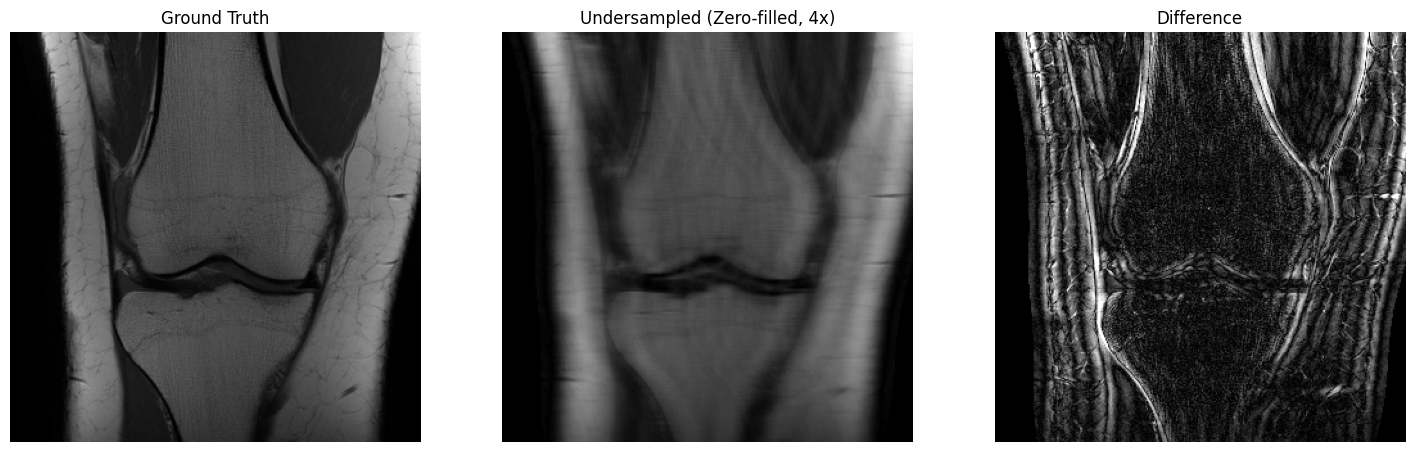

Mean abs difference: 0.0269   Max abs difference: 0.2511


In [20]:
assert_run_tag_current()  # catch a stale RUN_TAG before fitting/saving anything

ref = next(s for s in samples if s['filename'] == SEC7_REF_FILENAME)  # random per-anatomy pick from Section 6, not a hardcoded knee filename
slice_ksp = ref['slice_ksp']
slice_ksp_torchtensor = ref['slice_ksp_torchtensor']

output_depth = slice_ksp_torchtensor.numpy().shape[0] * 2
out_size = slice_ksp_torchtensor.numpy().shape[1:-1]
print(f"Number of coils: {slice_ksp_torchtensor.numpy().shape[0]}, "
      f"output_depth: {output_depth}, out_size: {out_size}")

# This single-image demo fit (Sections 7-11) is a sanity check only and is never persisted to
# disk (see Section 2's note) -- always fits fresh in memory for this session.
net = build_network({'output_depth': output_depth, 'out_size': out_size})

set_seed(SEED)  # reseed so the mask draw is identical regardless of architecture/z-source
u = build_undersampled(slice_ksp_torchtensor, slice_ksp, net)
mask, mask1d, mask2d = u['mask'], u['mask1d'], u['mask2d']
masked_kspace = u['masked_kspace']  # exposed so reconstruct()'s data-consistency step (below) can use it
zf_img_cropped = u['zf_img_cropped']
mps = u['mps']
gt_espirit = u['gt_espirit']

ni = get_z(u['zf_complex_cropped'])
scaling_factor, ni = get_scale_factor(net, num_channels, in_size, u['masked_kspace'], mps, ni=ni)
unders_measurement = Variable((u['masked_kspace'] * scaling_factor)[None, :]).type(dtype)

show_difference(gt_espirit, zf_img_cropped, 'Undersampled (Zero-filled, 4x)')

### 7.1 Full fit (10,000 iterations)

Expect roughly an hour on a T4 GPU (faster on L4/A100). Checkpoints every 1000 iterations to Drive for resilience against disconnects.

In [21]:
mse_wrt_noisy, net = fit(
    net=net,
    img_noisy_var=unders_measurement,
    num_channels=num_channels,
    net_input=ni,
    apply_f=forwardm,
    mask=mask2d,
    mask1d=mask1d,
    scaling_factor=scaling_factor,
    num_iter=num_iters_slow,
    LR=0.01,
    checkpoint_dir=None,   # sanity-check fit only -- never persisted (see Section 2's note)
)

if REPORT_FLOPS:
    report_flops(output_depth, out_size, num_iters_slow, label="Section 7 reference fit (10K iter)")

optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/10000 [00:00<?, ?it/s]

In [22]:
# Deliberately not saved -- this is a single-image sanity-check fit (see Section 2's note on
# Sections 7-9/12.2-12.4). Nothing downstream reads a persisted copy of it.
print("Reference fit complete (not saved to disk -- this is a sanity-check-only fit).")

Saved reference checkpoint (convdecoder_mri_vae) to /content/drive/MyDrive/Projects/checkpoints_multicoil_convdecoder_mri_vae/guided_init_multicoil_convdecoder_mri_vae.pt


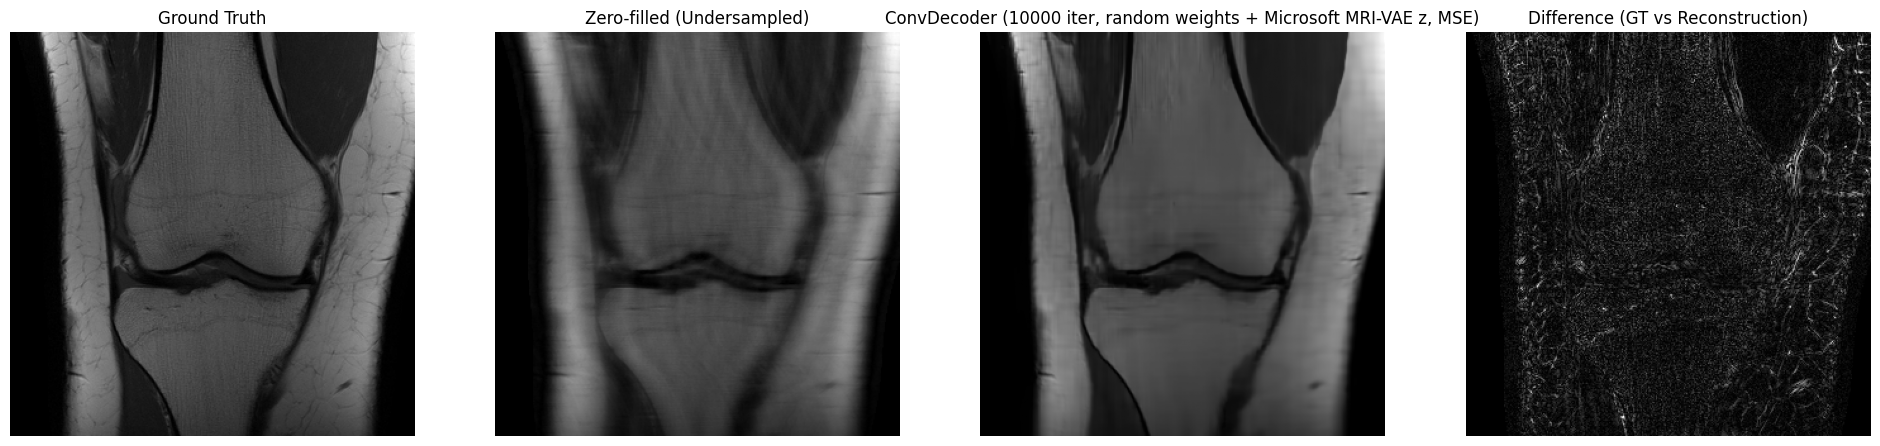

Mean abs difference: 0.0132   Max abs difference: 0.2005


In [23]:
rec_cropped_ref = reconstruct(net, ni, mps, masked_kspace=masked_kspace, scaling_factor=scaling_factor)
show_full_comparison(gt_espirit, zf_img_cropped, rec_cropped_ref,
              f'ConvDecoder ({num_iters_slow} iter, random weights + {Z_LABEL}, {LOSS_LABEL})')

# Same metrics/normalization convention as Section 9's results table (compute_all_metrics on
# normalize()-d images) -- printed here too so you see this fit's numbers immediately, without
# needing to run Section 9 first.
_ref_metrics = compute_all_metrics(normalize(gt_espirit.astype(np.float64)),
                                    normalize(rec_cropped_ref.astype(np.float64)))
print(f"\nMetrics for {ref['filename']} ({ARCHITECTURE}, {LOSS_LABEL}, {Z_LABEL}, "
      f"{num_iters_slow} iter):")
for _k, _v in _ref_metrics.items():
    print(f"  {_k}: {_v:.4f}")

## 8. Run A — Random-Init Baseline on a Second Image

A full-convergence, random-init fit on a second image (`file1000041.h5`), used as the random-init baseline for Section 9's results table and Section 13's batch eval. Guided-init single-fit comparisons live in Section 12 instead (the K-ensemble's own k=1 member is exactly a single guided-init fit -- no separate Run B/Run C cells needed to test that).


K_AVERAGING is True — Run A/B/C below will be skipped; this cell's shared mask/measurement for the eval image is still needed by Section 12.


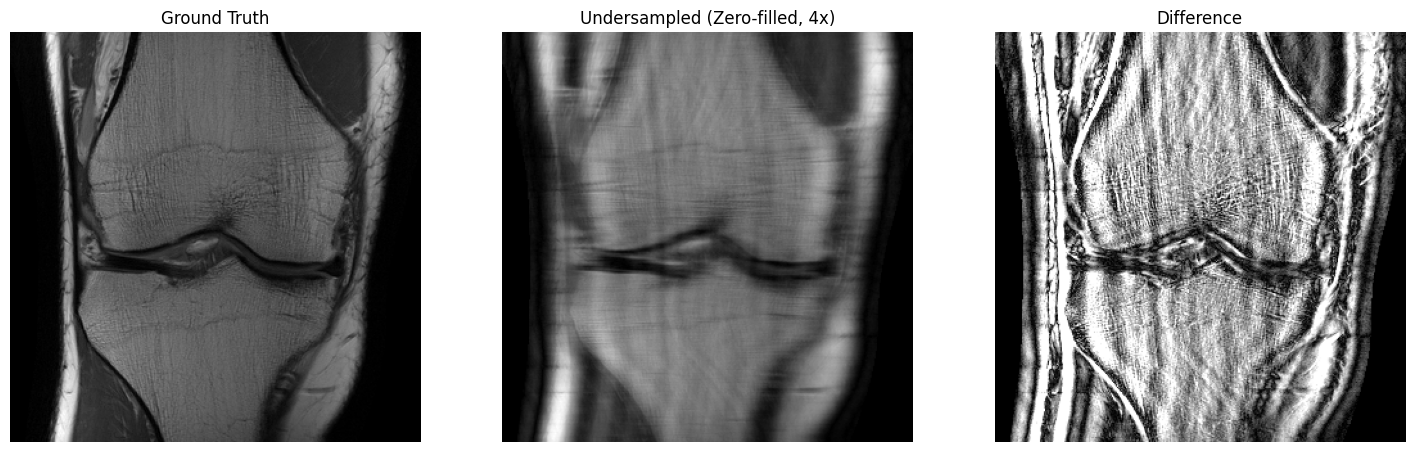

Mean abs difference: 0.0802   Max abs difference: 0.4945


In [24]:
assert_run_tag_current()  # catch a stale RUN_TAG before fitting/saving anything

# Single source of truth for this cell's target image. Defaults to the SAME random per-anatomy
# pick Section 6 computed for EVAL_TARGET_FILENAME (Section 12.1), so the two stay in sync
# automatically -- edit this string yourself (and EVAL_TARGET_FILENAME in Section 12 to match,
# per its own docstring) only if you want a specific, different file instead. Auto-loads into
# `samples` if not already present, so switching to a file outside the initial randomly-picked
# demo set doesn't raise a bare StopIteration from the next() lookup below.
SEC8_TARGET_FILENAME = DEFAULT_TARGET_FILENAME
if not any(s['filename'] == SEC8_TARGET_FILENAME for s in samples):
    print(f"{SEC8_TARGET_FILENAME} not yet in samples -- loading it from Drive now.")
    with h5py.File(os.path.join(folder, SEC8_TARGET_FILENAME), 'r') as f:
        _slicenu2 = f['kspace'].shape[0] // 2
        _slice_ksp2 = f['kspace'][_slicenu2]
        _data2 = np.stack((_slice_ksp2.real, _slice_ksp2.imag), axis=-1)
        samples.append({
            'filename': SEC8_TARGET_FILENAME,
            'slice_ksp': _slice_ksp2,
            'slice_ksp_torchtensor': torch.from_numpy(_data2),
        })

ref2 = next(s for s in samples if s['filename'] == SEC8_TARGET_FILENAME)
slice_ksp2 = ref2['slice_ksp']
slice_ksp_torchtensor2 = ref2['slice_ksp_torchtensor']

output_depth2 = slice_ksp_torchtensor2.numpy().shape[0] * 2
out_size2 = slice_ksp_torchtensor2.numpy().shape[1:-1]

# Build the mask/measurement ONCE using a throwaway network just for scale estimation,
# then reuse the identical mask/measurement for all three runs below so they're directly comparable.
net_for_scale = build_network({'output_depth': output_depth2, 'out_size': out_size2})
set_seed(SEED)  # reseed so the mask draw is identical regardless of architecture/z-source
u2 = build_undersampled(slice_ksp_torchtensor2, slice_ksp2, net_for_scale)
_, mask1d_2, mask2d_2 = u2['mask'], u2['mask1d'], u2['mask2d']
zf_img_cropped2 = u2['zf_img_cropped']
mps2 = u2['mps']
gt_espirit2 = u2['gt_espirit']

if K_AVERAGING:
    print("K_AVERAGING is True — Run A below will be skipped; this cell's shared "
          "mask/measurement for the eval image is still needed by Section 12.")

show_difference(gt_espirit2, zf_img_cropped2, 'Undersampled (Zero-filled, 4x)')

### 8.1 Run A — random init, 10,000 iterations (full-convergence baseline)

In [25]:
if K_AVERAGING:
    print("K_AVERAGING is True — skipping Run A (only Section 12 runs). "
          "Set K_AVERAGING = False to run Run A.")
    rec_A = None
else:
    # This single-image demo fit (Sections 7-11) is a sanity check only and is never persisted to
    # disk (see Section 2's note) -- always fits fresh in memory for this session.
    net_A = build_network({'output_depth': output_depth2, 'out_size': out_size2})
    ni_A = get_z(u2['zf_complex_cropped'])
    scaling_factor_A, ni_A = get_scale_factor(net_A, num_channels, in_size, u2['masked_kspace'], mps2, ni=ni_A)
    unders_measurement_A = Variable((u2['masked_kspace'] * scaling_factor_A)[None, :]).type(dtype)

    _, net_A_fitted = fit(
        net=net_A,
        img_noisy_var=unders_measurement_A,
        num_channels=num_channels,
        net_input=ni_A,
        apply_f=forwardm,
        mask=mask2d_2,
        mask1d=mask1d_2,
        scaling_factor=scaling_factor_A,
        num_iter=num_iters_A,
        LR=0.01,
        checkpoint_dir=None,   # sanity-check fit only -- never persisted (see Section 2's note)
    )

    rec_A = reconstruct(net_A_fitted, ni_A, mps2, masked_kspace=u2['masked_kspace'], scaling_factor=scaling_factor_A)
    show_full_comparison(gt_espirit2, zf_img_cropped2, rec_A, f'Run A: random init + {Z_LABEL}, {LOSS_LABEL}, {num_iters_A} iter')

K_AVERAGING is True — skipping Run A (only Section 12 runs). Set K_AVERAGING = False to run Run A/B/C.


## 9. Results Table (this run)

Quantitative comparison for **this notebook run** (i.e. this `Z_SOURCE`/`ARCHITECTURE` combination), saved to `RESULTS_DIR` tagged by `RUN_TAG`. All images are normalized to `[0, 1]` (by their own max) before computing metrics.

**Higher is better:** PSNR, SSIM, MS-SSIM, VIF
**Lower is better:** NMSE, HFEN

This cell does NOT compute any Δ against another run — that happens automatically in Section 10 once more than one `Z_SOURCE`/`ARCHITECTURE` combination has been run and saved.

In [28]:
import pandas as pd

results = []

# Tag every row with the loss config that produced it, so later comparisons can tell an MSE run
# apart from a Huber(+TV) run instead of silently averaging or dropping one of them.
loss_meta_fitted = dict(
    Loss_Type=LOSS_TYPE,
    Huber_Delta=HUBER_DELTA if LOSS_TYPE == "huber" else 'n/a',
    TV_Weight=TV_WEIGHT,
)
loss_meta_baseline = dict(Loss_Type='n/a', Huber_Delta='n/a', TV_Weight='n/a')

# --- Image 1 (file1000033) — reference image ---
gt1  = normalize(gt_espirit.astype(np.float64))
zf1  = normalize(zf_img_cropped.astype(np.float64))
rec1 = normalize(rec_cropped_ref.astype(np.float64))

m = compute_all_metrics(gt1, zf1)
m.update(Architecture=ARCHITECTURE, Image=ref['filename'], Method='Zero-filled', Z_Source='n/a',
         **loss_meta_baseline)
results.append(m)

m = compute_all_metrics(gt1, rec1)
m.update(Architecture=ARCHITECTURE, Image=ref['filename'],
         Method=f'ConvDecoder (random weights, {num_iters_slow} iter)', Z_Source=Z_SOURCE,
         **loss_meta_fitted)
results.append(m)

# --- Image 2 (file1000041) — zero-filled baseline is always cheap to compute (no fitting),
# and gt2/zf2 are reused by Section 12's ensemble-averaging evaluation, so these stay
# unconditional even when K_AVERAGING skips Run A/B/C below.
gt2  = normalize(gt_espirit2.astype(np.float64))
zf2  = normalize(zf_img_cropped2.astype(np.float64))

m = compute_all_metrics(gt2, zf2)
m.update(Architecture=ARCHITECTURE, Image=ref2['filename'], Method='Zero-filled', Z_Source='n/a',
         **loss_meta_baseline)
results.append(m)

if not K_AVERAGING:
    recA = normalize(rec_A.astype(np.float64))

    m = compute_all_metrics(gt2, recA)
    m.update(Architecture=ARCHITECTURE, Image=ref2['filename'],
             Method=f'Run A: random init, {num_iters_A} iter', Z_Source=Z_SOURCE,
             **loss_meta_fitted)
    results.append(m)
else:
    print("K_AVERAGING is True — Run A row skipped in this run's results table "
          "(see Section 12 for the ConvDecoder-A ensemble result instead).")

# metric_cols / meta_cols are defined once in Section 1 (imports cell) so batch-eval
# sections can use them even when Section 9 hasn't run yet this session.
results_df = pd.DataFrame(results)[meta_cols + metric_cols]

# Deliberately not saved to disk -- this is a single-image sanity-check table (see Section 2's
# note on Sections 7-9/12.2-12.4). Sections 10/11's cross-run comparisons, which used to read
# this file back in, are deprecated for the same reason (see those cells).

results_df.set_index(['Image', 'Method', 'Z_Source', 'Loss_Type']).round(4)

K_AVERAGING is True — Run A/B/C rows skipped in this run's results table (see Section 12 for the ConvDecoder-A ensemble result instead).
Saved this run's results to /content/drive/MyDrive/Projects/results/convdecoder_mri_vae.csv


Architecture  \
Image          Method                                   Z_Source Loss_Type                
file1000033.h5 Zero-filled                              n/a      n/a        convdecoder   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        convdecoder   
file1000041.h5 Zero-filled                              n/a      n/a        convdecoder   

                                                                           Huber_Delta  \
Image          Method                                   Z_Source Loss_Type               
file1000033.h5 Zero-filled                              n/a      n/a               n/a   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse               n/a   
file1000041.h5 Zero-filled                              n/a      n/a               n/a   

                                                                           TV_Weight  \
Image          Method                                   Z_Source Loss_Type             
file1000033.h5 Zero-filled                              n/a      n/a             n/a   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse               0   
file1000041.h5 Zero-filled                              n/a      n/a             n/a   

                                                                               PSNR  \
Image          Method                                   Z_Source Loss_Type            
file1000033.h5 Zero-filled                              n/a      n/a        28.0847   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        34.4045   
file1000041.h5 Zero-filled                              n/a      n/a        19.8774   

                                                                              SSIM  \
Image          Method                                   Z_Source Loss_Type           
file1000033.h5 Zero-filled                              n/a      n/a        0.7580   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        0.8507   
file1000041.h5 Zero-filled                              n/a      n/a        0.6469   

                                                                            MS-SSIM  \
Image          Method                                   Z_Source Loss_Type            
file1000033.h5 Zero-filled                              n/a      n/a         0.8911   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse         0.9685   
file1000041.h5 Zero-filled                              n/a      n/a         0.8201   

                                                                               VIF  \
Image          Method                                   Z_Source Loss_Type           
file1000033.h5 Zero-filled                              n/a      n/a        0.4251   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        0.8666   
file1000041.h5 Zero-filled                              n/a      n/a        0.4450   

                                                                              NMSE  \
Image          Method                                   Z_Source Loss_Type           
file1000033.h5 Zero-filled                              n/a      n/a        0.0172   
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        0.0040   
file1000041.h5 Zero-filled                              n/a      n/a        0.1070   

                                                                              HFEN  
Image          Method                                   Z_Source Loss_Type          
file1000033.h5 Zero-filled                              n/a      n/a        0.7739  
               ConvDecoder (random weights, 10000 iter) mri_vae  mse        0.3827  
file1000041.h5 Zero-filled                              n/a      n/a        0.7979

## 10. Cross-Run Comparison (Δ)

Auto-loads every saved results CSV for the **current `ARCHITECTURE`** and computes Δ between `Z_SOURCE` variants — no hardcoded baseline numbers. Run this notebook once with `Z_SOURCE = "uniform"` and once with `Z_SOURCE = "mri_vae"` (same `ARCHITECTURE`, same images), then run this cell.

Positive Δ = VAE input better than uniform input (sign auto-flipped for NMSE/HFEN, since lower is better for those).

In [29]:
# DEPRECATED: this compared saved Section 9 results tables across separate sessions/configs.
# Section 9 no longer persists its table to disk (see Section 2's note), so there is nothing left
# for this cell to glob and it would only ever report "no saved runs found". To do this comparison
# now, re-run Sections 7-9 once per config IN THE SAME SESSION and compare their in-memory
# `results_df`s directly (e.g. `results_df_a.set_index('Image') - results_df_b.set_index('Image')`
# on the metric columns).
print("Section 10 is deprecated -- see this cell's comment for why and what to do instead.")

Found 14 saved result file(s) total:
 - convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - kavg10_convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg10_convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg_batch19_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - kavg_batch21_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - kavg_batch22_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg10_convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg_batch20_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - convdecoder_mri_vae.csv

Missing architecture run(s) at Z_Source='unifo

## 11. Cross-Loss-Config Comparison (Δ)

The Section 10 cell above compares `Architecture` values (SE vs. plain) at a fixed loss config; it degenerates to a self-comparison if `ARCHITECTURE == BASELINE_ARCHITECTURE`. This cell compares the *loss config* instead — MSE vs. the current `LOSS_LABEL` (Huber, optionally +TV) — holding `ARCHITECTURE` and `Z_Source` fixed, which is the axis you actually want when checking whether Huber/TV helped or hurt relative to your original MSE baseline for the same architecture.

In [30]:
# DEPRECATED: same reason as Section 10 -- it compared saved Section 9 results tables across
# separate sessions/configs, and Section 9 no longer persists that table to disk (see Section 2's
# note). Re-run Sections 7-9 once per loss config IN THE SAME SESSION and diff their in-memory
# `results_df`s directly if you need this comparison.
print("Section 11 is deprecated -- see this cell's comment for why and what to do instead.")

Found 14 saved result file(s) total:
 - convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - kavg10_convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.1066_tv0.0001305.csv
 - convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg10_convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.03487_tv1.212e-05.csv
 - kavg_batch19_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - kavg_batch21_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - kavg_batch22_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg10_convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg_batch_convdecoder_uniform_huber_delta0.02327_tv5.865e-05.csv
 - kavg_batch20_convdecoder_uniform_huber_delta0.02327_tv5.865e-05_summary.csv
 - convdecoder_mri_vae.csv

Loss configs found for architecture='convdecod

## 12. Ensemble Averaging — ConvDecoder-A (k = `K_VALUE`, currently 10)

This reproduces the paper's ensemble-averaging result (their Fig. 5 / "ConvDecoder-A"): instead of a single accelerated (guided-init, 1,000-iteration) fit, we fit **`K_VALUE` independent accelerated reconstructions** (currently 10) of the same evaluation target (`file1000041.h5`) — each guided-init from a *different* reference checkpoint (i.e. a different source image's converged fit) — then average the K reconstructions pixel-wise.

This only applies to the accelerated regime (matches `ACCEL_NUM_ITERS`, 1,000 iterations); it is not run for the slower random-init/full guided-init configurations.

**Why K different reference images, not just noise added to one reference?** If all K accelerated fits started from the *same* single guided-init checkpoint (Section 7's), they'd start from identical weights, and ConvDecoder's fitting here has no other source of randomness (no dropout, no minibatching) — so all K fits would converge to numerically identical reconstructions, and averaging them would do nothing. Using K distinct reference source images gives each ensemble member a genuinely different starting point, so their fit-specific errors are only partially correlated — which is exactly what averaging needs in order to cancel noise while reinforcing the shared true structure.

**Which K images are used as references:** chosen at random (not hand-picked) from every file in the data folder matching the evaluation target's acquisition type and coil count. This happens once per `RUN_TAG`/`K_VALUE` combination; the choice is then saved to disk and every later run (including after a runtime reset) reuses the same K filenames instead of drawing a new random set. Delete the saved selection file (its path is printed by this section's first cell) to force a fresh random draw.

**`KAVG_INIT_MODE` (Section 2)** generalizes the above: `"guided"` (default) is exactly what's described here; `"random"` skips reference fitting entirely and starts every member from fresh random init instead (isolates how much guided init itself matters); `"mixed"` guides only `KAVG_MIXED_GUIDED_COUNT` of the `K_VALUE` members, leaving the rest random-init, deliberately diversifying starting points within one ensemble. Independently, `KAVG_GUIDED_REF_MODE` controls whether guided members each use a *different* reference image (`"different_images"`, the behavior described above) or all share the *same one* (`"single_image"`, isolating how much of the benefit comes from reference-image diversity specifically vs. guided init itself).

**Compute cost:** each of the K reference checkpoints needs a full 10,000-iteration fit (same cost as Section 7), plus K accelerated 1,000-iteration fits. If `file1000033.h5` happens to be among the randomly chosen K, its checkpoint from Section 7 is reused directly as one ensemble member for free (only K-1 new reference fits needed); otherwise all K reference fits are new. At the established benchmarks (~31 min / ~65 min per full fit on L4/T4), expect roughly **K × ~31 min + K × ~3 min** in the worst case (no free reuse), or **(K-1) × ~31 min + K × ~3 min** if `file1000033.h5` is drawn, the first time this runs; with `RUN_MODE="load_existing"`, subsequent runs reload every cached checkpoint instead of refitting.

Set `K_AVERAGING = True` in Section 2 to run this section.

In [31]:
if K_AVERAGING:
    assert_run_tag_current()

    EVAL_TARGET_FILENAME = DEFAULT_TARGET_FILENAME  # same random per-anatomy pick as Section 8's SEC8_TARGET_FILENAME (Section 6) -- must match the file used for Run A/B/C in Section 8
    _env_override('EVAL_TARGET_FILENAME', str)  # e.g. CD_EVAL_TARGET_FILENAME=file_brain_AXT1_..._h5
                                                # for a brain SLURM run -- see run_*.sbatch

    if EVAL_TARGET_FILENAME not in all_files:
        # Guards a pinned/env-overridden filename (e.g. run_knee_batch.sbatch's explicit
        # file1000041.h5) that turns out not to exist in THIS run's actual folder -- a partial
        # download, a wrong CONVDECODER_DATA_DIR, or just a stale pin left over from a different
        # dataset snapshot. Without this, the h5py.File() open below would raise a bare,
        # unhelpful OSError and waste an entire unattended SLURM job's queue wait. Falls back to
        # this run's own auto-picked default instead of hard-failing.
        print(f"WARNING: EVAL_TARGET_FILENAME={EVAL_TARGET_FILENAME!r} (from $CD_EVAL_TARGET_FILENAME "
              f"or a hardcoded pin) was not found among the {len(all_files)} {ANATOMY} files in "
              f"{folder!r} -- falling back to this run's auto-picked default, "
              f"{DEFAULT_TARGET_FILENAME!r}, instead.")
        EVAL_TARGET_FILENAME = DEFAULT_TARGET_FILENAME

    def find_kavg_eligible_pool(exclude):
        '''Every file in `folder` matching EVAL_TARGET_FILENAME's acquisition type and coil
        count (so any candidate is guaranteed compatible with load_state_dict() as a guided-init
        source), excluding filenames in `exclude`. Shared by the initial random reference draw
        (below) and by the calibration-failure replacement logic in Section 12.1.'''
        with h5py.File(os.path.join(folder, EVAL_TARGET_FILENAME), 'r') as f:
            target_acquisition = f.attrs.get('acquisition')
            target_num_coils = f['kspace'].shape[1]
        pool = []
        for fname in all_files:
            if fname in exclude:
                continue
            try:
                with h5py.File(os.path.join(folder, fname), 'r') as f:
                    if (f.attrs.get('acquisition') != target_acquisition
                            or f['kspace'].shape[1] != target_num_coils):
                        continue
                    pool.append(fname)
            except OSError as e:
                print(f"  SKIPPED {fname}: {e}")
                continue
        return pool

    # The K reference source images are chosen ONCE (at random) and then persisted to disk, keyed
    # by RUN_TAG + K_VALUE, so every later run of this cell reuses the SAME K filenames instead of
    # redrawing a new random set. This matters because the per-file reference checkpoints cached in
    # Section 12.1 below are keyed by filename -- redrawing a different random set every run would
    # silently start fitting a different ensemble each time instead of reusing cached work.
    KAVG_REF_SELECTION_PATH = f"{SELECTIONS_DIR}/kavg_ref_selection_kavg{K_VALUE}_{RUN_TAG}.json"

    if os.path.exists(KAVG_REF_SELECTION_PATH):
        with open(KAVG_REF_SELECTION_PATH) as f:
            kavg_ref_filenames = json.load(f)
        print(f"Found existing reference selection at {KAVG_REF_SELECTION_PATH} -- reusing it "
              f"(delete this file if you want a fresh random draw instead).")
    else:
        print(f"No existing reference selection found at {KAVG_REF_SELECTION_PATH} -- drawing "
              f"{K_VALUE} random reference images now (this only happens once per RUN_TAG/K_VALUE "
              f"combination; the choice is then saved for every later run to reuse).")

        eligible_filenames = find_kavg_eligible_pool(exclude={EVAL_TARGET_FILENAME})

        assert len(eligible_filenames) >= K_VALUE, (
            f"Only found {len(eligible_filenames)} usable reference candidates in {folder}, "
            f"need {K_VALUE}. Add more files to the Drive folder or lower K_VALUE in Section 2."
        )

        # Random draw from the full eligible pool, using an independent RNG seeded from SEED (so
        # it's reproducible without perturbing the global `random` module state used elsewhere,
        # e.g. Section 6.5's tuning-image draw).
        rng = random.Random(SEED)
        kavg_ref_filenames = rng.sample(eligible_filenames, K_VALUE)

        os.makedirs(os.path.dirname(KAVG_REF_SELECTION_PATH), exist_ok=True)
        with open(KAVG_REF_SELECTION_PATH, "w") as f:
            json.dump(kavg_ref_filenames, f, indent=1)
        print(f"Saved reference selection to {KAVG_REF_SELECTION_PATH} for reuse by future runs.")

    # Load any selected files not already in `samples` (a fresh runtime only has the 5 hand-picked
    # demo images loaded by Section 6; a reused selection from a prior run needs reloading here).
    loaded_filenames = {s['filename'] for s in samples}
    for fname in kavg_ref_filenames:
        if fname in loaded_filenames:
            continue
        with h5py.File(os.path.join(folder, fname), 'r') as f:
            slicenu = f["kspace"].shape[0] // 2
            slice_ksp = f['kspace'][slicenu]
            data = np.stack((slice_ksp.real, slice_ksp.imag), axis=-1)
            samples.append({
                'filename': fname,
                'slice_ksp': slice_ksp,
                'slice_ksp_torchtensor': torch.from_numpy(data),
            })

    if len(kavg_ref_filenames) != K_VALUE:
        print(f"NOTE: the loaded reference selection has {len(kavg_ref_filenames)} filenames, "
              f"but K_VALUE is currently {K_VALUE} -- these differ, e.g. if K_VALUE was changed "
              f"after this selection file was saved under its OLD K_VALUE-named path being reused, "
              f"or the file was edited by hand. Everything downstream (fitting, averaging, labels) "
              f"uses the ACTUAL list length ({len(kavg_ref_filenames)}), not K_VALUE, so this just "
              f"produces a k={len(kavg_ref_filenames)} ensemble rather than k={K_VALUE} -- delete "
              f"{KAVG_REF_SELECTION_PATH} for a fresh K_VALUE-sized draw if that's not what you want.")
    print(f"\nUsing {len(kavg_ref_filenames)} reference source images for ConvDecoder-A: {kavg_ref_filenames}")
else:
    print("K_AVERAGING is False — skipping Section 12 (set K_AVERAGING = True in Section 2 to run it).")


No existing reference selection found at /content/drive/MyDrive/Projects/kavg_ref_selection_kavg10_convdecoder_mri_vae.json -- drawing 10 random reference images now (this only happens once per RUN_TAG/K_VALUE combination; the choice is then saved for every later run to reuse).
  SKIPPED file1000263.h5: Unable to synchronously open file (truncated file: eof = 1128340480, sblock->base_addr = 0, stored_eof = 1234702720)
  SKIPPED file1000356.h5: Unable to synchronously open file (truncated file: eof = 197303296, sblock->base_addr = 0, stored_eof = 1014286720)
  SKIPPED file1000537.h5: Unable to synchronously open file (truncated file: eof = 3003392, sblock->base_addr = 0, stored_eof = 1014286720)
  SKIPPED file1000871.h5: Unable to synchronously open file (truncated file: eof = 9683968, sblock->base_addr = 0, stored_eof = 985307520)
  SKIPPED file1000932.h5: Unable to synchronously open file (truncated file: eof = 132680704, sblock->base_addr = 0, stored_eof = 869390720)
  SKIPPED file10

### 12.1 Fit (or reuse) K reference checkpoints

Builds (or loads from cache) the `K_VALUE` full 10,000-iteration guided-init reference fits for the randomly-chosen reference images selected above. If `file1000033.h5` happens to be among them, its checkpoint from Section 7 is reused directly as that member; the rest are fit fresh the first time, then cached permanently — this step ignores `RUN_MODE` on purpose (see the code comment) since these references have nothing to do with which image you're currently evaluating.

In [32]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    assert_run_tag_current()

    KAVG_REF_CKPT_DIR = f"{CKPT_ROOT}/checkpoints_multicoil_kavg{K_VALUE}_{RUN_TAG}_refs"
    # Discriminated by ACCEL_LOSS_TAG (ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT), NOT KAVG_TAG/RUN_TAG
    # (regular HUBER_DELTA/TV_WEIGHT) -- these are accelerated fits, built with the ACCEL_*
    # hyperparameters, so that's what needs to vary the path. Using KAVG_TAG here was a real
    # bug: two different ACCEL_HUBER_DELTA values would collide in the same directory.
    # KAVG_ACC_TAG/KAVG_UNTRAINED_ACC_TAG are still needed as plain tag strings (KAVG_TAG below
    # derives from the latter for the pure-random-init regime) -- but Section 12.2's single-image
    # accelerated fit that used to be cached under directories named from these tags is no longer
    # persisted to disk at all (see Section 2's note), so no directory is created for them here.
    KAVG_ACC_TAG = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    KAVG_UNTRAINED_ACC_TAG = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    os.makedirs(KAVG_REF_CKPT_DIR, exist_ok=True)

    # KAVG_TAG identifies this ensemble's OWN results (Section 12.3's results CSV, batch results
    # in Section 12.5) -- built to be backward compatible with the two combinations this
    # notebook supported before KAVG_INIT_MODE existed: pure guided/different_images keeps the
    # original unsuffixed tag, pure random keeps the original "_untrained"-suffixed one (based
    # on ACCEL_LOSS_TAG, since a pure-random ensemble only ever uses ACCEL_HUBER_DELTA/
    # ACCEL_TV_WEIGHT, never the regular HUBER_DELTA/TV_WEIGHT that RUN_TAG encodes). Every other
    # combination (single_image, mixed) gets its own descriptive suffix so it can never collide
    # with these or with each other.
    if KAVG_INIT_MODE == "random":
        KAVG_TAG = f"{KAVG_UNTRAINED_ACC_TAG}_untrained"
    else:
        if KAVG_INIT_MODE == "guided":
            _kavg_init_tag = "" if KAVG_GUIDED_REF_MODE == "different_images" else "_singleref"
        else:  # "mixed"
            _kavg_init_tag = (f"_mixed{KAVG_NUM_GUIDED_MEMBERS}"
                               + ("" if KAVG_GUIDED_REF_MODE == "different_images" else "_singleref"))
        KAVG_TAG = f"kavg{K_VALUE}_{RUN_TAG}{_kavg_init_tag}"

    # How many reference images actually need a 10,000-iter fit: 0 for pure random, 1 for
    # single_image (every guided member shares it), else one distinct image per guided member.
    KAVG_NUM_REF_IMAGES_NEEDED = (
        0 if KAVG_NUM_GUIDED_MEMBERS == 0
        else (1 if KAVG_GUIDED_REF_MODE == "single_image" else KAVG_NUM_GUIDED_MEMBERS)
    )

    if KAVG_NUM_REF_IMAGES_NEEDED == 0:
        kavg_ref_checkpoints = []  # unused in pure-random mode -- defined so nothing downstream
                                   # that references the name by accident hits a NameError.
        print(f"KAVG_INIT_MODE={KAVG_INIT_MODE!r} needs no guided-init reference checkpoints -- "
              f"skipping Section 12.1 reference-checkpoint fitting entirely (Section 12.2/12.5 "
              f"will fit all {K_VALUE} members from fresh random-init networks instead).")
    else:
        # NOTE on RUN_MODE here: the K reference checkpoints are a shared, durable cache — each one
        # is expensive (10,000 iterations) but has nothing to do with *which* image you're currently
        # reconstructing. RUN_MODE is about the accelerated fit of the CURRENT eval target (Section
        # 12.2 below): "new_fit" should force a fresh accelerated reconstruction for a new image, but
        # it should NOT force these reference fits to redo work that's already sitting on disk. So,
        # unlike every other fit in this notebook, reference-checkpoint reuse here is existence-only
        # and deliberately ignores RUN_MODE — once a reference image has been fit, it's fit for good.

        kavg_ref_checkpoints = []  # one entry per ensemble member: {'filename', 'model_state_dict'}

        # Accumulates EVERY filename ever rejected as a reference this run (manual exclusion,
        # ESPIRiT failure, or premature convergence) -- persists across swaps, unlike
        # kavg_ref_filenames itself. Without this, a rejected image gets overwritten out of
        # kavg_ref_filenames the moment it's swapped out, so if ITS replacement also fails, the
        # next exclude-set computation (built from kavg_ref_filenames's CURRENT contents) no longer
        # contains the original rejected image at all -- it silently becomes eligible again and can
        # get drawn right back, an infinite-retry bug rather than a real retry.
        kavg_rejected_filenames = set()

        def _swap_kavg_reference(idx, old_fname, reason):
            '''Draws a fresh eligible replacement for kavg_ref_filenames[idx], persists the swap to
            the selection file, adds it to `samples` if not already loaded, and returns the new
            filename. Shared by all three reasons a reference image gets swapped: manual exclusion
            (KAVG_REF_MANUAL_EXCLUDE), ESPIRiT calibration failure, and premature convergence (the
            fit's training loss plateaus before KAVG_REF_PLATEAU_CHECK_ITER).'''
            print(f"    {old_fname}: {reason} -- swapping in a replacement reference image.")
            kavg_rejected_filenames.add(old_fname)
            replacement_pool = find_kavg_eligible_pool(
                exclude=set(kavg_ref_filenames) | {EVAL_TARGET_FILENAME, old_fname}
                        | KAVG_REF_MANUAL_EXCLUDE | kavg_rejected_filenames
            )
            assert replacement_pool, (
                f"No eligible replacement reference images left in {folder} after excluding the "
                f"current K reference images, the eval target, {old_fname} itself, "
                f"KAVG_REF_MANUAL_EXCLUDE, and {len(kavg_rejected_filenames)} previously-rejected "
                f"image(s) this run ({sorted(kavg_rejected_filenames)})."
            )
            new_fname = replacement_pool[0]
            print(f"    Replacing with {new_fname} in the reference set.")
            kavg_ref_filenames[idx] = new_fname
            with open(KAVG_REF_SELECTION_PATH, "w") as jf:
                json.dump(kavg_ref_filenames, jf, indent=1)
            print(f"    Saved updated reference selection to {KAVG_REF_SELECTION_PATH}.")
            if new_fname not in {s['filename'] for s in samples}:
                with h5py.File(os.path.join(folder, new_fname), 'r') as f:
                    slicenu_new = f["kspace"].shape[0] // 2
                    slice_ksp_new = f['kspace'][slicenu_new]
                    data_new = np.stack((slice_ksp_new.real, slice_ksp_new.imag), axis=-1)
                    samples.append({
                        'filename': new_fname,
                        'slice_ksp': slice_ksp_new,
                        'slice_ksp_torchtensor': torch.from_numpy(data_new),
                    })
            return new_fname

        for idx, fname in enumerate(kavg_ref_filenames[:KAVG_NUM_REF_IMAGES_NEEDED]):
            # Manual exclusion check FIRST, before either reuse shortcut below -- so a filename
            # added to KAVG_REF_MANUAL_EXCLUDE still gets swapped out even if it already has a
            # cached reference checkpoint on disk from a previous run (otherwise the cached-
            # checkpoint shortcut just below would silently keep reusing it, exclusion never
            # taking effect until that stale checkpoint file was deleted by hand).
            if fname in KAVG_REF_MANUAL_EXCLUDE:
                fname = _swap_kavg_reference(idx, fname, "manually excluded (KAVG_REF_MANUAL_EXCLUDE)")

            # NOTE: this used to opportunistically reuse Section 7's reference checkpoint if
            # SEC7_REF_FILENAME happened to be drawn here -- removed because Section 7 no longer
            # persists anything to disk (see Section 2's note), so that shortcut can never fire
            # any more. Falls straight through to the normal per-member cache check below.
            stable_member_ckpt_path = f"{KAVG_REF_CKPT_DIR}/ref_{stable_stem(fname)}.pt"
            legacy_member_ckpt_path = f"{KAVG_REF_CKPT_DIR}/ref_{idx}_{fname}.pt"
            member_ckpt_path = first_existing_path(stable_member_ckpt_path, legacy_member_ckpt_path)

            if member_ckpt_path is not None:
                print(f"[{idx}] {fname}: reference checkpoint already exists — loading {member_ckpt_path}")
                ckpt_i = load_checkpoint_guarded(member_ckpt_path, seed=SEED, early_stop_method=EARLY_STOP_METHOD,
                                                  use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE)
                kavg_ref_checkpoints.append({'filename': fname, 'model_state_dict': ckpt_i['model_state_dict']})
                continue

            print(f"[{idx}] {fname}: no cached reference checkpoint found — fitting now (10,000 iter).")

            # Retry loop: keeps trying (a possibly new) fname until a reference checkpoint is
            # obtained for slot idx -- either a cache hit found after a swap, or a fit that
            # completes without either failure mode below. Two independent things can trigger a
            # swap-and-retry here: ESPIRiT calibration failure (as before), and now also
            # PrematureConvergenceError from fit() (KAVG_REF_PLATEAU_CHECK_ITER) -- a fit whose loss
            # has barely moved by then is unlikely to become a rich, well-converged guide-init
            # source even after the remaining ~9,400 iterations, so it's swapped out early instead
            # of wasting the rest of the budget on it. The cache check at the top of every pass
            # covers the common case for free too: if the replacement image swapped in by EITHER
            # failure mode already has a checkpoint on disk from a previous run, it's loaded
            # directly instead of being re-fit.
            slot_done = False
            while not slot_done:
                stable_member_ckpt_path = f"{KAVG_REF_CKPT_DIR}/ref_{stable_stem(fname)}.pt"
                legacy_member_ckpt_path = f"{KAVG_REF_CKPT_DIR}/ref_{idx}_{fname}.pt"
                member_ckpt_path = first_existing_path(stable_member_ckpt_path, legacy_member_ckpt_path)
                if member_ckpt_path is not None:
                    print(f"    {fname}: reference checkpoint already exists — loading {member_ckpt_path}")
                    ckpt_i = load_checkpoint_guarded(member_ckpt_path, seed=SEED, early_stop_method=EARLY_STOP_METHOD,
                                                      use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE)
                    kavg_ref_checkpoints.append({'filename': fname, 'model_state_dict': ckpt_i['model_state_dict']})
                    slot_done = True
                    continue

                sample_i = next(s for s in samples if s['filename'] == fname)
                ksp_i = sample_i['slice_ksp']
                ksp_tt_i = sample_i['slice_ksp_torchtensor']
                output_depth_i = ksp_tt_i.numpy().shape[0] * 2
                out_size_i = ksp_tt_i.numpy().shape[1:-1]

                net_i = build_network({'output_depth': output_depth_i, 'out_size': out_size_i})
                set_seed(SEED)
                try:
                    u_i = build_undersampled(ksp_tt_i, ksp_i, net_i)
                except EspiritCalibrationError as e:
                    fname = _swap_kavg_reference(idx, fname, f"ESPIRiT calibration failed ({e})")
                    continue

                ni_i = get_z(u_i['zf_complex_cropped'])
                scaling_factor_i, ni_i = get_scale_factor(net_i, num_channels, in_size, u_i['masked_kspace'], u_i['mps'], ni=ni_i)
                unders_measurement_i = Variable((u_i['masked_kspace'] * scaling_factor_i)[None, :]).type(dtype)

                try:
                    _, net_i_fitted = fit(
                        net=net_i,
                        img_noisy_var=unders_measurement_i,
                        num_channels=num_channels,
                        net_input=ni_i,
                        apply_f=forwardm,
                        mask=u_i['mask2d'],
                        mask1d=u_i['mask1d'],
                        scaling_factor=scaling_factor_i,
                        num_iter=10000,
                        LR=0.01,
                        checkpoint_dir=f"{KAVG_REF_CKPT_DIR}/progress_{idx}",
                        checkpoint_every=1000,
                        plateau_check_iter=(KAVG_REF_PLATEAU_CHECK_ITER if KAVG_REF_PLATEAU_CHECK else None),
                        plateau_window=KAVG_REF_PLATEAU_WINDOW,
                        plateau_min_improvement=KAVG_REF_PLATEAU_MIN_IMPROVEMENT,
                    )
                except PrematureConvergenceError as e:
                    fname = _swap_kavg_reference(idx, fname, f"reference fit converged too soon ({e})")
                    continue

                torch.save({
                    'model_state_dict': net_i_fitted.state_dict(),
                    'freq_frac': net_i_fitted.get_freq_frac(),
                    'net_input': ni_i, 'mask': u_i['mask'], 'mask1d': u_i['mask1d'], 'mask2d': u_i['mask2d'],
                    'scaling_factor': scaling_factor_i,
                    **checkpoint_metadata(source_filename=fname, num_iterations=10000, checkpoint_role='k_reference'),
                }, stable_member_ckpt_path)
                print(f"    saved {stable_member_ckpt_path}")
                kavg_ref_checkpoints.append({'filename': fname, 'model_state_dict': net_i_fitted.state_dict()})
                slot_done = True

    print(f"\n{len(kavg_ref_checkpoints)} reference checkpoint(s) ready: "
          f"{[c['filename'] for c in kavg_ref_checkpoints]}")
elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")


[0] file1001077.h5: no cached reference checkpoint found — fitting now (10,000 iter).
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/10000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_refs/ref_file1001077.pt
[1] file1002280.h5: no cached reference checkpoint found — fitting now (10,000 iter).
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/10000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_refs/ref_file1002280.pt
[2] file1001122.h5: no cached reference checkpoint found — fitting now (10,000 iter).
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


...

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_refs/ref_file1001096.pt
[8] file1000735.h5: no cached reference checkpoint found — fitting now (10,000 iter).
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/10000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_refs/ref_file1000735.pt
[9] file1001170.h5: no cached reference checkpoint found — fitting now (10,000 iter).
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/10000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_refs/ref_file1001170.pt

10 reference checkpoints ready: ['file1001077.h5', 'file1002280.h5', 'file1001122.h5', 'file1000071.h5', 'file1000635.h5', 'file1001221.h5', 'file1001184.h5', 'file1001096.h5', 'file1000735.h5', 'file1001170.h5']


### 12.2 Accelerated (1,000-iteration) guided fit from each reference

For the single evaluation image `EVAL_TARGET_FILENAME`, fits one accelerated (1,000-iteration) guided reconstruction per reference checkpoint from 12.1 above — these `K_VALUE` reconstructions are what gets averaged in 12.3 below.

In [33]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    assert_run_tag_current()
    print(f"KAVG_INIT_MODE={KAVG_INIT_MODE!r} ({KAVG_INIT_LABEL}): fitting {K_VALUE} ensemble "
          f"members -- {KAVG_NUM_GUIDED_MEMBERS} guided-init, {K_VALUE - KAVG_NUM_GUIDED_MEMBERS} "
          f"random-init. Every member still runs the same accelerated ({ACCEL_NUM_ITERS}-iter) "
          f"fit against the eval image's own k-space -- only the starting point differs.")

    kavg_recons = []  # one reconstructed (magnitude) image per ensemble member
    kavg_recons_complex = []  # same, but complex (phase preserved) -- for KAVG_AVERAGE_COMPLEX
    kavg_member_losses = []  # each member's net.final_loss -- for KAVG_WEIGHTED_ENSEMBLE

    for idx in range(K_VALUE):
        member_is_guided = idx < KAVG_NUM_GUIDED_MEMBERS

        if member_is_guided:
            # kavg_ref_checkpoints has length KAVG_NUM_REF_IMAGES_NEEDED (Section 12.1) -- for
            # KAVG_GUIDED_REF_MODE=="different_images" this is one distinct entry per guided
            # member (the modulo is then a no-op); for "single_image" it's a length-1 list, so
            # every guided member shares that one entry via the modulo.
            ckpt_i = kavg_ref_checkpoints[idx % len(kavg_ref_checkpoints)]
            fname = ckpt_i['filename']
            # Single-image sanity-check fit (Sections 12.2-12.4) -- never persisted to disk (see
            # Section 2's note); always fits fresh. RUN_MODE has no effect here.
            print(f"[{idx}] guided from {fname}: fitting accelerated ({ACCEL_NUM_ITERS} iter) reconstruction ...")
            net_acc_i = build_network({'output_depth': output_depth2, 'out_size': out_size2})
            net_acc_i.load_state_dict(ckpt_i['model_state_dict'])  # guided init from ensemble member idx
            # Explicit, deterministic z-seed for guided members -- previously this member's
            # input code z (when Z_SOURCE in ("uniform", "uniform_blur")) came only from
            # whatever global RNG state happened to carry over from earlier work this run
            # (incidental, not reproducible per-member on its own). +2000 keeps this offset
            # block clear of SEED itself and of the random-init members' own "+1000+idx"
            # scheme above, so the two schemes can never collide even in "mixed" mode.
            guided_z_seed_i = SEED + 2000 + idx
            set_seed(guided_z_seed_i)
            ni_acc_i = get_z(u2['zf_complex_cropped'])
            scaling_factor_acc_i, ni_acc_i = get_scale_factor(net_acc_i, num_channels, in_size,
                                                                u2['masked_kspace'], mps2, ni=ni_acc_i)
            unders_measurement_acc_i = Variable((u2['masked_kspace'] * scaling_factor_acc_i)[None, :]).type(dtype)

            _, net_acc_i_fitted = fit(
                net=net_acc_i,
                img_noisy_var=unders_measurement_acc_i,
                num_channels=num_channels,
                net_input=ni_acc_i,
                apply_f=forwardm,
                mask=mask2d_2,
                mask1d=mask1d_2,
                scaling_factor=scaling_factor_acc_i,
                num_iter=ACCEL_NUM_ITERS,   # the accelerated regime's iteration budget
                LR=0.01,
                checkpoint_dir=None,
                huber_delta=ACCEL_HUBER_DELTA,   # accelerated/guided-init regime's own hyperparameters
                tv_weight=ACCEL_TV_WEIGHT,
            )
            net_acc_i = net_acc_i_fitted

            if REPORT_FLOPS and idx == 0:
                report_flops(output_depth2, out_size2, ACCEL_NUM_ITERS,
                             label="Section 12.2 single ensemble-member fit (1 of K, guided, "
                                   f"{ACCEL_NUM_ITERS} iter)")

            rec_complex_i = reconstruct(net_acc_i, ni_acc_i, mps2, masked_kspace=u2['masked_kspace'],
                                        scaling_factor=scaling_factor_acc_i, return_complex=True)
            member_final_loss = net_acc_i.final_loss
        else:
            # Distinct, deterministic seed per member -- offset by 1000 to stay clear of SEED
            # itself and of any other per-member seed scheme elsewhere in the notebook.
            # build_network(seed=...) calls set_seed(seed) internally, so this also reseeds the
            # global RNG right before get_z()/get_scale_factor() below -- meaning the random input
            # code z (when Z_SOURCE="uniform") varies per member too, not just the weights, for
            # genuine K-way diversity in the random-init starting point.
            member_seed = SEED + 1000 + idx
            # Single-image sanity-check fit (Sections 12.2-12.4) -- never persisted to disk (see
            # Section 2's note); always fits fresh. RUN_MODE has no effect here.
            print(f"[{idx}] random-init (seed={member_seed}): fitting accelerated "
                  f"({ACCEL_NUM_ITERS} iter) reconstruction from scratch ...")
            net_untrained_i = build_network({'output_depth': output_depth2, 'out_size': out_size2},
                                             seed=member_seed)
            ni_untrained_i = get_z(u2['zf_complex_cropped'])
            scaling_factor_untrained_i, ni_untrained_i = get_scale_factor(
                net_untrained_i, num_channels, in_size, u2['masked_kspace'], mps2, ni=ni_untrained_i
            )
            unders_measurement_untrained_i = Variable(
                (u2['masked_kspace'] * scaling_factor_untrained_i)[None, :]).type(dtype)

            _, net_untrained_i_fitted = fit(
                net=net_untrained_i,
                img_noisy_var=unders_measurement_untrained_i,
                num_channels=num_channels,
                net_input=ni_untrained_i,
                apply_f=forwardm,
                mask=mask2d_2,
                mask1d=mask1d_2,
                scaling_factor=scaling_factor_untrained_i,
                num_iter=ACCEL_NUM_ITERS,   # same accelerated-regime iteration budget as the
                                             # guided-init members -- only the starting point differs
                LR=0.01,
                checkpoint_dir=None,
                huber_delta=ACCEL_HUBER_DELTA,
                tv_weight=ACCEL_TV_WEIGHT,
            )
            net_untrained_i = net_untrained_i_fitted

            if REPORT_FLOPS and idx == 0:
                report_flops(output_depth2, out_size2, ACCEL_NUM_ITERS,
                             label="Section 12.2 single ensemble-member fit (1 of K, random-init, "
                                   f"{ACCEL_NUM_ITERS} iter)")

            rec_complex_i = reconstruct(net_untrained_i, ni_untrained_i, mps2,
                                        masked_kspace=u2['masked_kspace'],
                                        scaling_factor=scaling_factor_untrained_i, return_complex=True)
            member_final_loss = net_untrained_i.final_loss

        kavg_recons.append(np.abs(rec_complex_i))
        kavg_recons_complex.append(rec_complex_i)
        kavg_member_losses.append(member_final_loss)

    print(f"\n{len(kavg_recons)} accelerated reconstructions ready for averaging "
          f"({KAVG_NUM_GUIDED_MEMBERS} guided, {K_VALUE - KAVG_NUM_GUIDED_MEMBERS} random-init).")
elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")


[0] guided from file1001077.h5: no cached accelerated fit — fitting now.
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/1000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_acc/acc_0_file1001077.h5.pt
[1] guided from file1002280.h5: no cached accelerated fit — fitting now.
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/1000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_acc/acc_1_file1002280.h5.pt
[2] guided from file1001122.h5: no cached accelerated fit — fitting now.
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


...

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_acc/acc_7_file1001096.h5.pt
[8] guided from file1000735.h5: no cached accelerated fit — fitting now.
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/1000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_acc/acc_8_file1000735.h5.pt
[9] guided from file1001170.h5: no cached accelerated fit — fitting now.
optimize with adam 0.01  |  loss: mse  |  TV weight: 0


Fitting:   0%|          | 0/1000 [00:00<?, ?it/s]

    saved /content/drive/MyDrive/Projects/checkpoints_multicoil_kavg10_convdecoder_mri_vae_acc/acc_9_file1001170.h5.pt

10 accelerated reconstructions ready for averaging.


### 12.3 Average and evaluate

Pixel-wise averages the `K_VALUE` accelerated reconstructions from 12.2 into the single ConvDecoder-A result, scores it against ground truth, and saves it to its own results CSV.

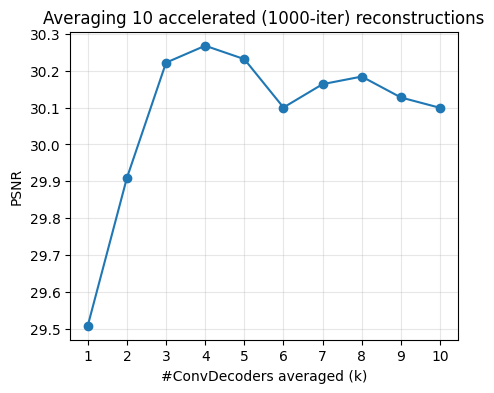

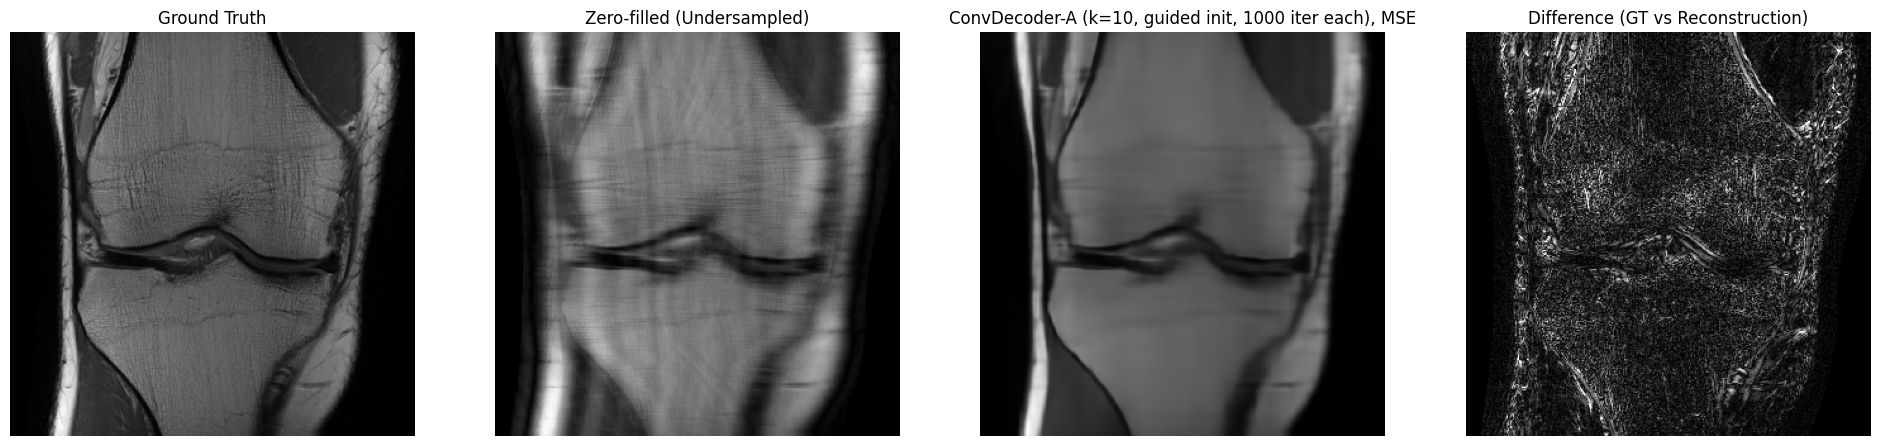

Mean abs difference: 0.0210   Max abs difference: 0.2992


In [34]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    kavg_stack = np.stack(kavg_recons, axis=0)  # magnitude stack, always available
    kavg_stack_complex = np.stack(kavg_recons_complex, axis=0)  # complex stack, for KAVG_AVERAGE_COMPLEX
    kavg_weights = kavg_member_weights(
        kavg_member_scores(kavg_recons, kavg_member_losses, KAVG_WEIGHT_BASIS),
        weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=KAVG_WEIGHT_EXPONENT)

    if KAVG_AVERAGE_COMPLEX:
        # Average in the complex domain (phase-coherent noise cancellation), then take
        # magnitude -- see KAVG_AVERAGE_COMPLEX's docstring in Section 2 for why this beats
        # averaging already-rectified magnitude images.
        rec_kavg = np.abs(kavg_weighted_average(kavg_stack_complex, kavg_weights))
    else:
        rec_kavg = kavg_weighted_average(kavg_stack, kavg_weights)

    _kavg_avg_desc = ('weighted, ' if KAVG_WEIGHTED_ENSEMBLE else '') + \
                      ('complex-domain' if KAVG_AVERAGE_COMPLEX else 'magnitude-domain')

    # Reproduce the paper's Fig. 5 style curve: PSNR of the running average as k grows from 1..K,
    # using the same weighting/domain choice as the final average above (re-normalized to the
    # first k members' weights each time).
    running_psnr = []
    running_grad_entropy = []  # no-reference sharpness proxy -- see gradient_entropy() docstring
    for k in range(1, len(kavg_recons) + 1):
        w_k = kavg_weights[:k] / kavg_weights[:k].sum()
        if KAVG_AVERAGE_COMPLEX:
            running_avg = np.abs(kavg_weighted_average(kavg_stack_complex[:k], w_k))
        else:
            running_avg = kavg_weighted_average(kavg_stack[:k], w_k)
        running_psnr.append(psnr(gt2, normalize(running_avg.astype(np.float64))))
        running_grad_entropy.append(gradient_entropy(running_avg))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(range(1, len(kavg_recons) + 1), running_psnr, marker='o', color='tab:blue')
    ax1.set_xlabel('#ConvDecoders averaged (k)')
    ax1.set_ylabel('PSNR (needs ground truth)')
    ax1.set_xticks(range(1, len(kavg_recons) + 1))
    ax1.grid(alpha=0.3)

    ax2.plot(range(1, len(kavg_recons) + 1), running_grad_entropy, marker='o', color='tab:orange')
    ax2.set_xlabel('#ConvDecoders averaged (k)')
    ax2.set_ylabel('Gradient entropy (no reference; lower = sharper)')
    ax2.set_xticks(range(1, len(kavg_recons) + 1))
    ax2.grid(alpha=0.3)

    fig.suptitle(f'Averaging {len(kavg_recons)} accelerated ({ACCEL_NUM_ITERS}-iter) reconstructions '
                 f'({_kavg_avg_desc}): PSNR (left, reference-based) vs. gradient entropy '
                 f'(right, no-reference)')
    plt.tight_layout()
    plt.show()

    # Sanity check for using gradient_entropy as a ground-truth-free stand-in for PSNR: if it's
    # a good proxy, entropy should move OPPOSITE to PSNR as k grows (PSNR up <-> entropy down).
    # Spearman rank correlation is used (not Pearson) since we only care whether the two rank k
    # values the same way, not a linear relationship between their raw scales.
    from scipy.stats import spearmanr
    if len(running_psnr) >= 3:
        _rho, _pval = spearmanr(running_psnr, running_grad_entropy)
        print(f"PSNR vs. gradient entropy across k: Spearman rho = {_rho:.3f} (p={_pval:.3f}) "
              f"-- expect rho near -1 if gradient entropy is a trustworthy no-reference stand-in "
              f"for PSNR on this image; near 0 (or positive) means it isn't tracking quality here.")

    show_full_comparison(gt_espirit2, zf_img_cropped2, rec_kavg,
                          f"ConvDecoder-A (k={len(kavg_recons)}, {KAVG_INIT_LABEL}, "
                          f"{ACCEL_NUM_ITERS} iter each, {_kavg_avg_desc}), {LOSS_LABEL}")
elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")

In [35]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    rec_kavg_n = normalize(rec_kavg.astype(np.float64))

    m_kavg = compute_all_metrics(gt2, rec_kavg_n)
    _kavg_init_label = KAVG_INIT_LABEL
    m_kavg.update(Architecture=ARCHITECTURE, Image=ref2['filename'],
                  Method=f'ConvDecoder-A (k={len(kavg_recons)}, {_kavg_init_label}, {ACCEL_NUM_ITERS} iter, '
                         f'{_kavg_avg_desc})',
                  Z_Source=Z_SOURCE, Loss_Type=LOSS_TYPE,
                  # ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT, not the bare HUBER_DELTA/TV_WEIGHT --
                  # every member here (trained or untrained) is fit with the accelerated
                  # regime's own hyperparameters (see Section 12.2), so logging the regular/
                  # random-init regime's values here was recording the wrong numbers.
                  Huber_Delta=ACCEL_HUBER_DELTA if LOSS_TYPE == "huber" else 'n/a', TV_Weight=ACCEL_TV_WEIGHT)

    kavg_results_df = pd.DataFrame([m_kavg])[meta_cols + metric_cols]
    # Deliberately not saved to disk -- this is a single-image sanity-check result (see Section
    # 2's note on Sections 7-9/12.2-12.4). Section 12.5's batch eval is the real, persisted result.

    # Direct comparison against this ensemble's own k=1 member -- a single accelerated fit,
    # guided from kavg_ref_filenames[0], same iteration budget, same eval image. This IS the
    # single-guided-init-fit comparison (no separate Run C cell needed for it).
    m_k1 = compute_all_metrics(gt2, normalize(kavg_recons[0].astype(np.float64)))
    delta_row = {
        metric: (m_kavg[metric] - m_k1[metric]) if metric not in ('NMSE', 'HFEN')
                else (m_k1[metric] - m_kavg[metric])   # sign-normalize: positive = k-averaging better
        for metric in metric_cols
    }
    _kavg_member0_guided = KAVG_NUM_GUIDED_MEMBERS > 0
    _k1_desc = (f"guided from {kavg_ref_checkpoints[0 % len(kavg_ref_checkpoints)]['filename']}"
                if _kavg_member0_guided else f"random init (seed={SEED + 1000})")
    print(f"ConvDecoder-A (k={len(kavg_recons)}) vs. its own k=1 member "
          f"(single accelerated fit, {_k1_desc}):")
    for metric in metric_cols:
        sign = '+' if delta_row[metric] >= 0 else ''
        print(f"  Δ{metric}: {sign}{delta_row[metric]:.4f}")

    display(kavg_results_df)
elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")

Saved ensemble-averaging result to /content/drive/MyDrive/Projects/results/kavg10_convdecoder_mri_vae.csv

ConvDecoder-A (k=10) vs. its own k=1 member (single accelerated fit guided from file1001077.h5):
  ΔPSNR: +0.5916
  ΔSSIM: +0.0217
  ΔMS-SSIM: +0.0108
  ΔVIF: +0.0139
  ΔNMSE: +0.0015
  ΔHFEN: +0.0606


,Architecture,Image,Method,Z_Source,Loss_Type,Huber_Delta,TV_Weight,PSNR,SSIM,MS-SSIM,VIF,NMSE,HFEN
0,convdecoder,file1000041.h5,"ConvDecoder-A (k=10, guided init, 1000 iter)",mri_vae,mse,n/a,0,30.099348,0.740018,0.932383,0.760552,0.010171,0.488351


### 12.3b Uncertainty Map + Reliability Check (this eval image)

In [ ]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS and COMPUTE_UNCERTAINTY_MAP:
    if len(kavg_recons) < 2:
        print(f"COMPUTE_UNCERTAINTY_MAP: only {len(kavg_recons)} ensemble member(s) -- need at "
              f"least 2 (K_VALUE > 1) to measure any spread. Skipping.")
    else:
        # Same per-member weights already used for rec_kavg itself (cell above) -- recomputed
        # here (not re-fit, just re-derived from kavg_recons/kavg_member_losses already in
        # memory) so this cell is safe to re-run on its own after only toggling
        # COMPUTE_UNCERTAINTY_MAP, without re-running the averaging cell above first.
        _umap_weights = kavg_member_weights(
            kavg_member_scores(kavg_recons, kavg_member_losses, KAVG_WEIGHT_BASIS),
            weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=KAVG_WEIGHT_EXPONENT)
        _umap_stack = (np.stack([normalize(r.astype(np.float64)) for r in kavg_recons], axis=0)
                       if UNCERTAINTY_MAP_NORMALIZE else kavg_stack)
        uncertainty_map = kavg_uncertainty_map(_umap_stack, _umap_weights)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
        axes[0].imshow(np.flipud(rec_kavg_n), cmap='gray')
        axes[0].set_title(f'ConvDecoder-A reconstruction (k={len(kavg_recons)})')
        axes[0].axis('off')
        im1 = axes[1].imshow(np.flipud(uncertainty_map), cmap='inferno')
        axes[1].set_title('Uncertainty map (weighted std across members)')
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        if CHECK_UNCERTAINTY_RELIABILITY:
            error_map = np.abs(gt2 - rec_kavg_n)
            im2 = axes[2].imshow(np.flipud(error_map), cmap='hot', vmin=0, vmax=DIFF_VMAX)
            axes[2].set_title('True error |GT - reconstruction| (for reference)')
            axes[2].axis('off')
            plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
        else:
            axes[2].axis('off')
            axes[2].set_title('(CHECK_UNCERTAINTY_RELIABILITY is False)')
        plt.tight_layout()
        plt.show()

        if CHECK_UNCERTAINTY_RELIABILITY:
            reliability = uncertainty_reliability(uncertainty_map, error_map,
                                                   n_bins=UNCERTAINTY_RELIABILITY_BINS)
            print(f"Uncertainty map reliability (this single image -- treat as illustrative; "
                  f"see Section 12.5b for a batch-aggregated version with real statistical "
                  f"weight):")
            print(f"  Pearson r  = {reliability['pearson_r']:.3f}  (p={reliability['pearson_p']:.3g})")
            print(f"  Spearman ρ = {reliability['spearman_rho']:.3f}  (p={reliability['spearman_p']:.3g})")
            print(f"  AUSE       = {reliability['ause']:.5f}  (0 = perfect ranking against true error; "
                  f"higher = worse)")

            fracs = np.linspace(0.0, 1.0, UNCERTAINTY_RELIABILITY_BINS + 1)
            plt.figure(figsize=(6, 4.2))
            plt.plot(fracs, reliability['sparsification_curve'], marker='o', label='by predicted uncertainty')
            plt.plot(fracs, reliability['oracle_curve'], marker='o', linestyle='--', color='gray',
                     label='oracle (by true error)')
            plt.xlabel('fraction of most-uncertain pixels removed')
            plt.ylabel('MSE of remaining pixels')
            plt.title(f'Sparsification curve (AUSE={reliability["ause"]:.5f})')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
elif K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    print("COMPUTE_UNCERTAINTY_MAP is False -- skipping (Section 2).")
elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")


### 12.4 Qualitative benefit of averaging: k=1 vs. k=`K_VALUE`

Direct visual comparison between a single accelerated (guided-init, 1,000-iteration) fit — the same ensemble's own $k{=}1$ member — and the full $k$-averaged ConvDecoder-A reconstruction, so the averaging benefit is visible, not just numeric.

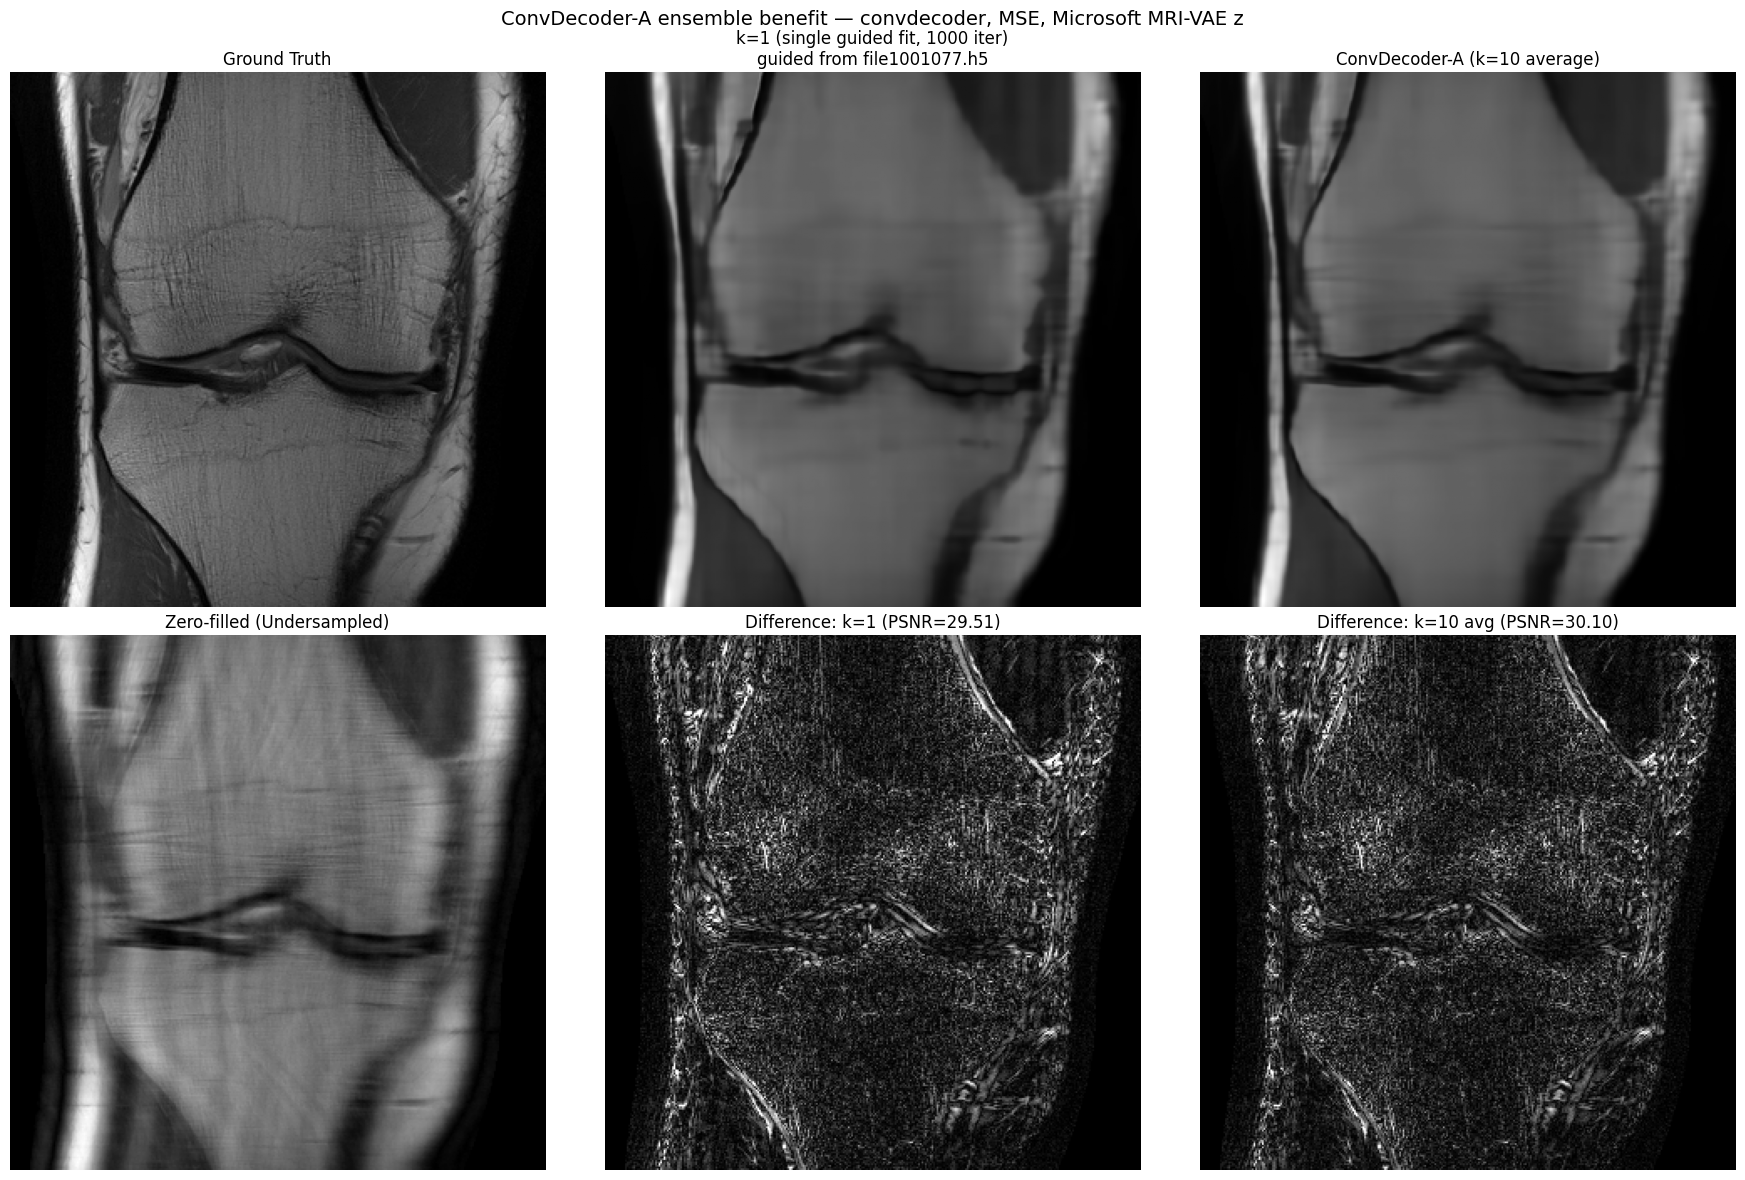

PSNR:    k=1 = 29.5078   ->   k=10 avg = 30.0993   (Δ = +0.5916)
SSIM:    k=1 = 0.7183   ->   k=10 avg = 0.7400   (Δ = +0.0217)


In [36]:
if K_AVERAGING and KAVG_BUILD_REF_CHECKPOINTS:
    rec_k1_n = normalize(kavg_recons[0].astype(np.float64))
    gt_n2 = normalize(gt_espirit2)

    diff_k1 = np.abs(gt_n2 - rec_k1_n)
    diff_kavg = np.abs(gt_n2 - rec_kavg_n)

    # np.flipud(...) only for display -- see note in show_difference() (Section 5) above.
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    axes[0, 0].imshow(np.flipud(gt_espirit2), cmap='gray')
    axes[0, 0].set_title('Ground Truth'); axes[0, 0].axis('off')

    axes[0, 1].imshow(np.flipud(kavg_recons[0]), cmap='gray')
    _kavg_member0_guided = KAVG_NUM_GUIDED_MEMBERS > 0
    _k1_subtitle = (f"guided from {kavg_ref_checkpoints[0 % len(kavg_ref_checkpoints)]['filename']}"
                     if _kavg_member0_guided else f'random init (seed={SEED + 1000})')
    axes[0, 1].set_title(f'k=1 (single {"guided" if _kavg_member0_guided else "random-init"} fit, '
                          f'{ACCEL_NUM_ITERS} iter)\n{_k1_subtitle}')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(np.flipud(rec_kavg), cmap='gray')
    axes[0, 2].set_title(f'ConvDecoder-A (k={len(kavg_recons)} average)')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(np.flipud(zf_img_cropped2), cmap='gray')
    axes[1, 0].set_title('Zero-filled (Undersampled)'); axes[1, 0].axis('off')

    axes[1, 1].imshow(np.flipud(diff_k1), cmap='gray', vmin=0, vmax=DIFF_VMAX)
    axes[1, 1].set_title(f'Difference: k=1 (PSNR={m_k1["PSNR"]:.2f})'); axes[1, 1].axis('off')

    axes[1, 2].imshow(np.flipud(diff_kavg), cmap='gray', vmin=0, vmax=DIFF_VMAX)
    axes[1, 2].set_title(f'Difference: k={len(kavg_recons)} avg (PSNR={m_kavg["PSNR"]:.2f})'); axes[1, 2].axis('off')

    plt.suptitle(f'ConvDecoder-A ensemble benefit \u2014 {ARCHITECTURE}, {LOSS_LABEL}, {Z_LABEL}', fontsize=14)
    plt.tight_layout()
    plt.show()

    psnr_k1, psnr_kavg = m_k1['PSNR'], m_kavg['PSNR']
    ssim_k1, ssim_kavg = m_k1['SSIM'], m_kavg['SSIM']
    print(f"PSNR:    k=1 = {psnr_k1:.4f}   ->   k={len(kavg_recons)} avg = {psnr_kavg:.4f}   (\u0394 = {psnr_kavg - psnr_k1:+.4f})")
    print(f"SSIM:    k=1 = {ssim_k1:.4f}   ->   k={len(kavg_recons)} avg = {ssim_kavg:.4f}   (\u0394 = {ssim_kavg - ssim_k1:+.4f})")

elif K_AVERAGING:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-reference fitting this run).")

### 12.5 Batch evaluation across `KAVG_BATCH_SIZE` images (paper-style mean ± std)

Respects `KAVG_INIT_MODE`/`KAVG_GUIDED_REF_MODE`/`KAVG_MIXED_GUIDED_COUNT` (Section 2), same as 12.1-12.4: for `"guided"` members this reuses the `K_VALUE` (or fewer, in `"single_image"` mode) reference checkpoints fit/loaded in 12.1 above — no reference refitting here, regardless of `RUN_MODE` (same permanent-cache behavior as the single-image evaluation). For each of `KAVG_BATCH_SIZE` new evaluation images (auto-discovered, excluding the reference source images themselves and the single image evaluated in 12.3/12.4 above — guiding a fit from its own reference checkpoint would trivially inflate that image's metrics), this fits `K_VALUE` accelerated (`ACCEL_NUM_ITERS`-iteration) reconstructions and averages them, exactly like 12.2/12.3 but looped over images -- each member guided or random-init per `KAVG_INIT_MODE` (own checkpoint dir/results CSV per combination, so different modes' results never mix). Each accelerated fit is itself cached per (image, member), so a disconnect only costs the fits since the last checkpoint, not the whole batch.

**Cost:** on an A100 (~10 min per 10k-iteration fit ⇒ ~1 min per accelerated 1,000-iteration fit), `KAVG_BATCH_SIZE=20` × `K_VALUE=10` = 200 accelerated fits ≈ 3h20m, since the reference checkpoints are already cached and reused as-is.

Set `RUN_BATCH_EVAL = True` in Section 2 to run this section.

In [37]:
if K_AVERAGING and RUN_BATCH_EVAL:
    assert_run_tag_current()
    # Only kavg_ref_filenames (the reference image NAMES, from Section 12's preamble cell) is
    # actually used below -- kavg_ref_checkpoints (the FITTED weights, Section 12.1) is not needed
    # just to select batch targets, so this doesn't force you through K reference fits for a new
    # config if all you want from this config is Section 13's Run A/B/C batch eval.
    assert 'kavg_ref_filenames' in dir(), (
        "kavg_ref_filenames not found -- run Section 12's preamble cell (kavg01code) first, which "
        "only selects reference image names and does no fitting."
    )

    # Prune any manually-flagged images (KAVG_BATCH_MANUAL_EXCLUDE, set in Section 2) out of an
    # existing results CSV -- lets you drop a qualitatively-bad image after the fact and have a
    # replacement auto-selected below, without hand-editing the CSV.
    _batch_results_path_check = f"{RESULTS_DIR}/kavg_batch_{RUN_TAG}.csv"
    if KAVG_BATCH_MANUAL_EXCLUDE and os.path.exists(_batch_results_path_check):
        _df = pd.read_csv(_batch_results_path_check)
        _before = len(_df)
        _df = _df[~_df['Image'].isin(KAVG_BATCH_MANUAL_EXCLUDE)]
        if len(_df) != _before:
            _df.to_csv(_batch_results_path_check, index=False)
            print(f"Pruned {_before - len(_df)} manually-excluded image(s) from "
                  f"{_batch_results_path_check}: {sorted(KAVG_BATCH_MANUAL_EXCLUDE)}")

    # Exclude the K reference source images themselves (guiding a fit from its own reference
    # checkpoint would trivially near-perfectly reconstruct that image and inflate its metrics),
    # the single image already evaluated in 12.3/12.4 above, any manually-flagged images
    # (KAVG_BATCH_MANUAL_EXCLUDE), and Section 6.5's tuning-image set. That last one is read
    # straight from Drive (not an in-memory TUNING_FILENAMES variable) so it works even in a
    # fresh runtime after a disconnect where Section 6.5 was never re-run this session -- a
    # session-memory-only check would have nothing to exclude against in that case, and could
    # silently evaluate on images the loss hyperparameters were tuned on.
    _tuning_filenames_path = f"{SELECTIONS_DIR}/tuning_filenames.json"
    if os.path.exists(_tuning_filenames_path):
        with open(_tuning_filenames_path) as f:
            _tuning_exclude = set(json.load(f)['filenames'])
    else:
        _tuning_exclude = set()
    exclude_from_batch = (set(kavg_ref_filenames) | {EVAL_TARGET_FILENAME}
                           | set(KAVG_BATCH_MANUAL_EXCLUDE) | _tuning_exclude)
    if _tuning_exclude:
        print(f"Excluding {len(_tuning_exclude)} tuning image(s) (loaded from "
              f"{_tuning_filenames_path}) from this evaluation batch: {sorted(_tuning_exclude)}")

    with h5py.File(os.path.join(folder, kavg_ref_filenames[0]), 'r') as f:
        target_acquisition = f.attrs.get('acquisition')
        target_num_coils = f['kspace'].shape[1]

    # Persisted cache of files already found unreadable/corrupted or ESPIRiT-preflight-incapable
    # (NOT the acquisition/coil-count mismatch below -- that's a normal per-run filter against
    # THIS config's target, not a defect of the file, so it stays a live check every time and is
    # never cached). Both cached failure modes are intrinsic to the file's own data, independent
    # of ARCHITECTURE/Z_SOURCE/which image is currently the eval target, so this is safe to share
    # across every run/config rather than being scoped by RUN_TAG. Without this, a large folder
    # with a handful of bad files pays their full (often expensive, ESPIRiT-calibration-costing)
    # preflight check again on every single re-run of this cell.
    _bad_batch_files_path = f"{SELECTIONS_DIR}/kavg_batch_bad_files.json"
    if os.path.exists(_bad_batch_files_path):
        with open(_bad_batch_files_path) as f:
            known_bad_files = json.load(f)  # {filename: reason}
    else:
        known_bad_files = {}

    # KAVG_BATCH_KEEP_FIXED_SET (Section 2): reuse the SAME evaluation batch across runs instead
    # of letting it silently drift -- it can otherwise change between runs because it depends on
    # kavg_ref_filenames (which reference images got drawn) and the tuning-image exclusion set,
    # both of which can themselves change. Comparisons between different toggles/configs (LR
    # schedule, complex/weighted averaging, init mode, etc.) are only meaningful if every run
    # evaluates the exact same images.
    KAVG_BATCH_SELECTION_PATH = f"{SELECTIONS_DIR}/kavg_batch_selection_{RUN_TAG}_n{KAVG_BATCH_SIZE}.json"
    batch_target_filenames = []
    if KAVG_BATCH_KEEP_FIXED_SET and os.path.exists(KAVG_BATCH_SELECTION_PATH):
        with open(KAVG_BATCH_SELECTION_PATH) as f:
            _cached_batch = json.load(f)
        # Still respect exclusions that may have been added/discovered SINCE this set was saved
        # -- manual excludes, tuning images, and newly-known-bad files are dropped even from a
        # cached selection; the loop below then backfills replacements to reach KAVG_BATCH_SIZE
        # again, same as the CSV-pruning/backfill behavior above.
        batch_target_filenames = [f for f in _cached_batch
                                   if f not in exclude_from_batch and f not in known_bad_files]
        _n_dropped = len(_cached_batch) - len(batch_target_filenames)
        if _n_dropped:
            print(f"Loaded fixed batch selection from {KAVG_BATCH_SELECTION_PATH}, but dropped "
                  f"{_n_dropped} image(s) now excluded/known-bad -- backfilling replacements below.")
        else:
            print(f"Reusing fixed batch selection from {KAVG_BATCH_SELECTION_PATH} "
                  f"({len(batch_target_filenames)} images). Set KAVG_BATCH_KEEP_FIXED_SET=False "
                  f"(or delete this file) to allow a fresh selection.")
    elif KAVG_BATCH_KEEP_FIXED_SET:
        print(f"KAVG_BATCH_KEEP_FIXED_SET is True but no saved selection found at "
              f"{KAVG_BATCH_SELECTION_PATH} yet -- selecting now and saving it for future runs.")

    _n_known_bad_before = len(known_bad_files)
    _n_skipped_from_cache = 0

    for fname in all_files:
        if len(batch_target_filenames) >= KAVG_BATCH_SIZE:
            break
        if fname in exclude_from_batch or fname in batch_target_filenames:
            continue
        if fname in known_bad_files:
            _n_skipped_from_cache += 1
            continue
        try:
            with h5py.File(os.path.join(folder, fname), 'r') as f:
                if (f.attrs.get('acquisition') != target_acquisition
                        or f['kspace'].shape[1] != target_num_coils):
                    continue
                # Touch k-space shape to catch files whose header passes but whose data object
                # is malformed, before a long batch run starts.
                _ = f['kspace'].shape
        except (OSError, KeyError) as e:
            reason = f"unreadable/corrupted: {e}"
            print(f"  SKIPPED {fname} ({reason})")
            known_bad_files[fname] = reason
            continue
        # Preflight the exact middle slice and ESPIRiT setup now. A failed candidate is
        # replaced immediately by the next eligible file, so the resulting list still has N images.
        try:
            with h5py.File(os.path.join(folder, fname), 'r') as f:
                _slice = f['kspace'][f['kspace'].shape[0] // 2]
            _ri = np.stack((_slice.real, _slice.imag), axis=-1)
            _ksp = torch.from_numpy(_ri)
            _net = build_network({'output_depth': _ksp.shape[0] * 2,
                                  'out_size': tuple(_ksp.shape[1:-1])})
            set_seed(SEED)
            _ = build_undersampled(_ksp, _slice, _net)
        except (OSError, KeyError, EspiritCalibrationError, ValueError) as e:
            reason = f"preflight failed ({type(e).__name__}): {e}"
            print(f"  SKIPPED {fname} ({reason})")
            known_bad_files[fname] = reason
            continue
        batch_target_filenames.append(fname)

    if len(known_bad_files) != _n_known_bad_before:
        with open(_bad_batch_files_path, "w") as f:
            json.dump(known_bad_files, f, indent=1)
        print(f"  Saved {len(known_bad_files) - _n_known_bad_before} newly-found bad file(s) to "
              f"{_bad_batch_files_path} ({len(known_bad_files)} total cached) -- future runs skip "
              f"them without re-checking.")
    if _n_skipped_from_cache:
        print(f"  Skipped {_n_skipped_from_cache} previously-known-bad file(s) from cache "
              f"({_bad_batch_files_path}) without re-checking.")

    assert len(batch_target_filenames) >= KAVG_BATCH_SIZE, (
        f"Only found {len(batch_target_filenames)} eligible batch targets in {folder}, need "
        f"{KAVG_BATCH_SIZE}. Add more files to the Drive folder or lower KAVG_BATCH_SIZE in Section 2."
    )

    if KAVG_BATCH_KEEP_FIXED_SET:
        with open(KAVG_BATCH_SELECTION_PATH, "w") as f:
            json.dump(batch_target_filenames, f, indent=1)
        print(f"Saved batch selection to {KAVG_BATCH_SELECTION_PATH} for reuse by future runs "
              f"(as long as KAVG_BATCH_KEEP_FIXED_SET stays True).")

    print(f"Batch evaluation targets ({len(batch_target_filenames)}): {batch_target_filenames}")
else:
    print("RUN_BATCH_EVAL is False (or K_AVERAGING is False) -- skipping batch evaluation. "
          "Set K_AVERAGING = True and RUN_BATCH_EVAL = True in Section 2 to run it.")


RUN_BATCH_EVAL is False (or K_AVERAGING is False) -- skipping batch evaluation. Set K_AVERAGING = True and RUN_BATCH_EVAL = True in Section 2 to run it.


In [38]:
if K_AVERAGING and RUN_BATCH_EVAL and KAVG_BUILD_REF_CHECKPOINTS:
    assert_run_tag_current()

    # Discriminated by ACCEL_LOSS_TAG (ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT), NOT KAVG_TAG/RUN_TAG --
    # same fix/reasoning KAVG_ACC_TAG used to need in Section 12.1/12.2 (these are also
    # accelerated fits, built with the ACCEL_* hyperparameters).
    KAVG_BATCH_ACC_TAG = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    KAVG_BATCH_ACC_CKPT_DIR = f"{CKPT_ROOT}/checkpoints_multicoil_{KAVG_BATCH_ACC_TAG}_batch_acc"
    os.makedirs(KAVG_BATCH_ACC_CKPT_DIR, exist_ok=True)

    # Own tag/dir for the untrained (random-init) regime -- same reasoning as
    # KAVG_UNTRAINED_ACC_TAG used to need in Section 12.1/12.2: a random-init-then-fit member and a
    # guided-init-then-fit member are different models even under identical config, so they
    # must never share a checkpoint path.
    KAVG_BATCH_UNTRAINED_ACC_TAG = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    KAVG_BATCH_UNTRAINED_ACC_CKPT_DIR = f"{CKPT_ROOT}/checkpoints_multicoil_{KAVG_BATCH_UNTRAINED_ACC_TAG}_untrained_batch_acc"
    os.makedirs(KAVG_BATCH_UNTRAINED_ACC_CKPT_DIR, exist_ok=True)

    # Keyed by RUN_TAG only (not by the current KAVG_BATCH_SIZE) so a small test-run's
    # completed images accumulate into later larger runs instead of starting over. Suffixed by
    # init mode (same scheme as KAVG_TAG in Section 12.1) so different KAVG_INIT_MODE/
    # KAVG_GUIDED_REF_MODE combos can never collide in the same CSV -- toggling between them and
    # re-running this cell would otherwise silently treat a different regime's completed images
    # as "already done" and mix incompatible results into one file. "" for the original guided +
    # different_images combo, so pre-existing results keep resolving under their old name.
    if KAVG_INIT_MODE == "random":
        _kavg_batch_untrained_suffix = "_untrained"
    elif KAVG_INIT_MODE == "guided":
        _kavg_batch_untrained_suffix = "" if KAVG_GUIDED_REF_MODE == "different_images" else "_singleref"
    else:  # "mixed"
        _kavg_batch_untrained_suffix = (f"_mixed{KAVG_NUM_GUIDED_MEMBERS}"
                                         + ("" if KAVG_GUIDED_REF_MODE == "different_images" else "_singleref"))

    # Same reasoning as _kavg_batch_untrained_suffix above -- the averaging domain/weighting
    # scheme is applied AFTER member fits are loaded/reused (fitting itself doesn't depend on
    # it, so member checkpoints are correctly still reusable across this toggle), but the
    # PER-IMAGE RESULTS ROW does depend on it. Without this in the results filename, flipping
    # KAVG_AVERAGE_COMPLEX/KAVG_WEIGHTED_ENSEMBLE and re-running would find every target image
    # already present in `already_done` (same K/tag/run) and skip recomputing them entirely --
    # silently leaving the OLD averaging mode's results in place instead of ever running the new
    # one, even though nothing on screen indicates a skip happened for the "wrong" reason.
    # KAVG_WEIGHT_EXPONENT only appended when KAVG_WEIGHTED_ENSEMBLE is True -- it's a genuine
    # no-op on the resulting average when unweighted (see kavg_member_weights' docstring), so
    # tagging it in that case would fragment/orphan otherwise-identical unweighted results
    # across pointless separate files every time someone nudges the exponent field. When
    # weighted, this is REQUIRED (not just nice-to-have): without it, changing
    # KAVG_WEIGHT_EXPONENT and re-running this cell would find every target image already in
    # `already_done` (same K/tag/run/avg-mode) and skip recomputing all of them -- silently
    # leaving the OLD exponent's results in the CSV/summary below forever, with nothing on
    # screen indicating a skip happened for the "wrong" reason. (Root-caused via
    # FIND_EXPONENT_PARAMETERS, Section 12.6, disagreeing with this cell's own stale summary.)
    _kavg_batch_avg_suffix = (('_complex' if KAVG_AVERAGE_COMPLEX else '')
                               + ('_weighted' if KAVG_WEIGHTED_ENSEMBLE else '')
                               + (f'_exp{KAVG_WEIGHT_EXPONENT:g}' if KAVG_WEIGHTED_ENSEMBLE else '')
                               # KAVG_WEIGHT_BASIS only appended for the non-default "sharpness"
                               # basis, and only when it actually affects anything -- same
                               # collision-avoidance reasoning as KAVG_WEIGHT_EXPONENT just above:
                               # without this, switching KAVG_WEIGHT_BASIS and re-running would
                               # find every image already in `already_done` (same K/tag/run/exp)
                               # and silently skip recomputing all of them under the new basis.
                               + ('_bysharpness' if (KAVG_WEIGHTED_ENSEMBLE and KAVG_WEIGHT_BASIS == 'sharpness') else ''))

    # RUN_TAG (baked into batch_results_path below) encodes LOSS_TAG -- the FULL/random-init
    # regime's HUBER_DELTA/TV_WEIGHT -- even though every fit in THIS cell is accelerated/
    # guided-init and actually uses ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT (ACCEL_LOSS_TAG). The
    # member checkpoints themselves are correctly keyed by ACCEL_LOSS_TAG (KAVG_BATCH_ACC_TAG
    # above), but without this, the RESULTS file would not be: toggling
    # USE_SEPARATE_ACCEL_PARAMS (or hand-editing ACCEL_HUBER_DELTA/ACCEL_TV_WEIGHT) while
    # HUBER_DELTA/TV_WEIGHT stay fixed would silently collide two genuinely different
    # accelerated-regime results onto the same CSV -- re-running after switching back would
    # find the OTHER config's results already in `already_done` and never recompute, same
    # failure mode as the KAVG_WEIGHT_EXPONENT bug just above. Empty in the common case
    # (USE_SEPARATE_ACCEL_PARAMS=False, ACCEL_* mirrors HUBER_DELTA/TV_WEIGHT exactly, so
    # ACCEL_LOSS_TAG == LOSS_TAG already, already covered by RUN_TAG) -- only appears once the
    # two regimes' loss hyperparameters actually diverge.
    _kavg_batch_accel_suffix = f"_accel{ACCEL_LOSS_TAG}" if ACCEL_LOSS_TAG != LOSS_TAG else ""

    if BATCH_FRESH_START:
        # Deliberately NOT resuming/accumulating and NOT touching the legacy import below --
        # each fresh-start run gets its own separately-numbered file (next_versioned_path()
        # bumps _v2/_v3/... if a previous fresh-start run's file is still there), so re-running
        # after a code tweak the tags don't capture never mixes with stale results either from
        # the normal accumulator OR from an earlier fresh-start run.
        batch_results_path = next_versioned_path(
            f"{RESULTS_DIR}/kavg_batch_k{K_VALUE}_{RUN_TAG}{_kavg_batch_untrained_suffix}"
            f"{_kavg_batch_accel_suffix}{_kavg_batch_avg_suffix}_fresh.csv"
        )
        batch_rows = []
        already_done = set()
        print(f"BATCH_FRESH_START is True -- starting a brand-new batch run at "
              f"{batch_results_path} (ignoring any previously accumulated results).")
    else:
        batch_results_path = (f"{RESULTS_DIR}/kavg_batch_k{K_VALUE}_{RUN_TAG}"
                               f"{_kavg_batch_untrained_suffix}{_kavg_batch_accel_suffix}"
                               f"{_kavg_batch_avg_suffix}.csv")
        legacy_batch_results_path = f"{RESULTS_DIR}/kavg_batch_{RUN_TAG}.csv"
        # Import a legacy results file only when every fitted row explicitly reports this K --
        # and only for the original guided + different_images regime, since the legacy path
        # predates KAVG_INIT_MODE entirely (every legacy result is implicitly guided-init, one
        # distinct reference image per member) -- and only for the default averaging mode
        # (magnitude, unweighted), since the legacy path also predates
        # KAVG_AVERAGE_COMPLEX/KAVG_WEIGHTED_ENSEMBLE entirely.
        if (KAVG_INIT_MODE == "guided" and KAVG_GUIDED_REF_MODE == "different_images"
                and not KAVG_AVERAGE_COMPLEX and not KAVG_WEIGHTED_ENSEMBLE
                and not os.path.exists(batch_results_path)
                and os.path.exists(legacy_batch_results_path)):
            _legacy_df = pd.read_csv(legacy_batch_results_path)
            _legacy_methods = _legacy_df.get('Method', pd.Series(dtype=str)).astype(str)
            if len(_legacy_df) and _legacy_methods.str.contains(fr"\(k={K_VALUE},", regex=True).all():
                _legacy_df.to_csv(batch_results_path, index=False)
                print(f"Imported compatible legacy results into {batch_results_path}")
            elif len(_legacy_df):
                print(f"Ignoring {legacy_batch_results_path}: it is not explicitly a k={K_VALUE} result set.")

        # Resume support: if a prior (possibly crashed/disconnected) run already wrote partial
        # results, reload them and skip any image already completed instead of redoing it.
        if os.path.exists(batch_results_path):
            batch_results_df = pd.read_csv(batch_results_path)
            batch_rows = batch_results_df.to_dict('records')
            already_done = set(batch_results_df['Image'])
            print(f"Resuming from {batch_results_path}: {len(already_done)} image(s) already completed.")
        else:
            batch_rows = []
            already_done = set()

    # KAVG_SWEEP_EXPONENT_DURING_FIT (Section 2): its own separate log, deliberately NOT sharing
    # batch_results_path's resume/already_done set -- an image already marked done there (and
    # so skipped below before ever reaching the member loop) has no member_recons in scope this
    # run, so this can only ever cover images actually processed THIS run. Use
    # BATCH_FRESH_START=True for full sweep coverage across every target image in one pass.
    if KAVG_SWEEP_EXPONENT_DURING_FIT:
        KAVG_EXPONENT_SWEEP_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
        exponent_sweep_path = (f"{RESULTS_DIR}/kavg_batch_k{K_VALUE}_{RUN_TAG}"
                                f"{_kavg_batch_untrained_suffix}{_kavg_batch_accel_suffix}"
                                f"{'_complex' if KAVG_AVERAGE_COMPLEX else ''}_exponent_sweep.csv")
        if os.path.exists(exponent_sweep_path) and not BATCH_FRESH_START:
            exponent_sweep_rows = pd.read_csv(exponent_sweep_path).to_dict('records')
            print(f"KAVG_SWEEP_EXPONENT_DURING_FIT: resuming log from {exponent_sweep_path} "
                  f"({len(exponent_sweep_rows)} row(s) already present).")
        else:
            exponent_sweep_rows = []

    skipped = []

    for img_idx, target_fname in enumerate(batch_target_filenames):
        # An image already done in the MAIN csv but still missing its exponent-sweep row (e.g.
        # KAVG_SWEEP_EXPONENT_DURING_FIT just got turned on against a batch that already fully
        # completed without it) must NOT be skipped here -- it still needs the member loop below
        # (reloaded from cache, not refit, since RUN_MODE='load_existing' finds those same
        # checkpoints) purely to backfill its sweep row. The main-result append+save further
        # down is separately guarded by `target_fname not in already_done` so this never
        # duplicates an already-saved main row.
        _sweep_still_needed = (KAVG_SWEEP_EXPONENT_DURING_FIT
                                and target_fname not in {r['Image'] for r in exponent_sweep_rows})
        if target_fname in already_done and not _sweep_still_needed:
            print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} "
                  f"-- already completed, skipping ===")
            continue

        if target_fname in already_done:
            print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} "
                  f"-- main result already completed; reloading cached members just to backfill "
                  f"the exponent sweep ===")
        else:
            print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} ===")

        try:
            with h5py.File(os.path.join(folder, target_fname), 'r') as f:
                slicenu_t = f["kspace"].shape[0] // 2
                slice_ksp_t = f['kspace'][slicenu_t]
                data_t = np.stack((slice_ksp_t.real, slice_ksp_t.imag), axis=-1)
        except (OSError, KeyError) as e:
            print(f"  SKIPPED {target_fname} (unreadable/corrupted file): {type(e).__name__}: {e}")
            skipped.append(target_fname)
            continue

        ksp_tt_t = torch.from_numpy(data_t)
        output_depth_t = ksp_tt_t.numpy().shape[0] * 2
        out_size_t = ksp_tt_t.numpy().shape[1:-1]

        # Same recipe as Section 8's u2 setup (build_undersampled), applied to this batch image.
        try:
            net_for_scale_t = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
            set_seed(SEED)
            u_t = build_undersampled(ksp_tt_t, slice_ksp_t, net_for_scale_t)
        except (EspiritCalibrationError, ReconstructionDivergedError) as e:
            print(f"  SKIPPED {target_fname} (ESPIRiT calibration failed): {e}")
            skipped.append(target_fname)
            continue
        gt_t = normalize(u_t['gt_espirit'].astype(np.float64))

        # The whole ensemble-member loop below is wrapped so that if ANY member's fit()
        # diverges (ReconstructionDivergedError), the WHOLE IMAGE is abandoned and skipped --
        # same granularity as an ESPIRiT calibration failure above -- rather than silently
        # averaging in a diverged member's garbage reconstruction, or crashing the batch cell.
        try:
            member_recons = []
            member_recons_complex = []
            member_losses = []
            for idx in range(K_VALUE):
                member_is_guided = idx < KAVG_NUM_GUIDED_MEMBERS

                if member_is_guided:
                    # kavg_ref_checkpoints has length KAVG_NUM_REF_IMAGES_NEEDED (Section 12.1)
                    # -- for "different_images" this is one distinct entry per guided member
                    # (the modulo is then a no-op); for "single_image" it's a length-1 list, so
                    # every guided member shares that one entry via the modulo.
                    ckpt_i = kavg_ref_checkpoints[idx % len(kavg_ref_checkpoints)]
                    ref_fname = ckpt_i['filename']
                    if KAVG_GUIDED_REF_MODE == "different_images":
                        # Unchanged from before KAVG_INIT_MODE existed -- ref_fname alone is
                        # already unique per member in this mode (K distinct reference images).
                        stable_member_ckpt_path = (
                            f"{KAVG_BATCH_ACC_CKPT_DIR}/target_{stable_stem(target_fname)}"
                            f"__ref_{stable_stem(ref_fname)}.pt"
                        )
                    else:
                        # "single_image" -- ref_fname is the SAME for every guided member, so
                        # idx must be in the path too, or every guided member would collide on
                        # one checkpoint file.
                        stable_member_ckpt_path = (
                            f"{KAVG_BATCH_ACC_CKPT_DIR}/target_{stable_stem(target_fname)}"
                            f"__idx{idx}__ref_{stable_stem(ref_fname)}.pt"
                        )
                    legacy_member_ckpt_path = (
                        f"{KAVG_BATCH_ACC_CKPT_DIR}/acc_img{img_idx}_{target_fname}_ref{idx}_{ref_fname}.pt"
                    )
                    member_ckpt_path = first_existing_path(stable_member_ckpt_path, legacy_member_ckpt_path)

                    if RUN_MODE == "load_existing" and member_ckpt_path is not None:
                        print(f"    [{idx+1}/{K_VALUE}] guided: loading cached fit: {member_ckpt_path}")
                        acc_ckpt = load_checkpoint_guarded(
                            member_ckpt_path, target_filename=target_fname, source_filename=ref_fname,
                            num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                            expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                            early_stop_method=EARLY_STOP_METHOD, use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                            # no seed= guard -- guided-init, own init seed gets overwritten by
                            # load_state_dict() right after construction (see cell 42's note).
                        )
                        net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                                 seed=acc_ckpt.get('seed', SEED))
                        net_acc.load_state_dict(acc_ckpt['model_state_dict'])
                        if acc_ckpt.get('freq_frac') is not None:
                            net_acc.set_freq_frac(acc_ckpt['freq_frac'])
                        ni_acc = acc_ckpt['net_input']
                        scaling_factor_acc = acc_ckpt['scaling_factor']
                        net_acc.final_loss = acc_ckpt.get('final_loss', float('inf'))
                    else:
                        member_ckpt_path = stable_member_ckpt_path
                        print(f"    [{idx+1}/{K_VALUE}] guided from {ref_fname}: fitting {ACCEL_NUM_ITERS} iterations")
                        net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
                        net_acc.load_state_dict(ckpt_i['model_state_dict'])  # guided init from ensemble member idx
                        # Same explicit deterministic z-seed as the single-image path (Section 12.1) --
                        # see its comment for the full rationale and the "+2000+idx" offset choice.
                        guided_z_seed = SEED + 2000 + idx
                        set_seed(guided_z_seed)
                        ni_acc = get_z(u_t['zf_complex_cropped'])
                        scaling_factor_acc, ni_acc = get_scale_factor(net_acc, num_channels, in_size,
                                                                        u_t['masked_kspace'], u_t['mps'], ni=ni_acc)
                        unders_measurement_acc = Variable((u_t['masked_kspace'] * scaling_factor_acc)[None, :]).type(dtype)

                        _, net_acc_fitted = fit(
                            net=net_acc,
                            img_noisy_var=unders_measurement_acc,
                            num_channels=num_channels,
                            net_input=ni_acc,
                            apply_f=forwardm,
                            mask=u_t['mask2d'],
                            mask1d=u_t['mask1d'],
                            scaling_factor=scaling_factor_acc,
                            num_iter=ACCEL_NUM_ITERS,
                            LR=0.01,
                            checkpoint_dir=None,
                            huber_delta=ACCEL_HUBER_DELTA,   # accelerated/guided-init regime's hyperparameters
                            tv_weight=ACCEL_TV_WEIGHT,
                        )
                        net_acc = net_acc_fitted

                        torch.save({
                            'model_state_dict': net_acc.state_dict(),
                            'freq_frac': net_acc.get_freq_frac(),
                            'net_input': ni_acc, 'mask1d': u_t['mask1d'], 'mask2d': u_t['mask2d'],
                            'scaling_factor': scaling_factor_acc,
                            **checkpoint_metadata(source_filename=ref_fname, target_filename=target_fname,
                                                  num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                                                  checkpoint_role='k_batch_member',
                                                  huber_delta=ACCEL_HUBER_DELTA if LOSS_TYPE == "huber" else None,
                                                  tv_weight=ACCEL_TV_WEIGHT, final_loss=net_acc.final_loss),
                        }, member_ckpt_path)
                        print(f"    [{idx}] guided from {ref_fname}: fit + saved {member_ckpt_path}")
                else:
                    member_seed = SEED + 1000 + idx
                    stable_member_ckpt_path = (
                        f"{KAVG_BATCH_UNTRAINED_ACC_CKPT_DIR}/target_{stable_stem(target_fname)}"
                        f"__member_{idx}.pt"
                    )
                    member_ckpt_path = stable_member_ckpt_path if os.path.exists(stable_member_ckpt_path) else None

                    if RUN_MODE == "load_existing" and member_ckpt_path is not None:
                        print(f"    [{idx+1}/{K_VALUE}] random-init: loading cached fit: {member_ckpt_path}")
                        untrained_ckpt = load_checkpoint_guarded(
                            member_ckpt_path, target_filename=target_fname,
                            num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                            expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                            seed=member_seed, early_stop_method=EARLY_STOP_METHOD,
                            use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                        )
                        net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                                 seed=untrained_ckpt.get('seed', member_seed))
                        net_acc.load_state_dict(untrained_ckpt['model_state_dict'])
                        if untrained_ckpt.get('freq_frac') is not None:
                            net_acc.set_freq_frac(untrained_ckpt['freq_frac'])
                        ni_acc = untrained_ckpt['net_input']
                        scaling_factor_acc = untrained_ckpt['scaling_factor']
                        net_acc.final_loss = untrained_ckpt.get('final_loss', float('inf'))
                    else:
                        member_ckpt_path = stable_member_ckpt_path
                        print(f"    [{idx+1}/{K_VALUE}] random-init (seed={member_seed}): "
                              f"fitting {ACCEL_NUM_ITERS} iterations")
                        net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                                 seed=member_seed)
                        ni_acc = get_z(u_t['zf_complex_cropped'])
                        scaling_factor_acc, ni_acc = get_scale_factor(net_acc, num_channels, in_size,
                                                                        u_t['masked_kspace'], u_t['mps'], ni=ni_acc)
                        unders_measurement_acc = Variable((u_t['masked_kspace'] * scaling_factor_acc)[None, :]).type(dtype)

                        _, net_acc_fitted = fit(
                            net=net_acc,
                            img_noisy_var=unders_measurement_acc,
                            num_channels=num_channels,
                            net_input=ni_acc,
                            apply_f=forwardm,
                            mask=u_t['mask2d'],
                            mask1d=u_t['mask1d'],
                            scaling_factor=scaling_factor_acc,
                            num_iter=ACCEL_NUM_ITERS,
                            LR=0.01,
                            checkpoint_dir=None,
                            huber_delta=ACCEL_HUBER_DELTA,
                            tv_weight=ACCEL_TV_WEIGHT,
                        )
                        net_acc = net_acc_fitted

                        torch.save({
                            'model_state_dict': net_acc.state_dict(),
                            'freq_frac': net_acc.get_freq_frac(),
                            'net_input': ni_acc, 'mask1d': u_t['mask1d'], 'mask2d': u_t['mask2d'],
                            'scaling_factor': scaling_factor_acc,
                            **checkpoint_metadata(target_filename=target_fname,
                                                  num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                                                  checkpoint_role='k_batch_member_untrained',
                                                  seed=member_seed,
                                                  huber_delta=ACCEL_HUBER_DELTA if LOSS_TYPE == "huber" else None,
                                                  tv_weight=ACCEL_TV_WEIGHT, final_loss=net_acc.final_loss),
                        }, member_ckpt_path)
                        print(f"    [{idx}] random-init (seed={member_seed}): fit + saved {member_ckpt_path}")

                rec_complex = reconstruct(net_acc, ni_acc, u_t['mps'], masked_kspace=u_t['masked_kspace'],
                                          scaling_factor=scaling_factor_acc, return_complex=True)
                member_recons.append(np.abs(rec_complex))
                member_recons_complex.append(rec_complex)
                member_losses.append(net_acc.final_loss)
        except ReconstructionDivergedError as e:
            print(f"  SKIPPED {target_fname} (reconstruction diverged during member fit): {e}")
            skipped.append(target_fname)
            continue


        if KAVG_SWEEP_EXPONENT_DURING_FIT and target_fname not in {r['Image'] for r in exponent_sweep_rows}:
            # Same recombination logic as the single-exponent computation just below, but swept
            # across KAVG_EXPONENT_SWEEP_GRID and computed directly from THIS image's
            # member_recons/member_recons_complex/member_losses -- the exact objects just built
            # above (fresh fit or this-run reload), not a separate later reload from disk.
            for _exp in KAVG_EXPONENT_SWEEP_GRID:
                _sweep_w = kavg_member_weights(
                    kavg_member_scores(member_recons, member_losses, KAVG_WEIGHT_BASIS),
                    weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=_exp)
                if KAVG_AVERAGE_COMPLEX:
                    _sweep_rec = np.abs(kavg_weighted_average(np.stack(member_recons_complex, axis=0), _sweep_w))
                else:
                    _sweep_rec = kavg_weighted_average(np.stack(member_recons, axis=0), _sweep_w)
                _sweep_rec_n = normalize(_sweep_rec.astype(np.float64))
                _sweep_m = compute_all_metrics(gt_t, _sweep_rec_n)
                _sweep_m.update(Image=target_fname, Exponent=_exp)
                exponent_sweep_rows.append(_sweep_m)
            _best_exp_row = max((r for r in exponent_sweep_rows if r['Image'] == target_fname),
                                 key=lambda r: r['PSNR'])
            print(f"    exponent sweep ({len(KAVG_EXPONENT_SWEEP_GRID)} values): best="
                  f"{_best_exp_row['Exponent']:g} (PSNR={_best_exp_row['PSNR']:.4f})  vs. "
                  f"active KAVG_WEIGHT_EXPONENT={KAVG_WEIGHT_EXPONENT:g}")
            pd.DataFrame(exponent_sweep_rows).to_csv(exponent_sweep_path, index=False)

        if target_fname not in already_done:
            # Skipped entirely when this image only fell through for the sweep backfill above --
            # its main row already exists in batch_results_path, appending again would duplicate it.
            _kavg_batch_init_label = KAVG_INIT_LABEL
            _batch_weights = kavg_member_weights(
                kavg_member_scores(member_recons, member_losses, KAVG_WEIGHT_BASIS),
                weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=KAVG_WEIGHT_EXPONENT)
            if KAVG_AVERAGE_COMPLEX:
                rec_avg = np.abs(kavg_weighted_average(np.stack(member_recons_complex, axis=0), _batch_weights))
            else:
                rec_avg = kavg_weighted_average(np.stack(member_recons, axis=0), _batch_weights)
            rec_avg_n = normalize(rec_avg.astype(np.float64))
            _batch_avg_desc = ('weighted, ' if KAVG_WEIGHTED_ENSEMBLE else '') + \
                               ('complex-domain' if KAVG_AVERAGE_COMPLEX else 'magnitude-domain')
            m_t = compute_all_metrics(gt_t, rec_avg_n)
            m_t.update(Architecture=ARCHITECTURE, Image=target_fname,
                        Method=f'ConvDecoder-A (k={len(member_recons)}, {_kavg_batch_init_label}, {ACCEL_NUM_ITERS} iter, '
                               f'{_batch_avg_desc})',
                        Z_Source=Z_SOURCE, Loss_Type=LOSS_TYPE,
                        Huber_Delta=ACCEL_HUBER_DELTA if LOSS_TYPE == "huber" else 'n/a', TV_Weight=ACCEL_TV_WEIGHT)
            batch_rows.append(m_t)
            already_done.add(target_fname)
            print(f"  {target_fname}: PSNR={m_t['PSNR']:.4f}  SSIM={m_t['SSIM']:.4f}")

            # Save after EVERY image (not just at the end) so a crash, corrupted file, or
            # disconnect never loses already-completed work -- re-running this cell resumes
            # from here via `already_done` above.
            batch_results_df = pd.DataFrame(batch_rows)[meta_cols + metric_cols]
            batch_results_df.to_csv(batch_results_path, index=False)

    print(f"\n{len(batch_rows)}/{len(batch_target_filenames)} image(s) completed. "
          f"Saved to {batch_results_path}")
    if skipped:
        print(f"Skipped {len(skipped)} image(s) (unreadable file or failed ESPIRiT calibration): {skipped}")
        print("Add these filenames to KAVG_BATCH_MANUAL_EXCLUDE (Section 2) and re-run Section "
              "12.5.1 to auto-backfill replacements, then re-run this cell.")
    display(batch_results_df)

    if KAVG_SWEEP_EXPONENT_DURING_FIT and exponent_sweep_rows:
        _sweep_all_df = pd.DataFrame(exponent_sweep_rows)
        _sweep_agg = _sweep_all_df.groupby('Exponent')[metric_cols].mean().reset_index()
        print(f"\nKAVG_SWEEP_EXPONENT_DURING_FIT aggregate (mean over "
              f"{_sweep_all_df['Image'].nunique()} image(s) actually processed this run -- "
              f"computed live during fitting/reload, zero extra reload step, so this is immune "
              f"to any checkpoint-reload-fidelity gap; saved to {exponent_sweep_path}):")
        display(_sweep_agg)
        _sweep_best_row = _sweep_agg.loc[_sweep_agg['PSNR'].idxmax()]
        print(f"Best exponent by mean PSNR: {_sweep_best_row['Exponent']:g} "
              f"(PSNR={_sweep_best_row['PSNR']:.4f}). Current default "
              f"KAVG_WEIGHT_EXPONENT={KAVG_WEIGHT_EXPONENT:g}.")

elif K_AVERAGING and RUN_BATCH_EVAL:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-averaged batch fitting this run).")

In [39]:
if K_AVERAGING and RUN_BATCH_EVAL and KAVG_BUILD_REF_CHECKPOINTS:
    batch_summary = batch_results_df[metric_cols].agg(['mean', 'std']).T
    batch_summary.columns = ['Mean', 'Std']
    batch_summary['N'] = len(batch_results_df)

    # Human-readable label for print output only -- NOT filesystem-safe (KAVG_INIT_LABEL can
    # contain spaces/parens/slashes, e.g. "mixed (2/3 guided, different_images)"). The actual
    # filename uses _kavg_batch_untrained_suffix/_kavg_batch_avg_suffix (from Section
    # 12.5.2/cell 50, still in scope) instead, which already uniquely (and safely) encode the
    # init mode + averaging mode -- no need to repeat that information in a second, unsafe form.
    _kavg_summary_init_label = KAVG_INIT_LABEL

    # Named by the actual accumulated image count (batch_results_df may include images from
    # earlier smaller-KAVG_BATCH_SIZE test runs folded in via the shared batch_results_path).
    # _kavg_batch_untrained_suffix keeps different init-mode summaries distinct -- previously
    # this used bare RUN_TAG only, so a different-mode run's summary could silently overwrite
    # another mode's summary for the same K_VALUE/image count. next_versioned_path()
    # additionally keeps a re-run of the exact same config (e.g. after an unrelated code tweak)
    # from overwriting a PRIOR summary either.
    summary_path = next_versioned_path(
        f"{RESULTS_DIR}/kavg_batch{len(batch_results_df)}_{RUN_TAG}"
        f"{_kavg_batch_untrained_suffix}{_kavg_batch_avg_suffix}_summary.csv"
    )
    batch_summary.to_csv(summary_path)
    print(f"Saved summary (mean +/- std over {len(batch_results_df)} images) to {summary_path}\n")

    print(f"ConvDecoder-A (k={K_VALUE}, {_kavg_summary_init_label}), {ARCHITECTURE}, "
          f"{LOSS_LABEL}, {Z_LABEL} -- mean +/- std over {len(batch_results_df)} images:")
    for metric in metric_cols:
        mean_v = batch_summary.loc[metric, 'Mean']
        std_v = batch_summary.loc[metric, 'Std']
        print(f"  {metric}: {mean_v:.4f} +/- {std_v:.4f}")

    display(batch_summary.round(4))

elif K_AVERAGING and RUN_BATCH_EVAL:
    print("KAVG_BUILD_REF_CHECKPOINTS is False -- skipping (no K-averaged batch fitting this run).")

## 12.5b Uncertainty Maps — Reliability Check Across the Batch

In [ ]:
if K_AVERAGING and RUN_BATCH_EVAL and COMPUTE_UNCERTAINTY_MAP and CHECK_UNCERTAINTY_RELIABILITY:
    assert_run_tag_current()
    assert 'batch_target_filenames' in dir(), (
        "batch_target_filenames not found -- run Section 12.5.1 (K-averaging batch target "
        "selection) at least once first, even if K_AVERAGING/RUN_BATCH_EVAL are currently "
        "False. That cell only selects the target-image list, no fitting."
    )
    _umb_need_ref = KAVG_INIT_MODE != "random"
    if _umb_need_ref:
        assert 'kavg_ref_checkpoints' in dir(), (
            "kavg_ref_checkpoints not found -- run Section 12's preamble + 12.1 reference-fit "
            "cells first (at least once this session), just so this cell knows which reference "
            "images the guided members were built from. No re-fitting is triggered by this."
        )

    # Same deterministic tag/dirs Section 12.5's batch cell itself uses -- reload only, no
    # re-fitting (identical reasoning/pattern to Section 12.6's FIND_EXPONENT_PARAMETERS cell).
    _umb_acc_tag = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    _umb_acc_dir = f"{CKPT_ROOT}/checkpoints_multicoil_{_umb_acc_tag}_batch_acc"
    _umb_untrained_dir = f"{CKPT_ROOT}/checkpoints_multicoil_{_umb_acc_tag}_untrained_batch_acc"

    def _umb_member_ckpt_path(target_fname, idx):
        """Exact same path formula as Section 12.5's batch cell / 12.6's FIND_EXPONENT_PARAMETERS
        cell -- returns (path_or_None, ref_fname_or_None, member_is_guided)."""
        member_is_guided = idx < KAVG_NUM_GUIDED_MEMBERS
        if member_is_guided:
            ckpt_i = kavg_ref_checkpoints[idx % len(kavg_ref_checkpoints)]
            ref_fname = ckpt_i['filename']
            if KAVG_GUIDED_REF_MODE == "different_images":
                stable_path = (f"{_umb_acc_dir}/target_{stable_stem(target_fname)}"
                                f"__ref_{stable_stem(ref_fname)}.pt")
            else:
                stable_path = (f"{_umb_acc_dir}/target_{stable_stem(target_fname)}"
                                f"__idx{idx}__ref_{stable_stem(ref_fname)}.pt")
            return first_existing_path(stable_path), ref_fname, True
        else:
            stable_path = f"{_umb_untrained_dir}/target_{stable_stem(target_fname)}__member_{idx}.pt"
            return first_existing_path(stable_path), None, False

    _umb_usable = []
    for target_fname in batch_target_filenames:
        paths = [_umb_member_ckpt_path(target_fname, idx) for idx in range(K_VALUE)]
        if all(p[0] is not None for p in paths):
            _umb_usable.append((target_fname, paths))

    if not _umb_usable:
        print(f"Uncertainty reliability check: no relevant cached K-ensemble checkpoints found "
              f"-- need all {K_VALUE} member fits per image under the current config. Run "
              f"Section 12.5's batch cell first, then re-run this cell.")
    else:
        print(f"Uncertainty reliability check: found {len(_umb_usable)}/{len(batch_target_filenames)} "
              f"target image(s) with a complete cached set of {K_VALUE} members. Reloading cached "
              f"fits (no new fitting)...")

        _umb_rows = []
        _umb_example = None  # first successfully-processed image, kept for the qualitative plot below
        for _umb_i, (target_fname, paths) in enumerate(_umb_usable):
            print(f"  [{_umb_i+1}/{len(_umb_usable)}] {target_fname}...", end='\r')
            try:
                with h5py.File(os.path.join(folder, target_fname), 'r') as f:
                    slicenu_t = f["kspace"].shape[0] // 2
                    slice_ksp_t = f['kspace'][slicenu_t]
                    data_t = np.stack((slice_ksp_t.real, slice_ksp_t.imag), axis=-1)
            except (OSError, KeyError) as e:
                print(f"  SKIPPED {target_fname} (unreadable/corrupted file): {type(e).__name__}: {e}")
                continue
            ksp_tt_t = torch.from_numpy(data_t)
            output_depth_t = ksp_tt_t.numpy().shape[0] * 2
            out_size_t = ksp_tt_t.numpy().shape[1:-1]
            try:
                net_for_scale_t = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
                set_seed(SEED)
                u_t = build_undersampled(ksp_tt_t, slice_ksp_t, net_for_scale_t)
            except (EspiritCalibrationError, ReconstructionDivergedError) as e:
                print(f"  SKIPPED {target_fname} (ESPIRiT calibration failed): {e}")
                continue
            gt_t = normalize(u_t['gt_espirit'].astype(np.float64))

            member_recons, member_losses = [], []
            for idx, (member_ckpt_path, ref_fname, member_is_guided) in enumerate(paths):
                if member_is_guided:
                    ckpt = load_checkpoint_guarded(
                        member_ckpt_path, target_filename=target_fname, source_filename=ref_fname,
                        num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                        expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                        early_stop_method=EARLY_STOP_METHOD, use_lr_schedule=USE_LR_SCHEDULE,
                        use_freq_reg=USE_FREQ_REG, use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                    )
                else:
                    member_seed = SEED + 1000 + idx
                    ckpt = load_checkpoint_guarded(
                        member_ckpt_path, target_filename=target_fname,
                        num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                        expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                        seed=member_seed, early_stop_method=EARLY_STOP_METHOD,
                        use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                        use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                    )
                net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                         seed=ckpt.get('seed', SEED))
                net_acc.load_state_dict(ckpt['model_state_dict'])
                if ckpt.get('freq_frac') is not None:
                    net_acc.set_freq_frac(ckpt['freq_frac'])
                ni_acc = ckpt['net_input']
                scaling_factor_acc = ckpt['scaling_factor']
                final_loss = ckpt.get('final_loss', float('inf'))

                rec_complex = reconstruct(net_acc, ni_acc, u_t['mps'], masked_kspace=u_t['masked_kspace'],
                                           scaling_factor=scaling_factor_acc, return_complex=True)
                member_recons.append(np.abs(rec_complex))
                member_losses.append(final_loss)

            _umb_weights = kavg_member_weights(
                kavg_member_scores(member_recons, member_losses, KAVG_WEIGHT_BASIS),
                weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=KAVG_WEIGHT_EXPONENT)
            _umb_stack = (np.stack([normalize(r.astype(np.float64)) for r in member_recons], axis=0)
                          if UNCERTAINTY_MAP_NORMALIZE else np.stack(member_recons, axis=0))
            _umb_uncertainty = kavg_uncertainty_map(_umb_stack, _umb_weights)

            rec_avg = kavg_weighted_average(np.stack(member_recons, axis=0), _umb_weights)
            rec_avg_n = normalize(rec_avg.astype(np.float64))
            error_map_t = np.abs(gt_t - rec_avg_n)

            reliability_t = uncertainty_reliability(_umb_uncertainty, error_map_t,
                                                     n_bins=UNCERTAINTY_RELIABILITY_BINS)
            _umb_rows.append({
                'Image': target_fname,
                'Pearson_r': reliability_t['pearson_r'], 'Pearson_p': reliability_t['pearson_p'],
                'Spearman_rho': reliability_t['spearman_rho'], 'Spearman_p': reliability_t['spearman_p'],
                'AUSE': reliability_t['ause'],
                'PSNR': psnr(gt_t, rec_avg_n),  # for reference -- lets you eyeball whether
                                                  # reliability tracks reconstruction quality
            })
            if _umb_example is None:
                _umb_example = dict(target_fname=target_fname, rec_avg_n=rec_avg_n,
                                     uncertainty_map=_umb_uncertainty, error_map=error_map_t,
                                     reliability=reliability_t)
            print(f"  [{_umb_i+1}/{len(_umb_usable)}] {target_fname}: Pearson r={reliability_t['pearson_r']:.3f}  "
                  f"Spearman ρ={reliability_t['spearman_rho']:.3f}  AUSE={reliability_t['ause']:.5f}")

        if not _umb_rows:
            print("Uncertainty reliability check: every candidate image was skipped -- nothing to report.")
        else:
            _umb_df = pd.DataFrame(_umb_rows)
            _umb_results_path = next_versioned_path(
                f"{RESULTS_DIR}/kavg_batch_k{K_VALUE}_{RUN_TAG}_uncertainty_reliability.csv")
            _umb_df.to_csv(_umb_results_path, index=False)
            print(f"\nSaved per-image uncertainty-reliability results to {_umb_results_path}")

            print(f"\nUncertainty map reliability, aggregated over {len(_umb_df)} image(s):")
            print(f"  Pearson r  : {_umb_df['Pearson_r'].mean():.3f} +/- {_umb_df['Pearson_r'].std():.3f}")
            print(f"  Spearman ρ : {_umb_df['Spearman_rho'].mean():.3f} +/- {_umb_df['Spearman_rho'].std():.3f}")
            print(f"  AUSE       : {_umb_df['AUSE'].mean():.5f} +/- {_umb_df['AUSE'].std():.5f}  "
                  f"(0 = perfect ranking against true error; higher = worse)")
            display(_umb_df.round(4))

            # Qualitative check on the first successfully-processed image: reconstruction,
            # uncertainty map, and true error map side by side, plus its sparsification curve.
            if _umb_example is not None:
                fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
                axes[0].imshow(np.flipud(_umb_example['rec_avg_n']), cmap='gray')
                axes[0].set_title(f"Reconstruction ({_umb_example['target_fname']})")
                axes[0].axis('off')
                im1 = axes[1].imshow(np.flipud(_umb_example['uncertainty_map']), cmap='inferno')
                axes[1].set_title('Uncertainty map')
                axes[1].axis('off')
                plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
                im2 = axes[2].imshow(np.flipud(_umb_example['error_map']), cmap='hot', vmin=0, vmax=DIFF_VMAX)
                axes[2].set_title('True error |GT - reconstruction|')
                axes[2].axis('off')
                plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
                plt.tight_layout()
                plt.show()

                _umb_fracs = np.linspace(0.0, 1.0, UNCERTAINTY_RELIABILITY_BINS + 1)
                plt.figure(figsize=(6, 4.2))
                plt.plot(_umb_fracs, _umb_example['reliability']['sparsification_curve'], marker='o',
                         label='by predicted uncertainty')
                plt.plot(_umb_fracs, _umb_example['reliability']['oracle_curve'], marker='o',
                         linestyle='--', color='gray', label='oracle (by true error)')
                plt.xlabel('fraction of most-uncertain pixels removed')
                plt.ylabel('MSE of remaining pixels')
                plt.title(f"Sparsification curve, {_umb_example['target_fname']} "
                          f"(AUSE={_umb_example['reliability']['ause']:.5f})")
                plt.legend()
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()
elif K_AVERAGING and RUN_BATCH_EVAL:
    print("COMPUTE_UNCERTAINTY_MAP and/or CHECK_UNCERTAINTY_RELIABILITY is False, or "
          "RUN_BATCH_EVAL/K_AVERAGING prerequisites aren't met -- skipping (Section 2).")


## 12.6 Find Exponent Parameters (free post-hoc `KAVG_WEIGHT_EXPONENT` search)

Reuses whatever K-ensemble batch member checkpoints are already cached in the store for the *current* config (Section 12.5's `KAVG_BATCH_ACC_CKPT_DIR`/`KAVG_BATCH_UNTRAINED_ACC_CKPT_DIR`) -- no new fitting. For every target image with a *complete* cached set of `K_VALUE` members, reloads each member (state dict + `net_input` + `final_loss`) and re-runs only the cheap forward-pass reconstruction, then sweeps a grid of candidate `KAVG_WEIGHT_EXPONENT` values, recombining those same reconstructions under each value (`kavg_member_weights()` -> `kavg_weighted_average()` -> `compute_all_metrics()`, exactly Section 12.5's own post-loop logic) to report which value scores best. If no image has a complete cached member set for this config, it just prints that and does nothing else. Controlled by `FIND_EXPONENT_PARAMETERS` (Section 2, next to the Hyperparameter Search toggles).

In [ ]:
if FIND_EXPONENT_PARAMETERS:
    assert_run_tag_current()
    assert 'batch_target_filenames' in dir(), (
        "batch_target_filenames not found -- run Section 12.5.1 (K-averaging batch target "
        "selection) at least once first, even if K_AVERAGING/RUN_BATCH_EVAL are currently False. "
        "That cell only selects the target-image list, no fitting."
    )
    if not KAVG_WEIGHTED_ENSEMBLE:
        print("Note: KAVG_WEIGHTED_ENSEMBLE is False -- KAVG_WEIGHT_EXPONENT has no effect on the "
              "average in that mode (every member gets a uniform weight), so every exponent below "
              "will score identically. Set KAVG_WEIGHTED_ENSEMBLE=True to make this search "
              "meaningful.")

    _fep_need_ref = KAVG_INIT_MODE != "random"
    if _fep_need_ref:
        assert 'kavg_ref_checkpoints' in dir(), (
            "kavg_ref_checkpoints not found -- run Section 12's preamble + 12.1 reference-fit "
            "cells first (at least once this session), just so this cell knows which reference "
            "images the guided members were built from. No re-fitting is triggered by this."
        )

    # Same deterministic tag/dirs Section 12.5's batch cell itself uses -- "relevant" means "was
    # cached under exactly this config" (K_VALUE/ARCHITECTURE/Z_SOURCE/ACCEL_LOSS_TAG/BLUR_TAG/
    # FREQ_REG_TAG), not a fuzzy match against some other config.
    _fep_acc_tag = f"kavg{K_VALUE}_{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}"
    _fep_acc_dir = f"{CKPT_ROOT}/checkpoints_multicoil_{_fep_acc_tag}_batch_acc"
    _fep_untrained_dir = f"{CKPT_ROOT}/checkpoints_multicoil_{_fep_acc_tag}_untrained_batch_acc"

    def _fep_member_ckpt_path(target_fname, idx):
        """Exact same path formula as Section 12.5's batch cell -- returns
        (path_or_None, ref_fname_or_None, member_is_guided)."""
        member_is_guided = idx < KAVG_NUM_GUIDED_MEMBERS
        if member_is_guided:
            ckpt_i = kavg_ref_checkpoints[idx % len(kavg_ref_checkpoints)]
            ref_fname = ckpt_i['filename']
            if KAVG_GUIDED_REF_MODE == "different_images":
                stable_path = (f"{_fep_acc_dir}/target_{stable_stem(target_fname)}"
                                f"__ref_{stable_stem(ref_fname)}.pt")
            else:
                stable_path = (f"{_fep_acc_dir}/target_{stable_stem(target_fname)}"
                                f"__idx{idx}__ref_{stable_stem(ref_fname)}.pt")
            return first_existing_path(stable_path), ref_fname, True
        else:
            stable_path = f"{_fep_untrained_dir}/target_{stable_stem(target_fname)}__member_{idx}.pt"
            return first_existing_path(stable_path), None, False

    # Discover which target images have a COMPLETE cached set of K members under this config.
    _fep_usable = []
    for target_fname in batch_target_filenames:
        paths = [_fep_member_ckpt_path(target_fname, idx) for idx in range(K_VALUE)]
        if all(p[0] is not None for p in paths):
            _fep_usable.append((target_fname, paths))

    if not _fep_usable:
        print(f"FIND_EXPONENT_PARAMETERS: no relevant cached K-ensemble checkpoints found -- need "
              f"all {K_VALUE} member fits per image under the current config (K_VALUE={K_VALUE}, "
              f"{ARCHITECTURE}_{Z_SOURCE}{ACCEL_LOSS_TAG}{BLUR_TAG}{FREQ_REG_TAG}, "
              f"init={KAVG_INIT_LABEL}). Run Section 12.5's batch cell first to build a member "
              f"checkpoint store, then re-run this toggle. Nothing else to do.")
    else:
        print(f"FIND_EXPONENT_PARAMETERS: found {len(_fep_usable)}/{len(batch_target_filenames)} "
              f"target image(s) with a complete cached set of {K_VALUE} members for the current "
              f"config. Reloading cached fits (no new fitting) and sweeping KAVG_WEIGHT_EXPONENT...")

        # Reload every usable image's ground truth + all K cached member reconstructions/losses
        # ONCE (pure forward passes over already-fitted networks) -- reused for every candidate
        # exponent in the sweep below, so the expensive part (loading + reconstructing) is never
        # repeated per grid point. This is the dominant cost (mostly ESPIRiT calibration in
        # build_undersampled, not the K forward passes) -- elapsed/ETA below is based on it.
        _fep_reload_start = time.time()
        _fep_images = []
        for _fep_img_i, (target_fname, paths) in enumerate(_fep_usable):
            _fep_elapsed = time.time() - _fep_reload_start
            _fep_avg_per_img = _fep_elapsed / _fep_img_i if _fep_img_i > 0 else None
            _fep_eta_str = (f", ~{_fep_avg_per_img * (len(_fep_usable) - _fep_img_i) / 60:.1f} min left"
                             if _fep_avg_per_img is not None else "")
            print(f"  [{_fep_img_i+1}/{len(_fep_usable)}] reloading {target_fname} "
                  f"({K_VALUE} cached members) -- {_fep_elapsed/60:.1f} min elapsed{_fep_eta_str}...")
            try:
                with h5py.File(os.path.join(folder, target_fname), 'r') as f:
                    slicenu_t = f["kspace"].shape[0] // 2
                    slice_ksp_t = f['kspace'][slicenu_t]
                    data_t = np.stack((slice_ksp_t.real, slice_ksp_t.imag), axis=-1)
            except (OSError, KeyError) as e:
                print(f"  SKIPPED {target_fname} (unreadable/corrupted file): {type(e).__name__}: {e}")
                continue
            ksp_tt_t = torch.from_numpy(data_t)
            output_depth_t = ksp_tt_t.numpy().shape[0] * 2
            out_size_t = ksp_tt_t.numpy().shape[1:-1]
            try:
                net_for_scale_t = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
                set_seed(SEED)
                u_t = build_undersampled(ksp_tt_t, slice_ksp_t, net_for_scale_t)
            except (EspiritCalibrationError, ReconstructionDivergedError) as e:
                print(f"  SKIPPED {target_fname} (ESPIRiT calibration failed): {e}")
                continue
            gt_t = normalize(u_t['gt_espirit'].astype(np.float64))

            member_recons, member_recons_complex, member_losses = [], [], []
            for idx, (member_ckpt_path, ref_fname, member_is_guided) in enumerate(paths):
                print(f"    [{idx+1}/{K_VALUE}] loading + reconstructing "
                      f"({'guided' if member_is_guided else 'random-init'})...", end='\r')
                if member_is_guided:
                    ckpt = load_checkpoint_guarded(
                        member_ckpt_path, target_filename=target_fname, source_filename=ref_fname,
                        num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                        expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                        early_stop_method=EARLY_STOP_METHOD, use_lr_schedule=USE_LR_SCHEDULE,
                        use_freq_reg=USE_FREQ_REG, use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                    )
                else:
                    member_seed = SEED + 1000 + idx
                    ckpt = load_checkpoint_guarded(
                        member_ckpt_path, target_filename=target_fname,
                        num_iterations=ACCEL_NUM_ITERS, k_value=K_VALUE,
                        expect_huber_delta=ACCEL_HUBER_DELTA, expect_tv_weight=ACCEL_TV_WEIGHT,
                        seed=member_seed, early_stop_method=EARLY_STOP_METHOD,
                        use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                        use_kaiser_upsample=USE_KAISER_UPSAMPLE,
                    )
                net_acc = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                         seed=ckpt.get('seed', SEED))
                net_acc.load_state_dict(ckpt['model_state_dict'])
                if ckpt.get('freq_frac') is not None:
                    net_acc.set_freq_frac(ckpt['freq_frac'])
                print(f"      [{idx+1}] freq_frac: saved={ckpt.get('freq_frac')!r}  "
                      f"restored={net_acc.get_freq_frac()!r}")
                ni_acc = ckpt['net_input']
                scaling_factor_acc = ckpt['scaling_factor']
                final_loss = ckpt.get('final_loss', float('inf'))

                rec_complex = reconstruct(net_acc, ni_acc, u_t['mps'], masked_kspace=u_t['masked_kspace'],
                                           scaling_factor=scaling_factor_acc, return_complex=True)
                member_recons.append(np.abs(rec_complex))
                member_recons_complex.append(rec_complex)
                member_losses.append(final_loss)

            print(f"    done: {target_fname}{' ' * 30}")
            _fep_images.append(dict(target_fname=target_fname, gt_t=gt_t,
                                     member_recons=member_recons,
                                     member_recons_complex=member_recons_complex,
                                     member_losses=member_losses))

        print(f"  reload complete: {len(_fep_images)}/{len(_fep_usable)} image(s) in "
              f"{(time.time() - _fep_reload_start)/60:.1f} min.")

        if not _fep_images:
            print("FIND_EXPONENT_PARAMETERS: every candidate image was skipped (unreadable file or "
                  "failed ESPIRiT calibration) -- nothing to search over.")
        else:
            # Grid of candidate exponents to try -- 0.0 is uniform weighting regardless of
            # KAVG_WEIGHTED_ENSEMBLE (see kavg_member_weights' docstring), 1.0 is the original
            # 1/final_loss weighting, values above 1 sharpen it further.
            # Per-image breakdown at the CURRENT default KAVG_WEIGHT_EXPONENT -- diff this
            # directly against Section 12.5's own per-image "{filename}: PSNR=... SSIM=..."
            # print lines (same images, same exponent) to check whether a real discrepancy is a
            # uniform shift across every image (points to a systematic reload/compute
            # difference) or a few outlier images (points to a specific per-image issue, e.g.
            # a diverged/skipped member, a mismatched checkpoint, or a different image set).
            print(f"\n  per-image breakdown at the current default KAVG_WEIGHT_EXPONENT="
                  f"{KAVG_WEIGHT_EXPONENT:g} (compare row-by-row against Section 12.5's own "
                  f"per-image PSNR/SSIM prints for the same images):")
            _fep_default_weights_metrics = []
            for img in _fep_images:
                _w = kavg_member_weights(
                    kavg_member_scores(img['member_recons'], img['member_losses'], KAVG_WEIGHT_BASIS),
                    weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=KAVG_WEIGHT_EXPONENT)
                if KAVG_AVERAGE_COMPLEX:
                    _rec = np.abs(kavg_weighted_average(np.stack(img['member_recons_complex'], axis=0), _w))
                else:
                    _rec = kavg_weighted_average(np.stack(img['member_recons'], axis=0), _w)
                _rec_n = normalize(_rec.astype(np.float64))
                _m = compute_all_metrics(img['gt_t'], _rec_n)
                _fep_default_weights_metrics.append(_m)
                print(f"    {img['target_fname']}: PSNR={_m['PSNR']:.4f}  SSIM={_m['SSIM']:.4f}  "
                      f"member_losses={[f'{l:.4g}' for l in img['member_losses']]}")
            _fep_default_df = pd.DataFrame(_fep_default_weights_metrics)
            print(f"  -> mean PSNR={_fep_default_df['PSNR'].mean():.4f}  "
                  f"std PSNR={_fep_default_df['PSNR'].std():.4f}  "
                  f"mean SSIM={_fep_default_df['SSIM'].mean():.4f}  "
                  f"std SSIM={_fep_default_df['SSIM'].std():.4f}  (N={len(_fep_default_df)})")

            FIND_EXPONENT_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
            print(f"\n  sweeping {len(FIND_EXPONENT_GRID)} candidate exponent(s) over "
                  f"{len(_fep_images)} image(s) (cheap -- pure recombination, no reconstruction):")
            _fep_sweep_start = time.time()
            _fep_rows = []
            for _fep_exp_i, exponent in enumerate(FIND_EXPONENT_GRID):
                _fep_metrics = []
                for img in _fep_images:
                    weights = kavg_member_weights(
                        kavg_member_scores(img['member_recons'], img['member_losses'], KAVG_WEIGHT_BASIS),
                        weighted=KAVG_WEIGHTED_ENSEMBLE, exponent=exponent)
                    if KAVG_AVERAGE_COMPLEX:
                        rec_avg = np.abs(kavg_weighted_average(np.stack(img['member_recons_complex'], axis=0),
                                                                weights))
                    else:
                        rec_avg = kavg_weighted_average(np.stack(img['member_recons'], axis=0), weights)
                    rec_avg_n = normalize(rec_avg.astype(np.float64))
                    _fep_metrics.append(compute_all_metrics(img['gt_t'], rec_avg_n))
                _fep_df = pd.DataFrame(_fep_metrics)
                row = {'Exponent': exponent, 'N': len(_fep_images)}
                row.update({col: _fep_df[col].mean() for col in _fep_df.columns})
                _fep_rows.append(row)
                print(f"    [{_fep_exp_i+1}/{len(FIND_EXPONENT_GRID)}] exponent={exponent:g}: "
                      f"PSNR={row['PSNR']:.4f}  SSIM={row['SSIM']:.4f}  VIF={row['VIF']:.4f}  "
                      f"HFEN={row['HFEN']:.4f}")

            print(f"  exponent sweep complete in {time.time() - _fep_sweep_start:.1f}s.")
            fep_summary_df = pd.DataFrame(_fep_rows)
            print(f"\nFIND_EXPONENT_PARAMETERS sweep over {len(_fep_images)} cached image(s) "
                  f"(KAVG_WEIGHTED_ENSEMBLE={KAVG_WEIGHTED_ENSEMBLE}, "
                  f"KAVG_AVERAGE_COMPLEX={KAVG_AVERAGE_COMPLEX}):")
            display(fep_summary_df)

            _fep_best_row = fep_summary_df.loc[fep_summary_df['PSNR'].idxmax()]
            print(f"\nBest exponent by mean PSNR: KAVG_WEIGHT_EXPONENT = {_fep_best_row['Exponent']:g} "
                  f"(PSNR={_fep_best_row['PSNR']:.4f}, SSIM={_fep_best_row['SSIM']:.4f}; current "
                  f"default={KAVG_WEIGHT_EXPONENT:g}). Check the full table above for other metrics "
                  f"(e.g. VIF) before committing -- copy the chosen value into KAVG_WEIGHT_EXPONENT "
                  f"in Section 2 if you want to keep it.")
else:
    print("FIND_EXPONENT_PARAMETERS is False -- skipping (Section 2).")


## 12.7 Measure Compute Ratio (real per-iteration cost vs. vanilla ConvDecoder)

Times one full `ACCEL_NUM_ITERS`-iteration fit on a single image under the *current* config (whatever `ARCHITECTURE`/`USE_FREQ_REG` are set to in Section 2) and again under vanilla ConvDecoder (`ARCHITECTURE="convdecoder"`, `USE_FREQ_REG=False`) -- same image, same iteration count, early stopping temporarily disabled for both so it's a clean full-length comparison, not one contaminated by two different stopping points. DCSE's squeeze-excitation blocks and FreqRegBlock's FFT/IFFT passes (active only during its ramp, see Section 3) both add real per-iteration cost that a plain iteration-count comparison against `num_iters_A` ignores -- this measures that cost directly instead of guessing it. Reports the measured ratio `r` and the resulting safe max `K_VALUE` for the current `KAVG_BATCH_SIZE`/`num_iters_A`/`ACCEL_NUM_ITERS`, using the same worst-case (fresh-run, reference-fits-included) accounting discussed for the K_VALUE decision. Controlled by `MEASURE_COMPUTE_RATIO` (Section 2).

In [ ]:
if MEASURE_COMPUTE_RATIO:
    assert_run_tag_current()
    assert 'batch_target_filenames' in dir(), (
        "batch_target_filenames not found -- run Section 12.5.1 (K-averaging batch target "
        "selection) at least once first, even if K_AVERAGING/RUN_BATCH_EVAL are currently False. "
        "That cell only selects the target-image list, no fitting -- this just needs one filename "
        "from it to time against."
    )
    assert 'num_iters_A' in dir(), (
        "num_iters_A not found -- run Section 13's Run A setup (or any cell that defines "
        "num_iters_A) at least once first, so this has the \'original\' baseline's iteration count "
        "to compute the safe max K_VALUE against."
    )

    _mcr_target_fname = batch_target_filenames[0]
    print(f"MEASURE_COMPUTE_RATIO: timing a full {ACCEL_NUM_ITERS}-iteration fit on "
          f"{_mcr_target_fname} under two configs (current vs. vanilla ConvDecoder, no DCSE/"
          f"freq-reg) to measure the real per-iteration cost ratio. Early stopping is temporarily "
          f"disabled for both timed fits (restored afterward) so this is a clean, full-length, "
          f"apples-to-apples comparison.")

    # Build the undersampled data ONCE -- ESPIRiT calibration doesn't depend on
    # ARCHITECTURE/USE_FREQ_REG, so it's safe (and much cheaper) to reuse across both timed fits
    # rather than redoing calibration per config.
    with h5py.File(os.path.join(folder, _mcr_target_fname), 'r') as f:
        _mcr_slicenu = f["kspace"].shape[0] // 2
        _mcr_slice_ksp = f['kspace'][_mcr_slicenu]
        _mcr_data = np.stack((_mcr_slice_ksp.real, _mcr_slice_ksp.imag), axis=-1)
    _mcr_ksp_tt = torch.from_numpy(_mcr_data)
    _mcr_output_depth = _mcr_ksp_tt.numpy().shape[0] * 2
    _mcr_out_size = _mcr_ksp_tt.numpy().shape[1:-1]
    _mcr_net_for_scale = build_network({'output_depth': _mcr_output_depth, 'out_size': _mcr_out_size})
    set_seed(SEED)
    _mcr_u = build_undersampled(_mcr_ksp_tt, _mcr_slice_ksp, _mcr_net_for_scale)

    def _mcr_time_config(architecture, use_freq_reg, label):
        global ARCHITECTURE, USE_FREQ_REG
        _saved_arch, _saved_freq = ARCHITECTURE, USE_FREQ_REG
        ARCHITECTURE, USE_FREQ_REG = architecture, use_freq_reg
        try:
            net = build_network({'output_depth': _mcr_output_depth, 'out_size': _mcr_out_size})
            ni = get_z(_mcr_u['zf_complex_cropped'])
            scaling_factor, ni = get_scale_factor(net, num_channels, in_size,
                                                    _mcr_u['masked_kspace'], _mcr_u['mps'], ni=ni)
            unders_measurement = Variable((_mcr_u['masked_kspace'] * scaling_factor)[None, :]).type(dtype)
            print(f"  [{label}] fitting {ACCEL_NUM_ITERS} iterations "
                  f"(architecture={architecture}, use_freq_reg={use_freq_reg})...")
            _t0 = time.time()
            _, _ = fit(
                net=net, img_noisy_var=unders_measurement, num_channels=num_channels,
                net_input=ni, apply_f=forwardm, mask=_mcr_u['mask2d'], mask1d=_mcr_u['mask1d'],
                scaling_factor=scaling_factor, num_iter=ACCEL_NUM_ITERS, LR=0.01,
                checkpoint_dir=None, huber_delta=ACCEL_HUBER_DELTA, tv_weight=ACCEL_TV_WEIGHT,
            )
            _elapsed = time.time() - _t0
            print(f"  [{label}] elapsed: {_elapsed:.1f}s ({ACCEL_NUM_ITERS / _elapsed:.2f} it/s)")
            return _elapsed
        finally:
            ARCHITECTURE, USE_FREQ_REG = _saved_arch, _saved_freq

    _mcr_saved_early_stop = EARLY_STOP_METHOD
    EARLY_STOP_METHOD = "off"
    try:
        _mcr_time_current = _mcr_time_config(ARCHITECTURE, USE_FREQ_REG, "current config")
        _mcr_time_vanilla = _mcr_time_config("convdecoder", False, "vanilla (no DCSE/freq-reg)")
    finally:
        EARLY_STOP_METHOD = _mcr_saved_early_stop

    _mcr_ratio = _mcr_time_current / _mcr_time_vanilla
    print(f"\nMeasured per-iteration cost ratio r = {_mcr_ratio:.3f} "
          f"(current config costs {_mcr_ratio:.2f}x vanilla ConvDecoder per iteration)")

    _mcr_max_k = ((KAVG_BATCH_SIZE * num_iters_A)
                  / (_mcr_ratio * (num_iters_A + KAVG_BATCH_SIZE * ACCEL_NUM_ITERS)))
    print(f"Safe max K_VALUE (worst-case fresh run, including one-time reference-fit cost; "
          f"KAVG_BATCH_SIZE={KAVG_BATCH_SIZE}, num_iters_A={num_iters_A}, "
          f"ACCEL_NUM_ITERS={ACCEL_NUM_ITERS}): K <= {_mcr_max_k:.2f}  ->  K_VALUE = "
          f"{int(_mcr_max_k)} to stay at or under the original's total compute.")
else:
    print("MEASURE_COMPUTE_RATIO is False -- skipping (Section 2).")


## 13. Run A batch evaluation across N images (mean $\pm$ std)

A single random-init Run A fit per image (the same fit Section 8 does for one image), repeated over many images for paper-style mean $\pm$ std, directly comparable to Section 12.5's K-averaged ConvDecoder-A batch result. It reuses `batch_target_filenames` from Section 12.5.1 as-is (same images already vetted there for readability/corruption), so this batch's results land on the *exact same images* as the K-averaged ConvDecoder-A batch result -- a fair, paired comparison.

**Checkpoint reuse:** every image's fit is cached individually under its own path and reused whenever `RUN_MODE="load_existing"` -- interrupting and re-running this section only fits whatever is still missing. The results CSV is also saved after every single fit, not just at the end, so a crash or corrupted file never loses already-completed work.

**Cost:** one 10,000-iteration random-init fit per image -- roughly 10 min/image on A100 (same per-fit cost as the K reference checkpoints in Section 12.1), assuming none of it is cached yet.

Set `RUN_ABC_BATCH_EVAL = True` in Section 2 to run this section.

In [40]:
if RUN_ABC_BATCH_EVAL:
    assert_run_tag_current()
    assert 'batch_target_filenames' in dir(), (
        "batch_target_filenames not found -- run Section 12.5.1 (K-averaging batch target "
        "selection) at least once first, even if K_AVERAGING is currently False. This section "
        "reuses that same image list so every method is compared on identical images."
    )

    ABC_BATCH_CKPT_DIR = f"{CKPT_ROOT}/checkpoints_multicoil_{RUN_TAG}_abcbatch"
    os.makedirs(ABC_BATCH_CKPT_DIR, exist_ok=True)

    if BATCH_FRESH_START:
        # Same reasoning as Section 12.5.2's batch_results_path -- deliberately not
        # resuming/pruning against any existing file, and separately numbered from both the
        # normal accumulator and any earlier fresh-start run.
        abc_batch_results_path = next_versioned_path(f"{RESULTS_DIR}/abcbatch_{RUN_TAG}_fresh.csv")
        abc_batch_rows = []
        abc_already_done = set()
        print(f"BATCH_FRESH_START is True -- starting a brand-new Run A batch at "
              f"{abc_batch_results_path} (ignoring any previously accumulated results).")
    else:
        abc_batch_results_path = f"{RESULTS_DIR}/abcbatch_{RUN_TAG}.csv"

        # Reuses the SAME KAVG_BATCH_MANUAL_EXCLUDE set from Section 2/12.5.1 -- if you dropped an
        # image there, it's dropped here too. Prune any of its rows already sitting in THIS section's
        # own results CSV, and skip it below even if it is still (temporarily) present in
        # batch_target_filenames (e.g. 12.5.1 hasn't been re-run yet to backfill a replacement).
        if KAVG_BATCH_MANUAL_EXCLUDE and os.path.exists(abc_batch_results_path):
            _df = pd.read_csv(abc_batch_results_path)
            _before = len(_df)
            _df = _df[~_df['Image'].isin(KAVG_BATCH_MANUAL_EXCLUDE)]
            if len(_df) != _before:
                _df.to_csv(abc_batch_results_path, index=False)
                print(f"Pruned {_before - len(_df)} row(s) for manually-excluded image(s) from "
                      f"{abc_batch_results_path}: {sorted(KAVG_BATCH_MANUAL_EXCLUDE)}")

        # Resume support: reload any images already completed in a prior/interrupted run. A CSV from
        # before Run B/C were removed may still carry old 'Run'=='B'/'C' rows -- those are simply
        # ignored here (never re-processed, never re-written), only 'Run'=='A' rows count as "done".
        if os.path.exists(abc_batch_results_path):
            abc_batch_results_df = pd.read_csv(abc_batch_results_path)
            abc_batch_rows = abc_batch_results_df[abc_batch_results_df['Run'] == "A"].to_dict('records')
            abc_already_done = set(abc_batch_results_df.loc[abc_batch_results_df['Run'] == "A", 'Image'])
            print(f"Resuming from {abc_batch_results_path}: {len(abc_already_done)} image(s) already completed.")
        else:
            abc_batch_rows = []
            abc_already_done = set()

    abc_skipped = []

    for img_idx, target_fname in enumerate(batch_target_filenames):
        if target_fname in KAVG_BATCH_MANUAL_EXCLUDE:
            print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} "
                  f"-- manually excluded, skipping ===")
            continue
        if target_fname in abc_already_done:
            print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} "
                  f"-- already completed, skipping ===")
            continue

        print(f"\n=== Batch image {img_idx+1}/{len(batch_target_filenames)}: {target_fname} ===")

        try:
            with h5py.File(os.path.join(folder, target_fname), 'r') as f:
                slicenu_t = f["kspace"].shape[0] // 2
                slice_ksp_t = f['kspace'][slicenu_t]
                data_t = np.stack((slice_ksp_t.real, slice_ksp_t.imag), axis=-1)
        except (OSError, KeyError) as e:
            print(f"  SKIPPED {target_fname} (unreadable/corrupted file): {type(e).__name__}: {e}")
            abc_skipped.append(target_fname)
            continue

        ksp_tt_t = torch.from_numpy(data_t)
        output_depth_t = ksp_tt_t.numpy().shape[0] * 2
        out_size_t = ksp_tt_t.numpy().shape[1:-1]

        try:
            net_for_scale_t = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
            set_seed(SEED)
            u_t = build_undersampled(ksp_tt_t, slice_ksp_t, net_for_scale_t)
        except (EspiritCalibrationError, ReconstructionDivergedError) as e:
            print(f"  SKIPPED {target_fname} (ESPIRiT calibration failed): {e}")
            abc_skipped.append(target_fname)
            continue
        gt_t = normalize(u_t['gt_espirit'].astype(np.float64))

        # Wrapped so that if fit() diverges (ReconstructionDivergedError), this image is
        # abandoned and skipped rather than crashing the cell or keeping a partial result.
        try:
            stable_member_ckpt_path = f"{ABC_BATCH_CKPT_DIR}/runA_target_{stable_stem(target_fname)}.pt"
            legacy_member_ckpt_path = f"{ABC_BATCH_CKPT_DIR}/runA_img{img_idx}_{target_fname}.pt"
            member_ckpt_path = first_existing_path(stable_member_ckpt_path, legacy_member_ckpt_path)

            if RUN_MODE == "load_existing" and member_ckpt_path is not None:
                print(f"  Run A: RUN_MODE='load_existing' — loading {member_ckpt_path}")
                ckpt_r = load_checkpoint_guarded(member_ckpt_path, target_filename=target_fname,
                                                 run_name="A", num_iterations=num_iters_A,
                                                 seed=SEED, early_stop_method=EARLY_STOP_METHOD,
                                                 use_lr_schedule=USE_LR_SCHEDULE, use_freq_reg=USE_FREQ_REG,
                                          use_kaiser_upsample=USE_KAISER_UPSAMPLE)
                net_r = build_network({'output_depth': output_depth_t, 'out_size': out_size_t},
                                       seed=ckpt_r.get('seed', SEED))
                net_r.load_state_dict(ckpt_r['model_state_dict'])
                if ckpt_r.get('freq_frac') is not None:
                    net_r.set_freq_frac(ckpt_r['freq_frac'])
                ni_r = ckpt_r['net_input']
                scaling_factor_r = ckpt_r['scaling_factor']
            else:
                member_ckpt_path = stable_member_ckpt_path
                if RUN_MODE == "load_existing":
                    print(f"  Run A: no cached fit — fitting now ({num_iters_A} iter).")
                else:
                    print(f"  Run A: fitting ({num_iters_A} iter) ...")
                net_r = build_network({'output_depth': output_depth_t, 'out_size': out_size_t})
                ni_r = get_z(u_t['zf_complex_cropped'])
                scaling_factor_r, ni_r = get_scale_factor(net_r, num_channels, in_size,
                                                            u_t['masked_kspace'], u_t['mps'], ni=ni_r)
                unders_measurement_r = Variable((u_t['masked_kspace'] * scaling_factor_r)[None, :]).type(dtype)

                _, net_r_fitted = fit(
                    net=net_r,
                    img_noisy_var=unders_measurement_r,
                    num_channels=num_channels,
                    net_input=ni_r,
                    apply_f=forwardm,
                    mask=u_t['mask2d'],
                    mask1d=u_t['mask1d'],
                    scaling_factor=scaling_factor_r,
                    num_iter=num_iters_A,
                    LR=0.01,
                    checkpoint_dir=None,
                )
                net_r = net_r_fitted

                torch.save({
                    'model_state_dict': net_r.state_dict(),
                    'freq_frac': net_r.get_freq_frac(),
                    'net_input': ni_r, 'mask1d': u_t['mask1d'], 'mask2d': u_t['mask2d'],
                    'scaling_factor': scaling_factor_r,
                    **checkpoint_metadata(target_filename=target_fname, run_name="A",
                                          num_iterations=num_iters_A, checkpoint_role='abc_batch'),
                }, member_ckpt_path)
                print(f"    saved {member_ckpt_path}")

            rec_r = reconstruct(net_r, ni_r, u_t['mps'], masked_kspace=u_t['masked_kspace'], scaling_factor=scaling_factor_r)
            rec_r_n = normalize(rec_r.astype(np.float64))
            m_r = compute_all_metrics(gt_t, rec_r_n)
            m_r.update(Architecture=ARCHITECTURE, Image=target_fname, Run="A",
                       Method=f'Run A (random init, {num_iters_A} iter)',
                       Z_Source=Z_SOURCE, Loss_Type=LOSS_TYPE,
                       Huber_Delta=HUBER_DELTA if LOSS_TYPE == "huber" else 'n/a', TV_Weight=TV_WEIGHT)
            abc_batch_rows.append(m_r)
            print(f"    Run A: PSNR={m_r['PSNR']:.4f}  SSIM={m_r['SSIM']:.4f}")

            # Save after EVERY fit -- never lose completed work to a later crash or corrupted file.
            abc_batch_results_df = pd.DataFrame(abc_batch_rows)[['Run'] + meta_cols + metric_cols]
            abc_batch_results_df.to_csv(abc_batch_results_path, index=False)
        except ReconstructionDivergedError as e:
            print(f"  Run A: SKIPPED {target_fname} (reconstruction diverged): {e}")
            abc_skipped.append(target_fname)
            continue

    print(f"\n{len(abc_batch_rows)} image result(s) total. Saved to {abc_batch_results_path}")
    if abc_skipped:
        print(f"Skipped {len(abc_skipped)} image(s) (unreadable file or failed ESPIRiT calibration): {abc_skipped}")
        print("Add these filenames to KAVG_BATCH_MANUAL_EXCLUDE (Section 2) and re-run Section "
              "12.5.1 to auto-backfill replacements, then re-run this cell.")
    display(abc_batch_results_df)
else:
    print("RUN_ABC_BATCH_EVAL is False -- skipping Section 13.")

RUN_ABC_BATCH_EVAL is False -- skipping Section 13.


In [41]:
if RUN_ABC_BATCH_EVAL:
    print(f"Run A batch evaluation -- {ARCHITECTURE}, {LOSS_LABEL}, {Z_LABEL} -- mean +/- std:\n")

    sub = abc_batch_results_df[abc_batch_results_df['Run'] == "A"]
    abc_summary_rows = []
    if not sub.empty:
        print(f"Run A (random init, {num_iters_A} iter), n={len(sub)}:")
        row = {'Run': "A", 'N': len(sub)}
        for metric in metric_cols:
            mean_v, std_v = sub[metric].mean(), sub[metric].std()
            row[f'{metric}_mean'] = mean_v
            row[f'{metric}_std'] = std_v
            print(f"  {metric}: {mean_v:.4f} +/- {std_v:.4f}")
        abc_summary_rows.append(row)

    abc_summary_df = pd.DataFrame(abc_summary_rows)
    abc_summary_path = next_versioned_path(f"{RESULTS_DIR}/abcbatch_{RUN_TAG}_summary.csv")
    abc_summary_df.to_csv(abc_summary_path, index=False)
    print(f"Saved summary to {abc_summary_path}")
    display(abc_summary_df.round(4))

## 14. Delete selected fitted images safely
Preview first; this supports both legacy and stable checkpoint names.


In [42]:
# ============================================================
# CHECKPOINT / RESULT CLEANUP (preview first)
# ============================================================
DELETE_FITTED_IMAGES = set()  # e.g. {"file1000031.h5", "file1000033.h5"}
CONFIRM_DELETE_FITTED = False

assert_run_tag_current()
delete_names = {os.path.basename(x) for x in DELETE_FITTED_IMAGES}
delete_stems = {stable_stem(x) for x in delete_names}
paths_to_delete = set()

# Cover stable target_<stem> names and the older img<position>_<filename> names.
checkpoint_dirs = [
    globals().get('KAVG_BATCH_ACC_CKPT_DIR'),
    globals().get('ABC_BATCH_CKPT_DIR'),
    # KAVG_ACC_CKPT_DIR/KAVG_UNTRAINED_ACC_CKPT_DIR removed -- Section 12.2's single-image
    # sanity-check fit is no longer persisted to disk at all (see Section 2's note).
]
for directory in filter(None, checkpoint_dirs):
    if not os.path.isdir(directory):
        continue
    for p in glob.glob(os.path.join(directory, '*.pt')):
        base = os.path.basename(p)
        if any(f"target_{stem}" in base for stem in delete_stems) or any(name in base for name in delete_names):
            paths_to_delete.add(p)

result_paths = [
    globals().get('batch_results_path'),
    globals().get('legacy_batch_results_path'),
    globals().get('abc_batch_results_path'),
]
result_edits = []
for csv_path in filter(None, result_paths):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        if 'Image' in df.columns:
            n = int(df['Image'].isin(delete_names).sum())
            if n:
                result_edits.append((csv_path, df.loc[~df['Image'].isin(delete_names)].copy(), n))

summary_paths = set()
for pattern in (
    f"{RESULTS_DIR}/kavg_batch*_{RUN_TAG}_summary.csv",
    f"{RESULTS_DIR}/abcbatch_{RUN_TAG}_summary.csv",
):
    summary_paths.update(glob.glob(pattern))

print(f"Selected images: {sorted(delete_names)}")
print(f"Checkpoint files matched ({len(paths_to_delete)}):")
for p in sorted(paths_to_delete): print('  ', p)
print("CSV rows matched:")
for p, _, n in result_edits: print(f"  {p}: {n} row(s)")
print(f"Derived summaries to invalidate ({len(summary_paths)}):")
for p in sorted(summary_paths): print('  ', p)

if not CONFIRM_DELETE_FITTED:
    print("PREVIEW ONLY. Set CONFIRM_DELETE_FITTED=True and rerun this cell to delete saved fits/results.")
else:
    assert delete_names, "Refusing an empty deletion request."
    for p in sorted(paths_to_delete): os.remove(p)
    for p, df, _ in result_edits: df.to_csv(p, index=False)
    for p in sorted(summary_paths): os.remove(p)
    print(f"Deleted {len(paths_to_delete)} checkpoint(s), updated {len(result_edits)} CSV(s), "
          f"and invalidated {len(summary_paths)} summary file(s). Original .h5 files were not touched.")


Selected images: []
Checkpoint files matched (0):
CSV rows matched:
Derived summaries to invalidate (0):
PREVIEW ONLY. Set CONFIRM_DELETE_FITTED=True and rerun this cell to delete saved fits/results.


## 15. Save & Push to GitHub

Run manually whenever you want to snapshot a milestone -- this is not part of the automatic
pipeline and nothing above depends on it. Keeps the project's checkpoint/results split intact:

- **Stays on Drive** (`CKPT_ROOT` / `RESULTS_DIR`): every `.pt` checkpoint, the K-averaging
  reference-selection JSON files, the full per-image batch results. These are large and fully
  regenerable from code + a fixed `RUN_TAG`/seed, so they never go into git.
- **Goes to GitHub**: this notebook (with cell outputs stripped, so diffs stay readable), the
  small results CSVs from `RESULTS_DIR`, and a `results/manifest.csv` row recording which config
  produced them.

To find which commit produced a given manifest row later, use
`git log --follow -p -- results/manifest.csv` (or `git blame results/manifest.csv`) in the repo --
simpler than trying to embed a not-yet-created commit hash into its own commit.

Requires GitHub auth to be working (see Section 1's GitHub cell) with push access to
`itaipasternak-cloud/ConvDeconv-MRI-project` -- a Colab Secrets `GITHUB_TOKEN` in Colab, or an
SSH key on this server otherwise. Safe to skip entirely if you're not ready to push yet. If
you're running this from inside a submitted SLURM job rather than an interactive session, this
step will likely fail on a compute node with no internet -- push from an interactive session
instead (see Section 1's note on this).


In [ ]:
# ============================================================
# Save & Push to GitHub -- run manually, not part of the main pipeline
# ============================================================
import subprocess, shutil, glob, csv, datetime

REPO_RESULTS_DIR = os.path.join(REPO_DIR, "results")
os.makedirs(REPO_RESULTS_DIR, exist_ok=True)
MANIFEST_PATH = os.path.join(REPO_RESULTS_DIR, "manifest.csv")

# 1. Copy this notebook in and strip its outputs before committing, so diffs stay readable.
#    NOTEBOOK_NAME is the actual on-disk filename of THIS notebook -- update it if you've
#    renamed the file.
#    In Colab: copies from Drive (only affects what gets committed -- the live Colab session is
#    untouched). Outside Colab: defaults to the NOTEBOOK_PATH env var if set, else assumes this
#    file already lives directly inside REPO_DIR (the common case if your code directory IS the
#    repo clone) -- override NOTEBOOK_SRC below by hand if that's not where it actually is.
NOTEBOOK_NAME = "MRI_ConvDeconv_variance_earlystop.ipynb"
if IN_COLAB:
    NOTEBOOK_SRC = f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}"
else:
    NOTEBOOK_SRC = os.environ.get("NOTEBOOK_PATH", os.path.join(REPO_DIR, NOTEBOOK_NAME))
notebook_dst = os.path.join(REPO_DIR, NOTEBOOK_NAME)
if os.path.exists(NOTEBOOK_SRC):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nbstripout"], check=True)
    if os.path.abspath(NOTEBOOK_SRC) != os.path.abspath(notebook_dst):
        shutil.copy(NOTEBOOK_SRC, notebook_dst)
    subprocess.run([sys.executable, "-m", "nbstripout", notebook_dst], check=True)
    print(f"Copied + stripped outputs: {notebook_dst}")
else:
    print(f"WARNING: {NOTEBOOK_SRC!r} not found -- skipping notebook copy. Set NOTEBOOK_SRC above "
          f"(or the NOTEBOOK_PATH env var) to wherever you actually saved this .ipynb, then "
          f"re-run this cell.")

# 2. Copy small results CSVs (NOT checkpoints -- those stay on Drive) into the repo.
csv_paths = glob.glob(f"{RESULTS_DIR}/*.csv")
for csv_path in csv_paths:
    shutil.copy(csv_path, REPO_RESULTS_DIR)
print(f"Copied {len(csv_paths)} results CSV(s) into {REPO_RESULTS_DIR}")

# 3. Append one manifest row describing this run's config. The commit that contains this exact
#    row is whatever commit this cell makes below -- discoverable later via `git log`/`git blame`
#    on results/manifest.csv rather than trying to record a not-yet-existing hash.
manifest_row = {
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    "run_tag": RUN_TAG if "RUN_TAG" in dir() else "n/a",
    "z_source": Z_SOURCE,
    "architecture": ARCHITECTURE,
    "loss_type": LOSS_TYPE,
    "huber_delta": HUBER_DELTA if LOSS_TYPE == "huber" else "n/a",
    "tv_weight": TV_WEIGHT,
    "k_value": K_VALUE if "K_VALUE" in dir() else "n/a",
    "results_csvs_copied": ";".join(os.path.basename(p) for p in csv_paths),
}
manifest_is_new = not os.path.exists(MANIFEST_PATH)
with open(MANIFEST_PATH, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(manifest_row.keys()))
    if manifest_is_new:
        writer.writeheader()
    writer.writerow(manifest_row)
print(f"Appended manifest row to {MANIFEST_PATH}")

# 4. Commit and push.
subprocess.run(["git", "-C", REPO_DIR, "add", "-A"], check=True)
commit_msg = f"Update results/notebook -- {manifest_row['timestamp']} (RUN_TAG={manifest_row['run_tag']})"
commit_result = subprocess.run(["git", "-C", REPO_DIR, "commit", "-m", commit_msg],
                                capture_output=True, text=True)
print(commit_result.stdout.strip() or commit_result.stderr.strip())

push_url = _github_push_url()
push_result = subprocess.run(["git", "-C", REPO_DIR, "push", push_url, "HEAD:master"],  # repo's default branch is "master", not "main"
                              capture_output=True, text=True)
if push_result.returncode != 0:
    print("PUSH FAILED:\n", push_result.stderr)
else:
    commit_hash = subprocess.run(["git", "-C", REPO_DIR, "rev-parse", "HEAD"],
                                  capture_output=True, text=True).stdout.strip()
    print(f"Pushed commit {commit_hash[:10]} to {REPO_SLUG}.")
